#### This document is for analysis on FACT-E emotional well being (EWB).

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import re

# Preliminary

In [2]:
# Read the CSV file - linked file 
file_path = "Merged_TSQIC_REDCap_ACCESS.xlsx" 
df = pd.read_excel(file_path)
df

,id,operation_date,redcap_event_name,qol_date,age_diagnosis,dob,overall_primary_tumour,overall_regional_ln,overall_distant_metastasis,neotx___notx,...,a_e5,a_e6,a_e7,a_c6,a_c2,a_act11,readmission_30d,postop_comp,los,DischargeDate
0,1,NaT,baseline_arm_1,NaT,NaN,1949-08-04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2012-04-27
1,1,2011-08-26,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-08-26
2,1,2010-02-20,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0,2010-03-08
3,1,2009-05-27,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2009-05-27
4,1,2009-02-25,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,2009-03-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10474,1788,NaT,baseline_arm_1,NaT,NaN,1947-03-23,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
10475,1788,NaT,baseline_arm_1,2025-06-09,NaN,NaT,NaN,NaN,NaN,NaN,...,0.0,2.0,0.0,2.0,2.0,0.0,NaN,NaN,NaN,NaT
10476,1788,NaT,baseline_arm_1,NaT,NaN,NaT,3,1,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
10477,1789,NaT,baseline_arm_1,NaT,NaN,1945-08-19,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


In [3]:
def preprocess_patient_data(df):
    """
    Preprocess patient data with expectation_treatment filtering:
    Filter out patients with expectation_treatment != 1 (if information is available)
    """
    
    # Make a copy to avoid modifying original dataframe
    df_processed = df.copy()
    
    # Step 1: expectation_treatment filtering (keep only patients with expectation_treatment == 1)
    print("Step 1: Filtering patients by expectation_treatment...")
    
    # Group by patient id again for expectation_treatment check
    patient_groups = df_processed.groupby('id')
    patients_to_keep = []
    
    for patient_id, group in patient_groups:
        keep_patient = True
        
        # Check if expectation_treatment column exists and has data for this patient
        if 'expectation_treatment' in group.columns:
            expectation_available = group['expectation_treatment'].notna().any()
            
            if expectation_available:
                # Check if any row has expectation_treatment == 1
                has_expectation_treatment = (group['expectation_treatment'] == 1).any()
                
                if not has_expectation_treatment:
                    keep_patient = False
                    print(f"Patient {patient_id}: Filtered out (no expectation_treatment == 1)")
        
        # If patient should be kept, add all their rows
        if keep_patient:
            patients_to_keep.extend(group.index.tolist())
    
    # Filter dataframe to keep only selected patients
    df_processed = df_processed.loc[patients_to_keep]
    print(f"After expectation_treatment filtering: {len(df_processed)} rows remaining")
    
    return df_processed

# Optional: Function to get summary statistics
def get_filtering_summary(df_original, df_filtered):
    """
    Print summary of filtering results
    """
    original_patients = df_original['id'].nunique()
    filtered_patients = df_filtered['id'].nunique()
    original_rows = len(df_original)
    filtered_rows = len(df_filtered)
    
    print(f"\n=== Filtering Summary ===")
    print(f"Original patients: {original_patients}")
    print(f"Filtered patients: {filtered_patients}")
    print(f"Patients removed: {original_patients - filtered_patients}")
    print(f"Original rows: {original_rows}")
    print(f"Filtered rows: {filtered_rows}")
    print(f"Rows removed: {original_rows - filtered_rows}")

# Example usage:
df_filtered = preprocess_patient_data(df)
get_filtering_summary(df, df_filtered)

Step 1: Filtering patients by expectation_treatment...
Patient 8: Filtered out (no expectation_treatment == 1)
Patient 59: Filtered out (no expectation_treatment == 1)
Patient 1179: Filtered out (no expectation_treatment == 1)
After expectation_treatment filtering: 10454 rows remaining

=== Filtering Summary ===
Original patients: 1688
Filtered patients: 1685
Patients removed: 3
Original rows: 10479
Filtered rows: 10454
Rows removed: 25


In [4]:
df = df_filtered.copy()
df

,id,operation_date,redcap_event_name,qol_date,age_diagnosis,dob,overall_primary_tumour,overall_regional_ln,overall_distant_metastasis,neotx___notx,...,a_e5,a_e6,a_e7,a_c6,a_c2,a_act11,readmission_30d,postop_comp,los,DischargeDate
0,1,NaT,baseline_arm_1,NaT,NaN,1949-08-04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2012-04-27
1,1,2011-08-26,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-08-26
2,1,2010-02-20,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0,2010-03-08
3,1,2009-05-27,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2009-05-27
4,1,2009-02-25,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,2009-03-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10474,1788,NaT,baseline_arm_1,NaT,NaN,1947-03-23,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
10475,1788,NaT,baseline_arm_1,2025-06-09,NaN,NaT,NaN,NaN,NaN,NaN,...,0.0,2.0,0.0,2.0,2.0,0.0,NaN,NaN,NaN,NaT
10476,1788,NaT,baseline_arm_1,NaT,NaN,NaT,3,1,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
10477,1789,NaT,baseline_arm_1,NaT,NaN,1945-08-19,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


# Preliminary 2

In [5]:
df['id'].nunique()

1685

In [6]:
# Step 1: Filter rows where redcap_event_name is either "baseline_arm_1" or "preoperative_arm_1"
filtered_df = df[df['redcap_event_name'].isin(["baseline_arm_1", "preoperative_arm_1"])]

# Step 2: Check if each id has both events
event_counts = filtered_df.groupby('id')['redcap_event_name'].nunique()
valid_ids = event_counts[event_counts == 2].index  # Keep only IDs with both events

# Step 3: Ensure all six columns have values (non-null) for these IDs
valid_rows = filtered_df[filtered_df['id'].isin(valid_ids)]
valid_rows = valid_rows.dropna(subset=["ge1", "ge2", "ge3", "ge4", "ge5", "ge6"])

# Step 4: Find IDs that still have both events after removing rows with NaNs
final_ids = valid_rows.groupby('id')['redcap_event_name'].nunique()
final_ids = final_ids[final_ids == 2].index

len(final_ids)


235

In [7]:
# Step 1: Filter relevant rows
filtered_df = df[df['redcap_event_name'].isin(["baseline_arm_1", "preoperative_arm_1", "1_year_postop_arm_1"])]

# Step 2: Ensure each id has required event pairs
event_counts = filtered_df.groupby('id')['redcap_event_name'].apply(set)

# Step 3: Find ids that have the required event pairs
valid_ids = event_counts[event_counts.apply(lambda x: {"baseline_arm_1", "1_year_postop_arm_1"}.issubset(x) or 
                                                        {"preoperative_arm_1", "1_year_postop_arm_1"}.issubset(x))].index

# Step 4: Check if all six columns have non-null values
valid_rows = filtered_df[filtered_df['id'].isin(valid_ids)]
valid_rows = valid_rows.dropna(subset=["ge1", "ge2", "ge3", "ge4", "ge5", "ge6"])

# Step 5: Reconfirm ids still have required event pairs after removing NaNs
final_event_counts = valid_rows.groupby('id')['redcap_event_name'].apply(set)
final_ids = final_event_counts[final_event_counts.apply(lambda x: {"baseline_arm_1", "1_year_postop_arm_1"}.issubset(x) or 
                                                                {"preoperative_arm_1", "1_year_postop_arm_1"}.issubset(x))].index

len(final_ids)


112

In [8]:
# Assuming your dataframe is called 'df' and the ID column is called 'id'
# If your ID column has a different name, replace 'id' with the actual column name

# Step 1: Find IDs that match each condition
# Group by ID and check which events are present
event_groups = df.groupby('id')['redcap_event_name'].unique()

# Condition 1: Has both "baseline_arm_1" and "1_year_postop_arm_1"
cond1_ids = event_groups[
    event_groups.apply(lambda x: all(event in x for event in ["baseline_arm_1", "1_year_postop_arm_1"]))
].index

# Condition 2: Has both "preoperative_arm_1" and "1_year_postop_arm_1"
cond2_ids = event_groups[
    event_groups.apply(lambda x: all(event in x for event in ["preoperative_arm_1", "1_year_postop_arm_1"]))
].index

# Condition 3: Has all three events
cond3_ids = event_groups[
    event_groups.apply(lambda x: all(event in x for event in ["baseline_arm_1", "preoperative_arm_1", "1_year_postop_arm_1"]))
].index

# Combine all matching IDs (using set to avoid duplicates)
matching_ids = set(cond1_ids).union(cond2_ids).union(cond3_ids)

# Step 2: Subset the original dataframe
filtered_df = df[df['id'].isin(matching_ids)]

# See how many unique IDs were found
print(f"Number of matching IDs: {len(matching_ids)}")

# See which events are present in the filtered data
print(filtered_df.groupby('id')['redcap_event_name'].unique())

Number of matching IDs: 167
id
32      [preoperative_arm_1, surgery_arm_1, baseline_a...
76      [1_year_postop_arm_1, surgery_arm_1, preoperat...
125     [preoperative_arm_1, surgery_arm_1, baseline_a...
151     [1_year_postop_arm_1, surgery_arm_1, preoperat...
160     [preoperative_arm_1, 1_year_postop_arm_1, surg...
                              ...                        
1615    [surgery_arm_1, baseline_arm_1, preoperative_a...
1648    [1_year_postop_arm_1, surgery_arm_1, baseline_...
1653    [surgery_arm_1, preoperative_arm_1, baseline_a...
1664    [preoperative_arm_1, surgery_arm_1, baseline_a...
1690    [nan, surgery_arm_1, baseline_arm_1, preoperat...
Name: redcap_event_name, Length: 167, dtype: object


In [9]:
# Assuming df is your dataframe with 'id', 'redcap_event_name', and 'ge1' to 'ge6' columns
score_cols = ['ge1', 'ge2', 'ge3', 'ge4', 'ge5', 'ge6']

# Step 1: Filter IDs with required redcap_event_name combinations
id_events = df.groupby('id')['redcap_event_name'].unique().reset_index()
def has_required_events(events):
    events_set = set(events)
    baseline = "baseline_arm_1" in events_set
    preop = "preoperative_arm_1" in events_set
    postop = "1_year_postop_arm_1" in events_set
    return (baseline and postop) or (preop and postop) or (baseline and preop and postop)

valid_ids = id_events[id_events['redcap_event_name'].apply(has_required_events)]['id']
df_filtered = df[df['id'].isin(valid_ids)]

# Step 2: Filter IDs with at least one ge1-ge6 score in the required events
def check_scores_per_id(id_df):
    events = id_df['redcap_event_name'].unique()
    baseline = "baseline_arm_1" in events
    preop = "preoperative_arm_1" in events
    postop = "1_year_postop_arm_1" in events
    has_scores = lambda df: df[score_cols].notna().any().any()
    
    baseline_df = id_df[id_df['redcap_event_name'] == "baseline_arm_1"]
    preop_df = id_df[id_df['redcap_event_name'] == "preoperative_arm_1"]
    postop_df = id_df[id_df['redcap_event_name'] == "1_year_postop_arm_1"]
    
    if baseline and postop:
        if has_scores(baseline_df) and has_scores(postop_df):
            return True
    if preop and postop:
        if has_scores(preop_df) and has_scores(postop_df):
            return True
    if baseline and preop and postop:
        if has_scores(baseline_df) and has_scores(preop_df) and has_scores(postop_df):
            return True
    return False

id_groups = df_filtered.groupby('id')
valid_ids_with_scores = id_groups.filter(check_scores_per_id)['id'].unique()

# Output the result
print("IDs with required events and at least one ge1-ge6 score:", len(valid_ids_with_scores.tolist()))

IDs with required events and at least one ge1-ge6 score: 119


# Analysis

In [10]:
# Step 1: Find eligible IDs (unchanged)
def find_eligible_ids(df):
    id_events = df.groupby('id')['redcap_event_name'].apply(set)
    eligible_ids = []
    for id_val, events in id_events.items():
        has_baseline = "baseline_arm_1" in events
        has_preop = "preoperative_arm_1" in events
        has_one_year = "1_year_postop_arm_1" in events
        if (has_baseline and has_one_year) or (has_preop and has_one_year):
            eligible_ids.append(id_val)
    return eligible_ids

# Step 2: Filter dataset (unchanged)
def filter_eligible_data(df, eligible_ids):
    return df[df['id'].isin(eligible_ids)].copy()

# Step 3: Calculate all subscale scores (unchanged)
def calculate_subscale_score(df, cols, reverse_items=None, subscale_name=""):
    """Calculate subscale scores according to FACT scoring guidelines, only if >=50% items are answered"""
    # Convert to numeric and handle reverse scoring
    for col in cols:
        df[f"{col}_score"] = pd.to_numeric(df[col], errors='coerce')
        if reverse_items and col in reverse_items:
            df[f"{col}_score"] = 4 - df[f"{col}_score"]
    
    # Calculate the number of items and the 50% threshold
    total_items = len(cols)
    min_items_required = total_items / 2  # 50% threshold
    
    # Count non-NaN items for each row
    score_cols = [f"{col}_score" for col in cols]
    num_answered_items = df[score_cols].notna().sum(axis=1)
    
    # Calculate subscale score only if >=50% items are answered
    df[f"{subscale_name}_subscale_score"] = np.where(
        num_answered_items >= min_items_required,
        (df[score_cols].sum(axis=1, skipna=True) * total_items) / 
        df[score_cols].notna().sum(axis=1),
        np.nan
    )
    return df

def calculate_all_scores(df):
    pwb_cols = [f"gp{i}" for i in range(1, 8)]
    swb_cols = [f"gs{i}" for i in range(1, 8)]
    ewb_cols = [f"ge{i}" for i in range(1, 7)]
    fwb_cols = [f"gf{i}" for i in range(1, 8)]
    ecs_cols = [f"a_hn{i}" for i in range(1, 6)] + ["a_hn7", "a_hn10"] + \
                [f"a_e{i}" for i in range(1, 8)] + ["a_c6", "a_c2", "a_act11"]

    pwb_reverse = pwb_cols
    ewb_reverse = [f"ge{i}" for i in range(1, 7) if i != 2]
    ecs_reverse = ["a_e1", "a_e2", "a_e3", "a_e4", "a_e5", "a_e7", "a_act11", 
                    "a_c2", "a_hn2", "a_hn3"]

    df = calculate_subscale_score(df, pwb_cols, pwb_reverse, "pwb")
    df = calculate_subscale_score(df, swb_cols, None, "swb")
    df = calculate_subscale_score(df, ewb_cols, ewb_reverse, "ewb")
    df = calculate_subscale_score(df, fwb_cols, None, "fwb")
    df = calculate_subscale_score(df, ecs_cols, ecs_reverse, "ecs")

    # Calculate composite scores with both conditions
    # 1. FACT-G Total (PWB + SWB + EWB + FWB)
    fact_g_items = pwb_cols + swb_cols + ewb_cols + fwb_cols  # 27 items
    fact_g_item_cols = [f"{col}_score" for col in fact_g_items]
    fact_g_num_answered = df[fact_g_item_cols].notna().sum(axis=1)
    fact_g_min_items = 22  # 80% of 27 items = 21.6, rounded up to 22
    
    df['fact_g_total'] = np.where(
        # Condition 1: All subscales must be non-NaN (already ensures 50% of items per subscale)
        (df["pwb_subscale_score"].notna()) & 
        (df["swb_subscale_score"].notna()) & 
        (df["ewb_subscale_score"].notna()) & 
        (df["fwb_subscale_score"].notna()) &
        # Condition 2: At least 80% of FACT-G items must be answered
        (fact_g_num_answered >= fact_g_min_items),
        df["pwb_subscale_score"] + df["swb_subscale_score"] + 
        df["ewb_subscale_score"] + df["fwb_subscale_score"],
        np.nan
    )
    
    # 2. FACT-E Total (FACT-G + ECS)
    fact_e_items = fact_g_items + ecs_cols  # 27 + 17 = 44 items
    fact_e_item_cols = [f"{col}_score" for col in fact_e_items]
    fact_e_num_answered = df[fact_e_item_cols].notna().sum(axis=1)
    fact_e_min_items = 36  # 80% of 44 items = 35.2, rounded up to 36
    
    df['fact_e_total'] = np.where(
        # Condition 1: FACT-G and ECS must be non-NaN
        (df['fact_g_total'].notna()) & 
        (df["ecs_subscale_score"].notna()) &
        # Condition 2: At least 80% of FACT-E items must be answered
        (fact_e_num_answered >= fact_e_min_items),
        df['fact_g_total'] + df["ecs_subscale_score"],
        np.nan
    )
    
    # 3. TOI (PWB + FWB + ECS)
    toi_items = pwb_cols + fwb_cols + ecs_cols  # 7 + 7 + 17 = 31 items
    toi_item_cols = [f"{col}_score" for col in toi_items]
    toi_num_answered = df[toi_item_cols].notna().sum(axis=1)
    toi_min_items = 25  # 80% of 31 items = 24.8, rounded up to 25
    
    df['toi'] = np.where(
        # Condition 1: PWB, FWB, and ECS must be non-NaN
        (df["pwb_subscale_score"].notna()) & 
        (df["fwb_subscale_score"].notna()) & 
        (df["ecs_subscale_score"].notna()) &
        # Condition 2: At least 80% of TOI items must be answered
        (toi_num_answered >= toi_min_items),
        df["pwb_subscale_score"] + df["fwb_subscale_score"] + df["ecs_subscale_score"],
        np.nan
    )

    return df

# Step 4: Analyze improvement for all scores (fixed)
def analyze_improvement(df):
    results = []
    unique_ids = df['id'].unique()
    
    score_types = ['pwb_subscale_score', 'swb_subscale_score', 'ewb_subscale_score',
                    'fwb_subscale_score', 'ecs_subscale_score', 'fact_g_total',
                    'fact_e_total', 'toi']
    
    for id_val in unique_ids:
        id_data = df[df['id'] == id_val]
        events = id_data['redcap_event_name'].unique()
        print(f"\nID {id_val} has events: {events}")
        
        event_scores = id_data.groupby('redcap_event_name')[score_types].mean().reset_index()
        
        baseline_score = event_scores[event_scores['redcap_event_name'] == 'baseline_arm_1']
        preop_score = event_scores[event_scores['redcap_event_name'] == 'preoperative_arm_1']
        one_year_score = event_scores[event_scores['redcap_event_name'] == '1_year_postop_arm_1']
        
        # Skip if no one-year data
        if one_year_score.empty:
            continue
            
        one_year_values = one_year_score[score_types].iloc[0].to_dict()
        
        # Print scores
        if not baseline_score.empty:
            baseline_values = baseline_score[score_types].iloc[0].to_dict()
            print(f"Baseline score: [{', '.join([f'{k}: {v:.1f}' for k, v in baseline_values.items() if pd.notna(v)])}]")
        else:
            print("Baseline score: [nan]")
            
        if not preop_score.empty:
            preop_values = preop_score[score_types].iloc[0].to_dict()
            print(f"Preop score: [{', '.join([f'{k}: {v:.1f}' for k, v in preop_values.items() if pd.notna(v)])}]")
        else:
            print("Preop score: [nan]")
            
        print(f"One-year score: [{', '.join([f'{k}: {v:.1f}' for k, v in one_year_values.items() if pd.notna(v)])}]")
        
        # Determine which baseline to use (fixed logic)
        baseline_type = None
        baseline_values = None
        
        # Check if baseline_score exists and has non-NaN values
        if not baseline_score.empty:
            baseline_values_temp = baseline_score[score_types].iloc[0].to_dict()
            # Check if at least one score is non-NaN
            if any(pd.notna(val) for val in baseline_values_temp.values()):
                baseline_type = 'baseline_arm_1'
                baseline_values = baseline_values_temp
                print(f"Using baseline score: {', '.join([f'{k}: {v:.1f}' for k, v in baseline_values.items() if pd.notna(v)])}")
        
        # If baseline is not valid, fall back to preop
        if baseline_values is None and not preop_score.empty:
            preop_values_temp = preop_score[score_types].iloc[0].to_dict()
            if any(pd.notna(val) for val in preop_values_temp.values()):
                baseline_type = 'preoperative_arm_1'
                baseline_values = preop_values_temp
                print(f"Using preop score as baseline: {', '.join([f'{k}: {v:.1f}' for k, v in baseline_values.items() if pd.notna(v)])}")
        
        # Skip if no valid baseline
        if baseline_values is None:
            continue
        
        # Calculate improvements
        result = {'id': id_val, 'baseline_type': baseline_type}
        for score_type in score_types:
            if pd.notna(baseline_values[score_type]) and pd.notna(one_year_values[score_type]):
                improvement = one_year_values[score_type] - baseline_values[score_type]
                result.update({
                    f'{score_type}_baseline': baseline_values[score_type],
                    f'{score_type}_one_year': one_year_values[score_type],
                    f'{score_type}_improvement': improvement,
                    f'{score_type}_has_improved': improvement >= 5
                })
        
        results.append(result)
    
    return pd.DataFrame(results)

# Main function (unchanged)
def analyze_patient_outcomes(df):
    required_cols = ['id', 'redcap_event_name'] + \
                    [f"gp{i}" for i in range(1, 8)] + \
                    [f"gs{i}" for i in range(1, 8)] + \
                    [f"ge{i}" for i in range(1, 7)] + \
                    [f"gf{i}" for i in range(1, 8)] + \
                    [f"a_hn{i}" for i in range(1, 6)] + ["a_hn7", "a_hn10"] + \
                    [f"a_e{i}" for i in range(1, 8)] + ["a_c6", "a_c2", "a_act11"]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        print(f"Warning: Missing columns: {missing_cols}")
    
    eligible_ids = find_eligible_ids(df)
    print(f"Found {len(eligible_ids)} eligible IDs")
    
    filtered_df = filter_eligible_data(df, eligible_ids)
    print(f"Filtered dataframe shape: {filtered_df.shape}")
    
    filtered_df = calculate_all_scores(filtered_df)
    
    score_cols = [col for col in filtered_df.columns if col.endswith('_score') or col.endswith('_total')]
    print(f"Created score columns: {score_cols}")
    
    score_types = ['pwb_subscale_score', 'swb_subscale_score', 'ewb_subscale_score',
                    'fwb_subscale_score', 'ecs_subscale_score', 'fact_g_total',
                    'fact_e_total', 'toi']
    for score_type in score_types:
        non_nan_count = filtered_df[score_type].notna().sum()
        print(f"Non-NaN {score_type}: {non_nan_count} out of {len(filtered_df)}")
    
    results_df = analyze_improvement(filtered_df)
    
    if not results_df.empty:
        print(f"\nAnalysis complete for {len(results_df)} patients:")
        for score_type in score_types:
            # Count patients with non-NaN improvement values for this score type
            valid_improvements = results_df[f'{score_type}_improvement'].notna().sum()
            if valid_improvements > 0:
                improved = results_df[f'{score_type}_has_improved'].sum()
                rate = (improved / valid_improvements) * 100
                print(f"Patients with {score_type} improvement (≥5 points): {improved} out of {valid_improvements} ({rate:.1f}%)")
            else:
                print(f"Patients with {score_type} improvement (≥5 points): 0 out of 0 (0.0%)")
    return filtered_df, results_df

# Example usage
filtered_df, results_df = analyze_patient_outcomes(df)

results_df.to_csv("results.csv", index=False)

Found 167 eligible IDs
Filtered dataframe shape: (1747, 84)
Created score columns: ['cci_total', 'gp1_score', 'gp2_score', 'gp3_score', 'gp4_score', 'gp5_score', 'gp6_score', 'gp7_score', 'pwb_subscale_score', 'gs1_score', 'gs2_score', 'gs3_score', 'gs4_score', 'gs5_score', 'gs6_score', 'gs7_score', 'swb_subscale_score', 'ge1_score', 'ge2_score', 'ge3_score', 'ge4_score', 'ge5_score', 'ge6_score', 'ewb_subscale_score', 'gf1_score', 'gf2_score', 'gf3_score', 'gf4_score', 'gf5_score', 'gf6_score', 'gf7_score', 'fwb_subscale_score', 'a_hn1_score', 'a_hn2_score', 'a_hn3_score', 'a_hn4_score', 'a_hn5_score', 'a_hn7_score', 'a_hn10_score', 'a_e1_score', 'a_e2_score', 'a_e3_score', 'a_e4_score', 'a_e5_score', 'a_e6_score', 'a_e7_score', 'a_c6_score', 'a_c2_score', 'a_act11_score', 'ecs_subscale_score', 'fact_g_total', 'fact_e_total']
Non-NaN pwb_subscale_score: 397 out of 1747
Non-NaN swb_subscale_score: 390 out of 1747
Non-NaN ewb_subscale_score: 393 out of 1747
Non-NaN fwb_subscale_score: 3

In [11]:
results_df

,id,baseline_type,pwb_subscale_score_baseline,pwb_subscale_score_one_year,pwb_subscale_score_improvement,pwb_subscale_score_has_improved,swb_subscale_score_baseline,swb_subscale_score_one_year,swb_subscale_score_improvement,swb_subscale_score_has_improved,...,fact_g_total_improvement,fact_g_total_has_improved,fact_e_total_baseline,fact_e_total_one_year,fact_e_total_improvement,fact_e_total_has_improved,toi_baseline,toi_one_year,toi_improvement,toi_has_improved
0,32,baseline_arm_1,24.5,27.0,2.5,False,22.0,28.0,6.0,True,...,32.5,True,117.5,159.0,41.5,True,89.5,107.0,17.5,True
1,76,preoperative_arm_1,7.0,7.0,0.0,False,23.0,21.0,-2.0,False,...,-10.0,False,95.0,97.0,2.0,False,58.0,65.0,7.0,True
2,125,baseline_arm_1,21.0,22.0,1.0,False,17.5,21.0,3.5,False,...,7.5,True,119.5,129.0,9.5,True,81.0,89.0,8.0,True
3,160,baseline_arm_1,21.0,28.0,7.0,True,20.0,22.0,2.0,False,...,13.0,True,119.0,152.0,33.0,True,78.0,107.0,29.0,True
4,198,baseline_arm_1,25.0,26.5,1.5,False,13.0,18.0,5.0,True,...,12.0,True,133.0,139.0,6.0,True,103.0,98.0,-5.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,1571,baseline_arm_1,26.0,16.0,-10.0,False,28.0,28.0,0.0,False,...,-26.0,False,153.0,104.0,-49.0,False,109.0,61.0,-48.0,False
120,1572,baseline_arm_1,27.0,24.0,-3.0,False,13.0,21.0,8.0,True,...,-1.0,False,141.0,115.0,-26.0,False,109.0,76.0,-33.0,False
121,1615,baseline_arm_1,23.0,19.0,-4.0,False,24.0,22.0,-2.0,False,...,-1.0,False,126.0,111.0,-15.0,False,86.0,69.0,-17.0,False
122,1653,baseline_arm_1,21.0,26.0,5.0,True,19.0,21.0,2.0,False,...,9.0,True,112.0,153.0,41.0,True,75.0,116.0,41.0,True


In [12]:
filtered_df

,id,operation_date,redcap_event_name,qol_date,age_diagnosis,dob,overall_primary_tumour,overall_regional_ln,overall_distant_metastasis,neotx___notx,...,a_e5_score,a_e6_score,a_e7_score,a_c6_score,a_c2_score,a_act11_score,ecs_subscale_score,fact_g_total,fact_e_total,toi
220,32,NaT,preoperative_arm_1,NaT,NaN,NaT,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
221,32,2007-11-15,surgery_arm_1,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
222,32,NaT,baseline_arm_1,NaT,29.722718,NaT,3,0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
223,32,NaT,baseline_arm_1,NaT,NaN,1977-09-24,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
224,32,NaT,1_year_postop_arm_1,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10092,1690,NaT,baseline_arm_1,NaT,NaN,1977-08-25,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10093,1690,NaT,preoperative_arm_1,NaT,NaN,NaT,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10094,1690,NaT,surgery_arm_1,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10095,1690,NaT,1_year_postop_arm_1,2025-03-31,NaN,NaT,NaN,NaN,NaN,NaN,...,3.0,4.0,4.0,NaN,4.0,4.0,58.4375,85.666667,144.104167,96.4375


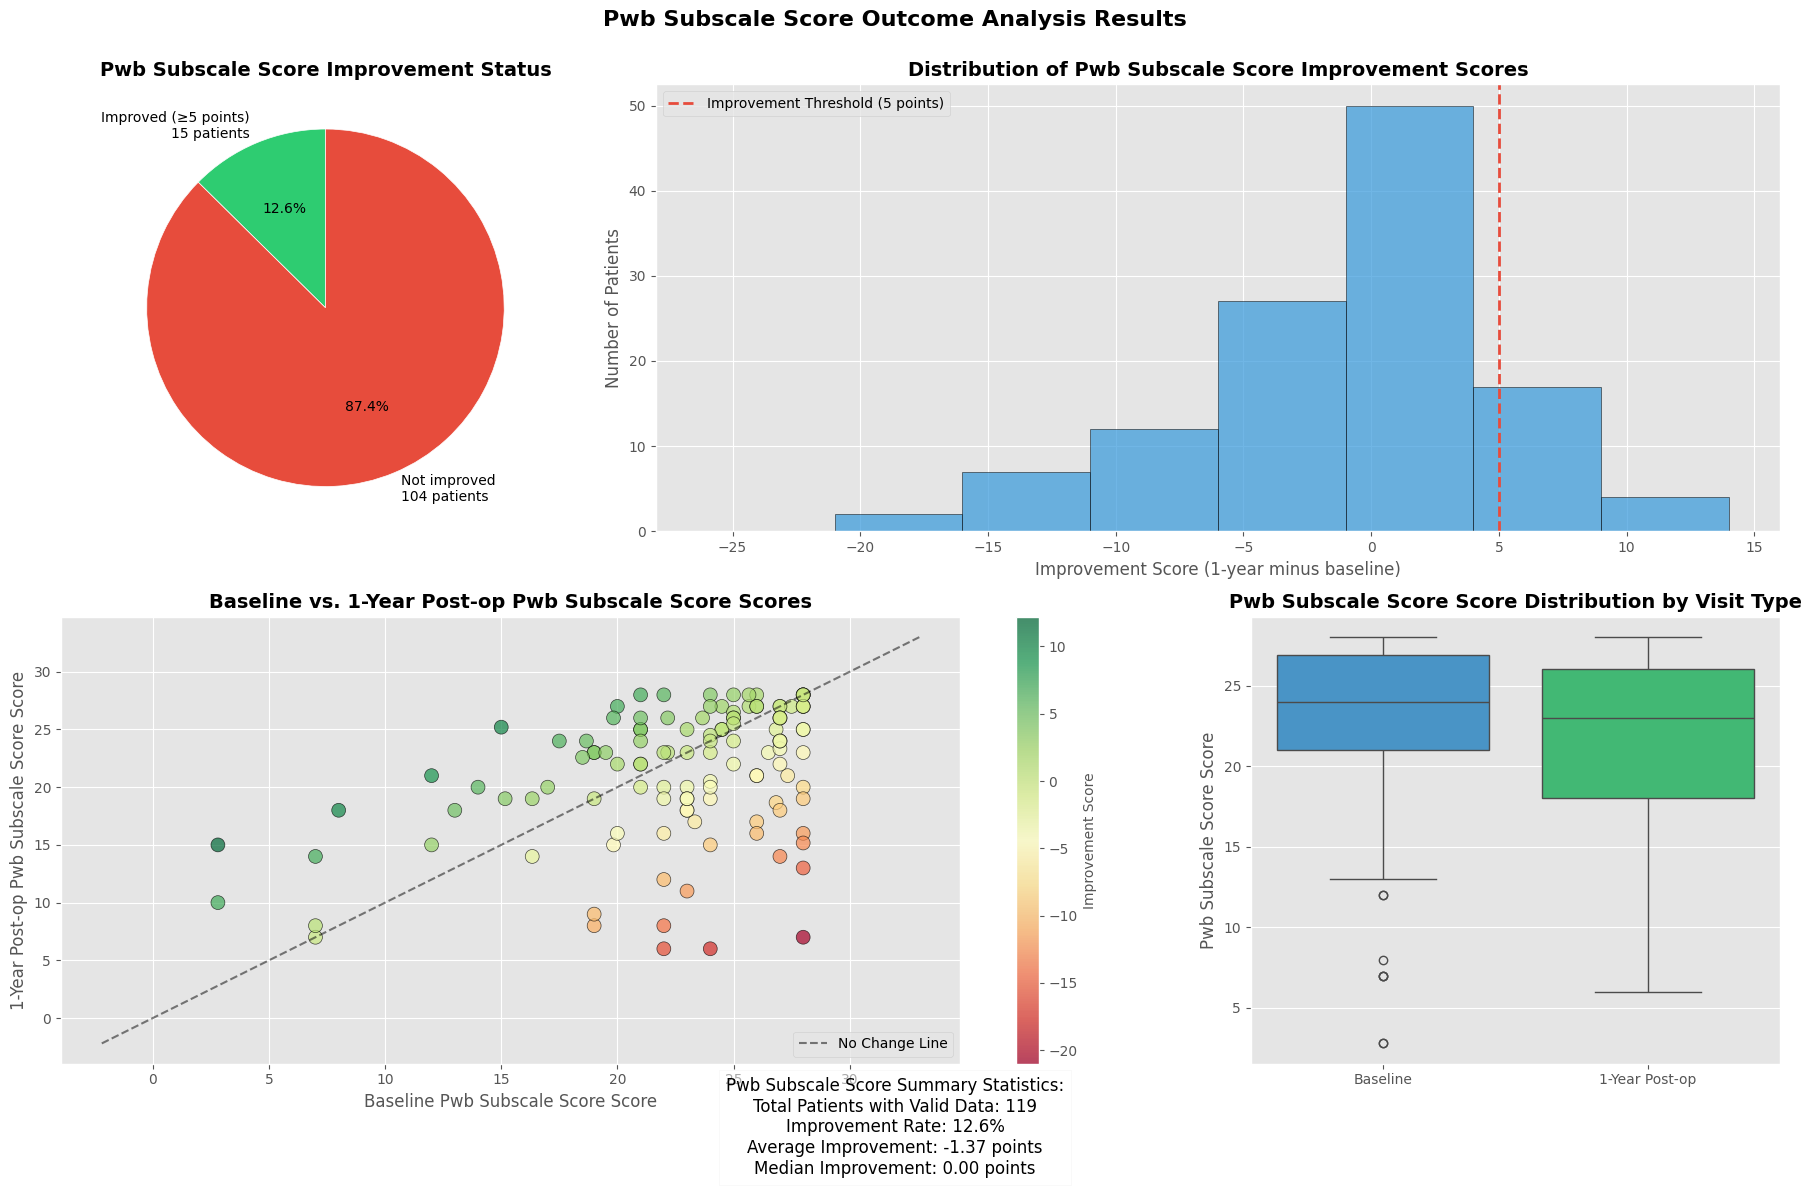

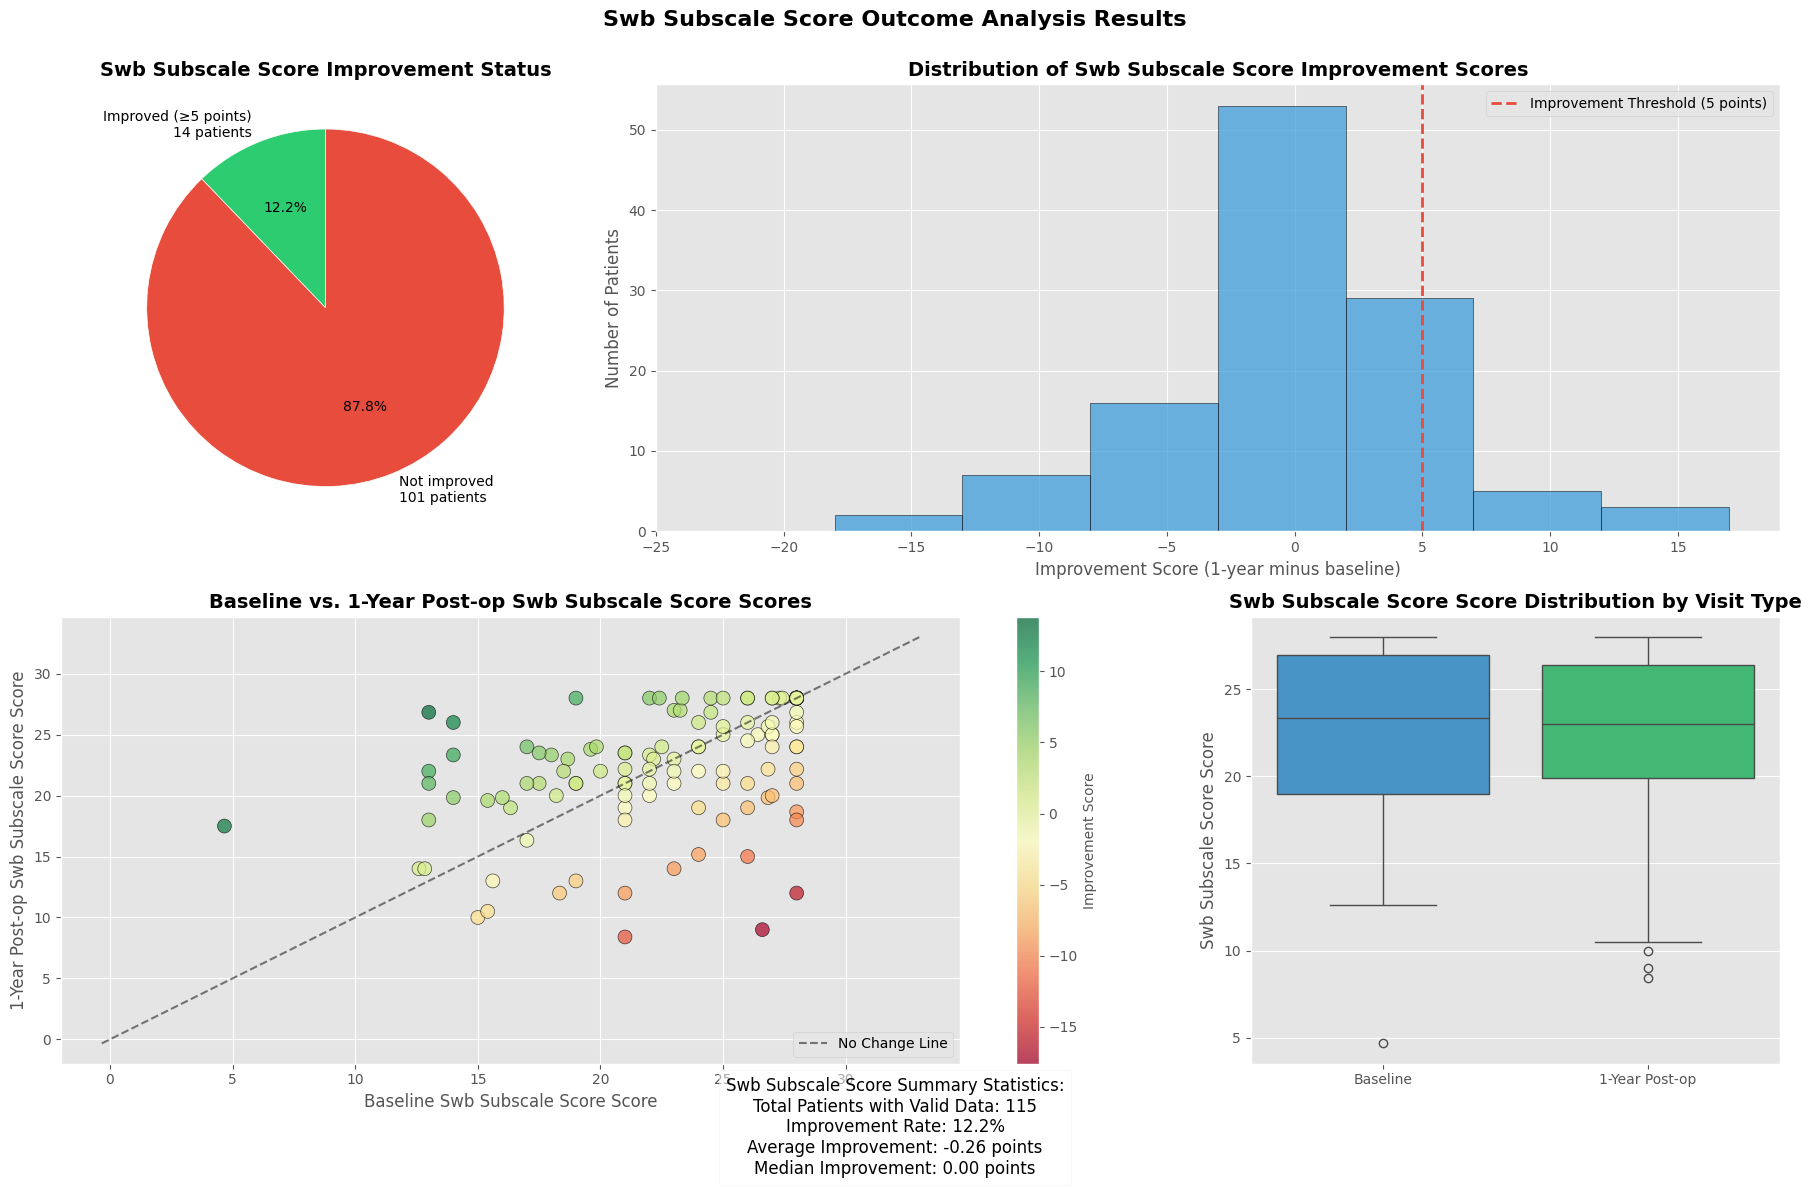

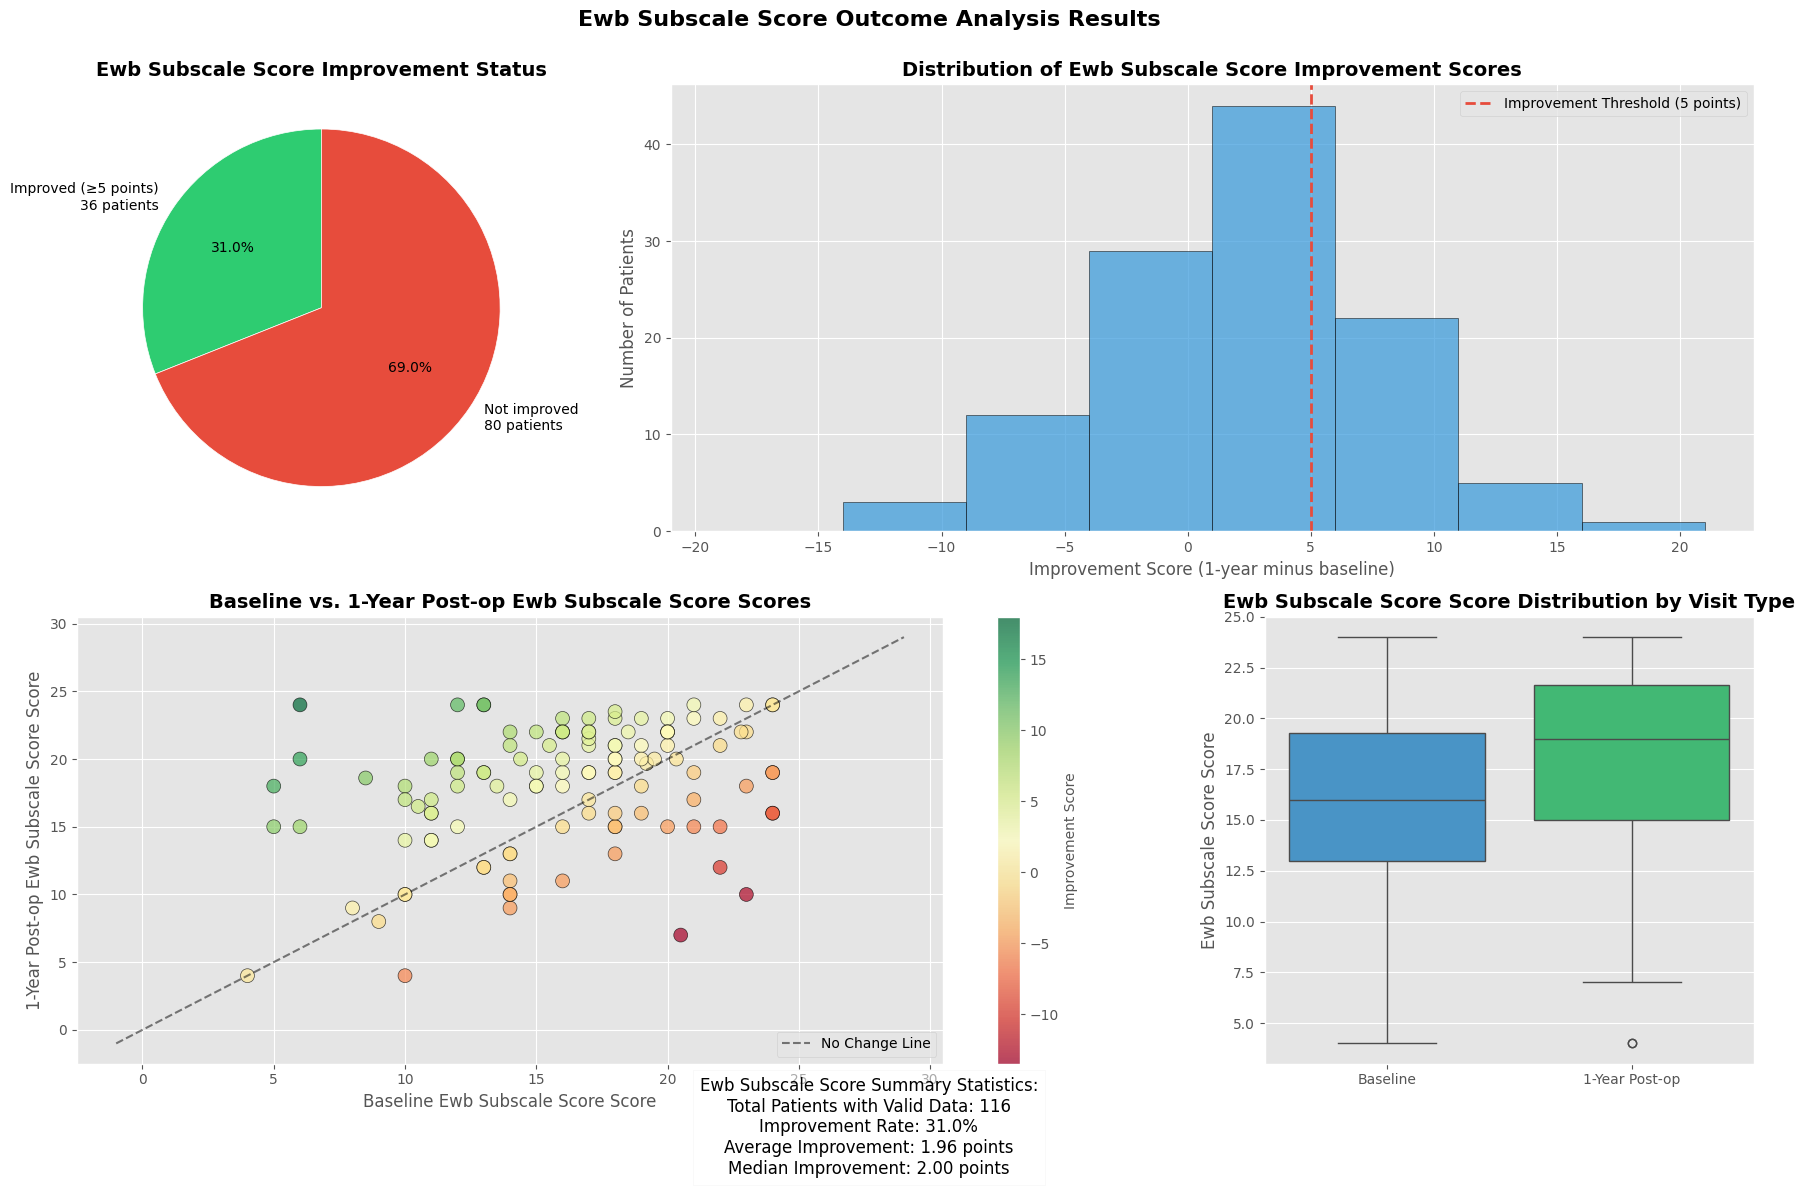

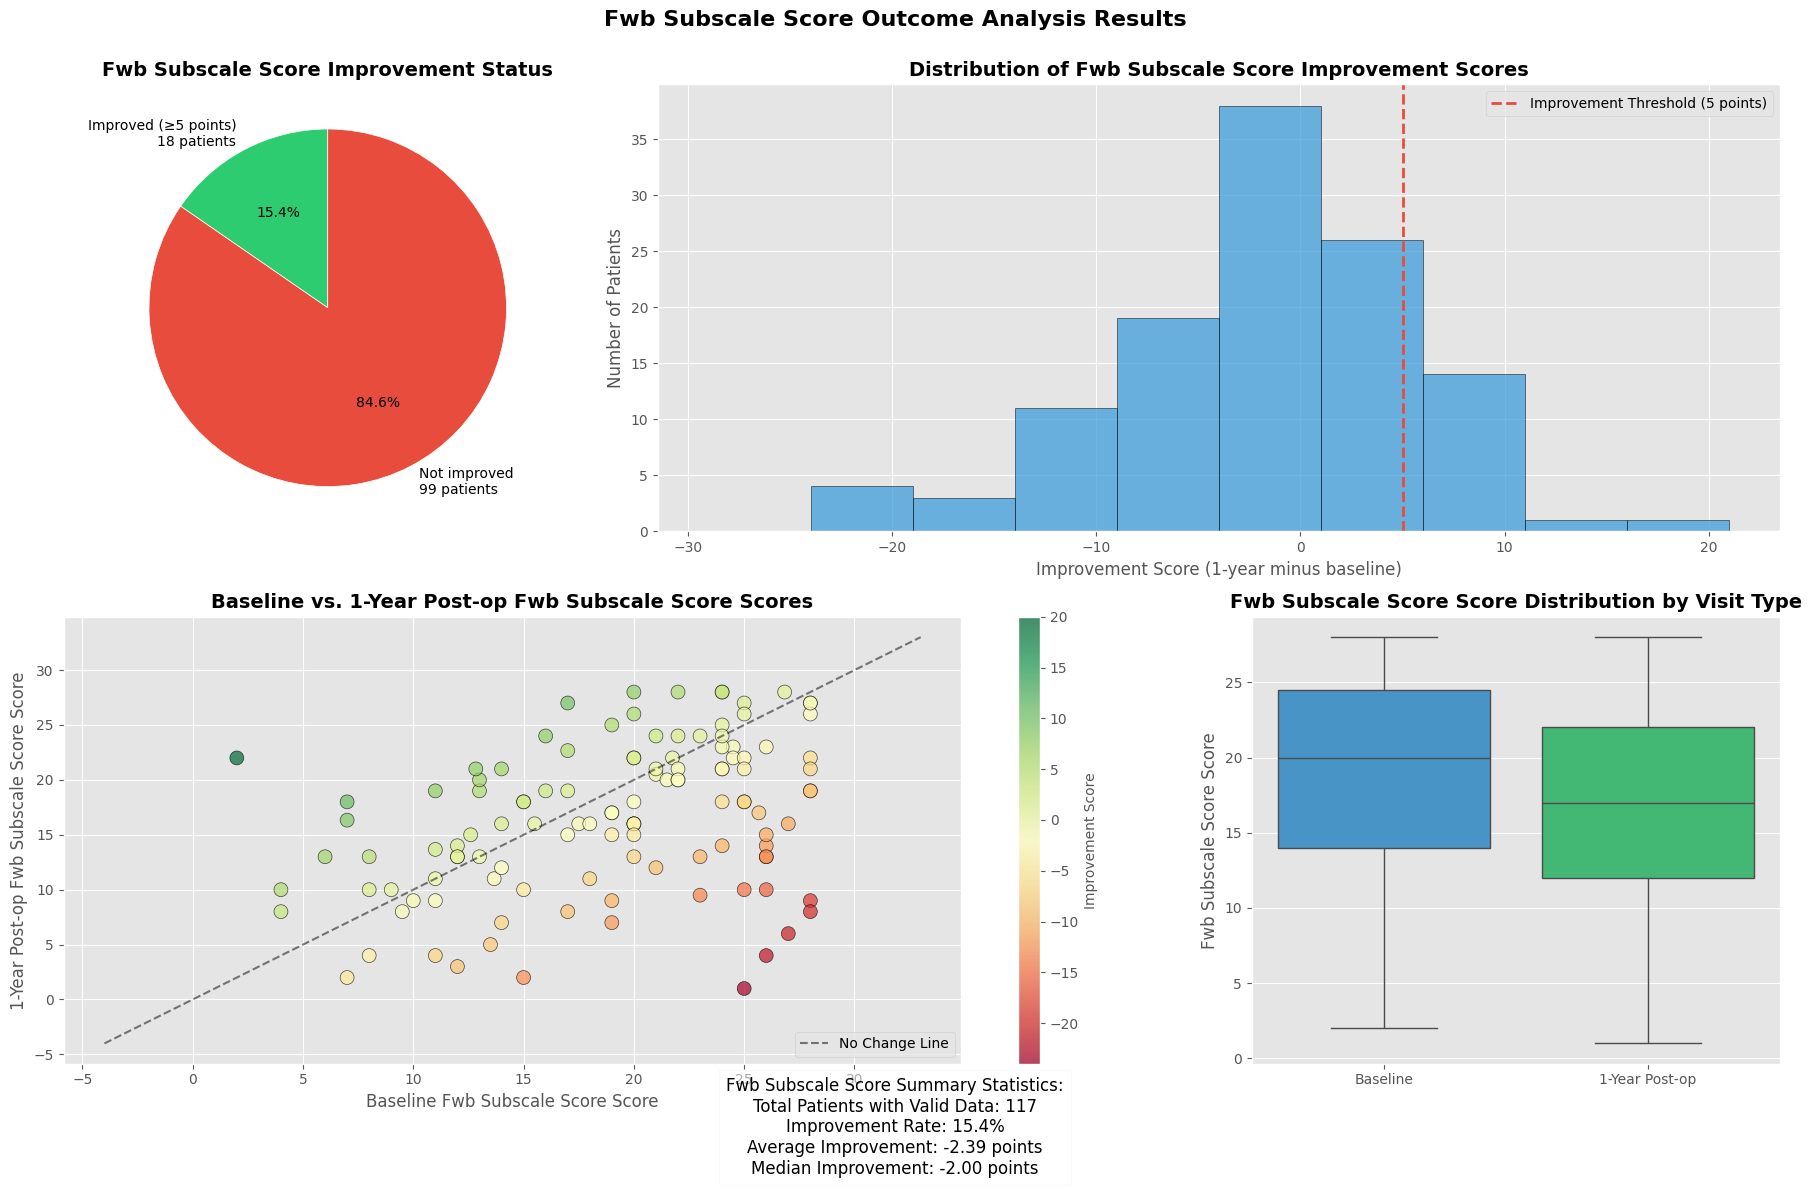

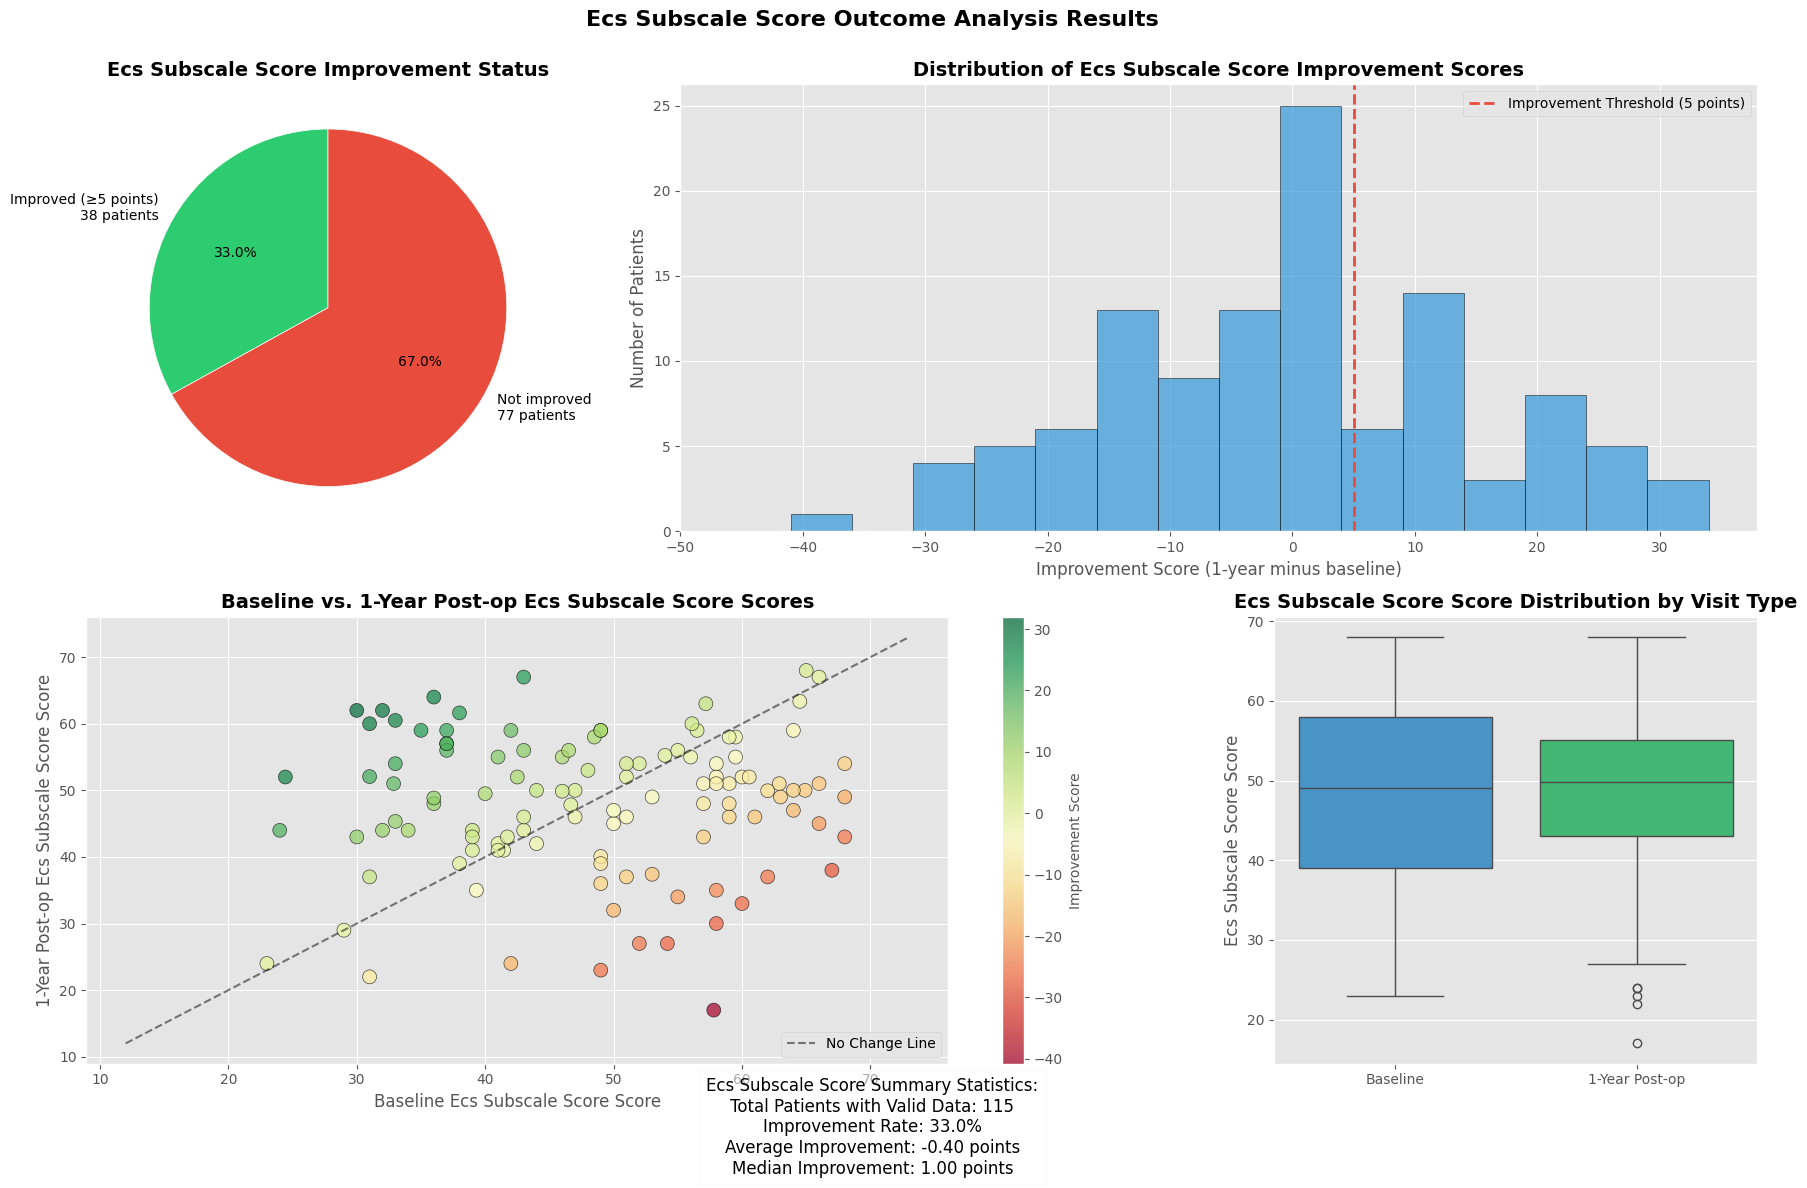

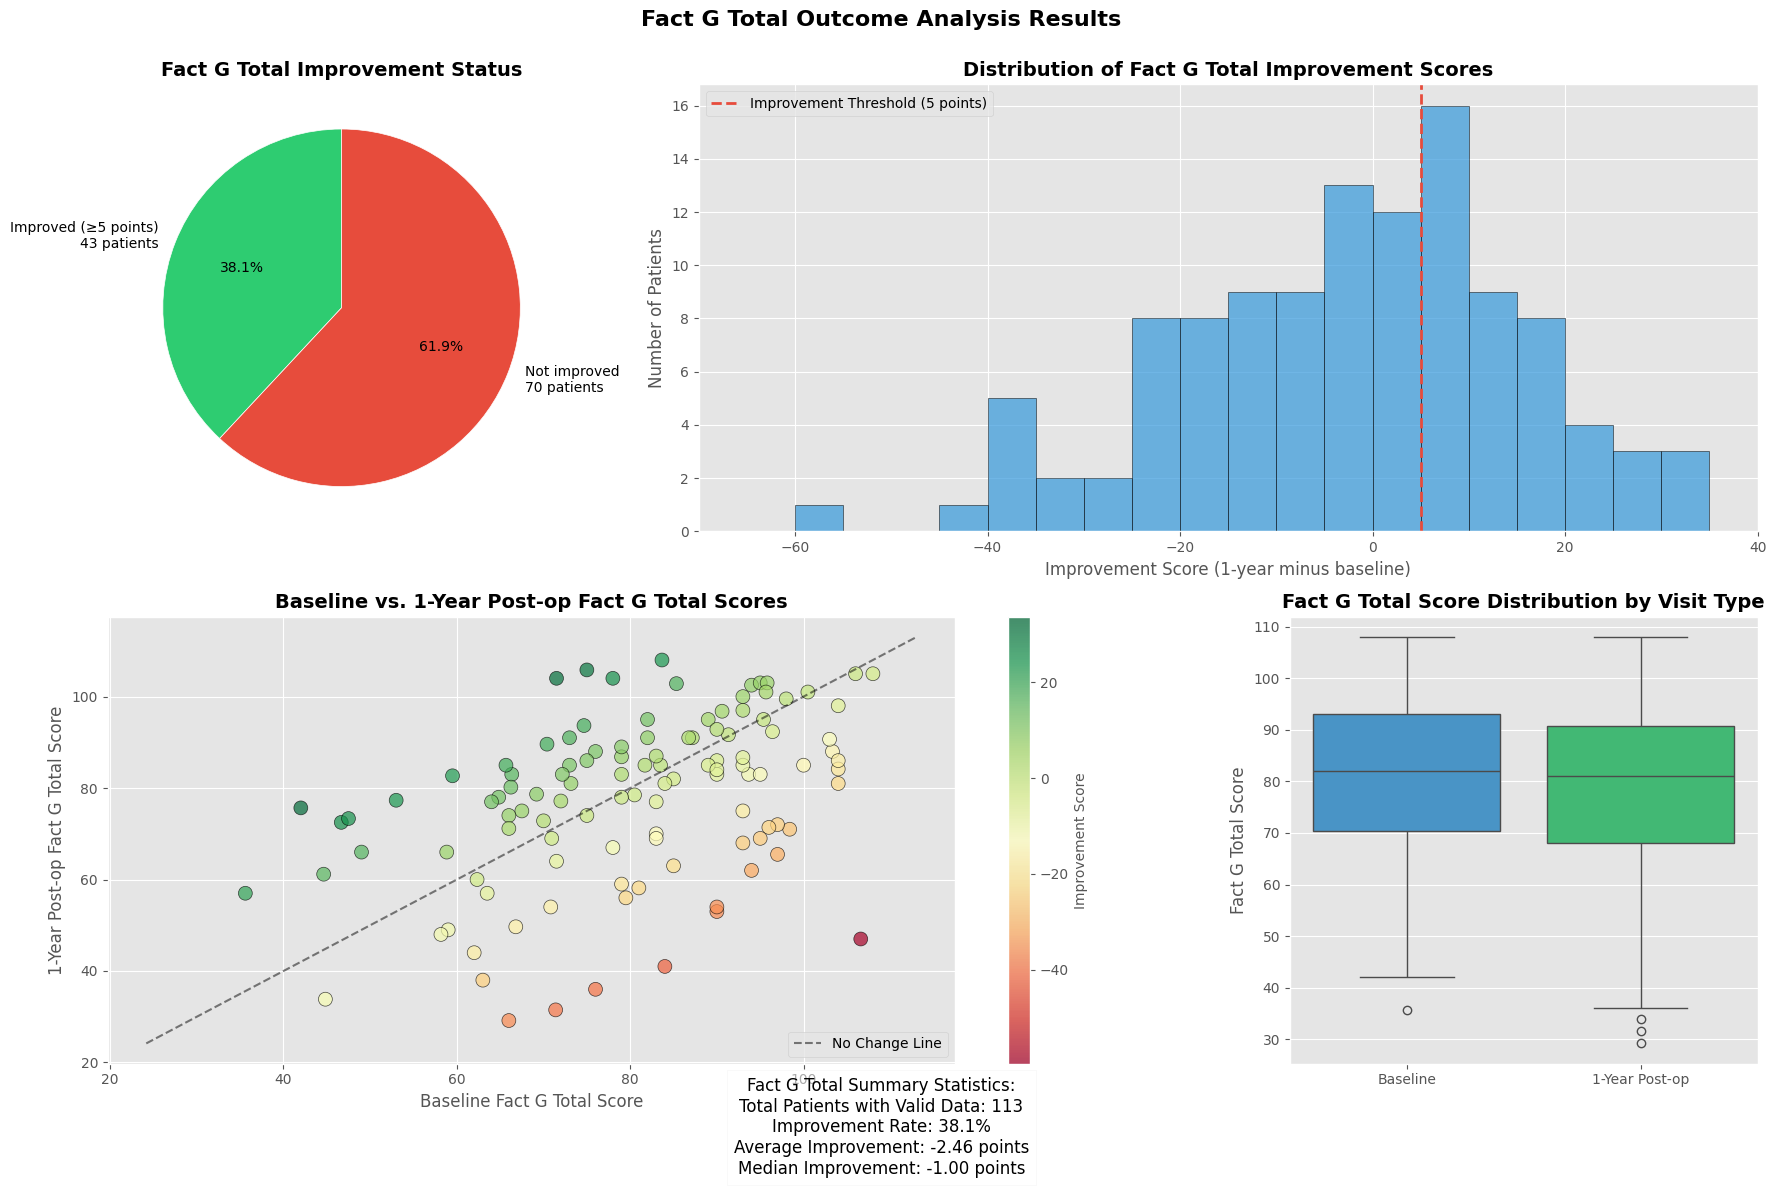

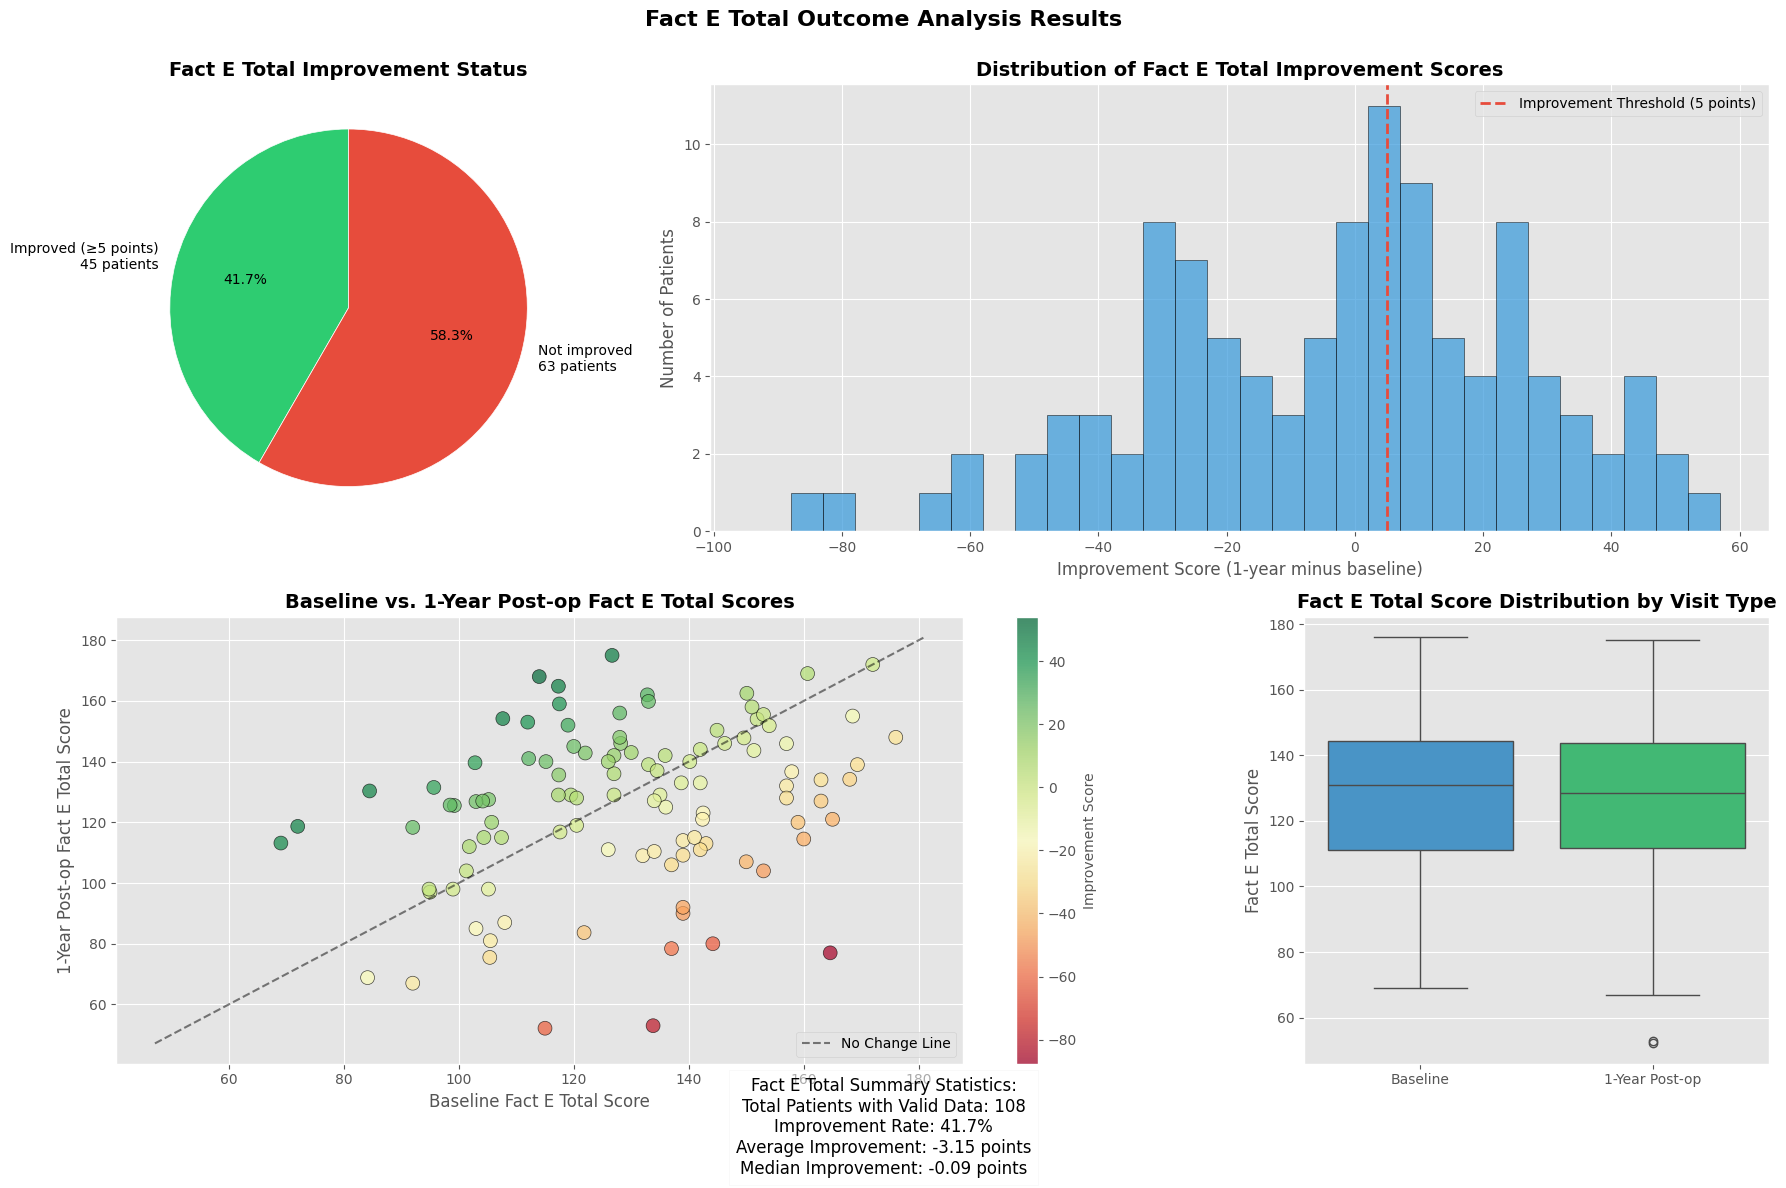

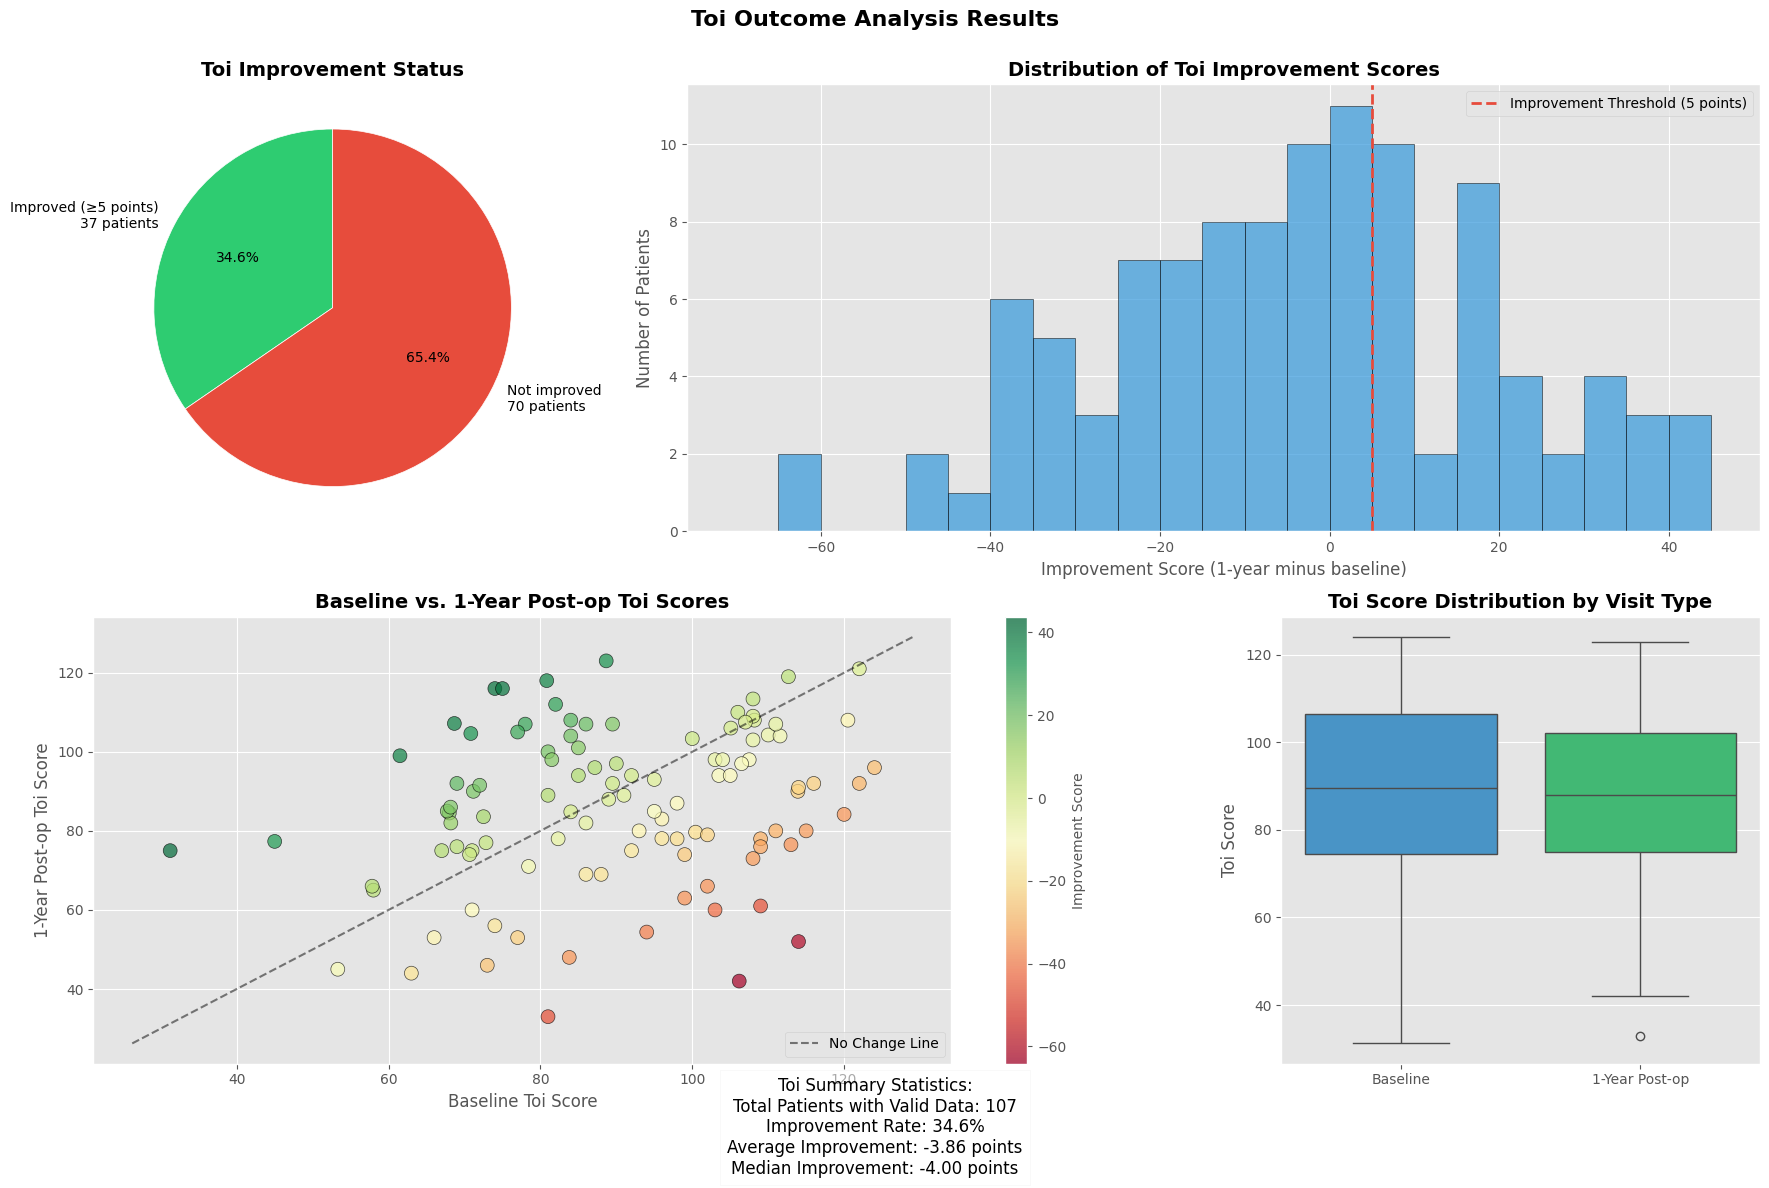

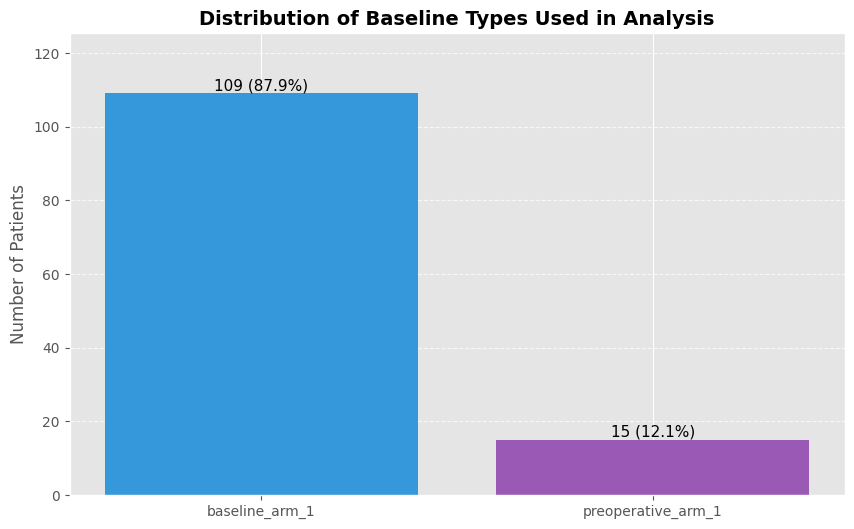

In [13]:
# Assuming results_df is available from the previous analysis
# If you need to recreate it, uncomment and run the code block below:
# filtered_df, results_df = analyze_patient_outcomes(df)

# Set the style
plt.style.use('ggplot')
sns.set_palette("colorblind")

# Define the score types to visualize
score_types = ['pwb_subscale_score', 'swb_subscale_score', 'ewb_subscale_score',
               'fwb_subscale_score', 'ecs_subscale_score', 'fact_g_total',
               'fact_e_total', 'toi']

# Create a separate figure for each score type
for score_type in score_types:
    # Create a figure with multiple subplots for the current score type
    fig = plt.figure(figsize=(18, 12))
    
    # 1. Pie chart showing percentage of patients who improved vs. didn't improve
    ax1 = plt.subplot2grid((2, 3), (0, 0))
    improved_count = results_df[f'{score_type}_has_improved'].sum()
    not_improved_count = results_df[f'{score_type}_has_improved'].notna().sum() - improved_count
    improvement_data = [improved_count, not_improved_count]
    labels = [f'Improved (≥5 points)\n{improved_count} patients', f'Not improved\n{not_improved_count} patients']
    colors = ['#2ecc71', '#e74c3c']
    ax1.pie(improvement_data, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'white'})
    ax1.set_title(f'{score_type.replace("_", " ").title()} Improvement Status', fontsize=14, fontweight='bold')

    # 2. Bar chart showing the distribution of improvement scores
    ax2 = plt.subplot2grid((2, 3), (0, 1), colspan=2)
    improvement_col = f'{score_type}_improvement'
    if improvement_col in results_df.columns:
        bins = np.arange(np.floor(results_df[improvement_col].min()) - 5, 
                        np.ceil(results_df[improvement_col].max()) + 5, 5)
        ax2.hist(results_df[improvement_col].dropna(), bins=bins, color='#3498db', alpha=0.7, edgecolor='black')
    ax2.axvline(x=5, color='#e74c3c', linestyle='--', linewidth=2, label='Improvement Threshold (5 points)')
    ax2.set_xlabel('Improvement Score (1-year minus baseline)', fontsize=12)
    ax2.set_ylabel('Number of Patients', fontsize=12)
    ax2.set_title(f'Distribution of {score_type.replace("_", " ").title()} Improvement Scores', fontsize=14, fontweight='bold')
    ax2.legend()

    # 3. Scatter plot of baseline vs one-year scores
    ax3 = plt.subplot2grid((2, 3), (1, 0), colspan=2)
    scatter = ax3.scatter(results_df[f'{score_type}_baseline'], results_df[f'{score_type}_one_year'], 
                         c=results_df[f'{score_type}_improvement'], cmap='RdYlGn', s=100, alpha=0.7, edgecolor='black')
    min_val = min(results_df[f'{score_type}_baseline'].min(), results_df[f'{score_type}_one_year'].min()) - 5
    max_val = max(results_df[f'{score_type}_baseline'].max(), results_df[f'{score_type}_one_year'].max()) + 5
    ax3.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='No Change Line')
    ax3.set_xlabel(f'Baseline {score_type.replace("_", " ").title()} Score', fontsize=12)
    ax3.set_ylabel(f'1-Year Post-op {score_type.replace("_", " ").title()} Score', fontsize=12)
    ax3.set_title(f'Baseline vs. 1-Year Post-op {score_type.replace("_", " ").title()} Scores', fontsize=14, fontweight='bold')
    cbar = plt.colorbar(scatter, ax=ax3)
    cbar.set_label('Improvement Score', fontsize=10)
    ax3.legend(loc='lower right')

    # 4. Box plot of scores by visit type
    ax4 = plt.subplot2grid((2, 3), (1, 2))
    box_data = pd.DataFrame({
        'Baseline': results_df[f'{score_type}_baseline'],
        '1-Year Post-op': results_df[f'{score_type}_one_year']
    })
    sns.boxplot(data=box_data, ax=ax4, palette=['#3498db', '#2ecc71'])
    ax4.set_ylabel(f'{score_type.replace("_", " ").title()} Score', fontsize=12)
    ax4.set_title(f'{score_type.replace("_", " ").title()} Score Distribution by Visit Type', fontsize=14, fontweight='bold')

    # Add a summary text box
    improved_count = results_df[f'{score_type}_has_improved'].sum()
    valid_count = results_df[f'{score_type}_improvement'].notna().sum()
    improvement_rate = (improved_count / valid_count * 100) if valid_count > 0 else 0
    avg_improvement = results_df[f'{score_type}_improvement'].mean()
    median_improvement = results_df[f'{score_type}_improvement'].median()
    plt.figtext(0.5, 0.01, 
               f"{score_type.replace('_', ' ').title()} Summary Statistics:\n"
               f"Total Patients with Valid Data: {valid_count}\n"
               f"Improvement Rate: {improvement_rate:.1f}%\n"
               f"Average Improvement: {avg_improvement:.2f} points\n"
               f"Median Improvement: {median_improvement:.2f} points",
               ha="center", fontsize=12, bbox={"facecolor":"white", "alpha":0.5, "pad":5})

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.suptitle(f'{score_type.replace("_", " ").title()} Outcome Analysis Results', fontsize=16, fontweight='bold', y=0.98)

    # Display the plot for this score type
    plt.show()

# Create additional visualization for baseline type distribution (unchanged)
plt.figure(figsize=(10, 6))
baseline_counts = results_df['baseline_type'].value_counts()
bars = plt.bar(baseline_counts.index, baseline_counts.values, color=['#3498db', '#9b59b6'])

# Add data labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height} ({height/len(results_df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11)

plt.title('Distribution of Baseline Types Used in Analysis', fontsize=14, fontweight='bold')
plt.ylabel('Number of Patients', fontsize=12)
plt.ylim(0, baseline_counts.max() * 1.15)  # Add some space for the labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Data set up

In [14]:
results_df = pd.read_csv("results.csv")

In [15]:
results_df

,id,baseline_type,pwb_subscale_score_baseline,pwb_subscale_score_one_year,pwb_subscale_score_improvement,pwb_subscale_score_has_improved,swb_subscale_score_baseline,swb_subscale_score_one_year,swb_subscale_score_improvement,swb_subscale_score_has_improved,...,fact_g_total_improvement,fact_g_total_has_improved,fact_e_total_baseline,fact_e_total_one_year,fact_e_total_improvement,fact_e_total_has_improved,toi_baseline,toi_one_year,toi_improvement,toi_has_improved
0,32,baseline_arm_1,24.5,27.0,2.5,False,22.0,28.0,6.0,True,...,32.5,True,117.5,159.0,41.5,True,89.5,107.0,17.5,True
1,76,preoperative_arm_1,7.0,7.0,0.0,False,23.0,21.0,-2.0,False,...,-10.0,False,95.0,97.0,2.0,False,58.0,65.0,7.0,True
2,125,baseline_arm_1,21.0,22.0,1.0,False,17.5,21.0,3.5,False,...,7.5,True,119.5,129.0,9.5,True,81.0,89.0,8.0,True
3,160,baseline_arm_1,21.0,28.0,7.0,True,20.0,22.0,2.0,False,...,13.0,True,119.0,152.0,33.0,True,78.0,107.0,29.0,True
4,198,baseline_arm_1,25.0,26.5,1.5,False,13.0,18.0,5.0,True,...,12.0,True,133.0,139.0,6.0,True,103.0,98.0,-5.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,1571,baseline_arm_1,26.0,16.0,-10.0,False,28.0,28.0,0.0,False,...,-26.0,False,153.0,104.0,-49.0,False,109.0,61.0,-48.0,False
120,1572,baseline_arm_1,27.0,24.0,-3.0,False,13.0,21.0,8.0,True,...,-1.0,False,141.0,115.0,-26.0,False,109.0,76.0,-33.0,False
121,1615,baseline_arm_1,23.0,19.0,-4.0,False,24.0,22.0,-2.0,False,...,-1.0,False,126.0,111.0,-15.0,False,86.0,69.0,-17.0,False
122,1653,baseline_arm_1,21.0,26.0,5.0,True,19.0,21.0,2.0,False,...,9.0,True,112.0,153.0,41.0,True,75.0,116.0,41.0,True


In [16]:
results_df = results_df[['id','baseline_type', 'fact_e_total_baseline', 'fact_e_total_one_year', 'fact_e_total_improvement', 'fact_e_total_has_improved']]


# Rename the specified columns
results_df = results_df.rename(columns={
    "fact_e_total_baseline": "Baseline",
    "fact_e_total_one_year": "Postop1yr",
    "fact_e_total_improvement": "Change"
})

results_df["Trend Category"] = results_df['fact_e_total_has_improved'].map({True: 'Improved', False: 'Decreased/Same'}).fillna(results_df['fact_e_total_has_improved'])

results_df = results_df.dropna(subset=['Trend Category'])
results_df["Trend Category"].value_counts()


Trend Category
Decreased/Same    63
Improved          45
Name: count, dtype: int64

In [17]:
# Set 'id' column as the index
results_df = results_df.set_index("id")

# Rename the index and columns to match the second image
results_df.index.name = "id"
results_df.columns.name = "Timepoint"

results_df
score_comparison=results_df.copy()

In [18]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [19]:
score_comparison['baseline_type'].value_counts()

baseline_type
baseline_arm_1        96
preoperative_arm_1    12
Name: count, dtype: int64

In [20]:
def categorize_patients(data):
    # Get list of improvers (those with 'Improved' in Trend Category)
    improvers = data[data['Trend Category'] == 'Improved'].index.tolist()
    
    # Get list of non-improvers (those with 'Decreased/Same' in Trend Category)
    non_improvers = data[data['Trend Category'] == 'Decreased/Same'].index.tolist()
    
    return {
        'improvers': improvers,
        'non_improvers': non_improvers
    }

result = categorize_patients(score_comparison)
print(f"Improvers: {result['improvers']}")
print(f"Non-improvers: {result['non_improvers']}")

Improvers: [32, 125, 160, 198, 275, 307, 449, 481, 521, 537, 539, 543, 579, 589, 613, 644, 663, 671, 702, 704, 712, 769, 816, 873, 877, 889, 898, 903, 905, 912, 920, 950, 1049, 1121, 1122, 1173, 1220, 1241, 1287, 1304, 1325, 1328, 1393, 1438, 1653]
Non-improvers: [76, 230, 364, 442, 471, 501, 505, 508, 513, 536, 549, 551, 557, 592, 629, 634, 659, 665, 668, 673, 682, 695, 698, 708, 740, 759, 764, 779, 785, 797, 850, 878, 891, 923, 938, 939, 975, 992, 1001, 1016, 1048, 1113, 1150, 1167, 1175, 1237, 1273, 1275, 1280, 1332, 1373, 1387, 1405, 1413, 1433, 1447, 1527, 1531, 1560, 1566, 1571, 1572, 1615]


# statistically significantly associated with 0) FACT E baseline 

In [21]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [22]:
# Create a clean dataframe with no missing values in Baseline
merged_df_baseline = score_comparison.copy()
merged_df_removedNA_baseline = merged_df_baseline.dropna(subset=["Baseline"])
merged_df_expanded_baseline = merged_df_removedNA_baseline.drop_duplicates()
merged_df_removedNA_baseline = merged_df_expanded_baseline.copy()
merged_df_removedNA_baseline

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [23]:

# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_baseline.groupby("Trend Category")["Baseline"].describe())


Baseline scores by Trend Category:
                count        mean        std        min         25%  \
Trend Category                                                        
Decreased/Same   63.0  137.697916  22.323467  84.145833  126.500000   
Improved         45.0  116.429310  18.818675  69.070833  104.366667   

                       50%    75%         max  
Trend Category                                 
Decreased/Same  140.181818  153.5  176.000000  
Improved        117.400000  128.0  160.666667  


In [24]:
# Perform Mann-Whitney U test to compare Baseline scores between groups
improved_baseline = merged_df_removedNA_baseline[merged_df_removedNA_baseline["Trend Category"] == "Improved"]["Baseline"]
decreased_same_baseline = merged_df_removedNA_baseline[merged_df_removedNA_baseline["Trend Category"] == "Decreased/Same"]["Baseline"]

stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
print(f"\nMann-Whitney U test:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")


Mann-Whitney U test:
Statistic: 636.0
p-value: 1.131467109094446e-06


In [25]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_baseline["Trend Category_binary"] = merged_df_removedNA_baseline["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Logistic regression with Baseline as predictor
X = sm.add_constant(merged_df_removedNA_baseline["Baseline"])
y = merged_df_removedNA_baseline["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.568402
         Iterations 6

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  108
Model:                             Logit   Df Residuals:                      106
Method:                              MLE   Df Model:                            1
Date:                   Wed, 02 Jul 2025   Pseudo R-squ.:                  0.1631
Time:                           02:57:26   Log-Likelihood:                -61.387
converged:                          True   LL-Null:                       -73.353
Covariance Type:               nonrobust   LLR p-value:                 9.986e-07
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.6694      1.409      4.023      0.000


Odds Ratio for a 10-point increase in baseline score: 0.624
95% CI for a 10-point increase in baseline score: (0.502, 0.774)


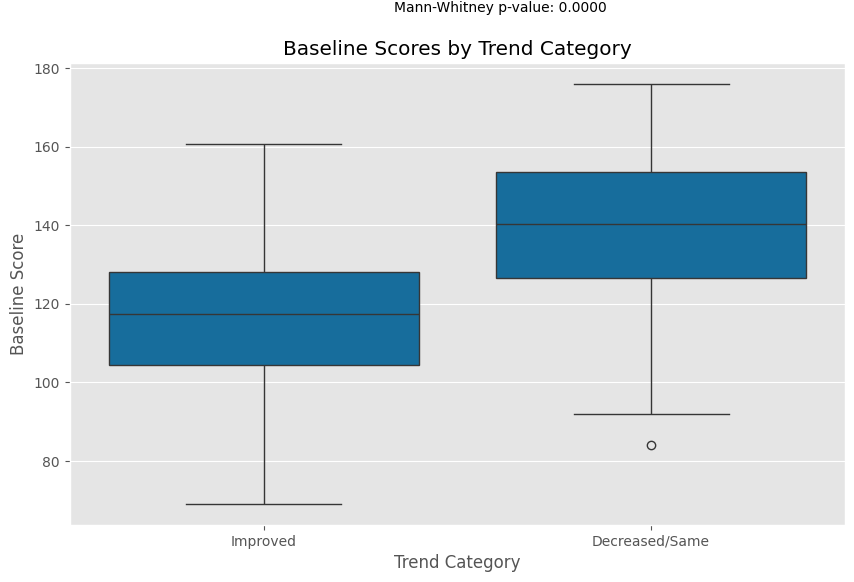

In [26]:
# Calculate odds ratio for a 10-point increase in baseline score
baseline_coef = result.params["Baseline"]
odds_ratio_10points = np.exp(baseline_coef * 10)
print(f"\nOdds Ratio for a 10-point increase in baseline score: {odds_ratio_10points:.3f}")

# Calculate confidence interval for the odds ratio
baseline_conf_int = result.conf_int().loc["Baseline"]
lower_ci_10points = np.exp(baseline_conf_int[0] * 10)
upper_ci_10points = np.exp(baseline_conf_int[1] * 10)
print(f"95% CI for a 10-point increase in baseline score: ({lower_ci_10points:.3f}, {upper_ci_10points:.3f})")

# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="Baseline", data=merged_df_removedNA_baseline)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
             xycoords='figure fraction', ha='center')
plt.show()

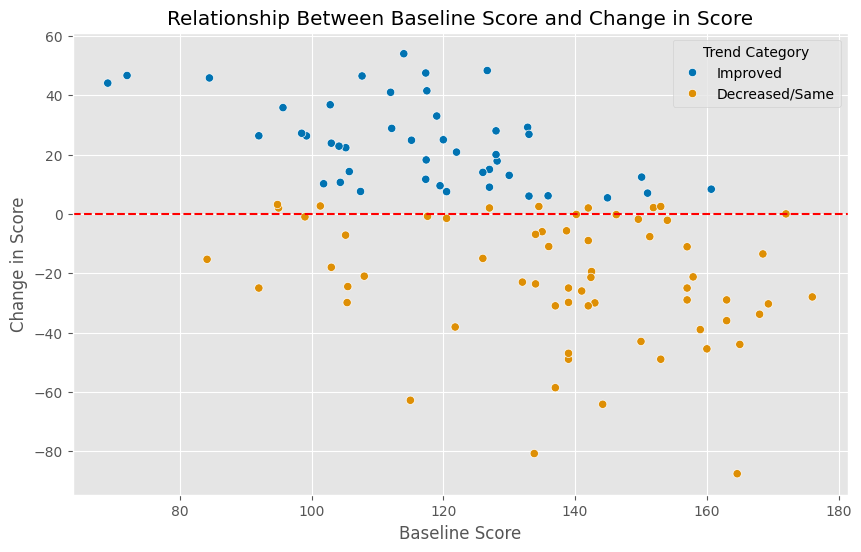

In [27]:

# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Baseline", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_baseline)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

# sensitivity analysis 0) FACT E baseline 

In [28]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


Sensitivity Analysis Results:
    threshold  improvement_rate  mean_facte_improved  mean_facte_not_improved  \
0           0          0.500000           118.719795               138.952198   
1           1          0.490741           117.714508               139.553067   
2           2          0.490741           117.714508               139.553067   
3           3          0.425926           115.959832               138.389280   
4           4          0.416667           116.429310               137.697916   
5           5          0.416667           116.429310               137.697916   
6           6          0.407407           115.781870               137.810709   
7           7          0.388889           114.892911               137.708869   
8           8          0.361111           114.014481               137.213375   
9           9          0.351852           112.786792               137.548422   
10         10          0.333333           112.205503               137.151243  

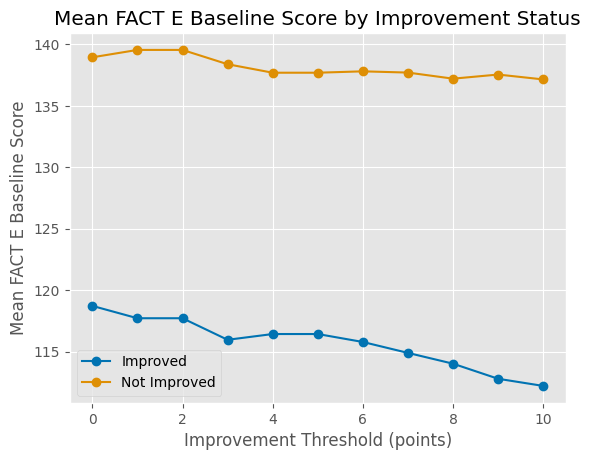

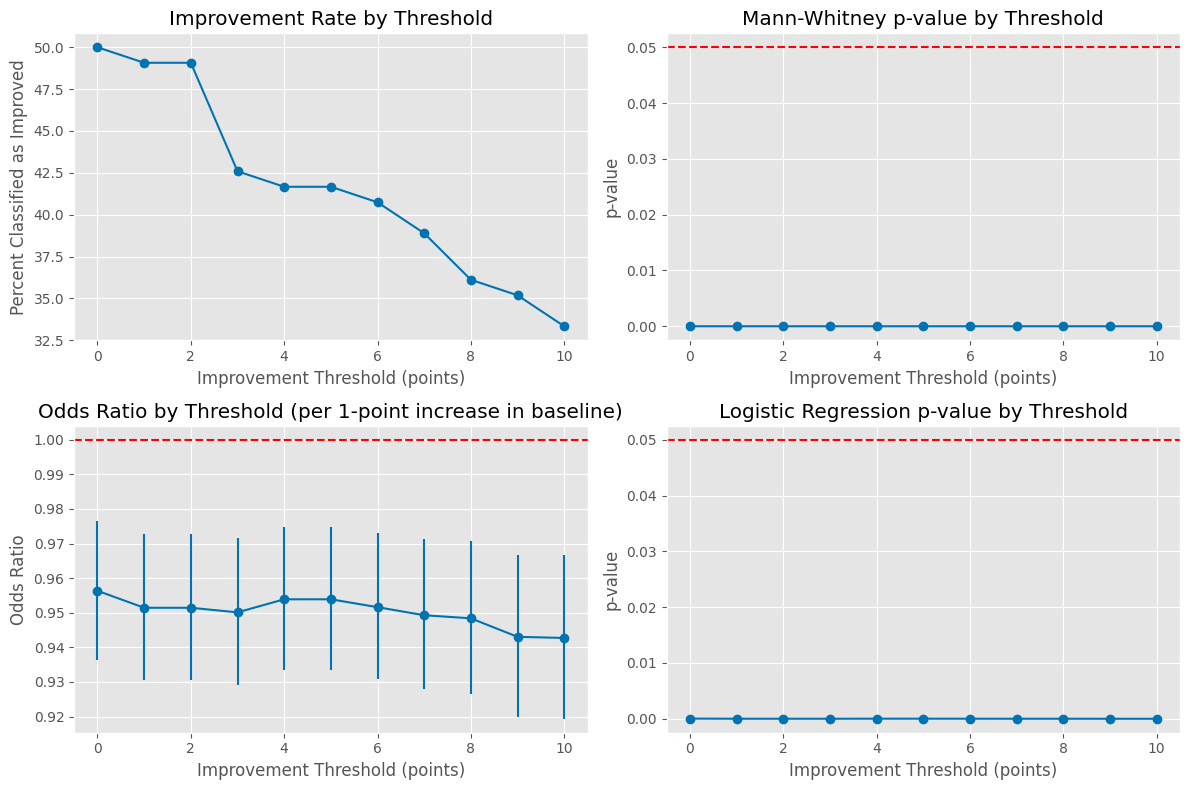


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              54                    54   50.000000   
1           1              53                    55   49.074074   
2           2              53                    55   49.074074   
3           3              46                    62   42.592593   
4           4              45                    63   41.666667   
5           5              45                    63   41.666667   
6           6              44                    64   40.740741   
7           7              42                    66   38.888889   
8           8              39                    69   36.111111   
9           9              38                    70   35.185185   
10         10              36                    72   33.333333   

    Decreased/Same %  
0          50.000000  
1          50.925926  
2          50.925926  
3          57.407407  
4          58.333333  
5          58.33

In [29]:
# Assuming score_comparison contains the necessary columns: id, Baseline, Change
# Let's create a function to perform the analysis at different thresholds

def analyze_improvement_threshold(data, threshold):
    """
    Analyze how the improvement threshold affects classification and baseline score relationship
    
    Parameters:
    data: DataFrame containing Baseline and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Mann-Whitney U test
    improved_baseline = df[df["Improved"]]["Baseline"]
    decreased_same_baseline = df[~df["Improved"]]["Baseline"]
    
    if len(improved_baseline) > 0 and len(decreased_same_baseline) > 0:
        stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
    else:
        stat, p_value = None, None
    
    # Mean pwb_subscale_score_baseline in each group
    mean_facte_improved = improved_baseline.mean() if len(improved_baseline) > 0 else None
    mean_facte_not_improved = decreased_same_baseline.mean() if len(decreased_same_baseline) > 0 else None
    
    # Logistic regression
    X = sm.add_constant(df["Baseline"])
    y = df["Trend Category_binary"]
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        baseline_coef = result.params["Baseline"]
        baseline_p = result.pvalues["Baseline"]
        odds_ratio = np.exp(baseline_coef)
        
        # Confidence intervals
        baseline_conf_int = result.conf_int().loc["Baseline"]
        lower_ci = np.exp(baseline_conf_int[0])
        upper_ci = np.exp(baseline_conf_int[1])
    except:
        baseline_coef = None
        baseline_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mean_facte_improved": mean_facte_improved,
        "mean_facte_not_improved": mean_facte_not_improved,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": baseline_coef,
        "logistic_p": baseline_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean = score_comparison.dropna(subset=["Baseline", "Change"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_improvement_threshold(merged_df_clean, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_facte_improved", "mean_facte_not_improved", "mann_whitney_p", "logistic_p", "odds_ratio"]])

plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_facte_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_facte_not_improved"], 'o-', label='Not Improved')
plt.title("Mean FACT E Baseline Score by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean FACT E Baseline Score")
plt.legend()
plt.grid(True)

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["improvement_rate"] * 100, 'o-')
plt.title("Improvement Rate by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Percent Classified as Improved")
plt.grid(True)

# Plot p-values from Mann-Whitney test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (per 1-point increase in baseline)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

In [30]:
# Just the confidence intervals
print("95% Confidence Intervals for Odds Ratios:")
for threshold in sensitivity_df['threshold']:
    row = sensitivity_df[sensitivity_df['threshold'] == threshold].iloc[0]
    lower = row['odds_ratio_lower_ci']
    upper = row['odds_ratio_upper_ci']
    or_val = row['odds_ratio']
    
    if pd.notna(or_val):
        print(f"Threshold {threshold}: OR = {or_val:.3f} (95% CI: {lower:.3f} - {upper:.3f})")
    else:
        print(f"Threshold {threshold}: OR = N/A")

95% Confidence Intervals for Odds Ratios:
Threshold 0: OR = 0.956 (95% CI: 0.936 - 0.977)
Threshold 1: OR = 0.951 (95% CI: 0.931 - 0.973)
Threshold 2: OR = 0.951 (95% CI: 0.931 - 0.973)
Threshold 3: OR = 0.950 (95% CI: 0.929 - 0.972)
Threshold 4: OR = 0.954 (95% CI: 0.933 - 0.975)
Threshold 5: OR = 0.954 (95% CI: 0.933 - 0.975)
Threshold 6: OR = 0.952 (95% CI: 0.931 - 0.973)
Threshold 7: OR = 0.949 (95% CI: 0.928 - 0.971)
Threshold 8: OR = 0.948 (95% CI: 0.927 - 0.971)
Threshold 9: OR = 0.943 (95% CI: 0.920 - 0.967)
Threshold 10: OR = 0.943 (95% CI: 0.919 - 0.967)


# statistically significantly associated with 0B) PWB baseline 

In [31]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [32]:
score_info = pd.read_csv("results.csv")
score_info

,id,baseline_type,pwb_subscale_score_baseline,pwb_subscale_score_one_year,pwb_subscale_score_improvement,pwb_subscale_score_has_improved,swb_subscale_score_baseline,swb_subscale_score_one_year,swb_subscale_score_improvement,swb_subscale_score_has_improved,...,fact_g_total_improvement,fact_g_total_has_improved,fact_e_total_baseline,fact_e_total_one_year,fact_e_total_improvement,fact_e_total_has_improved,toi_baseline,toi_one_year,toi_improvement,toi_has_improved
0,32,baseline_arm_1,24.5,27.0,2.5,False,22.0,28.0,6.0,True,...,32.5,True,117.5,159.0,41.5,True,89.5,107.0,17.5,True
1,76,preoperative_arm_1,7.0,7.0,0.0,False,23.0,21.0,-2.0,False,...,-10.0,False,95.0,97.0,2.0,False,58.0,65.0,7.0,True
2,125,baseline_arm_1,21.0,22.0,1.0,False,17.5,21.0,3.5,False,...,7.5,True,119.5,129.0,9.5,True,81.0,89.0,8.0,True
3,160,baseline_arm_1,21.0,28.0,7.0,True,20.0,22.0,2.0,False,...,13.0,True,119.0,152.0,33.0,True,78.0,107.0,29.0,True
4,198,baseline_arm_1,25.0,26.5,1.5,False,13.0,18.0,5.0,True,...,12.0,True,133.0,139.0,6.0,True,103.0,98.0,-5.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,1571,baseline_arm_1,26.0,16.0,-10.0,False,28.0,28.0,0.0,False,...,-26.0,False,153.0,104.0,-49.0,False,109.0,61.0,-48.0,False
120,1572,baseline_arm_1,27.0,24.0,-3.0,False,13.0,21.0,8.0,True,...,-1.0,False,141.0,115.0,-26.0,False,109.0,76.0,-33.0,False
121,1615,baseline_arm_1,23.0,19.0,-4.0,False,24.0,22.0,-2.0,False,...,-1.0,False,126.0,111.0,-15.0,False,86.0,69.0,-17.0,False
122,1653,baseline_arm_1,21.0,26.0,5.0,True,19.0,21.0,2.0,False,...,9.0,True,112.0,153.0,41.0,True,75.0,116.0,41.0,True


In [33]:
merged_df_pwb = score_comparison.merge(score_info[["id", "pwb_subscale_score_baseline"]], on="id", how="left")
merged_df_removedNA_pwb = merged_df_pwb.dropna(subset=["pwb_subscale_score_baseline"])
merged_df_expanded_pwb = merged_df_removedNA_pwb.drop_duplicates()
merged_df_removedNA_pwb = merged_df_expanded_pwb.copy()
merged_df_removedNA_pwb

,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,pwb_subscale_score_baseline
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,24.5
1,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,7.0
2,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,21.0
3,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,21.0
4,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,25.0
...,...,...,...,...,...,...,...,...
103,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,23.0
104,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,26.0
105,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,27.0
106,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,23.0


In [34]:
# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_pwb.groupby("Trend Category")["pwb_subscale_score_baseline"].describe())


Baseline scores by Trend Category:
                count       mean       std  min   25%   50%   75%   max
Trend Category                                                         
Decreased/Same   63.0  23.726984  5.193254  2.8  22.0  24.5  27.0  28.0
Improved         45.0  21.177037  5.042550  2.8  19.0  22.0  25.0  28.0


In [35]:
# Perform Mann-Whitney U test to compare Baseline scores between groups
improved_baseline = merged_df_removedNA_pwb[merged_df_removedNA_pwb["Trend Category"] == "Improved"]["pwb_subscale_score_baseline"]
decreased_same_baseline = merged_df_removedNA_pwb[merged_df_removedNA_pwb["Trend Category"] == "Decreased/Same"]["pwb_subscale_score_baseline"]

stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
print(f"\nMann-Whitney U test:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")


Mann-Whitney U test:
Statistic: 859.0
p-value: 0.0004889473250052759


In [36]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_pwb["Trend Category_binary"] = merged_df_removedNA_pwb["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Logistic regression with Baseline as predictor
X = sm.add_constant(merged_df_removedNA_pwb["pwb_subscale_score_baseline"])
y = merged_df_removedNA_pwb["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.649878
         Iterations 5

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  108
Model:                             Logit   Df Residuals:                      106
Method:                              MLE   Df Model:                            1
Date:                   Wed, 02 Jul 2025   Pseudo R-squ.:                 0.04316
Time:                           02:57:28   Log-Likelihood:                -70.187
converged:                          True   LL-Null:                       -73.353
Covariance Type:               nonrobust   LLR p-value:                   0.01186
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const               


Odds Ratio for a 10-point increase in baseline score: 0.373
95% CI for a 10-point increase in baseline score: (0.164, 0.850)


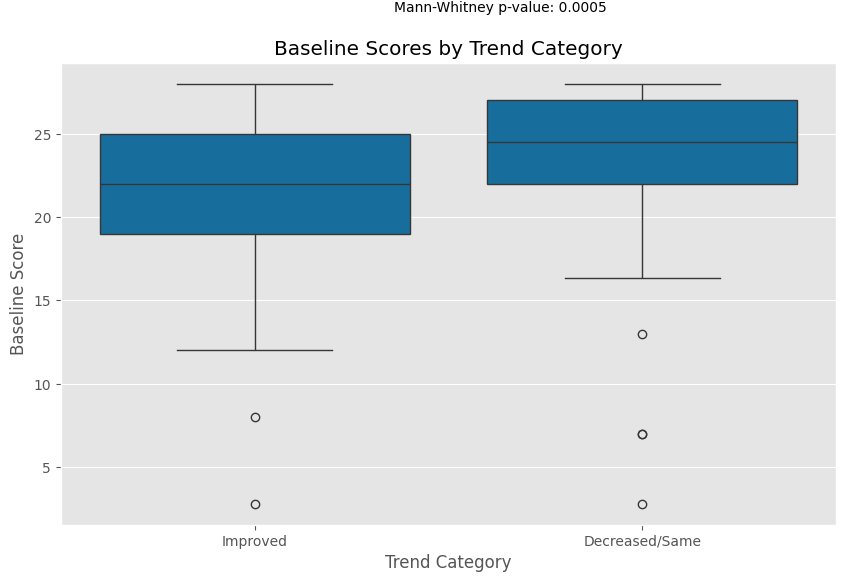

In [37]:
# Calculate odds ratio for a 10-point increase in baseline score
baseline_coef = result.params["pwb_subscale_score_baseline"]
odds_ratio_10points = np.exp(baseline_coef * 10)
print(f"\nOdds Ratio for a 10-point increase in baseline score: {odds_ratio_10points:.3f}")

# Calculate confidence interval for the odds ratio
baseline_conf_int = result.conf_int().loc["pwb_subscale_score_baseline"]
lower_ci_10points = np.exp(baseline_conf_int[0] * 10)
upper_ci_10points = np.exp(baseline_conf_int[1] * 10)
print(f"95% CI for a 10-point increase in baseline score: ({lower_ci_10points:.3f}, {upper_ci_10points:.3f})")

# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="pwb_subscale_score_baseline", data=merged_df_removedNA_pwb)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
                xycoords='figure fraction', ha='center')
plt.show()

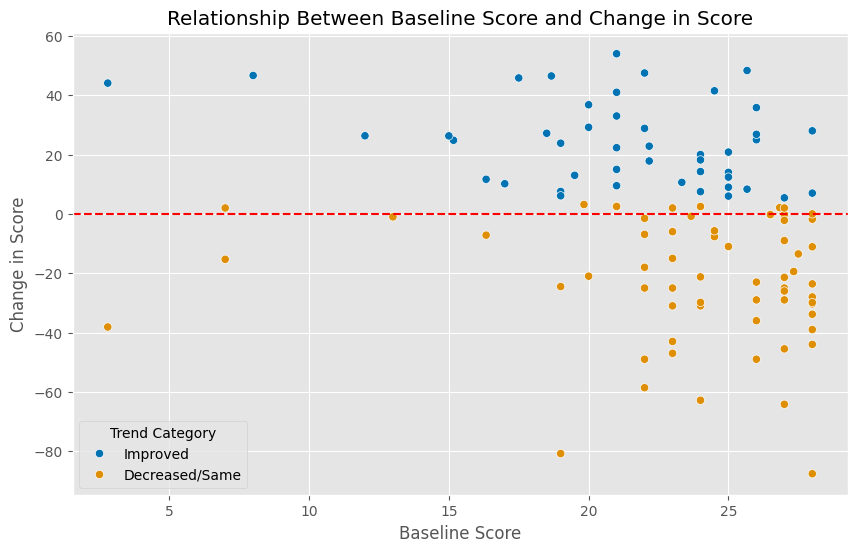

In [38]:
# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="pwb_subscale_score_baseline", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_pwb)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

# sensitivity analysis 0B) PWB baseline 

Sensitivity Analysis Results:
    threshold  improvement_rate  mean_pwb_improved  mean_pwb_not_improved  \
0           0          0.500000          21.308025              24.020988   
1           1          0.490741          21.181761              24.093333   
2           2          0.490741          21.181761              24.093333   
3           3          0.425926          21.147826              23.789785   
4           4          0.416667          21.177037              23.726984   
5           5          0.416667          21.177037              23.726984   
6           6          0.407407          21.044697              23.778125   
7           7          0.388889          20.999206              23.724242   
8           8          0.361111          20.794017              23.721739   
9           9          0.351852          20.665789              23.749524   
10         10          0.333333          20.536111              23.728704   

    mann_whitney_p  logistic_p  odds_ratio  


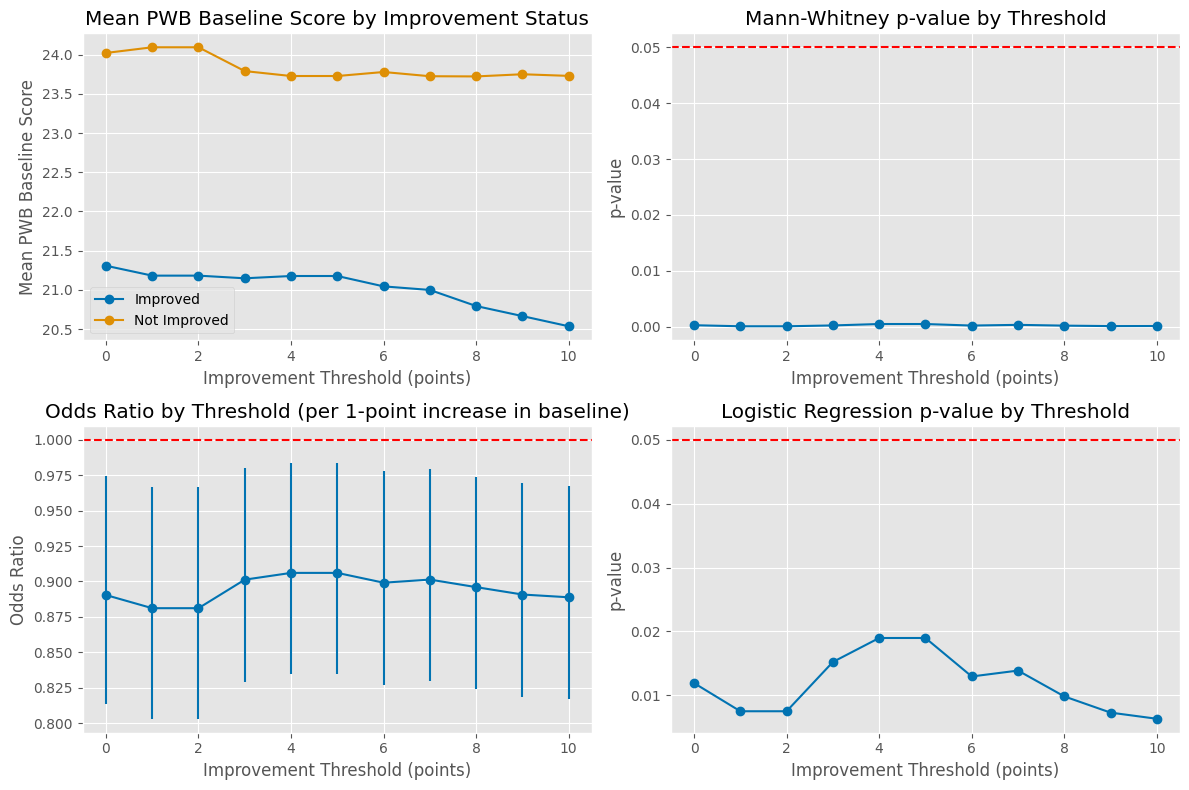


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              54                    54   50.000000   
1           1              53                    55   49.074074   
2           2              53                    55   49.074074   
3           3              46                    62   42.592593   
4           4              45                    63   41.666667   
5           5              45                    63   41.666667   
6           6              44                    64   40.740741   
7           7              42                    66   38.888889   
8           8              39                    69   36.111111   
9           9              38                    70   35.185185   
10         10              36                    72   33.333333   

    Decreased/Same %  
0          50.000000  
1          50.925926  
2          50.925926  
3          57.407407  
4          58.333333  
5          58.33

In [39]:
def analyze_improvement_threshold(data, threshold):
    """
    Analyze how the improvement threshold affects classification and baseline score relationship
    
    Parameters:
    data: DataFrame containing Baseline and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Mann-Whitney U test
    improved_baseline = df[df["Improved"]]["pwb_subscale_score_baseline"]
    decreased_same_baseline = df[~df["Improved"]]["pwb_subscale_score_baseline"]
    
    if len(improved_baseline) > 0 and len(decreased_same_baseline) > 0:
        stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
    else:
        stat, p_value = None, None
        
    # Mean pwb_subscale_score_baseline in each group
    mean_pwb_improved = improved_baseline.mean() if len(improved_baseline) > 0 else None
    mean_pwb_not_improved = decreased_same_baseline.mean() if len(decreased_same_baseline) > 0 else None
    
    # Logistic regression
    X = sm.add_constant(df["pwb_subscale_score_baseline"])
    y = df["Trend Category_binary"]
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        baseline_coef = result.params["pwb_subscale_score_baseline"]
        baseline_p = result.pvalues["pwb_subscale_score_baseline"]
        odds_ratio = np.exp(baseline_coef)
        
        # Confidence intervals
        baseline_conf_int = result.conf_int().loc["pwb_subscale_score_baseline"]
        lower_ci = np.exp(baseline_conf_int[0])
        upper_ci = np.exp(baseline_conf_int[1])
    except:
        baseline_coef = None
        baseline_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mean_pwb_improved": mean_pwb_improved,
        "mean_pwb_not_improved": mean_pwb_not_improved,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": baseline_coef,
        "logistic_p": baseline_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean = merged_df_pwb.dropna(subset=["pwb_subscale_score_baseline", "Change"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_improvement_threshold(merged_df_clean, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_pwb_improved", "mean_pwb_not_improved", "mann_whitney_p", "logistic_p", "odds_ratio"]])


# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_pwb_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_pwb_not_improved"], 'o-', label='Not Improved')
plt.title("Mean PWB Baseline Score by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean PWB Baseline Score")
plt.legend()
plt.grid(True)


# Plot p-values from Mann-Whitney test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (per 1-point increase in baseline)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

In [40]:
# Just the confidence intervals
print("95% Confidence Intervals for Odds Ratios:")
for threshold in sensitivity_df['threshold']:
    row = sensitivity_df[sensitivity_df['threshold'] == threshold].iloc[0]
    lower = row['odds_ratio_lower_ci']
    upper = row['odds_ratio_upper_ci']
    or_val = row['odds_ratio']
    
    if pd.notna(or_val):
        print(f"Threshold {threshold}: OR = {or_val:.3f} (95% CI: {lower:.3f} - {upper:.3f})")
    else:
        print(f"Threshold {threshold}: OR = N/A")

95% Confidence Intervals for Odds Ratios:
Threshold 0: OR = 0.890 (95% CI: 0.813 - 0.975)
Threshold 1: OR = 0.881 (95% CI: 0.803 - 0.967)
Threshold 2: OR = 0.881 (95% CI: 0.803 - 0.967)
Threshold 3: OR = 0.901 (95% CI: 0.829 - 0.980)
Threshold 4: OR = 0.906 (95% CI: 0.834 - 0.984)
Threshold 5: OR = 0.906 (95% CI: 0.834 - 0.984)
Threshold 6: OR = 0.899 (95% CI: 0.827 - 0.978)
Threshold 7: OR = 0.901 (95% CI: 0.830 - 0.979)
Threshold 8: OR = 0.896 (95% CI: 0.824 - 0.974)
Threshold 9: OR = 0.891 (95% CI: 0.819 - 0.969)
Threshold 10: OR = 0.889 (95% CI: 0.817 - 0.967)


# statistically significantly associated with 0C) SWB baseline 

In [41]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [42]:
score_info = pd.read_csv("results.csv")
score_info

,id,baseline_type,pwb_subscale_score_baseline,pwb_subscale_score_one_year,pwb_subscale_score_improvement,pwb_subscale_score_has_improved,swb_subscale_score_baseline,swb_subscale_score_one_year,swb_subscale_score_improvement,swb_subscale_score_has_improved,...,fact_g_total_improvement,fact_g_total_has_improved,fact_e_total_baseline,fact_e_total_one_year,fact_e_total_improvement,fact_e_total_has_improved,toi_baseline,toi_one_year,toi_improvement,toi_has_improved
0,32,baseline_arm_1,24.5,27.0,2.5,False,22.0,28.0,6.0,True,...,32.5,True,117.5,159.0,41.5,True,89.5,107.0,17.5,True
1,76,preoperative_arm_1,7.0,7.0,0.0,False,23.0,21.0,-2.0,False,...,-10.0,False,95.0,97.0,2.0,False,58.0,65.0,7.0,True
2,125,baseline_arm_1,21.0,22.0,1.0,False,17.5,21.0,3.5,False,...,7.5,True,119.5,129.0,9.5,True,81.0,89.0,8.0,True
3,160,baseline_arm_1,21.0,28.0,7.0,True,20.0,22.0,2.0,False,...,13.0,True,119.0,152.0,33.0,True,78.0,107.0,29.0,True
4,198,baseline_arm_1,25.0,26.5,1.5,False,13.0,18.0,5.0,True,...,12.0,True,133.0,139.0,6.0,True,103.0,98.0,-5.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,1571,baseline_arm_1,26.0,16.0,-10.0,False,28.0,28.0,0.0,False,...,-26.0,False,153.0,104.0,-49.0,False,109.0,61.0,-48.0,False
120,1572,baseline_arm_1,27.0,24.0,-3.0,False,13.0,21.0,8.0,True,...,-1.0,False,141.0,115.0,-26.0,False,109.0,76.0,-33.0,False
121,1615,baseline_arm_1,23.0,19.0,-4.0,False,24.0,22.0,-2.0,False,...,-1.0,False,126.0,111.0,-15.0,False,86.0,69.0,-17.0,False
122,1653,baseline_arm_1,21.0,26.0,5.0,True,19.0,21.0,2.0,False,...,9.0,True,112.0,153.0,41.0,True,75.0,116.0,41.0,True


In [43]:
merged_df_swb = score_comparison.merge(score_info[["id", "swb_subscale_score_baseline"]], on="id", how="left")
merged_df_removedNA_swb = merged_df_swb.dropna(subset=["swb_subscale_score_baseline"])
merged_df_expanded_swb = merged_df_removedNA_swb.drop_duplicates()
merged_df_removedNA_swb = merged_df_expanded_swb.copy()
merged_df_removedNA_swb

,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,swb_subscale_score_baseline
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,22.0
1,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,23.0
2,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,17.5
3,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,20.0
4,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,13.0
...,...,...,...,...,...,...,...,...
103,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,24.0
104,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,28.0
105,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,13.0
106,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,24.0


In [44]:
# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_swb.groupby("Trend Category")["swb_subscale_score_baseline"].describe())


Baseline scores by Trend Category:
                count       mean       std        min   25%   50%    75%   max
Trend Category                                                                
Decreased/Same   63.0  23.730600  4.062858  13.000000  21.0  24.0  27.65  28.0
Improved         45.0  20.618148  5.391082   4.666667  17.0  21.0  25.00  28.0


In [45]:
# Perform Mann-Whitney U test to compare Baseline scores between groups
improved_baseline = merged_df_removedNA_swb[merged_df_removedNA_swb["Trend Category"] == "Improved"]["swb_subscale_score_baseline"]
decreased_same_baseline = merged_df_removedNA_swb[merged_df_removedNA_swb["Trend Category"] == "Decreased/Same"]["swb_subscale_score_baseline"]

stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
print(f"\nMann-Whitney U test:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")


Mann-Whitney U test:
Statistic: 919.5
p-value: 0.0018530776276696641


In [46]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_swb["Trend Category_binary"] = merged_df_removedNA_swb["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Logistic regression with Baseline as predictor
X = sm.add_constant(merged_df_removedNA_swb["swb_subscale_score_baseline"])
y = merged_df_removedNA_swb["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.628083
         Iterations 5

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  108
Model:                             Logit   Df Residuals:                      106
Method:                              MLE   Df Model:                            1
Date:                   Wed, 02 Jul 2025   Pseudo R-squ.:                 0.07525
Time:                           02:57:29   Log-Likelihood:                -67.833
converged:                          True   LL-Null:                       -73.353
Covariance Type:               nonrobust   LLR p-value:                 0.0008917
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const               


Odds Ratio for a 10-point increase in baseline score: 0.245
95% CI for a 10-point increase in baseline score: (0.101, 0.592)


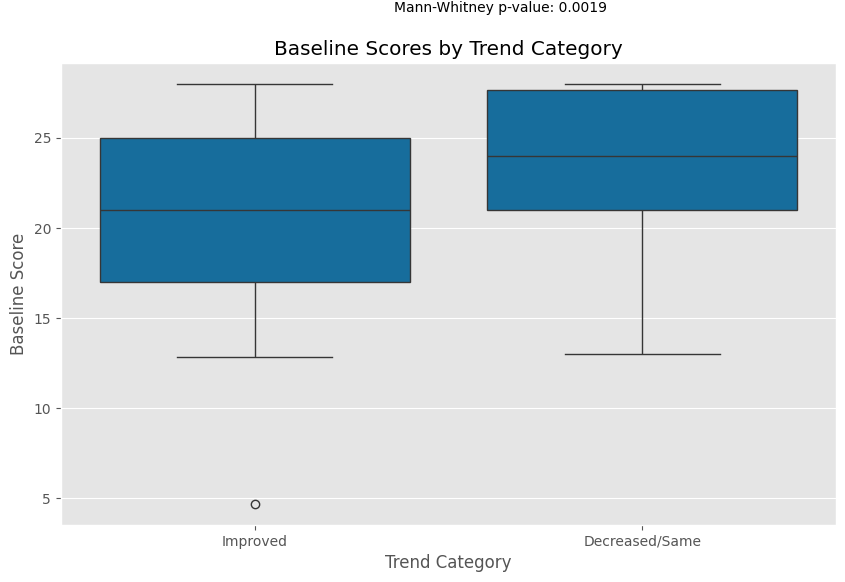

In [47]:
# Calculate odds ratio for a 10-point increase in baseline score
baseline_coef = result.params["swb_subscale_score_baseline"]
odds_ratio_10points = np.exp(baseline_coef * 10)
print(f"\nOdds Ratio for a 10-point increase in baseline score: {odds_ratio_10points:.3f}")

# Calculate confidence interval for the odds ratio
baseline_conf_int = result.conf_int().loc["swb_subscale_score_baseline"]
lower_ci_10points = np.exp(baseline_conf_int[0] * 10)
upper_ci_10points = np.exp(baseline_conf_int[1] * 10)
print(f"95% CI for a 10-point increase in baseline score: ({lower_ci_10points:.3f}, {upper_ci_10points:.3f})")

# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="swb_subscale_score_baseline", data=merged_df_removedNA_swb)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
                xycoords='figure fraction', ha='center')
plt.show()

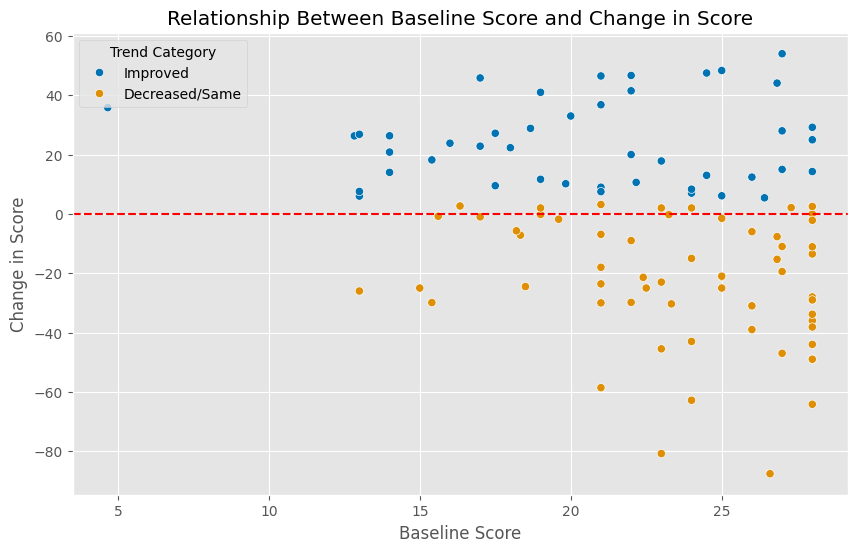

In [48]:
# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="swb_subscale_score_baseline", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_swb)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

# sensitivity analysis 0C) SWB baseline 

Sensitivity Analysis Results:
    threshold  improvement_rate  mean_swb_improved  mean_swb_not_improved  \
0           0          0.500000          21.156481              23.711008   
1           1          0.490741          21.027358              23.788990   
2           2          0.490741          21.027358              23.788990   
3           3          0.425926          20.626449              23.774642   
4           4          0.416667          20.618148              23.730600   
5           5          0.416667          20.618148              23.730600   
6           6          0.407407          20.486364              23.772569   
7           7          0.388889          20.557143              23.627946   
8           8          0.361111          20.651282              23.441224   
9           9          0.351852          20.563158              23.449206   
10         10          0.333333          20.636111              23.332562   

    mann_whitney_p  logistic_p  odds_ratio  


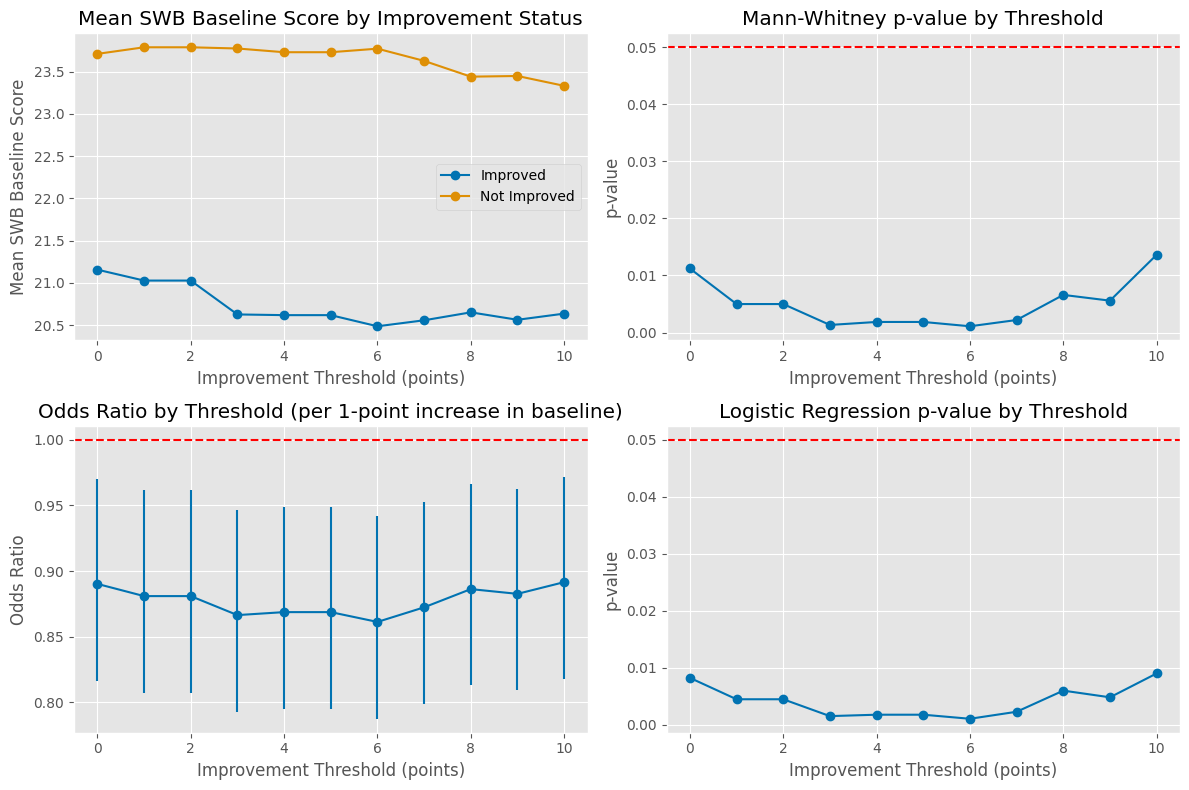


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              54                    54   50.000000   
1           1              53                    55   49.074074   
2           2              53                    55   49.074074   
3           3              46                    62   42.592593   
4           4              45                    63   41.666667   
5           5              45                    63   41.666667   
6           6              44                    64   40.740741   
7           7              42                    66   38.888889   
8           8              39                    69   36.111111   
9           9              38                    70   35.185185   
10         10              36                    72   33.333333   

    Decreased/Same %  
0          50.000000  
1          50.925926  
2          50.925926  
3          57.407407  
4          58.333333  
5          58.33

In [49]:
def analyze_improvement_threshold(data, threshold):
    """
    Analyze how the improvement threshold affects classification and baseline score relationship
    
    Parameters:
    data: DataFrame containing Baseline and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Mann-Whitney U test
    improved_baseline = df[df["Improved"]]["swb_subscale_score_baseline"]
    decreased_same_baseline = df[~df["Improved"]]["swb_subscale_score_baseline"]
    
    if len(improved_baseline) > 0 and len(decreased_same_baseline) > 0:
        stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
    else:
        stat, p_value = None, None
        
    # Mean swb_subscale_score_baseline in each group
    mean_swb_improved = improved_baseline.mean() if len(improved_baseline) > 0 else None
    mean_swb_not_improved = decreased_same_baseline.mean() if len(decreased_same_baseline) > 0 else None
    
    # Logistic regression
    X = sm.add_constant(df["swb_subscale_score_baseline"])
    y = df["Trend Category_binary"]
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        baseline_coef = result.params["swb_subscale_score_baseline"]
        baseline_p = result.pvalues["swb_subscale_score_baseline"]
        odds_ratio = np.exp(baseline_coef)
        
        # Confidence intervals
        baseline_conf_int = result.conf_int().loc["swb_subscale_score_baseline"]
        lower_ci = np.exp(baseline_conf_int[0])
        upper_ci = np.exp(baseline_conf_int[1])
    except:
        baseline_coef = None
        baseline_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mean_swb_improved": mean_swb_improved,
        "mean_swb_not_improved": mean_swb_not_improved,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": baseline_coef,
        "logistic_p": baseline_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean = merged_df_swb.dropna(subset=["swb_subscale_score_baseline", "Change"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_improvement_threshold(merged_df_clean, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_swb_improved", "mean_swb_not_improved", "mann_whitney_p", "logistic_p", "odds_ratio"]])


# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_swb_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_swb_not_improved"], 'o-', label='Not Improved')
plt.title("Mean SWB Baseline Score by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean SWB Baseline Score")
plt.legend()
plt.grid(True)

# Plot p-values from Mann-Whitney test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (per 1-point increase in baseline)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

In [50]:
# Just the confidence intervals
print("95% Confidence Intervals for Odds Ratios:")
for threshold in sensitivity_df['threshold']:
    row = sensitivity_df[sensitivity_df['threshold'] == threshold].iloc[0]
    lower = row['odds_ratio_lower_ci']
    upper = row['odds_ratio_upper_ci']
    or_val = row['odds_ratio']
    
    if pd.notna(or_val):
        print(f"Threshold {threshold}: OR = {or_val:.3f} (95% CI: {lower:.3f} - {upper:.3f})")
    else:
        print(f"Threshold {threshold}: OR = N/A")

95% Confidence Intervals for Odds Ratios:
Threshold 0: OR = 0.890 (95% CI: 0.817 - 0.970)
Threshold 1: OR = 0.881 (95% CI: 0.807 - 0.961)
Threshold 2: OR = 0.881 (95% CI: 0.807 - 0.961)
Threshold 3: OR = 0.866 (95% CI: 0.793 - 0.947)
Threshold 4: OR = 0.869 (95% CI: 0.795 - 0.949)
Threshold 5: OR = 0.869 (95% CI: 0.795 - 0.949)
Threshold 6: OR = 0.861 (95% CI: 0.787 - 0.942)
Threshold 7: OR = 0.872 (95% CI: 0.799 - 0.952)
Threshold 8: OR = 0.886 (95% CI: 0.813 - 0.966)
Threshold 9: OR = 0.883 (95% CI: 0.809 - 0.963)
Threshold 10: OR = 0.892 (95% CI: 0.818 - 0.972)


# statistically significantly associated with 0d) EWB baseline 

In [51]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [52]:
score_info = pd.read_csv("results.csv")
score_info

,id,baseline_type,pwb_subscale_score_baseline,pwb_subscale_score_one_year,pwb_subscale_score_improvement,pwb_subscale_score_has_improved,swb_subscale_score_baseline,swb_subscale_score_one_year,swb_subscale_score_improvement,swb_subscale_score_has_improved,...,fact_g_total_improvement,fact_g_total_has_improved,fact_e_total_baseline,fact_e_total_one_year,fact_e_total_improvement,fact_e_total_has_improved,toi_baseline,toi_one_year,toi_improvement,toi_has_improved
0,32,baseline_arm_1,24.5,27.0,2.5,False,22.0,28.0,6.0,True,...,32.5,True,117.5,159.0,41.5,True,89.5,107.0,17.5,True
1,76,preoperative_arm_1,7.0,7.0,0.0,False,23.0,21.0,-2.0,False,...,-10.0,False,95.0,97.0,2.0,False,58.0,65.0,7.0,True
2,125,baseline_arm_1,21.0,22.0,1.0,False,17.5,21.0,3.5,False,...,7.5,True,119.5,129.0,9.5,True,81.0,89.0,8.0,True
3,160,baseline_arm_1,21.0,28.0,7.0,True,20.0,22.0,2.0,False,...,13.0,True,119.0,152.0,33.0,True,78.0,107.0,29.0,True
4,198,baseline_arm_1,25.0,26.5,1.5,False,13.0,18.0,5.0,True,...,12.0,True,133.0,139.0,6.0,True,103.0,98.0,-5.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,1571,baseline_arm_1,26.0,16.0,-10.0,False,28.0,28.0,0.0,False,...,-26.0,False,153.0,104.0,-49.0,False,109.0,61.0,-48.0,False
120,1572,baseline_arm_1,27.0,24.0,-3.0,False,13.0,21.0,8.0,True,...,-1.0,False,141.0,115.0,-26.0,False,109.0,76.0,-33.0,False
121,1615,baseline_arm_1,23.0,19.0,-4.0,False,24.0,22.0,-2.0,False,...,-1.0,False,126.0,111.0,-15.0,False,86.0,69.0,-17.0,False
122,1653,baseline_arm_1,21.0,26.0,5.0,True,19.0,21.0,2.0,False,...,9.0,True,112.0,153.0,41.0,True,75.0,116.0,41.0,True


In [53]:
merged_df_ewb = score_comparison.merge(score_info[["id", "ewb_subscale_score_baseline"]], on="id", how="left")

# Create a clean dataframe with no missing values in ewb_subscale_score_baseline
merged_df_removedNA_ewb = merged_df_ewb.dropna(subset=["ewb_subscale_score_baseline"])
merged_df_expanded_ewb = merged_df_removedNA_ewb.drop_duplicates()
merged_df_removedNA_ewb = merged_df_expanded_ewb.copy()
merged_df_removedNA_ewb


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,ewb_subscale_score_baseline
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,6.0
1,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,14.0
2,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,21.0
3,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,21.0
4,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,17.0
...,...,...,...,...,...,...,...,...
103,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,18.0
104,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,16.0
105,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,19.0
106,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,16.0


In [54]:
# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_ewb.groupby("Trend Category")["ewb_subscale_score_baseline"].describe())


Baseline scores by Trend Category:
                count       mean       std  min   25%   50%   75%   max
Trend Category                                                         
Decreased/Same   63.0  17.013228  4.477273  4.0  14.0  18.0  20.0  24.0
Improved         45.0  15.208889  4.702215  5.0  12.0  16.0  18.0  24.0


In [55]:
# Perform Mann-Whitney U test to compare Baseline scores between groups
improved_baseline = merged_df_removedNA_ewb[merged_df_removedNA_ewb["Trend Category"] == "Improved"]["ewb_subscale_score_baseline"]
decreased_same_baseline = merged_df_removedNA_ewb[merged_df_removedNA_ewb["Trend Category"] == "Decreased/Same"]["ewb_subscale_score_baseline"]

stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
print(f"\nMann-Whitney U test:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")


Mann-Whitney U test:
Statistic: 1097.5
p-value: 0.046093130849240674


In [56]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_ewb["Trend Category_binary"] = merged_df_removedNA_ewb["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Logistic regression with Baseline as predictor
X = sm.add_constant(merged_df_removedNA_ewb["ewb_subscale_score_baseline"])
y = merged_df_removedNA_ewb["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.660445
         Iterations 5

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  108
Model:                             Logit   Df Residuals:                      106
Method:                              MLE   Df Model:                            1
Date:                   Wed, 02 Jul 2025   Pseudo R-squ.:                 0.02760
Time:                           02:57:30   Log-Likelihood:                -71.328
converged:                          True   LL-Null:                       -73.353
Covariance Type:               nonrobust   LLR p-value:                   0.04418
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const               


Odds Ratio for a 10-point increase in baseline score: 0.420
95% CI for a 10-point increase in baseline score: (0.177, 0.996)


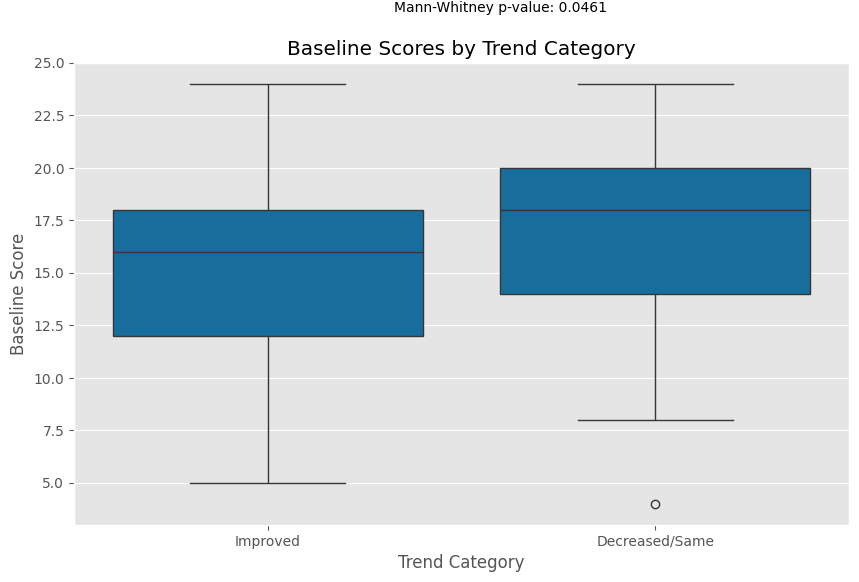

In [57]:
# Calculate odds ratio for a 10-point increase in baseline score
baseline_coef = result.params["ewb_subscale_score_baseline"]
odds_ratio_10points = np.exp(baseline_coef * 10)
print(f"\nOdds Ratio for a 10-point increase in baseline score: {odds_ratio_10points:.3f}")

# Calculate confidence interval for the odds ratio
baseline_conf_int = result.conf_int().loc["ewb_subscale_score_baseline"]
lower_ci_10points = np.exp(baseline_conf_int[0] * 10)
upper_ci_10points = np.exp(baseline_conf_int[1] * 10)
print(f"95% CI for a 10-point increase in baseline score: ({lower_ci_10points:.3f}, {upper_ci_10points:.3f})")

# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="ewb_subscale_score_baseline", data=merged_df_removedNA_ewb)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
             xycoords='figure fraction', ha='center')
plt.show()

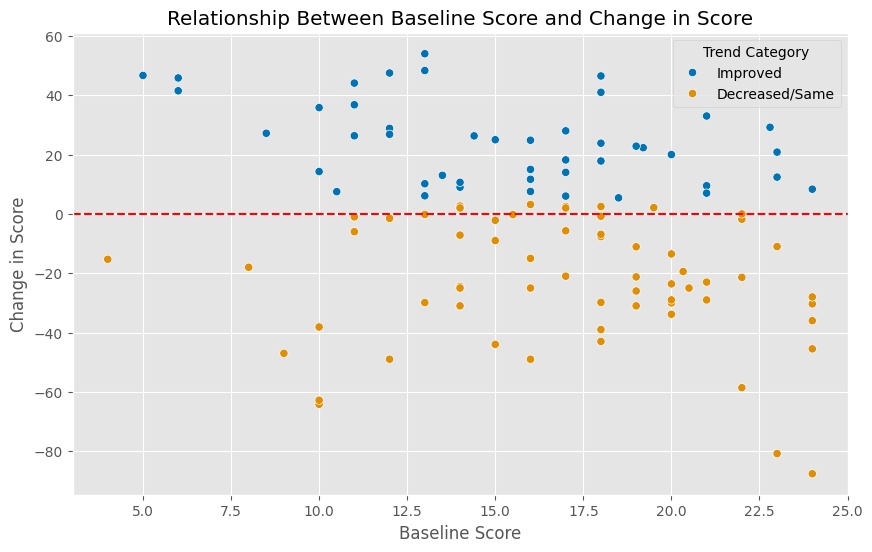

In [58]:

# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="ewb_subscale_score_baseline", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_ewb)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

# sensitivity analysis 0d) EWB baseline 

Sensitivity Analysis Results:
    threshold  improvement_rate  mean_ewb_improved  mean_ewb_not_improved  \
0           0          0.500000          15.479630              17.043210   
1           1          0.490741          15.356604              17.133333   
2           2          0.490741          15.356604              17.133333   
3           3          0.425926          15.226087              17.029570   
4           4          0.416667          15.208889              17.013228   
5           5          0.416667          15.208889              17.013228   
6           6          0.407407          15.134091              17.036458   
7           7          0.388889          15.140476              16.974747   
8           8          0.361111          15.087179              16.925121   
9           9          0.351852          14.852632              17.026190   
10         10          0.333333          14.705556              17.039352   

    mann_whitney_p  logistic_p  odds_ratio  


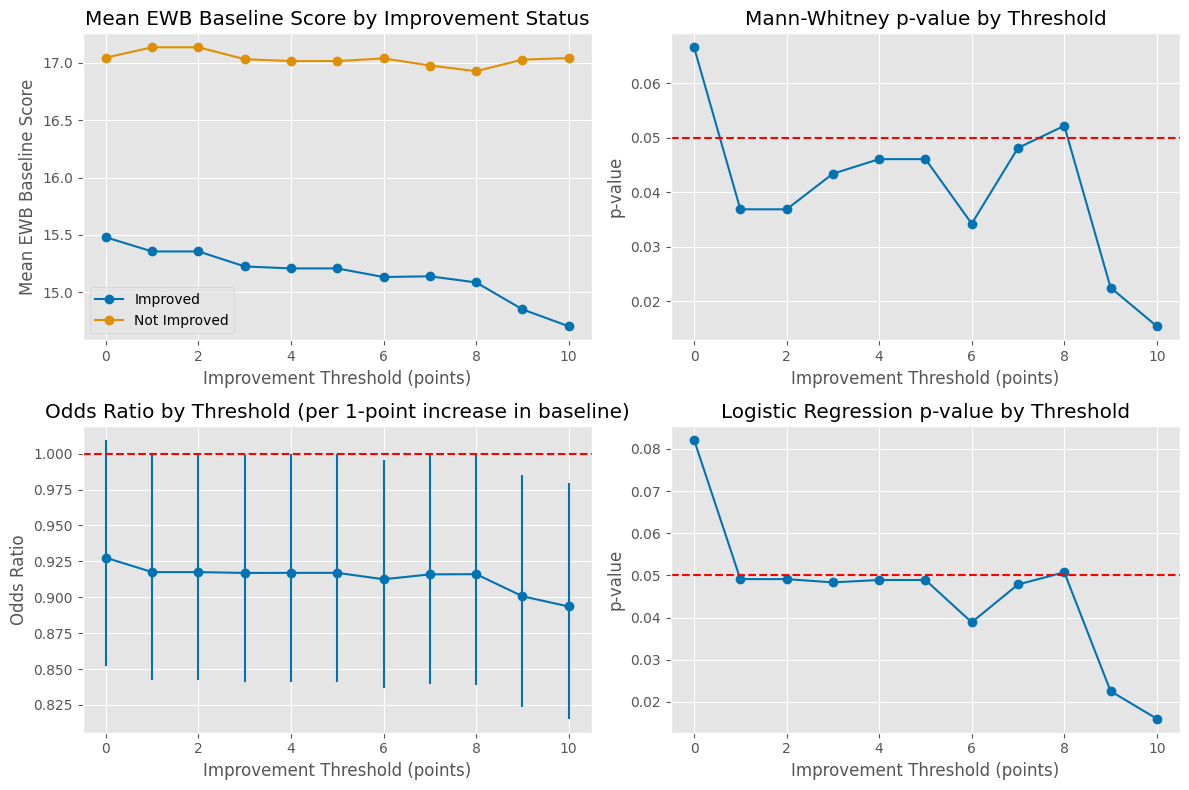


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              54                    54   50.000000   
1           1              53                    55   49.074074   
2           2              53                    55   49.074074   
3           3              46                    62   42.592593   
4           4              45                    63   41.666667   
5           5              45                    63   41.666667   
6           6              44                    64   40.740741   
7           7              42                    66   38.888889   
8           8              39                    69   36.111111   
9           9              38                    70   35.185185   
10         10              36                    72   33.333333   

    Decreased/Same %  
0          50.000000  
1          50.925926  
2          50.925926  
3          57.407407  
4          58.333333  
5          58.33

In [59]:
def analyze_improvement_threshold(data, threshold):
    """
    Analyze how the improvement threshold affects classification and baseline score relationship
    
    Parameters:
    data: DataFrame containing Baseline and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Mann-Whitney U test
    improved_baseline = df[df["Improved"]]["ewb_subscale_score_baseline"]
    decreased_same_baseline = df[~df["Improved"]]["ewb_subscale_score_baseline"]
    
    if len(improved_baseline) > 0 and len(decreased_same_baseline) > 0:
        stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
    else:
        stat, p_value = None, None
        
    # Mean ewb_subscale_score_baseline in each group
    mean_ewb_improved = improved_baseline.mean() if len(improved_baseline) > 0 else None
    mean_ewb_not_improved = decreased_same_baseline.mean() if len(decreased_same_baseline) > 0 else None
    
    # Logistic regression
    X = sm.add_constant(df["ewb_subscale_score_baseline"])
    y = df["Trend Category_binary"]
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        baseline_coef = result.params["ewb_subscale_score_baseline"]
        baseline_p = result.pvalues["ewb_subscale_score_baseline"]
        odds_ratio = np.exp(baseline_coef)
        
        # Confidence intervals
        baseline_conf_int = result.conf_int().loc["ewb_subscale_score_baseline"]
        lower_ci = np.exp(baseline_conf_int[0])
        upper_ci = np.exp(baseline_conf_int[1])
    except:
        baseline_coef = None
        baseline_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mean_ewb_improved": mean_ewb_improved,
        "mean_ewb_not_improved": mean_ewb_not_improved,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": baseline_coef,
        "logistic_p": baseline_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean = merged_df_ewb.dropna(subset=["ewb_subscale_score_baseline", "Change"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_improvement_threshold(merged_df_clean, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_ewb_improved", "mean_ewb_not_improved", "mann_whitney_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_ewb_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_ewb_not_improved"], 'o-', label='Not Improved')
plt.title("Mean EWB Baseline Score by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean EWB Baseline Score")
plt.legend()
plt.grid(True)

# Plot p-values from Mann-Whitney test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (per 1-point increase in baseline)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

In [60]:
# Just the confidence intervals
print("95% Confidence Intervals for Odds Ratios:")
for threshold in sensitivity_df['threshold']:
    row = sensitivity_df[sensitivity_df['threshold'] == threshold].iloc[0]
    lower = row['odds_ratio_lower_ci']
    upper = row['odds_ratio_upper_ci']
    or_val = row['odds_ratio']
    
    if pd.notna(or_val):
        print(f"Threshold {threshold}: OR = {or_val:.3f} (95% CI: {lower:.3f} - {upper:.3f})")
    else:
        print(f"Threshold {threshold}: OR = N/A")

95% Confidence Intervals for Odds Ratios:
Threshold 0: OR = 0.927 (95% CI: 0.852 - 1.010)
Threshold 1: OR = 0.918 (95% CI: 0.842 - 1.000)
Threshold 2: OR = 0.918 (95% CI: 0.842 - 1.000)
Threshold 3: OR = 0.917 (95% CI: 0.841 - 0.999)
Threshold 4: OR = 0.917 (95% CI: 0.841 - 1.000)
Threshold 5: OR = 0.917 (95% CI: 0.841 - 1.000)
Threshold 6: OR = 0.913 (95% CI: 0.837 - 0.995)
Threshold 7: OR = 0.916 (95% CI: 0.840 - 0.999)
Threshold 8: OR = 0.916 (95% CI: 0.839 - 1.000)
Threshold 9: OR = 0.901 (95% CI: 0.823 - 0.985)
Threshold 10: OR = 0.894 (95% CI: 0.815 - 0.979)


# statistically significantly associated with 0e) FWB baseline 

In [61]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [62]:
score_info = pd.read_csv("results.csv")
score_info

,id,baseline_type,pwb_subscale_score_baseline,pwb_subscale_score_one_year,pwb_subscale_score_improvement,pwb_subscale_score_has_improved,swb_subscale_score_baseline,swb_subscale_score_one_year,swb_subscale_score_improvement,swb_subscale_score_has_improved,...,fact_g_total_improvement,fact_g_total_has_improved,fact_e_total_baseline,fact_e_total_one_year,fact_e_total_improvement,fact_e_total_has_improved,toi_baseline,toi_one_year,toi_improvement,toi_has_improved
0,32,baseline_arm_1,24.5,27.0,2.5,False,22.0,28.0,6.0,True,...,32.5,True,117.5,159.0,41.5,True,89.5,107.0,17.5,True
1,76,preoperative_arm_1,7.0,7.0,0.0,False,23.0,21.0,-2.0,False,...,-10.0,False,95.0,97.0,2.0,False,58.0,65.0,7.0,True
2,125,baseline_arm_1,21.0,22.0,1.0,False,17.5,21.0,3.5,False,...,7.5,True,119.5,129.0,9.5,True,81.0,89.0,8.0,True
3,160,baseline_arm_1,21.0,28.0,7.0,True,20.0,22.0,2.0,False,...,13.0,True,119.0,152.0,33.0,True,78.0,107.0,29.0,True
4,198,baseline_arm_1,25.0,26.5,1.5,False,13.0,18.0,5.0,True,...,12.0,True,133.0,139.0,6.0,True,103.0,98.0,-5.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,1571,baseline_arm_1,26.0,16.0,-10.0,False,28.0,28.0,0.0,False,...,-26.0,False,153.0,104.0,-49.0,False,109.0,61.0,-48.0,False
120,1572,baseline_arm_1,27.0,24.0,-3.0,False,13.0,21.0,8.0,True,...,-1.0,False,141.0,115.0,-26.0,False,109.0,76.0,-33.0,False
121,1615,baseline_arm_1,23.0,19.0,-4.0,False,24.0,22.0,-2.0,False,...,-1.0,False,126.0,111.0,-15.0,False,86.0,69.0,-17.0,False
122,1653,baseline_arm_1,21.0,26.0,5.0,True,19.0,21.0,2.0,False,...,9.0,True,112.0,153.0,41.0,True,75.0,116.0,41.0,True


In [63]:
merged_df_fwb = score_comparison.merge(score_info[["id", "fwb_subscale_score_baseline"]], on="id", how="left")
# Create a clean dataframe with no missing values in fwb_subscale_score_baseline
merged_df_removedNA_fwb = merged_df_fwb.dropna(subset=["fwb_subscale_score_baseline"])
merged_df_expanded_fwb = merged_df_removedNA_fwb.drop_duplicates()
merged_df_removedNA_fwb = merged_df_expanded_fwb.copy()
merged_df_removedNA_fwb


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,fwb_subscale_score_baseline
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,19.0
1,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,15.0
2,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,8.0
3,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,20.0
4,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,21.0
...,...,...,...,...,...,...,...,...
103,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,18.0
104,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,25.0
105,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,20.0
106,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,12.0


In [64]:
# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_fwb.groupby("Trend Category")["fwb_subscale_score_baseline"].describe())


Baseline scores by Trend Category:
                count       mean       std  min   25%    50%   75%        max
Trend Category                                                               
Decreased/Same   63.0  20.466931  6.281614  7.0  15.0  21.75  26.0  28.000000
Improved         45.0  16.814815  6.210351  2.0  13.0  17.00  21.0  26.833333


In [65]:
# Perform Mann-Whitney U test to compare Baseline scores between groups
improved_baseline = merged_df_removedNA_fwb[merged_df_removedNA_fwb["Trend Category"] == "Improved"]["fwb_subscale_score_baseline"]
decreased_same_baseline = merged_df_removedNA_fwb[merged_df_removedNA_fwb["Trend Category"] == "Decreased/Same"]["fwb_subscale_score_baseline"]

stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
print(f"\nMann-Whitney U test:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")


Mann-Whitney U test:
Statistic: 941.0
p-value: 0.0029728277045343674


In [66]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_fwb["Trend Category_binary"] = merged_df_removedNA_fwb["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Logistic regression with Baseline as predictor
X = sm.add_constant(merged_df_removedNA_fwb["fwb_subscale_score_baseline"])
y = merged_df_removedNA_fwb["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.639565
         Iterations 5

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  108
Model:                             Logit   Df Residuals:                      106
Method:                              MLE   Df Model:                            1
Date:                   Wed, 02 Jul 2025   Pseudo R-squ.:                 0.05835
Time:                           02:57:31   Log-Likelihood:                -69.073
converged:                          True   LL-Null:                       -73.353
Covariance Type:               nonrobust   LLR p-value:                  0.003437
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const               


Odds Ratio for a 10-point increase in baseline score: 0.400
95% CI for a 10-point increase in baseline score: (0.212, 0.758)


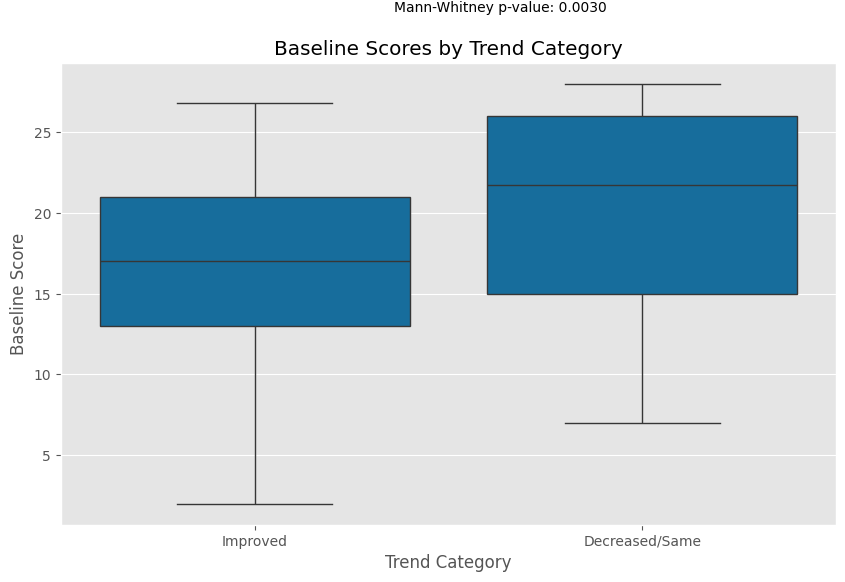

In [67]:
# Calculate odds ratio for a 10-point increase in baseline score
baseline_coef = result.params["fwb_subscale_score_baseline"]
odds_ratio_10points = np.exp(baseline_coef * 10)
print(f"\nOdds Ratio for a 10-point increase in baseline score: {odds_ratio_10points:.3f}")

# Calculate confidence interval for the odds ratio
baseline_conf_int = result.conf_int().loc["fwb_subscale_score_baseline"]
lower_ci_10points = np.exp(baseline_conf_int[0] * 10)
upper_ci_10points = np.exp(baseline_conf_int[1] * 10)
print(f"95% CI for a 10-point increase in baseline score: ({lower_ci_10points:.3f}, {upper_ci_10points:.3f})")

# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="fwb_subscale_score_baseline", data=merged_df_removedNA_fwb)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
             xycoords='figure fraction', ha='center')
plt.show()


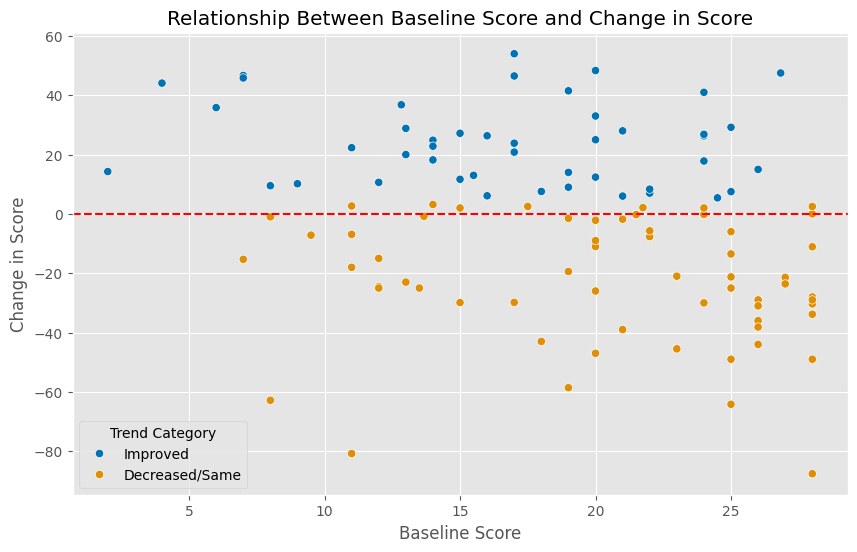

In [68]:
# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="fwb_subscale_score_baseline", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_fwb)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

# sensitivity analysis 0e) FWB baseline 

Sensitivity Analysis Results:
    threshold  improvement_rate  mean_fwb_improved  mean_fwb_not_improved  \
0           0          0.500000          17.405864              20.484568   
1           1          0.490741          17.205975              20.621212   
2           2          0.490741          17.205975              20.621212   
3           3          0.425926          16.753623              20.571237   
4           4          0.416667          16.814815              20.466931   
5           5          0.416667          16.814815              20.466931   
6           6          0.407407          16.640152              20.529948   
7           7          0.388889          16.551587              20.468434   
8           8          0.361111          16.158120              20.520531   
9           9          0.351852          16.004386              20.541667   
10         10          0.333333          16.143519              20.346065   

    mann_whitney_p  logistic_p  odds_ratio  


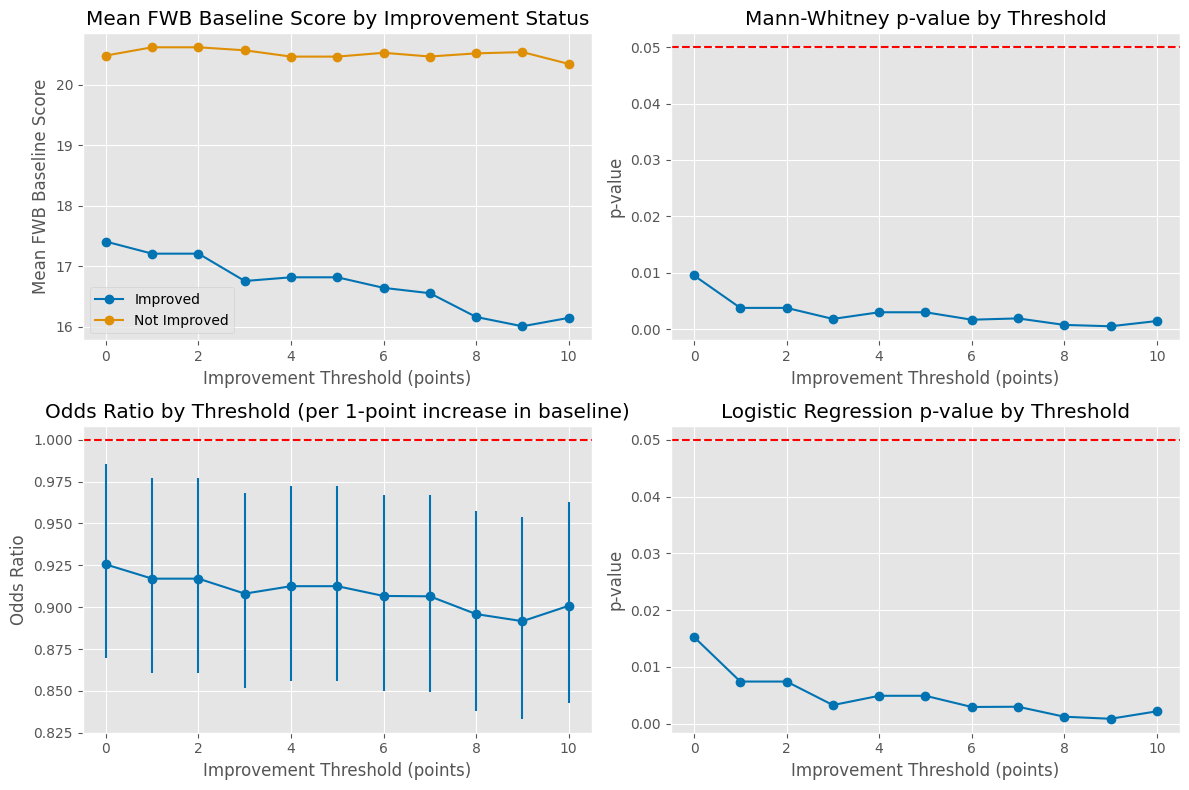


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              54                    54   50.000000   
1           1              53                    55   49.074074   
2           2              53                    55   49.074074   
3           3              46                    62   42.592593   
4           4              45                    63   41.666667   
5           5              45                    63   41.666667   
6           6              44                    64   40.740741   
7           7              42                    66   38.888889   
8           8              39                    69   36.111111   
9           9              38                    70   35.185185   
10         10              36                    72   33.333333   

    Decreased/Same %  
0          50.000000  
1          50.925926  
2          50.925926  
3          57.407407  
4          58.333333  
5          58.33

In [69]:
def analyze_improvement_threshold(data, threshold):
    """
    Analyze how the improvement threshold affects classification and baseline score relationship
    
    Parameters:
    data: DataFrame containing Baseline and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Mann-Whitney U test
    improved_baseline = df[df["Improved"]]["fwb_subscale_score_baseline"]
    decreased_same_baseline = df[~df["Improved"]]["fwb_subscale_score_baseline"]
    
    if len(improved_baseline) > 0 and len(decreased_same_baseline) > 0:
        stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
    else:
        stat, p_value = None, None
        
    # Mean fwb_subscale_score_baseline in each group
    mean_fwb_improved = improved_baseline.mean() if len(improved_baseline) > 0 else None
    mean_fwb_not_improved = decreased_same_baseline.mean() if len(decreased_same_baseline) > 0 else None
    
    # Logistic regression
    X = sm.add_constant(df["fwb_subscale_score_baseline"])
    y = df["Trend Category_binary"]
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        baseline_coef = result.params["fwb_subscale_score_baseline"]
        baseline_p = result.pvalues["fwb_subscale_score_baseline"]
        odds_ratio = np.exp(baseline_coef)
        
        # Confidence intervals
        baseline_conf_int = result.conf_int().loc["fwb_subscale_score_baseline"]
        lower_ci = np.exp(baseline_conf_int[0])
        upper_ci = np.exp(baseline_conf_int[1])
    except:
        baseline_coef = None
        baseline_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mean_fwb_improved": mean_fwb_improved,
        "mean_fwb_not_improved": mean_fwb_not_improved,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": baseline_coef,
        "logistic_p": baseline_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean = merged_df_fwb.dropna(subset=["fwb_subscale_score_baseline", "Change"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_improvement_threshold(merged_df_clean, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_fwb_improved", "mean_fwb_not_improved", "mann_whitney_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_fwb_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_fwb_not_improved"], 'o-', label='Not Improved')
plt.title("Mean FWB Baseline Score by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean FWB Baseline Score")
plt.legend()
plt.grid(True)

# Plot p-values from Mann-Whitney test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (per 1-point increase in baseline)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

In [70]:
# Just the confidence intervals
print("95% Confidence Intervals for Odds Ratios:")
for threshold in sensitivity_df['threshold']:
    row = sensitivity_df[sensitivity_df['threshold'] == threshold].iloc[0]
    lower = row['odds_ratio_lower_ci']
    upper = row['odds_ratio_upper_ci']
    or_val = row['odds_ratio']
    
    if pd.notna(or_val):
        print(f"Threshold {threshold}: OR = {or_val:.3f} (95% CI: {lower:.3f} - {upper:.3f})")
    else:
        print(f"Threshold {threshold}: OR = N/A")

95% Confidence Intervals for Odds Ratios:
Threshold 0: OR = 0.926 (95% CI: 0.869 - 0.985)
Threshold 1: OR = 0.917 (95% CI: 0.861 - 0.977)
Threshold 2: OR = 0.917 (95% CI: 0.861 - 0.977)
Threshold 3: OR = 0.908 (95% CI: 0.852 - 0.968)
Threshold 4: OR = 0.913 (95% CI: 0.856 - 0.973)
Threshold 5: OR = 0.913 (95% CI: 0.856 - 0.973)
Threshold 6: OR = 0.907 (95% CI: 0.850 - 0.967)
Threshold 7: OR = 0.906 (95% CI: 0.850 - 0.967)
Threshold 8: OR = 0.896 (95% CI: 0.838 - 0.958)
Threshold 9: OR = 0.892 (95% CI: 0.833 - 0.954)
Threshold 10: OR = 0.901 (95% CI: 0.843 - 0.963)


# statistically significantly associated with 0f) ECS baseline 

In [71]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [72]:
score_info = pd.read_csv("results.csv")
score_info

,id,baseline_type,pwb_subscale_score_baseline,pwb_subscale_score_one_year,pwb_subscale_score_improvement,pwb_subscale_score_has_improved,swb_subscale_score_baseline,swb_subscale_score_one_year,swb_subscale_score_improvement,swb_subscale_score_has_improved,...,fact_g_total_improvement,fact_g_total_has_improved,fact_e_total_baseline,fact_e_total_one_year,fact_e_total_improvement,fact_e_total_has_improved,toi_baseline,toi_one_year,toi_improvement,toi_has_improved
0,32,baseline_arm_1,24.5,27.0,2.5,False,22.0,28.0,6.0,True,...,32.5,True,117.5,159.0,41.5,True,89.5,107.0,17.5,True
1,76,preoperative_arm_1,7.0,7.0,0.0,False,23.0,21.0,-2.0,False,...,-10.0,False,95.0,97.0,2.0,False,58.0,65.0,7.0,True
2,125,baseline_arm_1,21.0,22.0,1.0,False,17.5,21.0,3.5,False,...,7.5,True,119.5,129.0,9.5,True,81.0,89.0,8.0,True
3,160,baseline_arm_1,21.0,28.0,7.0,True,20.0,22.0,2.0,False,...,13.0,True,119.0,152.0,33.0,True,78.0,107.0,29.0,True
4,198,baseline_arm_1,25.0,26.5,1.5,False,13.0,18.0,5.0,True,...,12.0,True,133.0,139.0,6.0,True,103.0,98.0,-5.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,1571,baseline_arm_1,26.0,16.0,-10.0,False,28.0,28.0,0.0,False,...,-26.0,False,153.0,104.0,-49.0,False,109.0,61.0,-48.0,False
120,1572,baseline_arm_1,27.0,24.0,-3.0,False,13.0,21.0,8.0,True,...,-1.0,False,141.0,115.0,-26.0,False,109.0,76.0,-33.0,False
121,1615,baseline_arm_1,23.0,19.0,-4.0,False,24.0,22.0,-2.0,False,...,-1.0,False,126.0,111.0,-15.0,False,86.0,69.0,-17.0,False
122,1653,baseline_arm_1,21.0,26.0,5.0,True,19.0,21.0,2.0,False,...,9.0,True,112.0,153.0,41.0,True,75.0,116.0,41.0,True


In [73]:
merged_df_ecs = score_comparison.merge(score_info[["id", "ecs_subscale_score_baseline"]], on="id", how="left")
# Create a clean dataframe with no missing values in ecs_subscale_score_baseline
merged_df_removedNA_ecs = merged_df_ecs.dropna(subset=["ecs_subscale_score_baseline"])
merged_df_expanded_ecs = merged_df_removedNA_ecs.drop_duplicates()
merged_df_removedNA_ecs = merged_df_expanded_ecs.copy()
merged_df_removedNA_ecs

,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,ecs_subscale_score_baseline
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,46.0
1,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,36.0
2,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,52.0
3,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,37.0
4,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,57.0
...,...,...,...,...,...,...,...,...
103,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,67.0
104,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,58.0
105,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,62.0
106,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,51.0


In [74]:
# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_ecs.groupby("Trend Category")["ecs_subscale_score_baseline"].describe())



Baseline scores by Trend Category:
                count       mean        std      min        25%      50%  \
Trend Category                                                             
Decreased/Same   63.0  52.762819  10.746101  23.0000  46.833333  55.0000   
Improved         45.0  42.654865   9.674324  24.4375  36.000000  41.4375   

                  75%   max  
Trend Category               
Decreased/Same  59.75  68.0  
Improved        49.00  65.0  


In [75]:
# Perform Mann-Whitney U test to compare Baseline scores between groups
improved_baseline = merged_df_removedNA_ecs[merged_df_removedNA_ecs["Trend Category"] == "Improved"]["ecs_subscale_score_baseline"]
decreased_same_baseline = merged_df_removedNA_ecs[merged_df_removedNA_ecs["Trend Category"] == "Decreased/Same"]["ecs_subscale_score_baseline"]

stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
print(f"\nMann-Whitney U test:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")


Mann-Whitney U test:
Statistic: 652.0
p-value: 1.8531509506848793e-06


In [76]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_ecs["Trend Category_binary"] = merged_df_removedNA_ecs["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Logistic regression with Baseline as predictor
X = sm.add_constant(merged_df_removedNA_ecs["ecs_subscale_score_baseline"])
y = merged_df_removedNA_ecs["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.576455
         Iterations 5

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  108
Model:                             Logit   Df Residuals:                      106
Method:                              MLE   Df Model:                            1
Date:                   Wed, 02 Jul 2025   Pseudo R-squ.:                  0.1513
Time:                           02:57:33   Log-Likelihood:                -62.257
converged:                          True   LL-Null:                       -73.353
Covariance Type:               nonrobust   LLR p-value:                 2.468e-06
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const               


Odds Ratio for a 10-point increase in baseline score: 0.405
95% CI for a 10-point increase in baseline score: (0.266, 0.617)


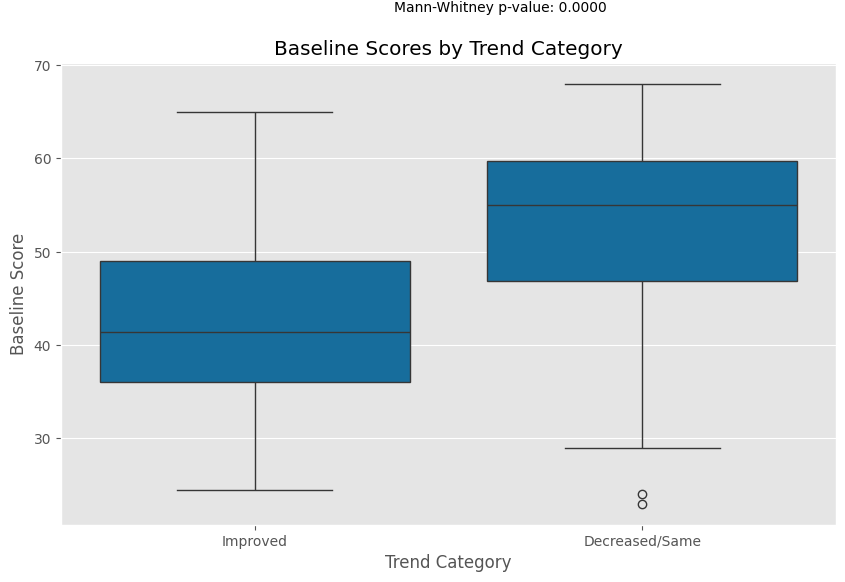

In [77]:
# Calculate odds ratio for a 10-point increase in baseline score
baseline_coef = result.params["ecs_subscale_score_baseline"]
odds_ratio_10points = np.exp(baseline_coef * 10)
print(f"\nOdds Ratio for a 10-point increase in baseline score: {odds_ratio_10points:.3f}")

# Calculate confidence interval for the odds ratio
baseline_conf_int = result.conf_int().loc["ecs_subscale_score_baseline"]
lower_ci_10points = np.exp(baseline_conf_int[0] * 10)
upper_ci_10points = np.exp(baseline_conf_int[1] * 10)
print(f"95% CI for a 10-point increase in baseline score: ({lower_ci_10points:.3f}, {upper_ci_10points:.3f})")

# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="ecs_subscale_score_baseline", data=merged_df_removedNA_ecs)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
             xycoords='figure fraction', ha='center')
plt.show()

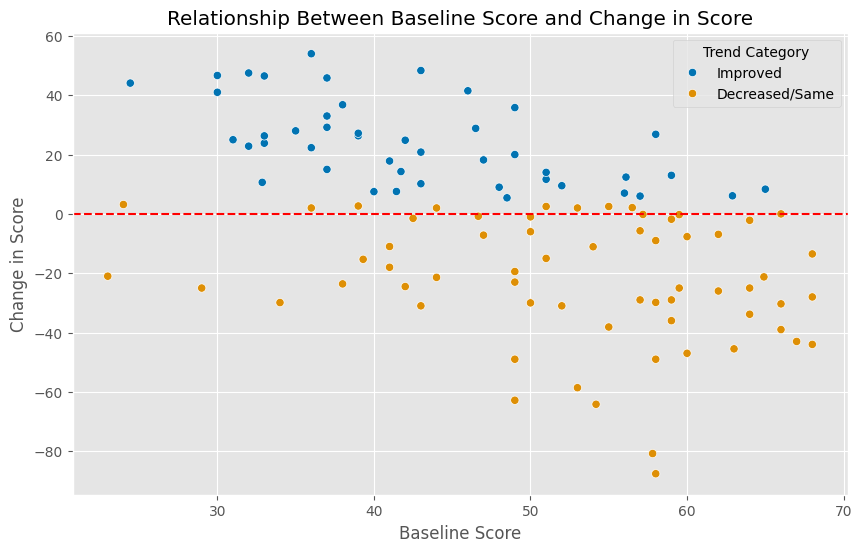

In [78]:
# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="ecs_subscale_score_baseline", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_ecs)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

# sensitivity analysis 0f) ECS baseline 

Sensitivity Analysis Results:
    threshold  improvement_rate  mean_ecs_improved  mean_ecs_not_improved  \
0           0          0.500000          43.406832              53.695511   
1           1          0.490741          42.980546              53.919229   
2           2          0.490741          42.980546              53.919229   
3           3          0.425926          42.249325              53.226735   
4           4          0.416667          42.654865              52.762819   
5           5          0.416667          42.654865              52.762819   
6           6          0.407407          42.522021              52.696212   
7           7          0.388889          41.692118              52.916024   
8           8          0.361111          41.375165              52.607175   
9           9          0.351852          40.753459              52.784215   
10         10          0.333333          40.239762              52.706876   

    mann_whitney_p  logistic_p  odds_ratio  


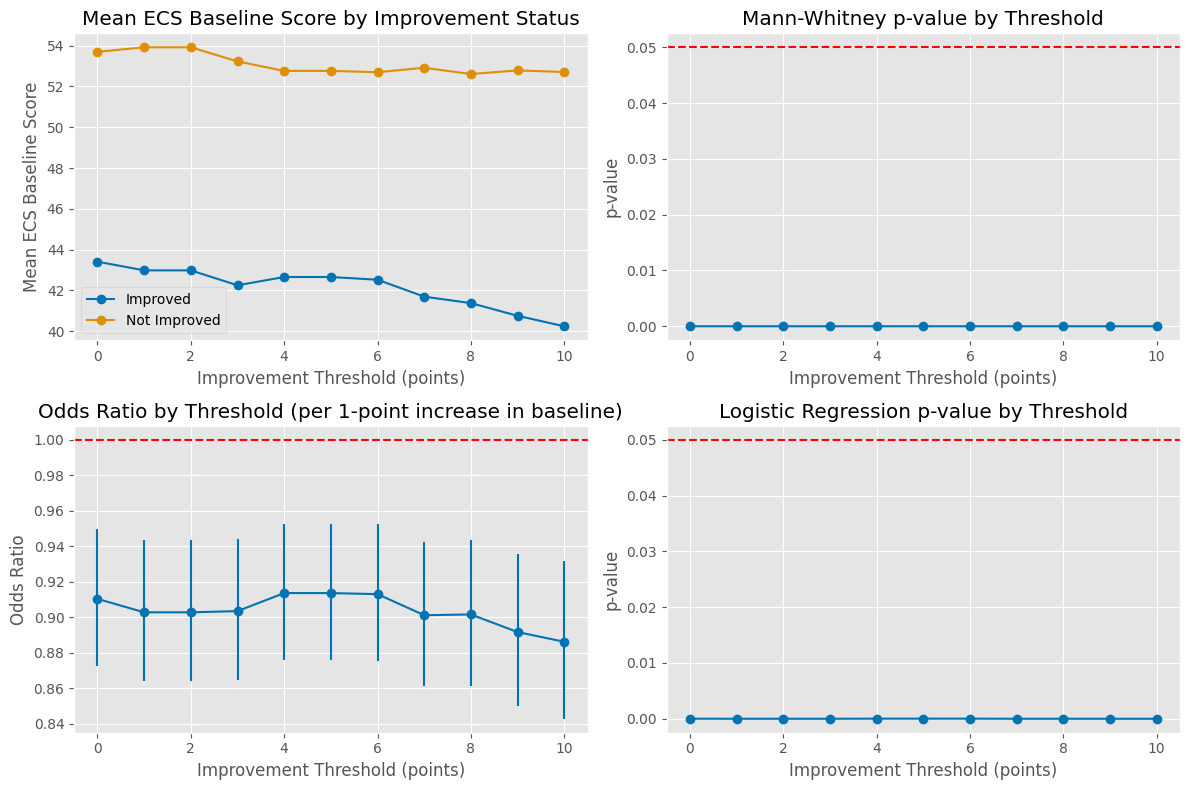


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              54                    54   50.000000   
1           1              53                    55   49.074074   
2           2              53                    55   49.074074   
3           3              46                    62   42.592593   
4           4              45                    63   41.666667   
5           5              45                    63   41.666667   
6           6              44                    64   40.740741   
7           7              42                    66   38.888889   
8           8              39                    69   36.111111   
9           9              38                    70   35.185185   
10         10              36                    72   33.333333   

    Decreased/Same %  
0          50.000000  
1          50.925926  
2          50.925926  
3          57.407407  
4          58.333333  
5          58.33

In [79]:
def analyze_improvement_threshold(data, threshold):
    """
    Analyze how the improvement threshold affects classification and baseline score relationship
    
    Parameters:
    data: DataFrame containing Baseline and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Mann-Whitney U test
    improved_baseline = df[df["Improved"]]["ecs_subscale_score_baseline"]
    decreased_same_baseline = df[~df["Improved"]]["ecs_subscale_score_baseline"]
    
    if len(improved_baseline) > 0 and len(decreased_same_baseline) > 0:
        stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
    else:
        stat, p_value = None, None
        
    # Mean ecs_subscale_score_baseline in each group
    mean_ecs_improved = improved_baseline.mean() if len(improved_baseline) > 0 else None
    mean_ecs_not_improved = decreased_same_baseline.mean() if len(decreased_same_baseline) > 0 else None
    
    # Logistic regression
    X = sm.add_constant(df["ecs_subscale_score_baseline"])
    y = df["Trend Category_binary"]
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        baseline_coef = result.params["ecs_subscale_score_baseline"]
        baseline_p = result.pvalues["ecs_subscale_score_baseline"]
        odds_ratio = np.exp(baseline_coef)
        
        # Confidence intervals
        baseline_conf_int = result.conf_int().loc["ecs_subscale_score_baseline"]
        lower_ci = np.exp(baseline_conf_int[0])
        upper_ci = np.exp(baseline_conf_int[1])
    except:
        baseline_coef = None
        baseline_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mean_ecs_improved": mean_ecs_improved,
        "mean_ecs_not_improved": mean_ecs_not_improved,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": baseline_coef,
        "logistic_p": baseline_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean = merged_df_ecs.dropna(subset=["ecs_subscale_score_baseline", "Change"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_improvement_threshold(merged_df_clean, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_ecs_improved", "mean_ecs_not_improved", "mann_whitney_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_ecs_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_ecs_not_improved"], 'o-', label='Not Improved')
plt.title("Mean ECS Baseline Score by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean ECS Baseline Score")
plt.legend()
plt.grid(True)

# Plot p-values from Mann-Whitney test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (per 1-point increase in baseline)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

In [80]:
# Just the confidence intervals
print("95% Confidence Intervals for Odds Ratios:")
for threshold in sensitivity_df['threshold']:
    row = sensitivity_df[sensitivity_df['threshold'] == threshold].iloc[0]
    lower = row['odds_ratio_lower_ci']
    upper = row['odds_ratio_upper_ci']
    or_val = row['odds_ratio']
    
    if pd.notna(or_val):
        print(f"Threshold {threshold}: OR = {or_val:.3f} (95% CI: {lower:.3f} - {upper:.3f})")
    else:
        print(f"Threshold {threshold}: OR = N/A")

95% Confidence Intervals for Odds Ratios:
Threshold 0: OR = 0.910 (95% CI: 0.873 - 0.950)
Threshold 1: OR = 0.903 (95% CI: 0.864 - 0.943)
Threshold 2: OR = 0.903 (95% CI: 0.864 - 0.943)
Threshold 3: OR = 0.903 (95% CI: 0.865 - 0.944)
Threshold 4: OR = 0.914 (95% CI: 0.876 - 0.953)
Threshold 5: OR = 0.914 (95% CI: 0.876 - 0.953)
Threshold 6: OR = 0.913 (95% CI: 0.875 - 0.952)
Threshold 7: OR = 0.901 (95% CI: 0.861 - 0.943)
Threshold 8: OR = 0.902 (95% CI: 0.862 - 0.944)
Threshold 9: OR = 0.892 (95% CI: 0.850 - 0.936)
Threshold 10: OR = 0.886 (95% CI: 0.843 - 0.932)


# statistically significantly associated with 1) BMI 

In [81]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [82]:
merged_df_bmi = score_comparison.merge(filtered_df[["id", "bmi"]], on="id", how="left")

# Calculate median BMI from all non-missing values
median_bmi = merged_df_bmi['bmi'].median()

# Find patient IDs where all BMI values are missing
patients_all_missing = merged_df_bmi.groupby('id')['bmi'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute BMI for those patients
mask = merged_df_bmi['id'].isin(patients_to_impute)
merged_df_bmi.loc[mask, 'bmi'] = median_bmi
print(f"Imputed {len(patients_to_impute)} missing patients with median BMI: {median_bmi:.2f}")

# Replace BMI outliers with NA (outside range 7-186)
outlier_mask = (merged_df_bmi['bmi'] < 7) | (merged_df_bmi['bmi'] > 186)
outlier_count = outlier_mask.sum()
merged_df_bmi.loc[outlier_mask, 'bmi'] = median_bmi

print(f"Replaced {outlier_count} outlier BMI values with median BMI: {median_bmi:.2f}")

# Create a clean dataframe with no missing values in bmi
merged_df_removedNA_bmi = merged_df_bmi.dropna(subset=["bmi"])
merged_df_expanded_bmi = merged_df_removedNA_bmi.drop_duplicates()
merged_df_removedNA_bmi = merged_df_expanded_bmi.copy()
merged_df_removedNA_bmi


Imputed 4 missing patients with median BMI: 25.86
Replaced 2 outlier BMI values with median BMI: 25.86


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,bmi
3,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,46.075514
15,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,25.360019
21,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,34.213824
34,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,27.115631
41,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,32.922429
...,...,...,...,...,...,...,...,...
1155,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,27.297959
1167,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,33.217993
1180,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,39.100346
1188,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,39.446367


In [83]:
# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_bmi.groupby("Trend Category")["bmi"].describe())



Baseline scores by Trend Category:
                count       mean       std        min        25%        50%  \
Trend Category                                                                
Decreased/Same   63.0  26.944669  6.453258  14.677098  23.046188  25.856286   
Improved         45.0  26.328577  5.001247  17.175320  23.824953  25.951557   

                      75%        max  
Trend Category                        
Decreased/Same  30.980716  45.923460  
Improved        28.226599  46.075514  


In [84]:
# Perform Mann-Whitney U test to compare Baseline scores between groups
improved_baseline = merged_df_removedNA_bmi[merged_df_removedNA_bmi["Trend Category"] == "Improved"]["bmi"]
decreased_same_baseline = merged_df_removedNA_bmi[merged_df_removedNA_bmi["Trend Category"] == "Decreased/Same"]["bmi"]

stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
print(f"\nMann-Whitney U test:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")


Mann-Whitney U test:
Statistic: 1394.5
p-value: 0.8884779141425714


In [85]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_bmi["Trend Category_binary"] = merged_df_removedNA_bmi["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Logistic regression with Baseline as predictor
X = sm.add_constant(merged_df_removedNA_bmi["bmi"])
y = merged_df_removedNA_bmi["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.677835
         Iterations 4

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  108
Model:                             Logit   Df Residuals:                      106
Method:                              MLE   Df Model:                            1
Date:                   Wed, 02 Jul 2025   Pseudo R-squ.:                0.002000
Time:                           02:57:34   Log-Likelihood:                -73.206
converged:                          True   LL-Null:                       -73.353
Covariance Type:               nonrobust   LLR p-value:                    0.5881
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1487      0.919      0.162      0.871


Odds Ratio for a 10-point increase in baseline score: 0.833
95% CI for a 10-point increase in baseline score: (0.430, 1.617)


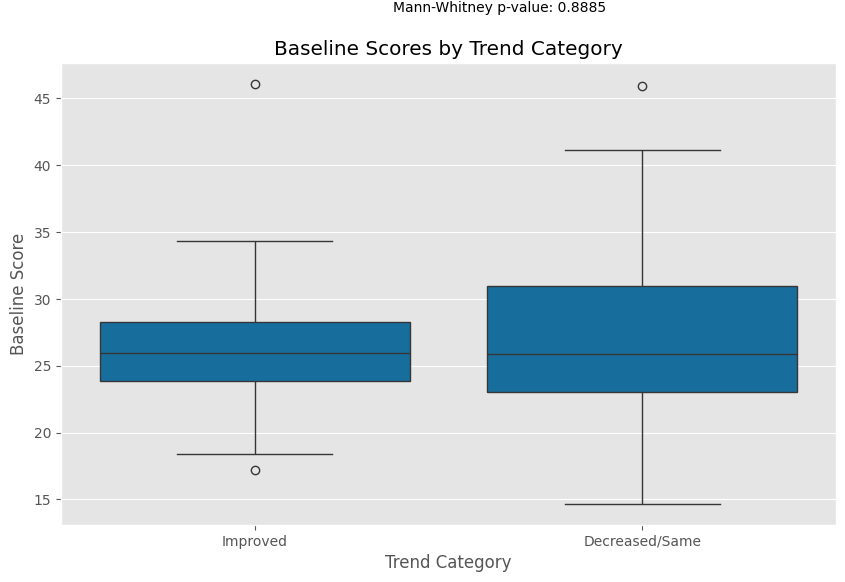

In [86]:
# Calculate odds ratio for a 10-point increase in baseline score
baseline_coef = result.params["bmi"]
odds_ratio_10points = np.exp(baseline_coef * 10)
print(f"\nOdds Ratio for a 10-point increase in baseline score: {odds_ratio_10points:.3f}")

# Calculate confidence interval for the odds ratio
baseline_conf_int = result.conf_int().loc["bmi"]
lower_ci_10points = np.exp(baseline_conf_int[0] * 10)
upper_ci_10points = np.exp(baseline_conf_int[1] * 10)
print(f"95% CI for a 10-point increase in baseline score: ({lower_ci_10points:.3f}, {upper_ci_10points:.3f})")

# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="bmi", data=merged_df_removedNA_bmi)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
                xycoords='figure fraction', ha='center')
plt.show()

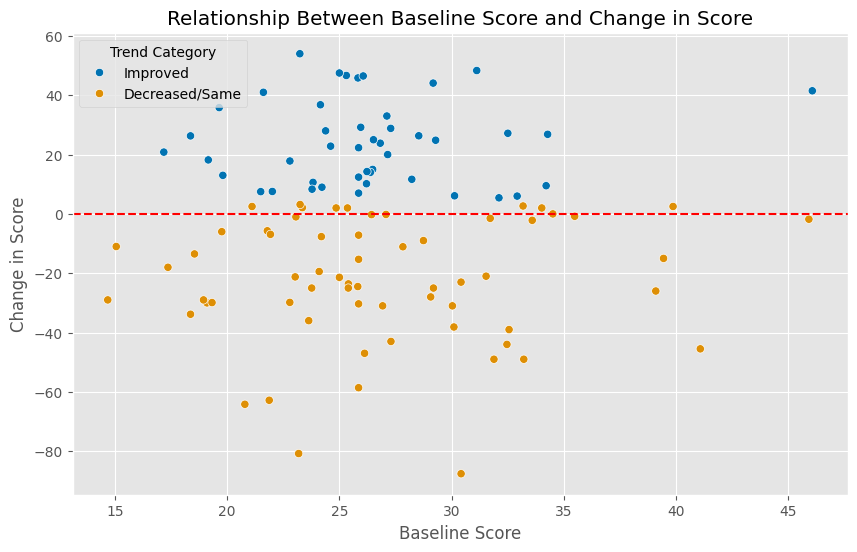

In [87]:
# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="bmi", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_bmi)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

# sensitivity analysis 1) BMI

Sensitivity Analysis Results:
    threshold  improvement_rate  mean_bmi_improved  mean_bmi_not_improved  \
0           0          0.500000          26.746112              26.629816   
1           1          0.490741          26.599595              26.773120   
2           2          0.490741          26.599595              26.773120   
3           3          0.425926          26.261629              27.004277   
4           4          0.416667          26.328577              26.944669   
5           5          0.416667          26.328577              26.944669   
6           6          0.407407          26.197138              27.025407   
7           7          0.388889          25.943301              27.161840   
8           8          0.361111          26.160436              26.986132   
9           9          0.351852          26.223025              26.940359   
10         10          0.333333          26.056647              27.003623   

    mann_whitney_p  logistic_p  odds_ratio  


<Figure size 1000x600 with 0 Axes>

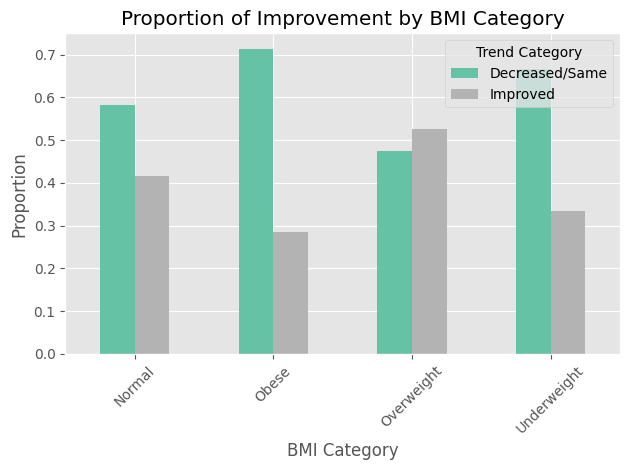

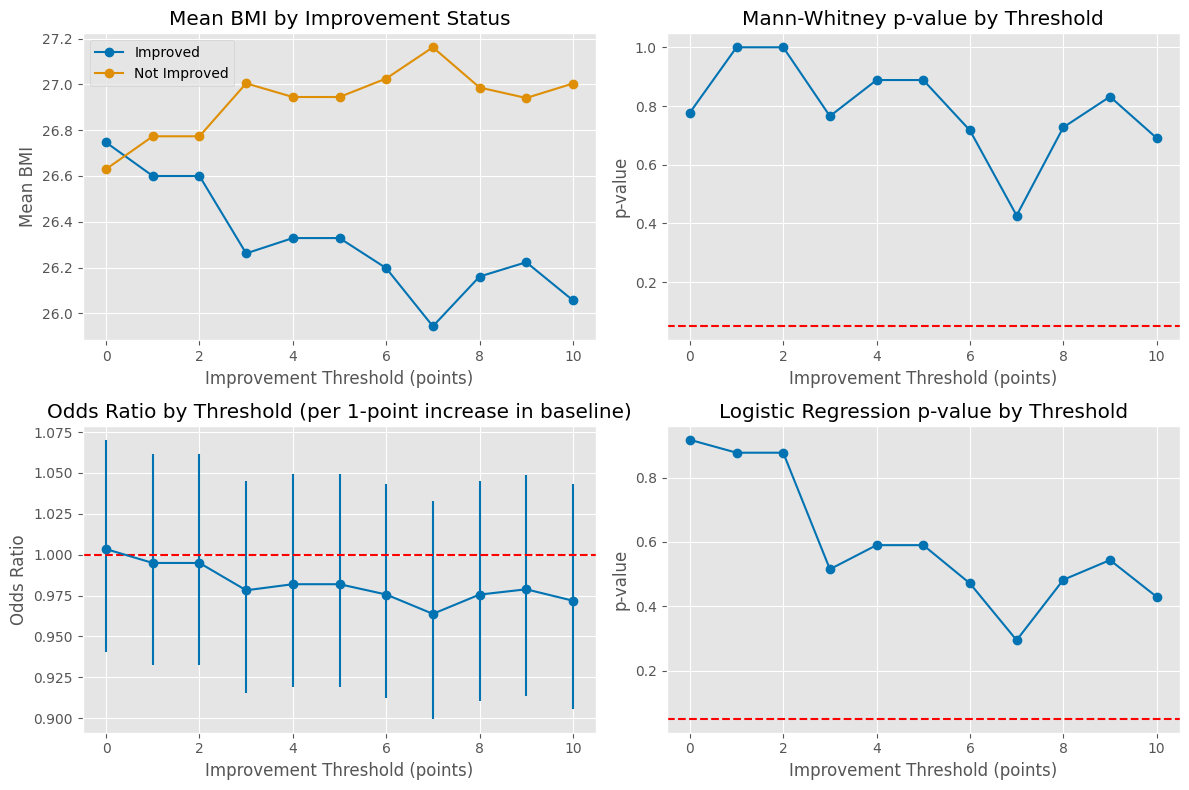


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              54                    54   50.000000   
1           1              53                    55   49.074074   
2           2              53                    55   49.074074   
3           3              46                    62   42.592593   
4           4              45                    63   41.666667   
5           5              45                    63   41.666667   
6           6              44                    64   40.740741   
7           7              42                    66   38.888889   
8           8              39                    69   36.111111   
9           9              38                    70   35.185185   
10         10              36                    72   33.333333   

    Decreased/Same %  
0          50.000000  
1          50.925926  
2          50.925926  
3          57.407407  
4          58.333333  
5          58.33

In [88]:
def analyze_improvement_threshold(data, threshold):
    """
    Analyze how the improvement threshold affects classification and baseline score relationship
    
    Parameters:
    data: DataFrame containing Baseline and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Mann-Whitney U test
    improved_baseline = df[df["Improved"]]["bmi"]
    decreased_same_baseline = df[~df["Improved"]]["bmi"]
    
    if len(improved_baseline) > 0 and len(decreased_same_baseline) > 0:
        stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
    else:
        stat, p_value = None, None
        
    # Mean bmi in each group
    mean_bmi_improved = improved_baseline.mean() if len(improved_baseline) > 0 else None
    mean_bmi_not_improved = decreased_same_baseline.mean() if len(decreased_same_baseline) > 0 else None
    
    # Logistic regression
    X = sm.add_constant(df["bmi"])
    y = df["Trend Category_binary"]
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        baseline_coef = result.params["bmi"]
        baseline_p = result.pvalues["bmi"]
        odds_ratio = np.exp(baseline_coef)
        
        # Confidence intervals
        baseline_conf_int = result.conf_int().loc["bmi"]
        lower_ci = np.exp(baseline_conf_int[0])
        upper_ci = np.exp(baseline_conf_int[1])
    except:
        baseline_coef = None
        baseline_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mean_bmi_improved": mean_bmi_improved,
        "mean_bmi_not_improved": mean_bmi_not_improved,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": baseline_coef,
        "logistic_p": baseline_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean = merged_df_bmi.dropna(subset=["bmi", "Change"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_improvement_threshold(merged_df_clean, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_bmi_improved", "mean_bmi_not_improved", "mann_whitney_p", "logistic_p", "odds_ratio"]])

print("\n### Analysis with BMI categories ###")
# Define clinical BMI categories
def categorize_bmi(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

# Add BMI category column
merged_df_clean["bmi_category"] = merged_df_clean["bmi"].apply(categorize_bmi)

# Create contingency table
contingency_table_bmi = pd.crosstab(merged_df_clean["Trend Category"],
                                    merged_df_clean["bmi_category"])
print("Contingency Table:")
print(contingency_table_bmi)

# Chi-square test
chi2_stat, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table_bmi)
print(f"Chi-Square Test p-value: {p_value_chi2}")

# Visualize the relationship between BMI categories and Trend Category
plt.figure(figsize=(10, 6))
proportions = pd.crosstab(merged_df_clean["bmi_category"],
                         merged_df_clean["Trend Category"],
                         normalize="index")
proportions.plot(kind="bar", stacked=False, colormap="Set2")
plt.title("Proportion of Improvement by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Proportion")
plt.legend(title="Trend Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_bmi_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_bmi_not_improved"], 'o-', label='Not Improved')
plt.title("Mean BMI by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean BMI")
plt.legend()
plt.grid(True)

# Plot p-values from Mann-Whitney test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (per 1-point increase in baseline)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

In [89]:
# Just the confidence intervals
print("95% Confidence Intervals for Odds Ratios:")
for threshold in sensitivity_df['threshold']:
    row = sensitivity_df[sensitivity_df['threshold'] == threshold].iloc[0]
    lower = row['odds_ratio_lower_ci']
    upper = row['odds_ratio_upper_ci']
    or_val = row['odds_ratio']
    
    if pd.notna(or_val):
        print(f"Threshold {threshold}: OR = {or_val:.3f} (95% CI: {lower:.3f} - {upper:.3f})")
    else:
        print(f"Threshold {threshold}: OR = N/A")

95% Confidence Intervals for Odds Ratios:
Threshold 0: OR = 1.003 (95% CI: 0.941 - 1.070)
Threshold 1: OR = 0.995 (95% CI: 0.933 - 1.061)
Threshold 2: OR = 0.995 (95% CI: 0.933 - 1.061)
Threshold 3: OR = 0.978 (95% CI: 0.915 - 1.045)
Threshold 4: OR = 0.982 (95% CI: 0.919 - 1.049)
Threshold 5: OR = 0.982 (95% CI: 0.919 - 1.049)
Threshold 6: OR = 0.976 (95% CI: 0.912 - 1.043)
Threshold 7: OR = 0.964 (95% CI: 0.900 - 1.033)
Threshold 8: OR = 0.976 (95% CI: 0.911 - 1.045)
Threshold 9: OR = 0.979 (95% CI: 0.914 - 1.049)
Threshold 10: OR = 0.972 (95% CI: 0.905 - 1.043)


# statistically significantly associated with 2) smoking

In [90]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [91]:
merged_df_smoking = score_comparison.merge(filtered_df[["id", "smoking"]], on="id", how="left")

print(merged_df_smoking['smoking'].value_counts())

# Find patient IDs where all smoking values are missing
patients_all_missing = merged_df_smoking.groupby('id')['smoking'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute smoking for those patients
mask = merged_df_smoking['id'].isin(patients_to_impute)
merged_df_smoking.loc[mask, 'smoking'] = 9999.0

print(f"Imputed {len(patients_to_impute)} missing data patients with mode smoking: 9999.0 (unknown)")

# Create a clean dataframe with no missing values in smoking
merged_df_removedNA_smoking = merged_df_smoking.dropna(subset=["smoking"])
merged_df_expanded_smoking = merged_df_removedNA_smoking.drop_duplicates()
merged_df_removedNA_smoking = merged_df_expanded_smoking.copy()
merged_df_removedNA_smoking


print(merged_df_removedNA_smoking['smoking'].value_counts())

smoking
3.0       31
0.0       29
1.0       16
9999.0     6
Name: count, dtype: int64
Imputed 26 missing data patients with mode smoking: 9999.0 (unknown)
smoking
9999.0    32
3.0       31
0.0       29
1.0       16
Name: count, dtype: int64


In [92]:
# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_smoking.groupby("Trend Category")["smoking"].describe())


Baseline scores by Trend Category:
                count         mean          std  min  25%  50%     75%     max
Trend Category                                                                
Decreased/Same   63.0  2699.142857  4473.365147  0.0  0.0  3.0  9999.0  9999.0
Improved         45.0  3334.022222  4766.105369  0.0  0.0  3.0  9999.0  9999.0


In [93]:
# Create smoking status labels
smoking_labels = {0: "Never smoked", 1: "Current smoker", 3: "Past smoker", 9999: "Unknown"}
merged_df_removedNA_smoking["smoking_status"] = merged_df_removedNA_smoking["smoking"].map(smoking_labels)

# Show summary statistics by improvement group and smoking status
print("\nCrosstab of Smoking Status and Trend Category:")
contingency_table = pd.crosstab(merged_df_removedNA_smoking["smoking_status"], 
                                merged_df_removedNA_smoking["Trend Category"])
print(contingency_table)


Crosstab of Smoking Status and Trend Category:
Trend Category  Decreased/Same  Improved
smoking_status                          
Current smoker              12         4
Never smoked                17        12
Past smoker                 17        14
Unknown                     17        15


In [94]:
# Chi-square test
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square test:")
print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value_chi2}")
print(f"Degrees of freedom: {dof}")


Chi-square test:
Chi-square statistic: 2.342459876052757
p-value: 0.5044355572896166
Degrees of freedom: 3


In [95]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_smoking["Trend Category_binary"] = merged_df_removedNA_smoking["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Clean data for logistic regression
clean_data = merged_df_removedNA_smoking.dropna(subset=["smoking", "Trend Category_binary"])

# Logistic regression with one-hot encoding for categorical smoking variable
smoking_dummies = pd.get_dummies(clean_data["smoking"], prefix="smoking", drop_first=True).astype(int)
X = sm.add_constant(smoking_dummies)
y = clean_data["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.667831
         Iterations 5

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  108
Model:                             Logit   Df Residuals:                      104
Method:                              MLE   Df Model:                            3
Date:                   Wed, 02 Jul 2025   Pseudo R-squ.:                 0.01673
Time:                           02:57:35   Log-Likelihood:                -72.126
converged:                          True   LL-Null:                       -73.353
Covariance Type:               nonrobust   LLR p-value:                    0.4836
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.3483      0.377     -0.92


Odds Ratio for smoking_1.0: 0.472
95% CI for smoking_1.0: (0.122, 1.824)


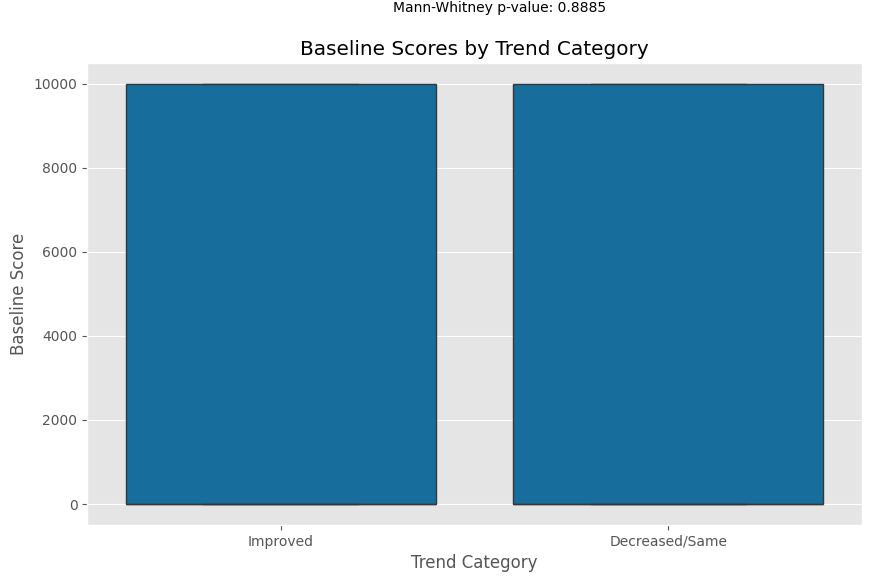

In [96]:
# Calculate odds ratio for smoking categories
smoking_cols = [col for col in result.params.index if col.startswith('smoking')]
if smoking_cols:
    first_smoking_col = smoking_cols[0]
    baseline_coef = result.params[first_smoking_col]
    odds_ratio_smoking = np.exp(baseline_coef)
    print(f"\nOdds Ratio for {first_smoking_col}: {odds_ratio_smoking:.3f}")
    
    # Calculate confidence interval for the odds ratio
    baseline_conf_int = result.conf_int().loc[first_smoking_col]
    lower_ci_smoking = np.exp(baseline_conf_int[0])
    upper_ci_smoking = np.exp(baseline_conf_int[1])
    print(f"95% CI for {first_smoking_col}: ({lower_ci_smoking:.3f}, {upper_ci_smoking:.3f})")

# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="smoking", data=merged_df_removedNA_smoking)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
             xycoords='figure fraction', ha='center')
plt.show()

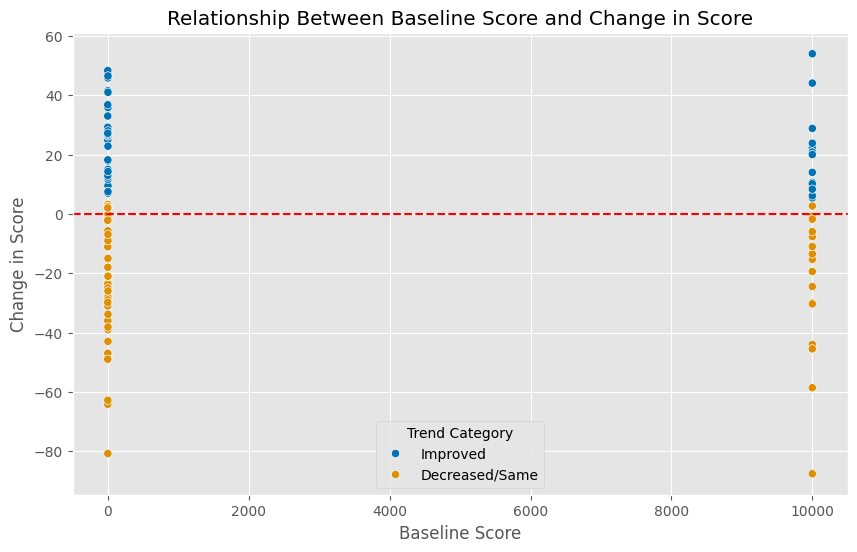

In [97]:
# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="smoking", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_smoking)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

In [98]:
# Calculate proportions for plotting
proportion_data = []
for smoking_val, label in smoking_labels.items():
    subset = merged_df_removedNA_smoking[merged_df_removedNA_smoking["smoking"] == smoking_val]
    if len(subset) > 0:
        improved_count = len(subset[subset["Trend Category"] == "Improved"])
        total_count = len(subset)
        proportion = improved_count / total_count
        proportion_data.append({
            "smoking_status": label,
            "proportion_improved": proportion,
            "total_count": total_count,
            "improved_count": improved_count
        })

proportion_df = pd.DataFrame(proportion_data)
print(f"\nProportion of improvement by smoking status:")
print(proportion_df)


Proportion of improvement by smoking status:
   smoking_status  proportion_improved  total_count  improved_count
0    Never smoked             0.413793           29              12
1  Current smoker             0.250000           16               4
2     Past smoker             0.451613           31              14
3         Unknown             0.468750           32              15


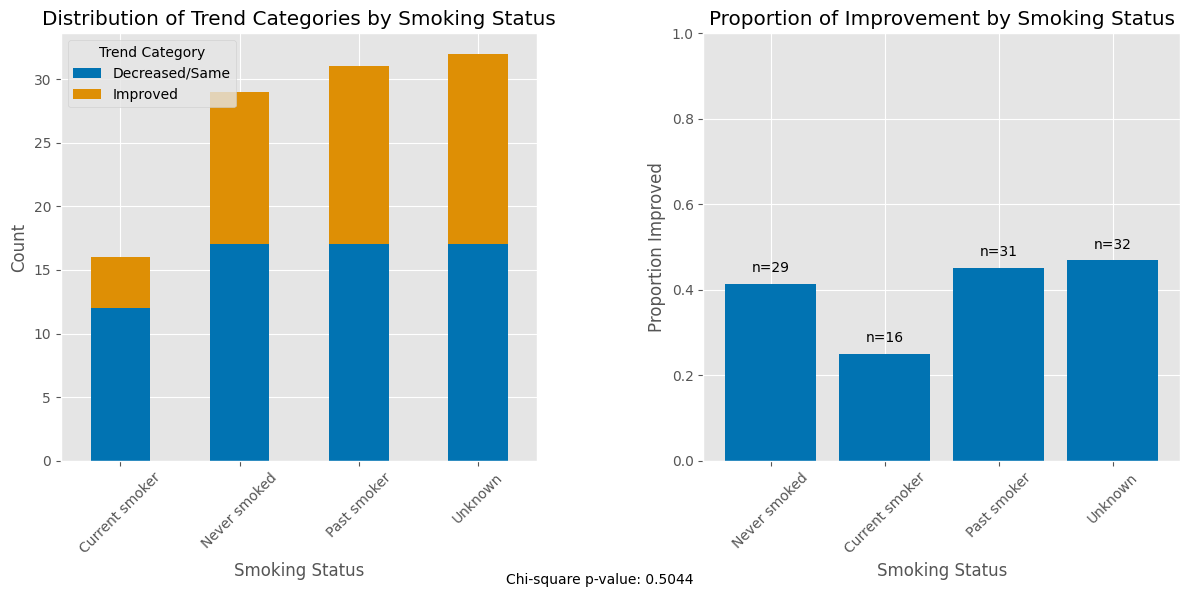

In [99]:
# Visualize with bar plot showing proportions
plt.figure(figsize=(12, 6))

# Subplot 1: Contingency table as stacked bar chart
plt.subplot(1, 2, 1)
contingency_table.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Distribution of Trend Categories by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Trend Category")

# Subplot 2: Proportion of improvement by smoking status
plt.subplot(1, 2, 2)
bars = plt.bar(proportion_df["smoking_status"], proportion_df["proportion_improved"])
plt.title("Proportion of Improvement by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Proportion Improved")
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Add count labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'n={proportion_df.iloc[i]["total_count"]}',
                ha='center', va='bottom')

plt.annotate(f"Chi-square p-value: {p_value_chi2:.4f}", xy=(0.5, 0.02), 
                xycoords='figure fraction', ha='center')

plt.tight_layout()
plt.show()

# sensitivity analysis 2) smoking

Sensitivity Analysis Results:
    threshold  improvement_rate    chi2_p  logistic_p  odds_ratio
0           0          0.500000  0.264513    0.052761    0.277778
1           1          0.490741  0.241225    0.052761    0.277778
2           2          0.490741  0.241225    0.052761    0.277778
3           3          0.425926  0.492119    0.195036    0.410256
4           4          0.416667  0.504436    0.276553    0.472222
5           5          0.416667  0.504436    0.276553    0.472222
6           6          0.407407  0.568702    0.276553    0.472222
7           7          0.388889  0.590541    0.276553    0.472222
8           8          0.361111  0.797548    0.198156    0.545455
9           9          0.351852  0.800825    0.198156    0.545455
10         10          0.333333  0.824733    0.198156    0.545455


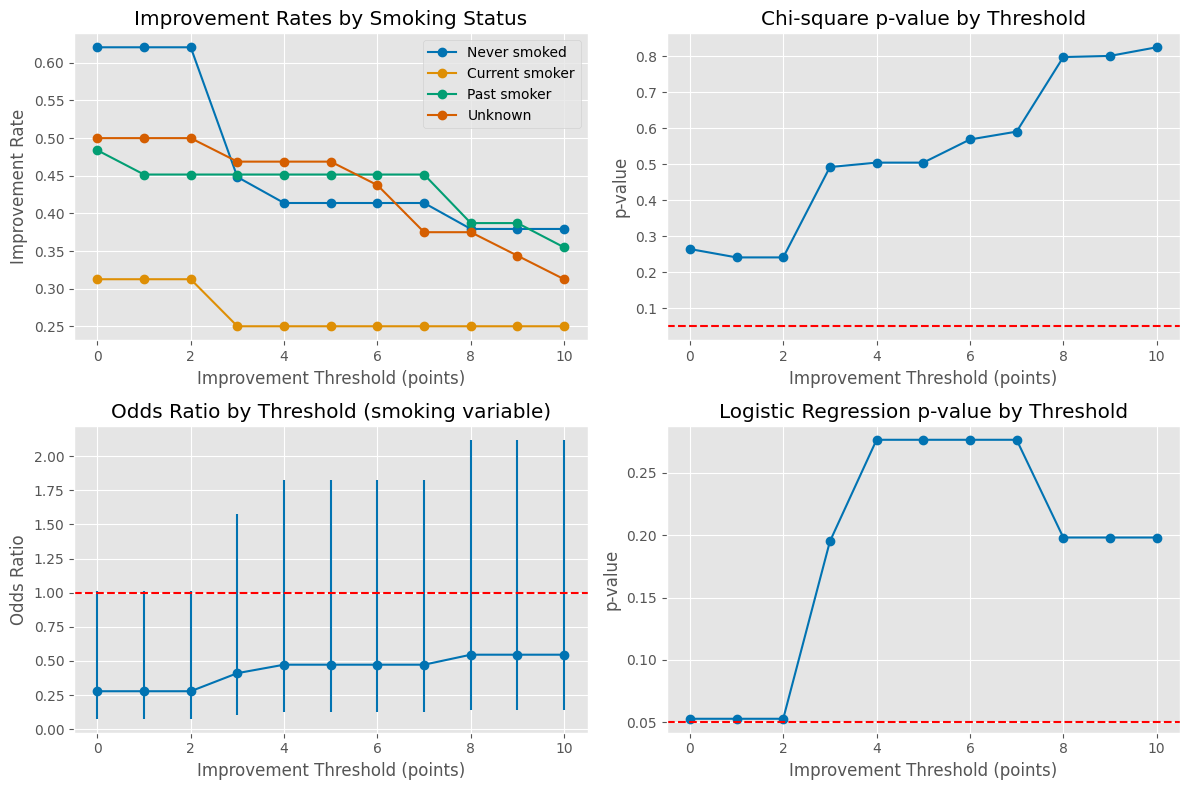


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              54                    54   50.000000   
1           1              53                    55   49.074074   
2           2              53                    55   49.074074   
3           3              46                    62   42.592593   
4           4              45                    63   41.666667   
5           5              45                    63   41.666667   
6           6              44                    64   40.740741   
7           7              42                    66   38.888889   
8           8              39                    69   36.111111   
9           9              38                    70   35.185185   
10         10              36                    72   33.333333   

    Decreased/Same %  
0          50.000000  
1          50.925926  
2          50.925926  
3          57.407407  
4          58.333333  
5          58.33

In [100]:
def analyze_improvement_threshold_smoking(data, threshold):
    """
    Analyze how the improvement threshold affects classification and smoking status relationship
    
    Parameters:
    data: DataFrame containing smoking and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Chi-square test
    try:
        contingency = pd.crosstab(df["smoking"], df["Improved"])
        chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)
    except:
        chi2, p_value_chi2 = None, None
    
    # Logistic regression with one-hot encoding
    try:
        smoking_dummies = pd.get_dummies(df["smoking"], prefix="smoking", drop_first=True).astype(int)
        X = sm.add_constant(smoking_dummies)
        y = df["Trend Category_binary"]
        
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        logistic_p = result.pvalues.min()  # Get minimum p-value from all smoking coefficients
        
        # Get odds ratios and confidence intervals
        odds_ratios = np.exp(result.params[1:])  # Exclude intercept
        conf_int = result.conf_int()
        odds_ratio_lower_ci = np.exp(conf_int.iloc[1:, 0])  # Lower CI for smoking variables
        odds_ratio_upper_ci = np.exp(conf_int.iloc[1:, 1])  # Upper CI for smoking variables
        
        # Take the first smoking variable's odds ratio as representative
        odds_ratio = odds_ratios.iloc[0] if len(odds_ratios) > 0 else None
        lower_ci = odds_ratio_lower_ci.iloc[0] if len(odds_ratio_lower_ci) > 0 else None
        upper_ci = odds_ratio_upper_ci.iloc[0] if len(odds_ratio_upper_ci) > 0 else None
        
    except:
        logistic_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2,
        "chi2_p": p_value_chi2,
        "logistic_p": logistic_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean_smoking = merged_df_smoking.dropna(subset=["smoking", "Change"]).drop_duplicates()
merged_df_clean_smoking["smoking"] = pd.to_numeric(merged_df_clean_smoking["smoking"], errors='coerce')
merged_df_clean_smoking = merged_df_clean_smoking.dropna(subset=["smoking"])

for threshold in thresholds:
    result = analyze_improvement_threshold_smoking(merged_df_clean_smoking, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))

# Plot improvement rates by smoking status
plt.subplot(2, 2, 1)
for smoking_val, label in smoking_labels.items():
    rates = []
    for threshold in thresholds:
        subset = merged_df_clean_smoking[merged_df_clean_smoking["smoking"] == smoking_val]
        if len(subset) > 0:
            improved = (subset["Change"] >= threshold).sum()
            rate = improved / len(subset)
            rates.append(rate)
        else:
            rates.append(0)
    plt.plot(thresholds, rates, 'o-', label=label)

plt.title("Improvement Rates by Smoking Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Improvement Rate")
plt.legend()
plt.grid(True)

# Plot p-values from Chi-square test (equivalent to Mann-Whitney for categorical)
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-square p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (smoking variable)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean_smoking.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

In [101]:
# Just the confidence intervals
print("95% Confidence Intervals for Odds Ratios:")
for threshold in sensitivity_df['threshold']:
    row = sensitivity_df[sensitivity_df['threshold'] == threshold].iloc[0]
    lower = row['odds_ratio_lower_ci']
    upper = row['odds_ratio_upper_ci']
    or_val = row['odds_ratio']
    
    if pd.notna(or_val):
        print(f"Threshold {threshold}: OR = {or_val:.3f} (95% CI: {lower:.3f} - {upper:.3f})")
    else:
        print(f"Threshold {threshold}: OR = N/A")

95% Confidence Intervals for Odds Ratios:
Threshold 0: OR = 0.278 (95% CI: 0.076 - 1.015)
Threshold 1: OR = 0.278 (95% CI: 0.076 - 1.015)
Threshold 2: OR = 0.278 (95% CI: 0.076 - 1.015)
Threshold 3: OR = 0.410 (95% CI: 0.107 - 1.579)
Threshold 4: OR = 0.472 (95% CI: 0.122 - 1.824)
Threshold 5: OR = 0.472 (95% CI: 0.122 - 1.824)
Threshold 6: OR = 0.472 (95% CI: 0.122 - 1.824)
Threshold 7: OR = 0.472 (95% CI: 0.122 - 1.824)
Threshold 8: OR = 0.545 (95% CI: 0.140 - 2.120)
Threshold 9: OR = 0.545 (95% CI: 0.140 - 2.120)
Threshold 10: OR = 0.545 (95% CI: 0.140 - 2.120)


# statistically significantly associated with 3) alcohol consumption

In [102]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [103]:
# Merge score_comparison with alcohol data
merged_df_alcohol = score_comparison.merge(filtered_df[["id", "alcohol"]], on="id", how="left")

print(merged_df_alcohol['alcohol'].value_counts())

# Find patient IDs where all alcohol values are missing
patients_all_missing = merged_df_alcohol.groupby('id')['alcohol'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute alcohol for those patients with 9999.0 (unknown/missing indicator)
mask = merged_df_alcohol['id'].isin(patients_to_impute)
merged_df_alcohol.loc[mask, 'alcohol'] = 9999.0

print(f"Imputed {len(patients_to_impute)} missing data patients with alcohol = 9999.0 (unknown)")

# Create a clean dataframe with no missing values in alcohol
merged_df_removedNA_alcohol = merged_df_alcohol.dropna(subset=["alcohol"])
merged_df_expanded_alcohol = merged_df_removedNA_alcohol.drop_duplicates()
merged_df_removedNA_alcohol = merged_df_expanded_alcohol.copy()

print(merged_df_removedNA_alcohol['alcohol'].value_counts())
merged_df_removedNA_alcohol


alcohol
1.0       40
0.0       27
9999.0     9
2.0        6
Name: count, dtype: int64
Imputed 26 missing data patients with alcohol = 9999.0 (unknown)
alcohol
1.0       40
9999.0    35
0.0       27
2.0        6
Name: count, dtype: int64


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,alcohol
3,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
15,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,1.0
21,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,0.0
34,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,0.0
38,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,9999.0
...,...,...,...,...,...,...,...,...
1155,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,1.0
1167,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,0.0
1180,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,2.0
1188,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,0.0


In [104]:
# Create alcohol status labels
alcohol_labels = {0: "Non drinker", 1: "Current drinker", 2: "Past drinker", 9999: "Unknown"}
merged_df_removedNA_alcohol["alcohol_status"] = merged_df_removedNA_alcohol["alcohol"].map(alcohol_labels)

# Show summary statistics by improvement group and alcohol status
print("\nCrosstab of Alcohol Status and Trend Category:")
contingency_table = pd.crosstab(merged_df_removedNA_alcohol["alcohol_status"], 
                               merged_df_removedNA_alcohol["Trend Category"])
print(contingency_table)


Crosstab of Alcohol Status and Trend Category:
Trend Category   Decreased/Same  Improved
alcohol_status                           
Current drinker              24        16
Non drinker                  17        10
Past drinker                  3         3
Unknown                      19        16


In [105]:
# Chi-square test
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square test:")
print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value_chi2}")
print(f"Degrees of freedom: {dof}")


Chi-square test:
Chi-square statistic: 0.6911564625850342
p-value: 0.8752820411372719
Degrees of freedom: 3


In [106]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_alcohol["Trend Category_binary"] = merged_df_removedNA_alcohol["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Clean data for logistic regression
clean_data = merged_df_removedNA_alcohol.dropna(subset=["alcohol", "Trend Category_binary"])

# Logistic regression with one-hot encoding for categorical alcohol variable
alcohol_dummies = pd.get_dummies(clean_data["alcohol"], prefix="alcohol", drop_first=True).astype(int)
X = sm.add_constant(alcohol_dummies)
y = clean_data["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.675999
         Iterations 4

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  108
Model:                             Logit   Df Residuals:                      104
Method:                              MLE   Df Model:                            3
Date:                   Wed, 02 Jul 2025   Pseudo R-squ.:                0.004703
Time:                           02:57:37   Log-Likelihood:                -73.008
converged:                          True   LL-Null:                       -73.353
Covariance Type:               nonrobust   LLR p-value:                    0.8756
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.5306      0.399     -1.33

In [107]:
# Calculate proportions for plotting
proportion_data = []
for alcohol_val, label in alcohol_labels.items():
    subset = merged_df_removedNA_alcohol[merged_df_removedNA_alcohol["alcohol"] == alcohol_val]
    if len(subset) > 0:
        improved_count = len(subset[subset["Trend Category"] == "Improved"])
        total_count = len(subset)
        proportion = improved_count / total_count
        proportion_data.append({
            "alcohol_status": label,
            "proportion_improved": proportion,
            "total_count": total_count,
            "improved_count": improved_count
        })

proportion_df = pd.DataFrame(proportion_data)
print(f"\nProportion of improvement by alcohol status:")
print(proportion_df)


Proportion of improvement by alcohol status:
    alcohol_status  proportion_improved  total_count  improved_count
0      Non drinker             0.370370           27              10
1  Current drinker             0.400000           40              16
2     Past drinker             0.500000            6               3
3          Unknown             0.457143           35              16


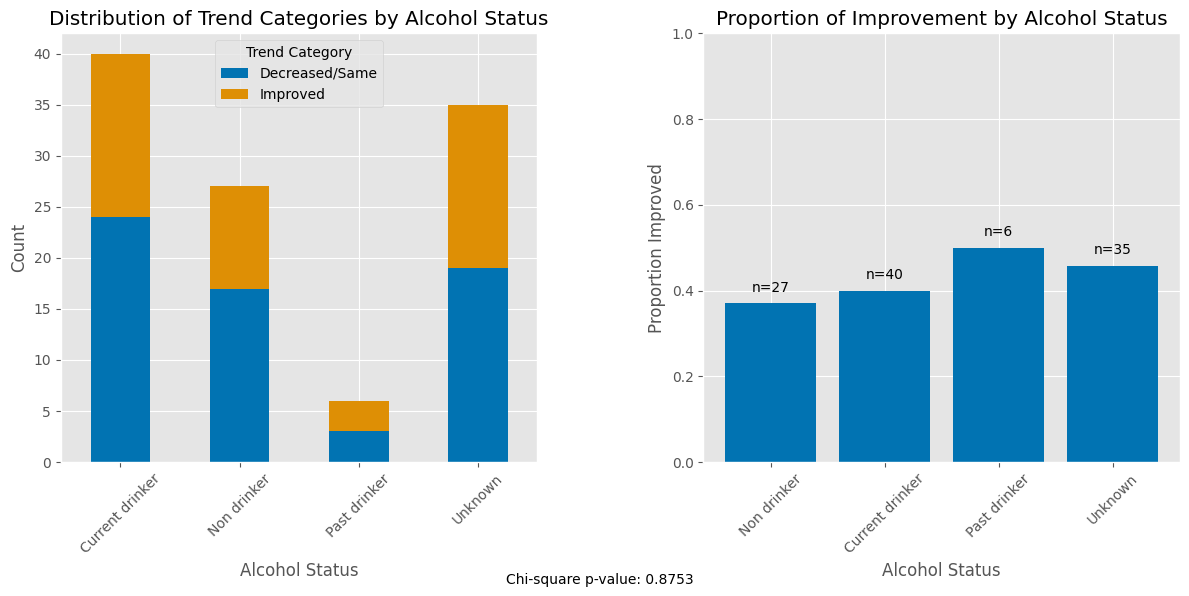

In [108]:
# Visualize with bar plot showing proportions
plt.figure(figsize=(12, 6))

# Subplot 1: Contingency table as stacked bar chart
plt.subplot(1, 2, 1)
contingency_table.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Distribution of Trend Categories by Alcohol Status")
plt.xlabel("Alcohol Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Trend Category")

# Subplot 2: Proportion of improvement by alcohol status
plt.subplot(1, 2, 2)
bars = plt.bar(proportion_df["alcohol_status"], proportion_df["proportion_improved"])
plt.title("Proportion of Improvement by Alcohol Status")
plt.xlabel("Alcohol Status")
plt.ylabel("Proportion Improved")
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Add count labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'n={proportion_df.iloc[i]["total_count"]}',
             ha='center', va='bottom')

plt.annotate(f"Chi-square p-value: {p_value_chi2:.4f}", xy=(0.5, 0.02), 
             xycoords='figure fraction', ha='center')

plt.tight_layout()
plt.show()

# sensitivity analysis 3) alcohol consumption

Sensitivity Analysis Results:
    threshold  improvement_rate    chi2_p  logistic_p  odds_ratio
0           0          0.500000  0.603148    0.180654    1.967914
1           1          0.490741  0.724884    0.253999    1.777778
2           2          0.490741  0.724884    0.253999    1.777778
3           3          0.425926  0.892970    0.183033    1.256522
4           4          0.416667  0.875282    0.183033    1.133333
5           5          0.416667  0.875282    0.183033    1.133333
6           6          0.407407  0.931754    0.183033    1.133333
7           7          0.388889  0.936850    0.183033    1.133333
8           8          0.361111  0.790872    0.040134    1.425000
9           9          0.351852  0.789335    0.040134    1.425000
10         10          0.333333  0.617919    0.016823    1.714286


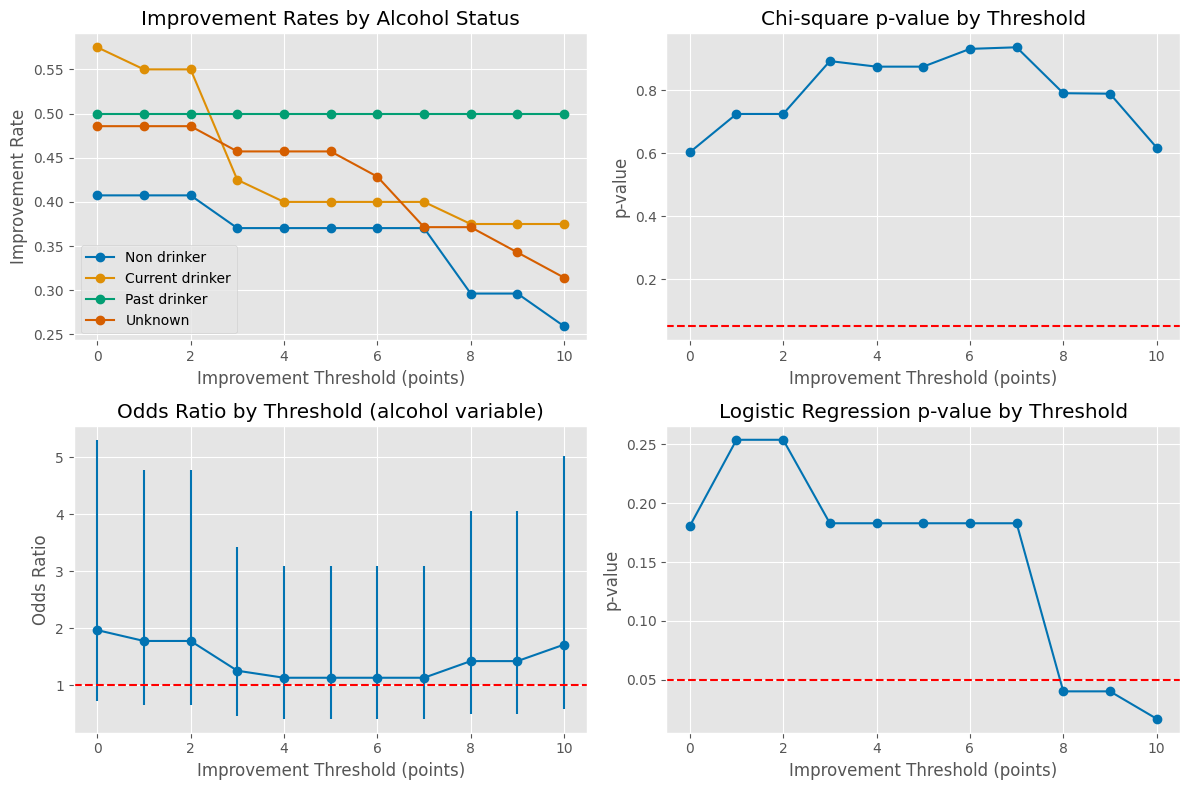


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              54                    54   50.000000   
1           1              53                    55   49.074074   
2           2              53                    55   49.074074   
3           3              46                    62   42.592593   
4           4              45                    63   41.666667   
5           5              45                    63   41.666667   
6           6              44                    64   40.740741   
7           7              42                    66   38.888889   
8           8              39                    69   36.111111   
9           9              38                    70   35.185185   
10         10              36                    72   33.333333   

    Decreased/Same %  
0          50.000000  
1          50.925926  
2          50.925926  
3          57.407407  
4          58.333333  
5          58.33

In [109]:
def analyze_improvement_threshold_alcohol(data, threshold):
    """
    Analyze how the improvement threshold affects classification and alcohol status relationship
    
    Parameters:
    data: DataFrame containing alcohol and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Chi-square test
    try:
        contingency = pd.crosstab(df["alcohol"], df["Improved"])
        chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)
    except:
        chi2, p_value_chi2 = None, None
    
    # Logistic regression with one-hot encoding
    try:
        alcohol_dummies = pd.get_dummies(df["alcohol"], prefix="alcohol", drop_first=True).astype(int)
        X = sm.add_constant(alcohol_dummies)
        y = df["Trend Category_binary"]
        
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        logistic_p = result.pvalues.min()  # Get minimum p-value from all alcohol coefficients
        
        # Get odds ratios and confidence intervals
        odds_ratios = np.exp(result.params[1:])  # Exclude intercept
        conf_int = result.conf_int()
        odds_ratio_lower_ci = np.exp(conf_int.iloc[1:, 0])  # Lower CI for alcohol variables
        odds_ratio_upper_ci = np.exp(conf_int.iloc[1:, 1])  # Upper CI for alcohol variables
        
        # Take the first alcohol variable's odds ratio as representative
        odds_ratio = odds_ratios.iloc[0] if len(odds_ratios) > 0 else None
        lower_ci = odds_ratio_lower_ci.iloc[0] if len(odds_ratio_lower_ci) > 0 else None
        upper_ci = odds_ratio_upper_ci.iloc[0] if len(odds_ratio_upper_ci) > 0 else None
        
    except:
        logistic_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2,
        "chi2_p": p_value_chi2,
        "logistic_p": logistic_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean_alcohol = merged_df_alcohol.dropna(subset=["alcohol", "Change"]).drop_duplicates()
merged_df_clean_alcohol["alcohol"] = pd.to_numeric(merged_df_clean_alcohol["alcohol"], errors='coerce')
merged_df_clean_alcohol = merged_df_clean_alcohol.dropna(subset=["alcohol"])

for threshold in thresholds:
    result = analyze_improvement_threshold_alcohol(merged_df_clean_alcohol, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))

# Plot improvement rates by alcohol status
plt.subplot(2, 2, 1)
for alcohol_val, label in alcohol_labels.items():
    rates = []
    for threshold in thresholds:
        subset = merged_df_clean_alcohol[merged_df_clean_alcohol["alcohol"] == alcohol_val]
        if len(subset) > 0:
            improved = (subset["Change"] >= threshold).sum()
            rate = improved / len(subset)
            rates.append(rate)
        else:
            rates.append(0)
    plt.plot(thresholds, rates, 'o-', label=label)

plt.title("Improvement Rates by Alcohol Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Improvement Rate")
plt.legend()
plt.grid(True)

# Plot p-values from Chi-square test (equivalent to Mann-Whitney for categorical)
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-square p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (alcohol variable)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean_alcohol.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

In [110]:
# Just the confidence intervals
print("95% Confidence Intervals for Odds Ratios:")
for threshold in sensitivity_df['threshold']:
    row = sensitivity_df[sensitivity_df['threshold'] == threshold].iloc[0]
    lower = row['odds_ratio_lower_ci']
    upper = row['odds_ratio_upper_ci']
    or_val = row['odds_ratio']
    
    if pd.notna(or_val):
        print(f"Threshold {threshold}: OR = {or_val:.3f} (95% CI: {lower:.3f} - {upper:.3f})")
    else:
        print(f"Threshold {threshold}: OR = N/A")

95% Confidence Intervals for Odds Ratios:
Threshold 0: OR = 1.968 (95% CI: 0.730 - 5.302)
Threshold 1: OR = 1.778 (95% CI: 0.662 - 4.778)
Threshold 2: OR = 1.778 (95% CI: 0.662 - 4.778)
Threshold 3: OR = 1.257 (95% CI: 0.462 - 3.421)
Threshold 4: OR = 1.133 (95% CI: 0.415 - 3.097)
Threshold 5: OR = 1.133 (95% CI: 0.415 - 3.097)
Threshold 6: OR = 1.133 (95% CI: 0.415 - 3.097)
Threshold 7: OR = 1.133 (95% CI: 0.415 - 3.097)
Threshold 8: OR = 1.425 (95% CI: 0.501 - 4.052)
Threshold 9: OR = 1.425 (95% CI: 0.501 - 4.052)
Threshold 10: OR = 1.714 (95% CI: 0.586 - 5.011)


# statistically significantly associated with 4) level of tumor (level_tumor)

In [111]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [112]:
# Merge score_comparison with level_tumor data
merged_df_level = score_comparison.merge(filtered_df[["id", "level_tumor"]], on="id", how="left")

print(merged_df_level['level_tumor'].value_counts())

# Find patient IDs where all level_tumor values are missing
patients_all_missing = merged_df_level.groupby('id')['level_tumor'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute level_tumor for those patients with 9999.0 (unknown/missing indicator)
mask = merged_df_level['id'].isin(patients_to_impute)
merged_df_level.loc[mask, 'level_tumor'] = 9999.0

print(f"Imputed {len(patients_to_impute)} missing data patients with level_tumor = 9999.0 (unknown)")


# Create a clean dataframe with no missing values in level_tumor
merged_df_removedNA_level = merged_df_level.dropna(subset=["level_tumor"])
merged_df_expanded_level = merged_df_removedNA_level.drop_duplicates()
merged_df_removedNA_level = merged_df_expanded_level.copy()

print(merged_df_removedNA_level['level_tumor'].value_counts())
merged_df_removedNA_level


level_tumor
4.0    47
6.0    28
7.0    15
5.0     9
3.0     8
2.0     2
1.0     1
Name: count, dtype: int64
Imputed 1 missing data patients with level_tumor = 9999.0 (unknown)
level_tumor
4.0       47
6.0       26
7.0       15
5.0        9
3.0        7
2.0        2
9999.0     1
1.0        1
Name: count, dtype: int64


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,level_tumor
2,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,4.0
16,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,4.0
27,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,4.0
31,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,6.0
39,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,4.0
...,...,...,...,...,...,...,...,...
1161,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,6.0
1164,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,6.0
1176,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,6.0
1184,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,4.0


In [113]:
# Create level_tumor status labels
level_tumor_labels = {1: "Cervical", 2: "Thoracic Upper 1/3", 3: "Thoracic Middle 1/3", 4: "Thoracic Lower 1/3", 5: "GEJ Siewert 1", 6: "GEJ Siewert 2", 7: "GEJ Siewert 3", 9999: "Unknown"}
merged_df_removedNA_level["level_tumor_status"] = merged_df_removedNA_level["level_tumor"].map(level_tumor_labels)

# Show summary statistics by improvement group and level_tumor status
print("\nCrosstab of Level Tumor Status and Trend Category:")
contingency_table = pd.crosstab(merged_df_removedNA_level["level_tumor_status"], 
                                merged_df_removedNA_level["Trend Category"])
print(contingency_table)


Crosstab of Level Tumor Status and Trend Category:
Trend Category       Decreased/Same  Improved
level_tumor_status                           
Cervical                          1         0
GEJ Siewert 1                     4         5
GEJ Siewert 2                    14        12
GEJ Siewert 3                    10         5
Thoracic Lower 1/3               26        21
Thoracic Middle 1/3               7         0
Thoracic Upper 1/3                0         2
Unknown                           1         0


In [114]:
# Chi-square test
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square test:")
print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value_chi2}")
print(f"Degrees of freedom: {dof}")


Chi-square test:
Chi-square statistic: 10.762497077390694
p-value: 0.14931953090016517
Degrees of freedom: 7


In [115]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_level["Trend Category_binary"] = merged_df_removedNA_level["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Clean data for logistic regression
clean_data = merged_df_removedNA_level.dropna(subset=["level_tumor", "Trend Category_binary"])

# Logistic regression with one-hot encoding for categorical level_tumor variable
level_tumor_dummies = pd.get_dummies(clean_data["level_tumor"], prefix="level_tumor", drop_first=True).astype(int)
X = sm.add_constant(level_tumor_dummies)
y = clean_data["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())


         Current function value: 0.610988
         Iterations: 35

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  108
Model:                             Logit   Df Residuals:                      100
Method:                              MLE   Df Model:                            7
Date:                   Wed, 02 Jul 2025   Pseudo R-squ.:                  0.1004
Time:                           02:57:38   Log-Likelihood:                -65.987
converged:                         False   LL-Null:                       -73.353
Covariance Type:               nonrobust   LLR p-value:                   0.03959
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                -19.5879   1.79e+04     -0.001      0.999   -3.52e+04

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [116]:
# Calculate proportions for plotting
proportion_data = []
for level_tumor_val, label in level_tumor_labels.items():
    subset = merged_df_removedNA_level[merged_df_removedNA_level["level_tumor"] == level_tumor_val]
    if len(subset) > 0:
        improved_count = len(subset[subset["Trend Category"] == "Improved"])
        total_count = len(subset)
        proportion = improved_count / total_count
        proportion_data.append({
            "level_tumor_status": label,
            "proportion_improved": proportion,
            "total_count": total_count,
            "improved_count": improved_count
        })

proportion_df = pd.DataFrame(proportion_data)
print(f"\nProportion of improvement by level_tumor status:")
print(proportion_df)


Proportion of improvement by level_tumor status:
    level_tumor_status  proportion_improved  total_count  improved_count
0             Cervical             0.000000            1               0
1   Thoracic Upper 1/3             1.000000            2               2
2  Thoracic Middle 1/3             0.000000            7               0
3   Thoracic Lower 1/3             0.446809           47              21
4        GEJ Siewert 1             0.555556            9               5
5        GEJ Siewert 2             0.461538           26              12
6        GEJ Siewert 3             0.333333           15               5
7              Unknown             0.000000            1               0


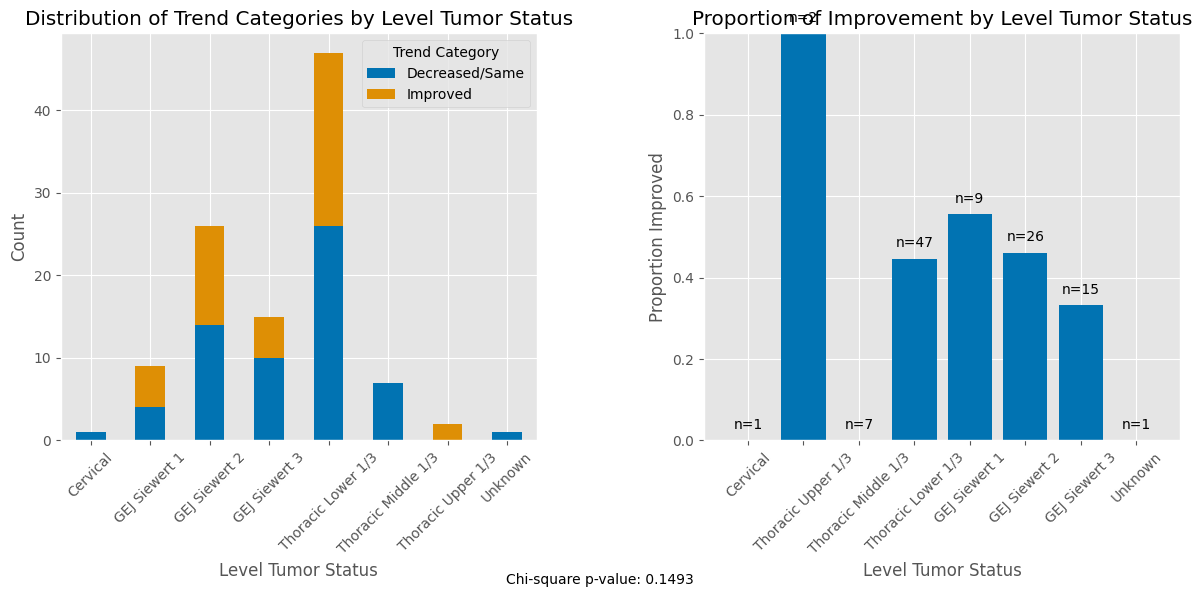

In [117]:
# Visualize with bar plot showing proportions
plt.figure(figsize=(12, 6))

# Subplot 1: Contingency table as stacked bar chart
plt.subplot(1, 2, 1)
contingency_table.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Distribution of Trend Categories by Level Tumor Status")
plt.xlabel("Level Tumor Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Trend Category")

# Subplot 2: Proportion of improvement by level_tumor status
plt.subplot(1, 2, 2)
bars = plt.bar(proportion_df["level_tumor_status"], proportion_df["proportion_improved"])
plt.title("Proportion of Improvement by Level Tumor Status")
plt.xlabel("Level Tumor Status")
plt.ylabel("Proportion Improved")
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Add count labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'n={proportion_df.iloc[i]["total_count"]}',
                ha='center', va='bottom')

plt.annotate(f"Chi-square p-value: {p_value_chi2:.4f}", xy=(0.5, 0.02), 
                xycoords='figure fraction', ha='center')

plt.tight_layout()
plt.show()

# sensitivity analysis 4) level of tumor (level_tumor)

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yjkweon2/jinenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/d

Sensitivity Analysis Results:
    threshold  improvement_rate    chi2_p  logistic_p    odds_ratio
0           0          0.500000  0.355223    0.997427  1.638932e+18
1           1          0.490741  0.390973         NaN           NaN
2           2          0.490741  0.390973         NaN           NaN
3           3          0.425926  0.138879    0.998996  1.719825e+15
4           4          0.416667  0.149320    0.998874  3.170824e+17
5           5          0.416667  0.149320    0.998874  3.170824e+17
6           6          0.407407  0.155342    0.998768  2.237912e+17
7           7          0.388889  0.172650    0.998861  3.048316e+17
8           8          0.361111  0.090571    0.998613  2.682581e+16
9           9          0.351852  0.048980    0.998696  1.725327e+17
10         10          0.333333  0.048527    0.998679  1.605803e+17


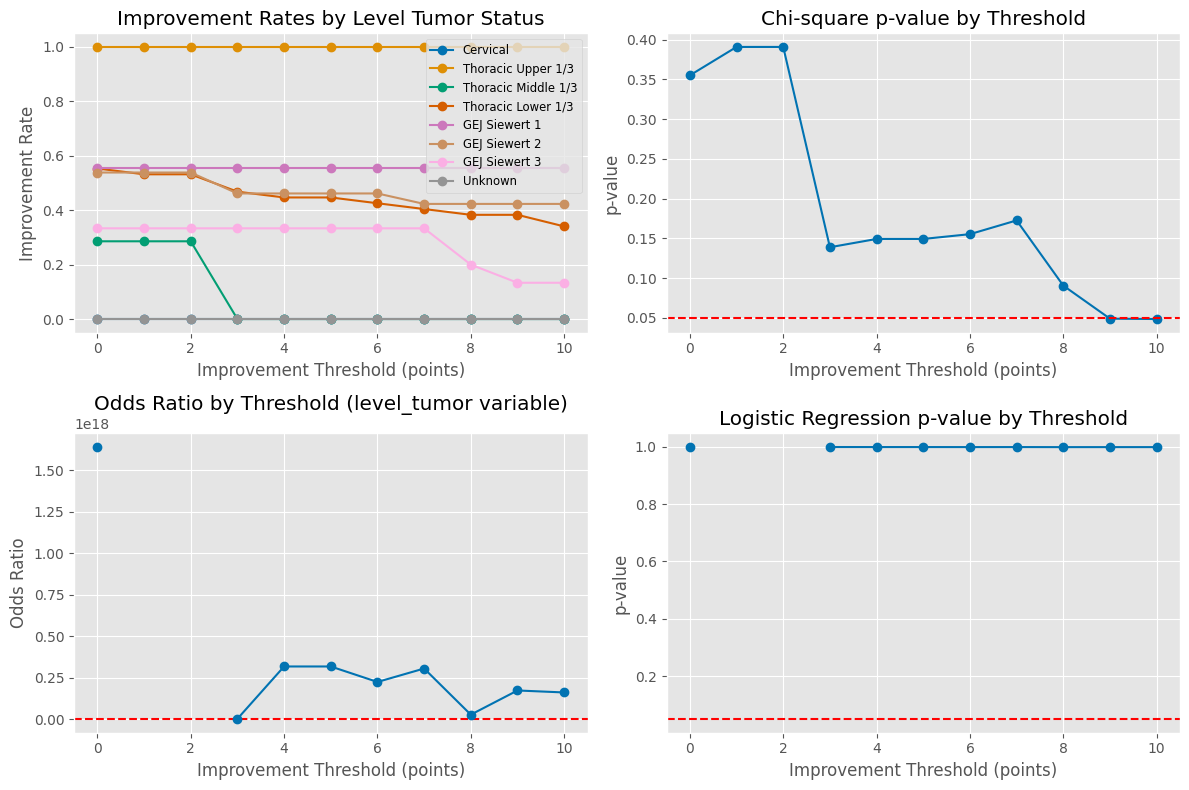


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              54                    54   50.000000   
1           1              53                    55   49.074074   
2           2              53                    55   49.074074   
3           3              46                    62   42.592593   
4           4              45                    63   41.666667   
5           5              45                    63   41.666667   
6           6              44                    64   40.740741   
7           7              42                    66   38.888889   
8           8              39                    69   36.111111   
9           9              38                    70   35.185185   
10         10              36                    72   33.333333   

    Decreased/Same %  
0          50.000000  
1          50.925926  
2          50.925926  
3          57.407407  
4          58.333333  
5          58.33

In [118]:
def analyze_improvement_threshold_level_tumor(data, threshold):
    """
    Analyze how the improvement threshold affects classification and level_tumor status relationship
    
    Parameters:
    data: DataFrame containing level_tumor and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Chi-square test
    try:
        contingency = pd.crosstab(df["level_tumor"], df["Improved"])
        chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)
    except:
        chi2, p_value_chi2 = None, None
    
    # Logistic regression with one-hot encoding
    try:
        level_tumor_dummies = pd.get_dummies(df["level_tumor"], prefix="level_tumor", drop_first=True).astype(int)
        X = sm.add_constant(level_tumor_dummies)
        y = df["Trend Category_binary"]
        
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        logistic_p = result.pvalues.min()  # Get minimum p-value from all level_tumor coefficients
        
        # Get odds ratios and confidence intervals
        odds_ratios = np.exp(result.params[1:])  # Exclude intercept
        conf_int = result.conf_int()
        odds_ratio_lower_ci = np.exp(conf_int.iloc[1:, 0])  # Lower CI for level_tumor variables
        odds_ratio_upper_ci = np.exp(conf_int.iloc[1:, 1])  # Upper CI for level_tumor variables
        
        # Take the first level_tumor variable's odds ratio as representative
        odds_ratio = odds_ratios.iloc[0] if len(odds_ratios) > 0 else None
        lower_ci = odds_ratio_lower_ci.iloc[0] if len(odds_ratio_lower_ci) > 0 else None
        upper_ci = odds_ratio_upper_ci.iloc[0] if len(odds_ratio_upper_ci) > 0 else None
        
    except:
        logistic_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2,
        "chi2_p": p_value_chi2,
        "logistic_p": logistic_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean_level = merged_df_level.dropna(subset=["level_tumor", "Change"]).drop_duplicates()
merged_df_clean_level["level_tumor"] = pd.to_numeric(merged_df_clean_level["level_tumor"], errors='coerce')
merged_df_clean_level = merged_df_clean_level.dropna(subset=["level_tumor"])

for threshold in thresholds:
    result = analyze_improvement_threshold_level_tumor(merged_df_clean_level, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))

# Plot improvement rates by level_tumor status
plt.subplot(2, 2, 1)
for level_tumor_val, label in level_tumor_labels.items():
    rates = []
    for threshold in thresholds:
        subset = merged_df_clean_level[merged_df_clean_level["level_tumor"] == level_tumor_val]
        if len(subset) > 0:
            improved = (subset["Change"] >= threshold).sum()
            rate = improved / len(subset)
            rates.append(rate)
        else:
            rates.append(0)
    plt.plot(thresholds, rates, 'o-', label=label)

plt.title("Improvement Rates by Level Tumor Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Improvement Rate")
plt.legend(fontsize='small')
plt.grid(True)

# Plot p-values from Chi-square test (equivalent to Mann-Whitney for categorical)
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-square p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (level_tumor variable)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean_level.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

In [119]:
# Just the confidence intervals
print("95% Confidence Intervals for Odds Ratios:")
for threshold in sensitivity_df['threshold']:
    row = sensitivity_df[sensitivity_df['threshold'] == threshold].iloc[0]
    lower = row['odds_ratio_lower_ci']
    upper = row['odds_ratio_upper_ci']
    or_val = row['odds_ratio']
    
    if pd.notna(or_val):
        print(f"Threshold {threshold}: OR = {or_val:.3f} (95% CI: {lower:.3f} - {upper:.3f})")
    else:
        print(f"Threshold {threshold}: OR = N/A")

95% Confidence Intervals for Odds Ratios:
Threshold 0: OR = 1638931743608173568.000 (95% CI: 0.000 - inf)
Threshold 1: OR = N/A
Threshold 2: OR = N/A
Threshold 3: OR = 1719824896226228.750 (95% CI: 0.000 - inf)
Threshold 4: OR = 317082392712128896.000 (95% CI: 0.000 - inf)
Threshold 5: OR = 317082392712128896.000 (95% CI: 0.000 - inf)
Threshold 6: OR = 223791244870214400.000 (95% CI: 0.000 - inf)
Threshold 7: OR = 304831595391043776.000 (95% CI: 0.000 - inf)
Threshold 8: OR = 26825809743494480.000 (95% CI: 0.000 - inf)
Threshold 9: OR = 172532737630541440.000 (95% CI: 0.000 - inf)
Threshold 10: OR = 160580300297816640.000 (95% CI: 0.000 - inf)


# statistically significantly associated with 5) histology (path_histology)

In [120]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [121]:
merged_df_tumorhistology = score_comparison.merge(filtered_df[["id", "path_histology___noca", 
                                                        "path_histology___hgd", "path_histology___cis", "path_histology___adeno", 
                                                        "path_histology___scc", "path_histology___nec", "path_histology___other"]], on="id", how="left")

# First, create a mapping dictionary
histology_mapping = {
    "path_histology___noca": 1,
    "path_histology___hgd": 2,
    "path_histology___cis": 3,
    "path_histology___adeno": 4,
    "path_histology___scc": 5,
    "path_histology___nec": 6,
    "path_histology___other": 7
}

# Create the histology column
def assign_histology(row):
    # Get columns that are 1 (True)
    active_cols = [col for col in histology_mapping.keys() if row[col] == 1]
    
    if len(active_cols) == 1:
        return histology_mapping[active_cols[0]]
    elif len(active_cols) > 1:
        return 8  # mixed
    else:
        return None  # missing/NaN

merged_df_tumorhistology['histology'] = merged_df_tumorhistology.apply(assign_histology, axis=1)

# If you want to handle mixed at the patient level (across multiple rows per patient):
# Group by id and check if patient has multiple different histology types
patient_histology = merged_df_tumorhistology.groupby('id')['histology'].apply(lambda x: 8 if len(set(x.dropna())) > 1 else x.dropna().iloc[0] if len(x.dropna()) > 0 else None).reset_index()
patient_histology.columns = ['id', 'final_histology']

# Merge back
merged_df_tumorhistology = merged_df_tumorhistology.merge(patient_histology[['id', 'final_histology']], on='id', how='left')

# Drop the individual histology columns and rename final_histology
merged_df_tumorhistology = merged_df_tumorhistology.drop(columns=[
    "path_histology___noca",
    "path_histology___hgd", 
    "path_histology___cis",
    "path_histology___adeno",
    "path_histology___scc",
    "path_histology___nec",
    "path_histology___other",
    "histology"
]).rename(columns={"final_histology": "path_histology"})

merged_df_tumorhistology

,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,path_histology
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
1,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
2,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
3,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
4,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
...,...,...,...,...,...,...,...,...
1195,1653,baseline_arm_1,112.0,153.0,41.0,True,Improved,4.0
1196,1653,baseline_arm_1,112.0,153.0,41.0,True,Improved,4.0
1197,1653,baseline_arm_1,112.0,153.0,41.0,True,Improved,4.0
1198,1653,baseline_arm_1,112.0,153.0,41.0,True,Improved,4.0


In [122]:

# Find patient IDs where all path_histology values are missing
patients_all_missing = merged_df_tumorhistology.groupby('id')['path_histology'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute path_histology for those patients with 9999.0 (unknown/missing indicator)
mask = merged_df_tumorhistology['id'].isin(patients_to_impute)
merged_df_tumorhistology.loc[mask, 'path_histology'] = 9999.0

print(f"Imputed {len(patients_to_impute)} missing data patients with path_histology = 9999.0 (unknown)")

# Create a clean dataframe with no missing values in path_histology
merged_df_removedNA_tumorhistology = merged_df_tumorhistology.dropna(subset=["path_histology"])
merged_df_expanded_tumorhistology = merged_df_removedNA_tumorhistology.drop_duplicates()
merged_df_removedNA_tumorhistology = merged_df_expanded_tumorhistology.copy()

print(merged_df_removedNA_tumorhistology['path_histology'].value_counts())
merged_df_removedNA_tumorhistology

Imputed 1 missing data patients with path_histology = 9999.0 (unknown)
path_histology
4.0       63
8.0       20
1.0       12
5.0       10
7.0        1
9999.0     1
2.0        1
Name: count, dtype: int64


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,path_histology
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
10,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,4.0
18,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,4.0
28,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,4.0
38,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,8.0
...,...,...,...,...,...,...,...,...
1155,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,4.0
1163,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,1.0
1173,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,8.0
1182,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,4.0


In [123]:
# Create path_histology status labels
path_histology_labels = {1: "noca", 2: "hgd", 3: "cis", 4: "adeno", 5: "scc", 6: "nec", 7: "other", 8: "mixed", 9999: "unknown"}
merged_df_removedNA_tumorhistology["path_histology_status"] = merged_df_removedNA_tumorhistology["path_histology"].map(path_histology_labels)

In [124]:
# Show summary statistics by improvement group and path_histology status
print("\nCrosstab of Path Histology Status and Trend Category:")
contingency_table = pd.crosstab(merged_df_removedNA_tumorhistology["path_histology_status"], 
                                merged_df_removedNA_tumorhistology["Trend Category"])
print(contingency_table)


Crosstab of Path Histology Status and Trend Category:
Trend Category         Decreased/Same  Improved
path_histology_status                          
adeno                              33        30
hgd                                 1         0
mixed                              12         8
noca                                7         5
other                               0         1
scc                                 9         1
unknown                             1         0


In [125]:
# Chi-square test
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square test:")
print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value_chi2}")
print(f"Degrees of freedom: {dof}")


Chi-square test:
Chi-square statistic: 7.895510204081633
p-value: 0.24585891068847943
Degrees of freedom: 6


In [126]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_tumorhistology["Trend Category_binary"] = merged_df_removedNA_tumorhistology["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Clean data for logistic regression
clean_data = merged_df_removedNA_tumorhistology.dropna(subset=["path_histology", "Trend Category_binary"])

# Logistic regression with one-hot encoding for categorical path_histology variable
path_histology_dummies = pd.get_dummies(clean_data["path_histology"], prefix="path_histology", drop_first=True).astype(int)
X = sm.add_constant(path_histology_dummies)
y = clean_data["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

         Current function value: 0.633872
         Iterations: 35

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  108
Model:                             Logit   Df Residuals:                      101
Method:                              MLE   Df Model:                            6
Date:                   Wed, 02 Jul 2025   Pseudo R-squ.:                 0.06673
Time:                           02:57:39   Log-Likelihood:                -68.458
converged:                         False   LL-Null:                       -73.353
Covariance Type:               nonrobust   LLR p-value:                    0.1338
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.3365      0.586     -0.575      0.566   

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [127]:
# Calculate proportions for plotting
proportion_data = []
for path_histology_val, label in path_histology_labels.items():
    subset = merged_df_removedNA_tumorhistology[merged_df_removedNA_tumorhistology["path_histology"] == path_histology_val]
    if len(subset) > 0:
        improved_count = len(subset[subset["Trend Category"] == "Improved"])
        total_count = len(subset)
        proportion = improved_count / total_count
        proportion_data.append({
            "path_histology_status": label,
            "proportion_improved": proportion,
            "total_count": total_count,
            "improved_count": improved_count
        })

proportion_df = pd.DataFrame(proportion_data)
print(f"\nProportion of improvement by path_histology status:")
print(proportion_df)


Proportion of improvement by path_histology status:
  path_histology_status  proportion_improved  total_count  improved_count
0                  noca             0.416667           12               5
1                   hgd             0.000000            1               0
2                 adeno             0.476190           63              30
3                   scc             0.100000           10               1
4                 other             1.000000            1               1
5                 mixed             0.400000           20               8
6               unknown             0.000000            1               0


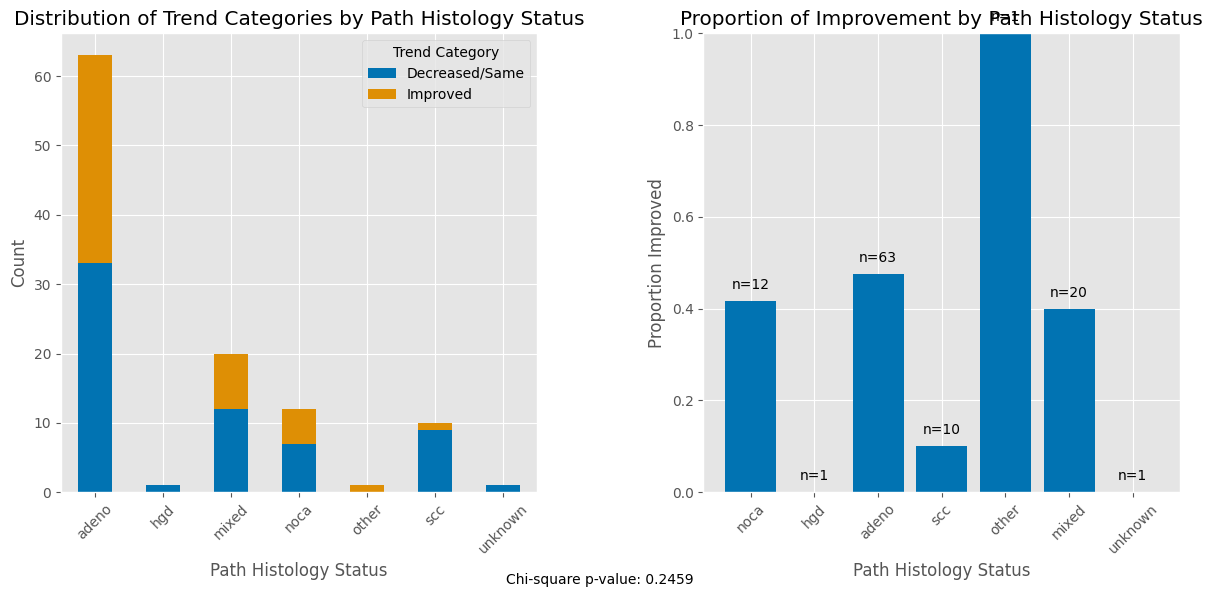

In [128]:
# Visualize with bar plot showing proportions
plt.figure(figsize=(12, 6))

# Subplot 1: Contingency table as stacked bar chart
plt.subplot(1, 2, 1)
contingency_table.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Distribution of Trend Categories by Path Histology Status")
plt.xlabel("Path Histology Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Trend Category")

# Subplot 2: Proportion of improvement by path_histology status
plt.subplot(1, 2, 2)
bars = plt.bar(proportion_df["path_histology_status"], proportion_df["proportion_improved"])
plt.title("Proportion of Improvement by Path Histology Status")
plt.xlabel("Path Histology Status")
plt.ylabel("Proportion Improved")
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Add count labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'n={proportion_df.iloc[i]["total_count"]}',
                ha='center', va='bottom')

plt.annotate(f"Chi-square p-value: {p_value_chi2:.4f}", xy=(0.5, 0.02), 
                xycoords='figure fraction', ha='center')

plt.tight_layout()
plt.show()


# sensitivity analysis 5) histology (path_histology)

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yjkweon2/jinenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yjkweon2/jinenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warn

Sensitivity Analysis Results:
    threshold  improvement_rate    chi2_p  logistic_p    odds_ratio
0           0          0.500000  0.291390    0.079922  3.005290e-11
1           1          0.490741  0.277425    0.079922  3.005290e-11
2           2          0.490741  0.277425    0.079922  3.005290e-11
3           3          0.425926  0.212739    0.122792  5.890400e-11
4           4          0.416667  0.245859    0.122792  5.890400e-11
5           5          0.416667  0.245859    0.122792  5.890400e-11
6           6          0.407407  0.219969    0.122792  5.890400e-11
7           7          0.388889  0.209430    0.122792  5.890400e-11
8           8          0.361111  0.314801    0.122792  5.890400e-11
9           9          0.351852  0.347052    0.122792  5.890400e-11
10         10          0.333333  0.167058    0.502732  5.890400e-11


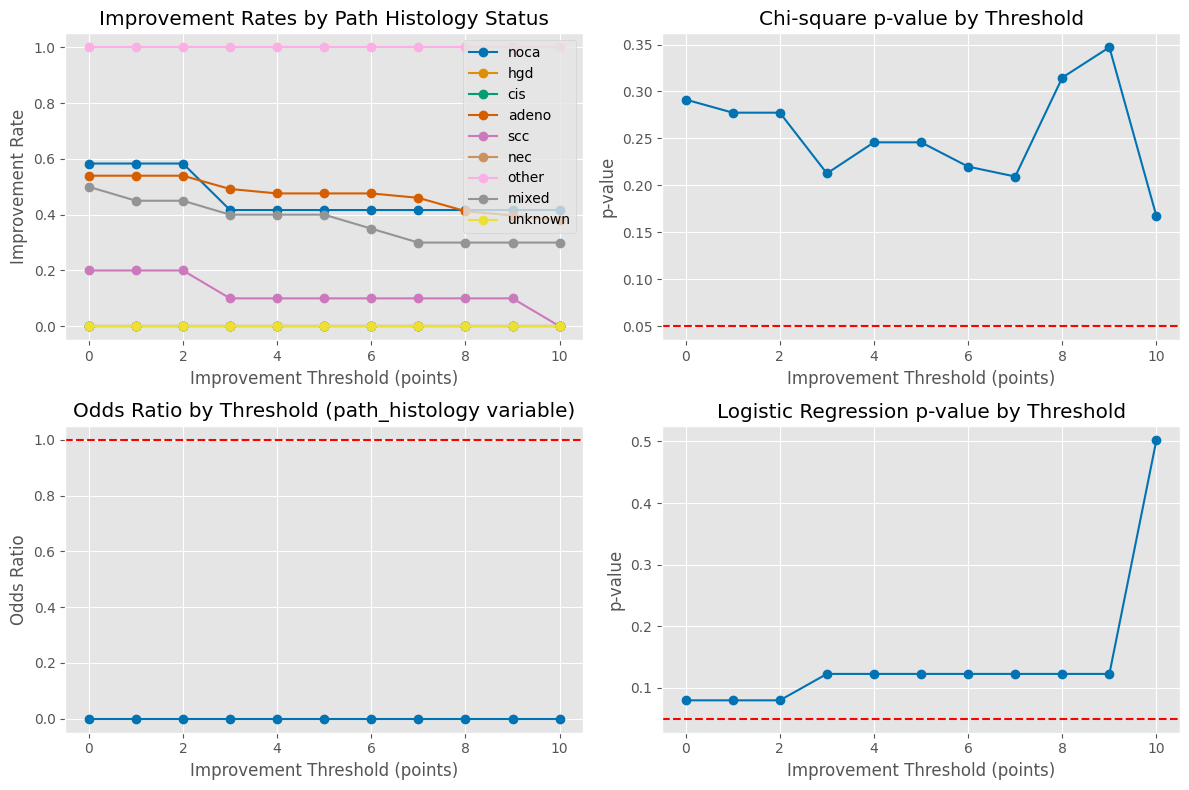


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              54                    54   50.000000   
1           1              53                    55   49.074074   
2           2              53                    55   49.074074   
3           3              46                    62   42.592593   
4           4              45                    63   41.666667   
5           5              45                    63   41.666667   
6           6              44                    64   40.740741   
7           7              42                    66   38.888889   
8           8              39                    69   36.111111   
9           9              38                    70   35.185185   
10         10              36                    72   33.333333   

    Decreased/Same %  
0          50.000000  
1          50.925926  
2          50.925926  
3          57.407407  
4          58.333333  
5          58.33

In [129]:
def analyze_improvement_threshold_path_histology(data, threshold):
    """
    Analyze how the improvement threshold affects classification and path_histology status relationship
    
    Parameters:
    data: DataFrame containing path_histology and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Chi-square test
    try:
        contingency = pd.crosstab(df["path_histology"], df["Improved"])
        chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)
    except:
        chi2, p_value_chi2 = None, None
    
    # Logistic regression with one-hot encoding
    try:
        path_histology_dummies = pd.get_dummies(df["path_histology"], prefix="path_histology", drop_first=True).astype(int)
        X = sm.add_constant(path_histology_dummies)
        y = df["Trend Category_binary"]
        
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        logistic_p = result.pvalues.min()  # Get minimum p-value from all path_histology coefficients
        
        # Get odds ratios and confidence intervals
        odds_ratios = np.exp(result.params[1:])  # Exclude intercept
        conf_int = result.conf_int()
        odds_ratio_lower_ci = np.exp(conf_int.iloc[1:, 0])  # Lower CI for path_histology variables
        odds_ratio_upper_ci = np.exp(conf_int.iloc[1:, 1])  # Upper CI for path_histology variables
        
        # Take the first path_histology variable's odds ratio as representative
        odds_ratio = odds_ratios.iloc[0] if len(odds_ratios) > 0 else None
        lower_ci = odds_ratio_lower_ci.iloc[0] if len(odds_ratio_lower_ci) > 0 else None
        upper_ci = odds_ratio_upper_ci.iloc[0] if len(odds_ratio_upper_ci) > 0 else None
        
    except:
        logistic_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2,
        "chi2_p": p_value_chi2,
        "logistic_p": logistic_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean_tumorhistology = merged_df_tumorhistology.dropna(subset=["path_histology", "Change"]).drop_duplicates()
merged_df_clean_tumorhistology["path_histology"] = pd.to_numeric(merged_df_clean_tumorhistology["path_histology"], errors='coerce')
merged_df_clean_tumorhistology = merged_df_clean_tumorhistology.dropna(subset=["path_histology"])

for threshold in thresholds:
    result = analyze_improvement_threshold_path_histology(merged_df_clean_tumorhistology, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))

# Plot improvement rates by path_histology status
plt.subplot(2, 2, 1)
for path_histology_val, label in path_histology_labels.items():
    rates = []
    for threshold in thresholds:
        subset = merged_df_clean_tumorhistology[merged_df_clean_tumorhistology["path_histology"] == path_histology_val]
        if len(subset) > 0:
            improved = (subset["Change"] >= threshold).sum()
            rate = improved / len(subset)
            rates.append(rate)
        else:
            rates.append(0)
    plt.plot(thresholds, rates, 'o-', label=label)

plt.title("Improvement Rates by Path Histology Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Improvement Rate")
plt.legend()
plt.grid(True)

# Plot p-values from Chi-square test (equivalent to Mann-Whitney for categorical)
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-square p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (path_histology variable)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean_tumorhistology.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

# statistically significantly associated with 6) pathological stage (path_esoph_stage)

In [130]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [131]:
# Merge score_comparison with path_esoph_stage data
merged_df_pathstage = score_comparison.merge(filtered_df[["id", "path_esoph_stage"]], on="id", how="left")

print(merged_df_pathstage['path_esoph_stage'].value_counts())

# Find patient IDs where all path_esoph_stage values are missing
patients_all_missing = merged_df_pathstage.groupby('id')['path_esoph_stage'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute path_esoph_stage for those patients with 9999.0 (unknown/missing indicator)
mask = merged_df_pathstage['id'].isin(patients_to_impute)
merged_df_pathstage.loc[mask, 'path_esoph_stage'] = 9999.0

print(f"Imputed {len(patients_to_impute)} missing data patients with path_esoph_stage = 9999.0 (unknown)")


# Create a clean dataframe with no missing values in path_esoph_stage
merged_df_removedNA_pathstage = merged_df_pathstage.dropna(subset=["path_esoph_stage"])
merged_df_expanded_pathstage = merged_df_removedNA_pathstage.drop_duplicates()
merged_df_removedNA_pathstage = merged_df_expanded_pathstage.copy()


merged_df_removedNA_pathstage

path_esoph_stage
3b    15
2b    12
0      6
3a     5
4a     4
2a     4
1b     3
5      2
4b     1
Name: count, dtype: int64
Imputed 58 missing data patients with path_esoph_stage = 9999.0 (unknown)


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,path_esoph_stage
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,9999.0
10,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,9999.0
24,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,3b
37,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,3b
38,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,9999.0
...,...,...,...,...,...,...,...,...
1155,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,9999.0
1163,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,9999.0
1173,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,9999.0
1182,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,9999.0


In [132]:
print(merged_df_removedNA_pathstage['path_esoph_stage'].value_counts())

path_esoph_stage
9999.0    58
3b        13
2b        12
0          6
3a         5
4a         4
2a         4
1b         3
5          2
4b         1
Name: count, dtype: int64


In [133]:
# Just clean any whitespace and ensure consistent formatting
merged_df_removedNA_pathstage["path_esoph_stage"] = merged_df_removedNA_pathstage["path_esoph_stage"].astype(str).str.strip()

# Create a status column (this will be the same as the original column since it's already in the right format)
merged_df_removedNA_pathstage["path_esoph_stage_status"] = merged_df_removedNA_pathstage["path_esoph_stage"]

# Show summary statistics by improvement group and path_esoph_stage status
print("\nCrosstab of Path Esoph Stage Status and Trend Category:")
contingency_table = pd.crosstab(merged_df_removedNA_pathstage["path_esoph_stage_status"], 
                                merged_df_removedNA_pathstage["Trend Category"])
print(contingency_table)


Crosstab of Path Esoph Stage Status and Trend Category:
Trend Category           Decreased/Same  Improved
path_esoph_stage_status                          
0                                     5         1
1b                                    1         2
2a                                    3         1
2b                                    7         5
3a                                    4         1
3b                                    6         7
4a                                    1         3
4b                                    1         0
5                                     2         0
9999.0                               33        25


In [134]:
# Chi-square test
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square test:")
print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value_chi2}")
print(f"Degrees of freedom: {dof}")



Chi-square test:
Chi-square statistic: 8.551239105721864
p-value: 0.4796851459102678
Degrees of freedom: 9


In [135]:
#Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_pathstage["Trend Category_binary"] = merged_df_removedNA_pathstage["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Clean data for logistic regression
clean_data = merged_df_removedNA_pathstage.dropna(subset=["path_esoph_stage", "Trend Category_binary"])

# Logistic regression with one-hot encoding for categorical path_esoph_stage variable
path_esoph_stage_dummies = pd.get_dummies(clean_data["path_esoph_stage"], prefix="path_esoph_stage", drop_first=True).astype(int)
X = sm.add_constant(path_esoph_stage_dummies)
y = clean_data["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

         Current function value: 0.633198
         Iterations: 35

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  108
Model:                             Logit   Df Residuals:                       98
Method:                              MLE   Df Model:                            9
Date:                   Wed, 02 Jul 2025   Pseudo R-squ.:                 0.06772
Time:                           02:57:41   Log-Likelihood:                -68.385
converged:                         False   LL-Null:                       -73.353
Covariance Type:               nonrobust   LLR p-value:                    0.3558
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -1.6094      1.095     -1.469      0.

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [136]:
# Calculate proportions for plotting
# Get unique values from the actual data
unique_stages = merged_df_removedNA_pathstage["path_esoph_stage"].unique()
proportion_data = []

for stage in unique_stages:
    subset = merged_df_removedNA_pathstage[merged_df_removedNA_pathstage["path_esoph_stage"] == stage]
    if len(subset) > 0:
        improved_count = len(subset[subset["Trend Category"] == "Improved"])
        total_count = len(subset)
        proportion = improved_count / total_count
        proportion_data.append({
            "path_esoph_stage_status": stage,
            "proportion_improved": proportion,
            "total_count": total_count,
            "improved_count": improved_count
        })

proportion_df = pd.DataFrame(proportion_data)
# Sort by stage for better visualization (optional - you might want to define a custom order)
proportion_df = proportion_df.sort_values("path_esoph_stage_status")
print(f"\nProportion of improvement by path_esoph_stage status:")
print(proportion_df)


Proportion of improvement by path_esoph_stage status:
  path_esoph_stage_status  proportion_improved  total_count  improved_count
5                       0             0.166667            6               1
8                      1b             0.666667            3               2
7                      2a             0.250000            4               1
2                      2b             0.416667           12               5
3                      3a             0.200000            5               1
1                      3b             0.538462           13               7
6                      4a             0.750000            4               3
9                      4b             0.000000            1               0
4                       5             0.000000            2               0
0                  9999.0             0.431034           58              25


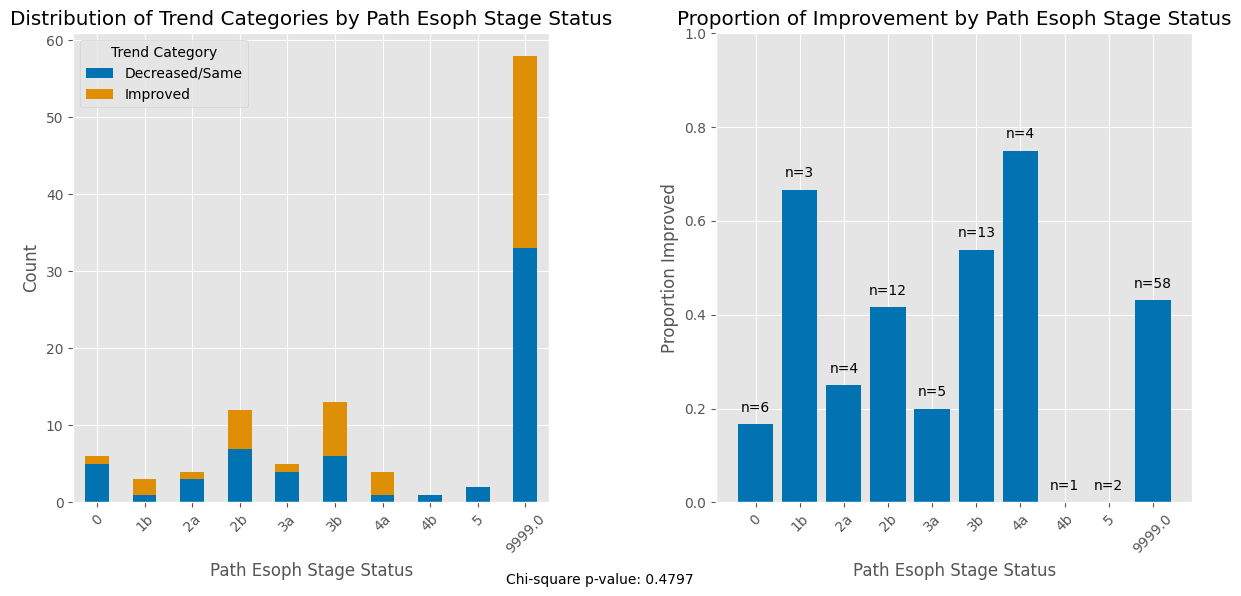

In [137]:
# Visualize with bar plot showing proportions
plt.figure(figsize=(12, 6))

# Subplot 1: Contingency table as stacked bar chart
plt.subplot(1, 2, 1)
contingency_table.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Distribution of Trend Categories by Path Esoph Stage Status")
plt.xlabel("Path Esoph Stage Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Trend Category")

# Subplot 2: Proportion of improvement by path_esoph_stage status
plt.subplot(1, 2, 2)
bars = plt.bar(proportion_df["path_esoph_stage_status"], proportion_df["proportion_improved"])
plt.title("Proportion of Improvement by Path Esoph Stage Status")
plt.xlabel("Path Esoph Stage Status")
plt.ylabel("Proportion Improved")
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Add count labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'n={proportion_df.iloc[i]["total_count"]}',
             ha='center', va='bottom')

plt.annotate(f"Chi-square p-value: {p_value_chi2:.4f}", xy=(0.5, 0.02), 
             xycoords='figure fraction', ha='center')

plt.tight_layout()
plt.show()

# sensitivity analysis 6) pathological stage (path_esoph_stage)

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yjkweon2/jinenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yjkweon2/jinenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warn

Sensitivity Analysis Results:
    threshold  improvement_rate    chi2_p  logistic_p  odds_ratio
0           0          0.500000  0.757234    0.316662         2.0
1           1          0.490741  0.693401    0.214470         4.0
2           2          0.490741  0.693401    0.214470         4.0
3           3          0.425926  0.455634    0.088865        10.0
4           4          0.416667  0.479685    0.088865        10.0
5           5          0.416667  0.479685    0.088865        10.0
6           6          0.407407  0.653281    0.141776        10.0
7           7          0.388889  0.642953    0.141776        10.0
8           8          0.361111  0.431878    0.141776        10.0
9           9          0.351852  0.262626    0.141776        10.0
10         10          0.333333  0.378427    0.141776        10.0


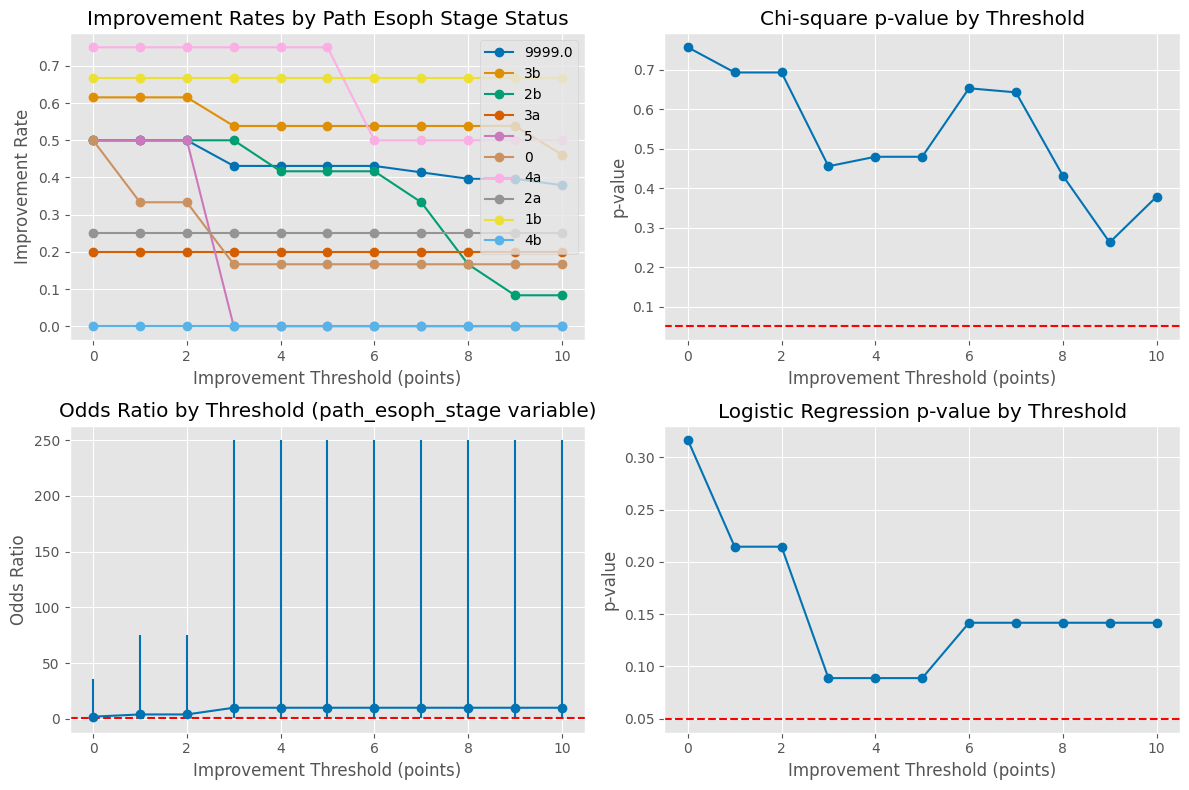


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              54                    54   50.000000   
1           1              53                    55   49.074074   
2           2              53                    55   49.074074   
3           3              46                    62   42.592593   
4           4              45                    63   41.666667   
5           5              45                    63   41.666667   
6           6              44                    64   40.740741   
7           7              42                    66   38.888889   
8           8              39                    69   36.111111   
9           9              38                    70   35.185185   
10         10              36                    72   33.333333   

    Decreased/Same %  
0          50.000000  
1          50.925926  
2          50.925926  
3          57.407407  
4          58.333333  
5          58.33

In [138]:
def analyze_improvement_threshold_path_esoph_stage(data, threshold):
    """
    Analyze how the improvement threshold affects classification and path_esoph_stage status relationship
    
    Parameters:
    data: DataFrame containing path_esoph_stage and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Chi-square test
    try:
        contingency = pd.crosstab(df["path_esoph_stage"], df["Improved"])
        chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)
    except:
        chi2, p_value_chi2 = None, None
    
    # Logistic regression with one-hot encoding
    try:
        path_esoph_stage_dummies = pd.get_dummies(df["path_esoph_stage"], prefix="path_esoph_stage", drop_first=True).astype(int)
        X = sm.add_constant(path_esoph_stage_dummies)
        y = df["Trend Category_binary"]
        
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        logistic_p = result.pvalues.min()  # Get minimum p-value from all path_esoph_stage coefficients
        
        # Get odds ratios and confidence intervals
        odds_ratios = np.exp(result.params[1:])  # Exclude intercept
        conf_int = result.conf_int()
        odds_ratio_lower_ci = np.exp(conf_int.iloc[1:, 0])  # Lower CI for path_esoph_stage variables
        odds_ratio_upper_ci = np.exp(conf_int.iloc[1:, 1])  # Upper CI for path_esoph_stage variables
        
        # Take the first path_esoph_stage variable's odds ratio as representative
        odds_ratio = odds_ratios.iloc[0] if len(odds_ratios) > 0 else None
        lower_ci = odds_ratio_lower_ci.iloc[0] if len(odds_ratio_lower_ci) > 0 else None
        upper_ci = odds_ratio_upper_ci.iloc[0] if len(odds_ratio_upper_ci) > 0 else None
        
    except:
        logistic_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2,
        "chi2_p": p_value_chi2,
        "logistic_p": logistic_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset - DON'T convert to numeric since path_esoph_stage is already strings
merged_df_clean_pathstage = merged_df_pathstage.dropna(subset=["path_esoph_stage", "Change"]).drop_duplicates()
merged_df_clean_pathstage["path_esoph_stage"] = merged_df_clean_pathstage["path_esoph_stage"].astype(str).str.strip()

for threshold in thresholds:
    result = analyze_improvement_threshold_path_esoph_stage(merged_df_clean_pathstage, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))

# Get unique stage values for plotting
unique_stages = merged_df_clean_pathstage["path_esoph_stage"].unique()

# Plot improvement rates by path_esoph_stage status
plt.subplot(2, 2, 1)
for stage in unique_stages:
    rates = []
    for threshold in thresholds:
        subset = merged_df_clean_pathstage[merged_df_clean_pathstage["path_esoph_stage"] == stage]
        if len(subset) > 0:
            improved = (subset["Change"] >= threshold).sum()
            rate = improved / len(subset)
            rates.append(rate)
        else:
            rates.append(0)
    plt.plot(thresholds, rates, 'o-', label=stage)

plt.title("Improvement Rates by Path Esoph Stage Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Improvement Rate")
plt.legend()
plt.grid(True)

# Plot p-values from Chi-square test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-square p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (path_esoph_stage variable)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean_pathstage.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

# statistically significantly associated with 7) surgery type (procedure123456)

In [139]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [140]:
# Merge score_comparison with procedure123456 data
merged_df_procedure = score_comparison.merge(filtered_df[["id", "procedure123456"]], on="id", how="left")

print(merged_df_procedure['procedure123456'].value_counts())

# Find patient IDs where all procedure123456 values are missing
patients_all_missing = merged_df_procedure.groupby('id')['procedure123456'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute procedure123456 for those patients with 9999.0 (unknown/missing indicator)
mask = merged_df_procedure['id'].isin(patients_to_impute)
merged_df_procedure.loc[mask, 'procedure123456'] = 9999.0

print(f"Imputed {len(patients_to_impute)} missing data patients with procedure123456 = 9999.0 (unknown)")

# Create a clean dataframe with no missing values in procedure123456
merged_df_removedNA_procedure = merged_df_procedure.dropna(subset=["procedure123456"])
merged_df_expanded_procedure = merged_df_removedNA_procedure.drop_duplicates()
merged_df_removedNA_procedure = merged_df_expanded_procedure.copy()

print(merged_df_procedure['procedure123456'].value_counts())
merged_df_removedNA_procedure

procedure123456
1.0    67
2.0    20
4.0    12
8.0     9
5.0     5
3.0     3
Name: count, dtype: int64
Imputed 0 missing data patients with procedure123456 = 9999.0 (unknown)
procedure123456
1.0    67
2.0    20
4.0    12
8.0     9
5.0     5
3.0     3
Name: count, dtype: int64


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,procedure123456
1,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
17,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,1.0
19,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,1.0
36,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,1.0
40,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,2.0
...,...,...,...,...,...,...,...,...
1162,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,1.0
1163,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,1.0
1181,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,1.0
1183,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,1.0


In [141]:
print(merged_df_removedNA_procedure['id'][merged_df_removedNA_procedure['id'].duplicated()].unique())

[ 521  629  665 1049 1447]


In [142]:
print(merged_df_removedNA_procedure[merged_df_removedNA_procedure['id'].isin([521,629,665,1049,1447])])

        id       baseline_type    Baseline   Postop1yr     Change  \
180    521      baseline_arm_1  117.333333  129.000000  11.666667   
181    521      baseline_arm_1  117.333333  129.000000  11.666667   
366    629      baseline_arm_1  151.333333  143.666667  -7.666667   
367    629      baseline_arm_1  151.333333  143.666667  -7.666667   
448    665      baseline_arm_1   99.000000   98.000000  -1.000000   
450    665      baseline_arm_1   99.000000   98.000000  -1.000000   
852   1049  preoperative_arm_1  117.400000  135.600000  18.200000   
855   1049  preoperative_arm_1  117.400000  135.600000  18.200000   
1117  1447      baseline_arm_1  139.000000   92.000000 -47.000000   
1118  1447      baseline_arm_1  139.000000   92.000000 -47.000000   

     fact_e_total_has_improved  Trend Category  procedure123456  
180                       True        Improved              8.0  
181                       True        Improved              1.0  
366                      False  Decreased/

In [143]:
# Get all patient IDs that have duplicates
duplicate_ids = merged_df_removedNA_procedure['id'][merged_df_removedNA_procedure['id'].duplicated()].unique()

# Loop through each duplicate ID and drop the row where procedure123456 = 8
for patient_id in duplicate_ids:
    patient_rows = merged_df_removedNA_procedure[merged_df_removedNA_procedure['id'] == patient_id]
    # Find rows where procedure123456 = 8 for this patient
    rows_to_drop = patient_rows[patient_rows['procedure123456'] == 8].index
    if len(rows_to_drop) > 0:
        merged_df_removedNA_procedure = merged_df_removedNA_procedure.drop(index=rows_to_drop)
        print(f"Dropped procedure=8 row(s) for patient ID {patient_id}")
    else:
        print(f"No procedure=8 found for patient ID {patient_id}")

print(f"Remaining duplicate IDs after removal: {merged_df_removedNA_procedure['id'][merged_df_removedNA_procedure['id'].duplicated()].unique()}")
print(f"Total rows remaining: {len(merged_df_removedNA_procedure)}")
print(merged_df_removedNA_procedure['procedure123456'].value_counts())
merged_df_removedNA_procedure

Dropped procedure=8 row(s) for patient ID 521
Dropped procedure=8 row(s) for patient ID 629
Dropped procedure=8 row(s) for patient ID 665
Dropped procedure=8 row(s) for patient ID 1049
Dropped procedure=8 row(s) for patient ID 1447
Remaining duplicate IDs after removal: []
Total rows remaining: 108
procedure123456
1.0    66
2.0    20
4.0    12
5.0     5
3.0     3
8.0     2
Name: count, dtype: int64


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,procedure123456
1,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
17,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,1.0
19,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,1.0
36,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,1.0
40,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,2.0
...,...,...,...,...,...,...,...,...
1162,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,1.0
1163,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,1.0
1181,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,1.0
1183,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,1.0


In [144]:
# Create procedure123456 status labels
procedure123456_labels = {1: "Ivor Lewis", 2: "3 Hole", 3: "Transab", 4: "Left-Thor eso", 5: "Left-Thor extended-tot", 6: "Pharyngo lary", 8: "Other", 9999: "unknown"}
merged_df_removedNA_procedure["procedure123456_status"] = merged_df_removedNA_procedure["procedure123456"].map(procedure123456_labels)

# Show summary statistics by improvement group and procedure123456 status
print("\nCrosstab of Procedure123456 Status and Trend Category:")
contingency_table = pd.crosstab(merged_df_removedNA_procedure["procedure123456_status"], 
                                merged_df_removedNA_procedure["Trend Category"])
print(contingency_table)


Crosstab of Procedure123456 Status and Trend Category:
Trend Category          Decreased/Same  Improved
procedure123456_status                          
3 Hole                              12         8
Ivor Lewis                          35        31
Left-Thor eso                       10         2
Left-Thor extended-tot               4         1
Other                                1         1
Transab                              1         2


In [145]:
# Chi-square test
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square test:")
print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value_chi2}")
print(f"Degrees of freedom: {dof}")



Chi-square test:
Chi-square statistic: 5.666493506493507
p-value: 0.3400343618201812
Degrees of freedom: 5


In [146]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_procedure["Trend Category_binary"] = merged_df_removedNA_procedure["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Clean data for logistic regression
clean_data = merged_df_removedNA_procedure.dropna(subset=["procedure123456", "Trend Category_binary"])

# Logistic regression with one-hot encoding for categorical procedure123456 variable
procedure123456_dummies = pd.get_dummies(clean_data["procedure123456"], prefix="procedure123456", drop_first=True).astype(int)
X = sm.add_constant(procedure123456_dummies)
y = clean_data["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.650845
         Iterations 5

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  108
Model:                             Logit   Df Residuals:                      102
Method:                              MLE   Df Model:                            5
Date:                   Wed, 02 Jul 2025   Pseudo R-squ.:                 0.04174
Time:                           02:57:42   Log-Likelihood:                -70.291
converged:                          True   LL-Null:                       -73.353
Covariance Type:               nonrobust   LLR p-value:                    0.2944
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.1214      

In [147]:
# Calculate proportions for plotting
proportion_data = []
for procedure123456_val, label in procedure123456_labels.items():
    subset = merged_df_removedNA_procedure[merged_df_removedNA_procedure["procedure123456"] == procedure123456_val]
    if len(subset) > 0:
        improved_count = len(subset[subset["Trend Category"] == "Improved"])
        total_count = len(subset)
        proportion = improved_count / total_count
        proportion_data.append({
            "procedure123456_status": label,
            "proportion_improved": proportion,
            "total_count": total_count,
            "improved_count": improved_count
        })

proportion_df = pd.DataFrame(proportion_data)
print(f"\nProportion of improvement by procedure123456 status:")
print(proportion_df)


Proportion of improvement by procedure123456 status:
   procedure123456_status  proportion_improved  total_count  improved_count
0              Ivor Lewis             0.469697           66              31
1                  3 Hole             0.400000           20               8
2                 Transab             0.666667            3               2
3           Left-Thor eso             0.166667           12               2
4  Left-Thor extended-tot             0.200000            5               1
5                   Other             0.500000            2               1


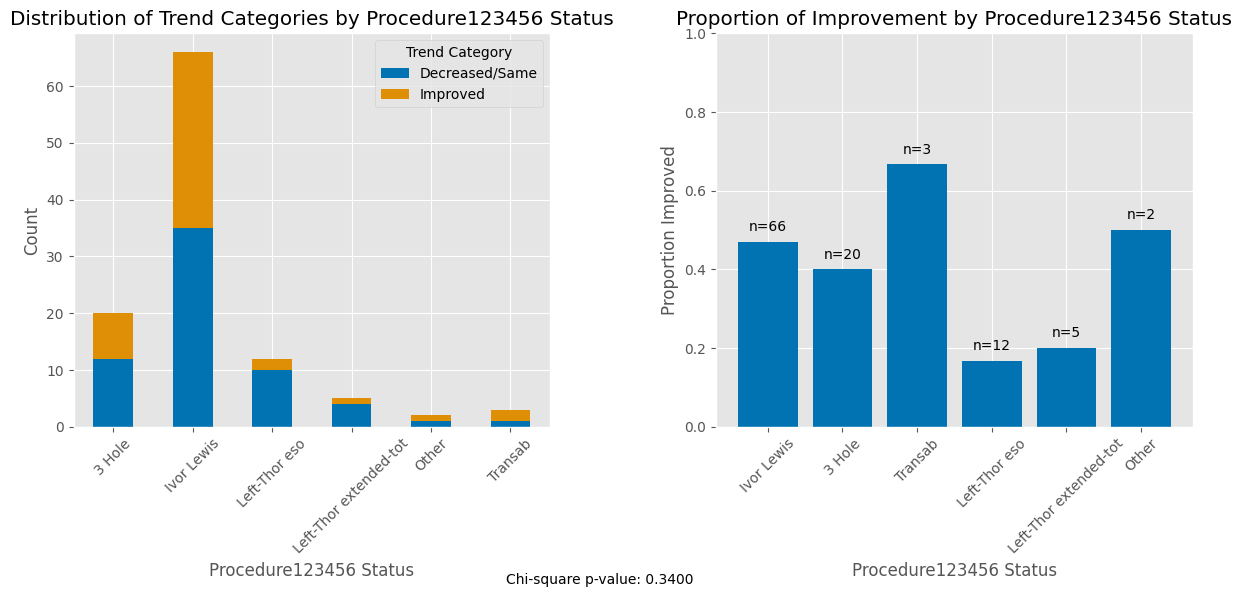

In [148]:
# Visualize with bar plot showing proportions
plt.figure(figsize=(12, 6))

# Subplot 1: Contingency table as stacked bar chart
plt.subplot(1, 2, 1)
contingency_table.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Distribution of Trend Categories by Procedure123456 Status")
plt.xlabel("Procedure123456 Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Trend Category")

# Subplot 2: Proportion of improvement by procedure123456 status
plt.subplot(1, 2, 2)
bars = plt.bar(proportion_df["procedure123456_status"], proportion_df["proportion_improved"])
plt.title("Proportion of Improvement by Procedure123456 Status")
plt.xlabel("Procedure123456 Status")
plt.ylabel("Proportion Improved")
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Add count labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'n={proportion_df.iloc[i]["total_count"]}',
             ha='center', va='bottom')

plt.annotate(f"Chi-square p-value: {p_value_chi2:.4f}", xy=(0.5, 0.02), 
             xycoords='figure fraction', ha='center')

plt.tight_layout()
plt.show()

# sensitivity analysis 7) surgery type (procedure123456)

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yjkweon2/jinenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yjkweon2/jinenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warn

Sensitivity Analysis Results:
    threshold  improvement_rate    chi2_p  logistic_p  odds_ratio
0           0          0.495575  0.283788    0.059160    0.783784
1           1          0.486726  0.331719    0.071619    0.833333
2           2          0.486726  0.331719    0.071619    0.833333
3           3          0.424779  0.344790    0.067168    0.923754
4           4          0.415929  0.345390    0.067168    0.752688
5           5          0.415929  0.345390    0.067168    0.752688
6           6          0.407080  0.388105    0.079228    0.800000
7           7          0.389381  0.404066    0.093097    0.687003
8           8          0.362832  0.298736    0.108997    0.730769
9           9          0.353982  0.166369    0.108997    0.730769
10         10          0.336283  0.230715    0.087261    0.828402


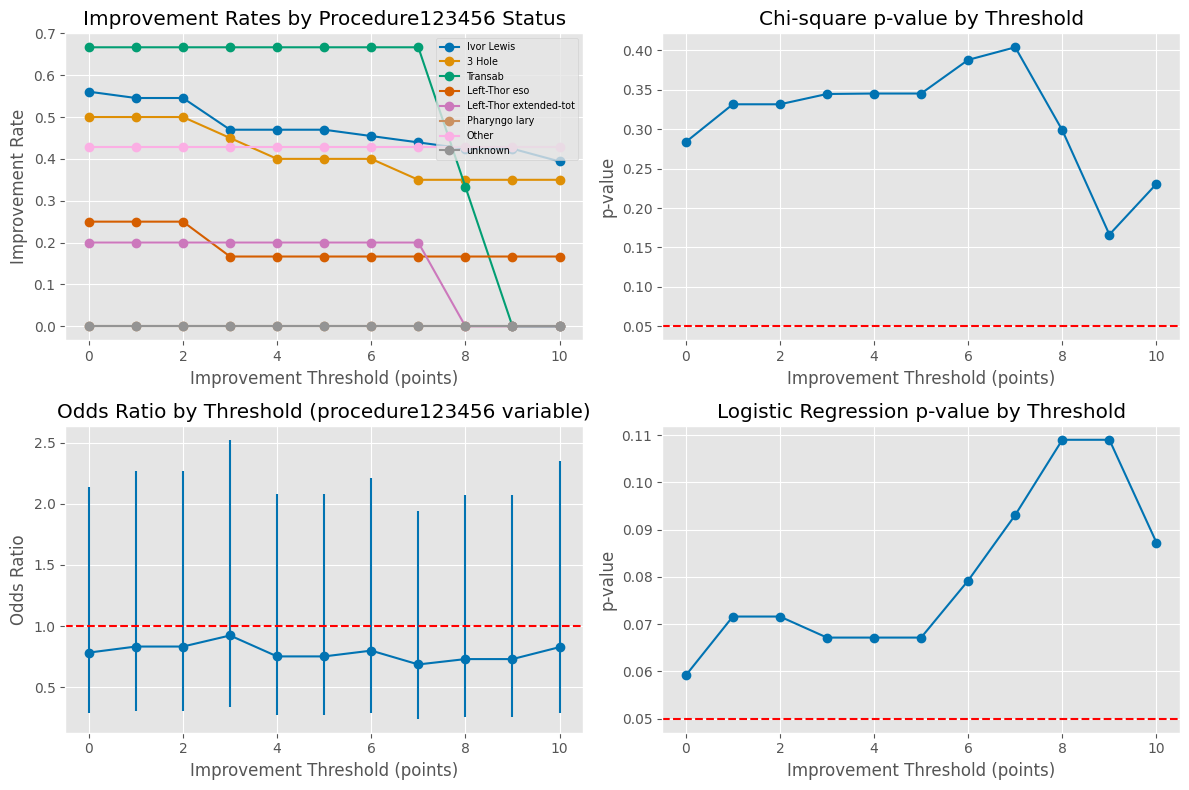


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              56                    57   49.557522   
1           1              55                    58   48.672566   
2           2              55                    58   48.672566   
3           3              48                    65   42.477876   
4           4              47                    66   41.592920   
5           5              47                    66   41.592920   
6           6              46                    67   40.707965   
7           7              44                    69   38.938053   
8           8              41                    72   36.283186   
9           9              40                    73   35.398230   
10         10              38                    75   33.628319   

    Decreased/Same %  
0          50.442478  
1          51.327434  
2          51.327434  
3          57.522124  
4          58.407080  
5          58.40

In [149]:
def analyze_improvement_threshold_procedure123456(data, threshold):
    """
    Analyze how the improvement threshold affects classification and procedure123456 status relationship
    
    Parameters:
    data: DataFrame containing procedure123456 and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Chi-square test
    try:
        contingency = pd.crosstab(df["procedure123456"], df["Improved"])
        chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)
    except:
        chi2, p_value_chi2 = None, None
    
    # Logistic regression with one-hot encoding
    try:
        procedure123456_dummies = pd.get_dummies(df["procedure123456"], prefix="procedure123456", drop_first=True).astype(int)
        X = sm.add_constant(procedure123456_dummies)
        y = df["Trend Category_binary"]
        
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        logistic_p = result.pvalues.min()  # Get minimum p-value from all procedure123456 coefficients
        
        # Get odds ratios and confidence intervals
        odds_ratios = np.exp(result.params[1:])  # Exclude intercept
        conf_int = result.conf_int()
        odds_ratio_lower_ci = np.exp(conf_int.iloc[1:, 0])  # Lower CI for procedure123456 variables
        odds_ratio_upper_ci = np.exp(conf_int.iloc[1:, 1])  # Upper CI for procedure123456 variables
        
        # Take the first procedure123456 variable's odds ratio as representative
        odds_ratio = odds_ratios.iloc[0] if len(odds_ratios) > 0 else None
        lower_ci = odds_ratio_lower_ci.iloc[0] if len(odds_ratio_lower_ci) > 0 else None
        upper_ci = odds_ratio_upper_ci.iloc[0] if len(odds_ratio_upper_ci) > 0 else None
        
    except:
        logistic_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2,
        "chi2_p": p_value_chi2,
        "logistic_p": logistic_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean_procedure = merged_df_procedure.dropna(subset=["procedure123456", "Change"]).drop_duplicates()
merged_df_clean_procedure["procedure123456"] = pd.to_numeric(merged_df_clean_procedure["procedure123456"], errors='coerce')
merged_df_clean_procedure = merged_df_clean_procedure.dropna(subset=["procedure123456"])

for threshold in thresholds:
    result = analyze_improvement_threshold_procedure123456(merged_df_clean_procedure, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))

# Plot improvement rates by procedure123456 status
plt.subplot(2, 2, 1)
for procedure123456_val, label in procedure123456_labels.items():
    rates = []
    for threshold in thresholds:
        subset = merged_df_clean_procedure[merged_df_clean_procedure["procedure123456"] == procedure123456_val]
        if len(subset) > 0:
            improved = (subset["Change"] >= threshold).sum()
            rate = improved / len(subset)
            rates.append(rate)
        else:
            rates.append(0)
    plt.plot(thresholds, rates, 'o-', label=label)

plt.title("Improvement Rates by Procedure123456 Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Improvement Rate")
plt.legend(fontsize='x-small')
plt.grid(True)

# Plot p-values from Chi-square test (equivalent to Mann-Whitney for categorical)
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-square p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (procedure123456 variable)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean_procedure.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

In [150]:
# Just the confidence intervals
print("95% Confidence Intervals for Odds Ratios:")
for threshold in sensitivity_df['threshold']:
    row = sensitivity_df[sensitivity_df['threshold'] == threshold].iloc[0]
    lower = row['odds_ratio_lower_ci']
    upper = row['odds_ratio_upper_ci']
    or_val = row['odds_ratio']
    
    if pd.notna(or_val):
        print(f"Threshold {threshold}: OR = {or_val:.3f} (95% CI: {lower:.3f} - {upper:.3f})")
    else:
        print(f"Threshold {threshold}: OR = N/A")

95% Confidence Intervals for Odds Ratios:
Threshold 0: OR = 0.784 (95% CI: 0.288 - 2.135)
Threshold 1: OR = 0.833 (95% CI: 0.306 - 2.269)
Threshold 2: OR = 0.833 (95% CI: 0.306 - 2.269)
Threshold 3: OR = 0.924 (95% CI: 0.338 - 2.523)
Threshold 4: OR = 0.753 (95% CI: 0.272 - 2.081)
Threshold 5: OR = 0.753 (95% CI: 0.272 - 2.081)
Threshold 6: OR = 0.800 (95% CI: 0.289 - 2.213)
Threshold 7: OR = 0.687 (95% CI: 0.243 - 1.943)
Threshold 8: OR = 0.731 (95% CI: 0.258 - 2.068)
Threshold 9: OR = 0.731 (95% CI: 0.258 - 2.068)
Threshold 10: OR = 0.828 (95% CI: 0.292 - 2.351)


# statistically significantly associated with 8) Neoadjuvant treatment

In [151]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [152]:
merged_df_neotx = score_comparison.merge(filtered_df[["id", "neotx___notx",
                                                    "neotx___chemo", "neotx___rads", "neotx___chemorads",
                                                    "neotx___immuno", "neotx___other"]], on="id", how="left")

# First, create a mapping dictionary
neotx_mapping = {
    "neotx___notx": 1,
    "neotx___chemo": 2,
    "neotx___rads": 3,
    "neotx___chemorads": 4,
    "neotx___immuno": 5,
    "neotx___other": 6
}

# Create the neotx column
def assign_neotx(row):
    # Get columns that are 1 (True)
    active_cols = [col for col in neotx_mapping.keys() if row[col] == 1]
    
    if len(active_cols) == 1:
        return neotx_mapping[active_cols[0]]
    elif len(active_cols) > 1:
        return 7  # mixed
    else:
        return None  # missing/NaN

merged_df_neotx['neotx'] = merged_df_neotx.apply(assign_neotx, axis=1)

# If you want to handle mixed at the patient level (across multiple rows per patient):
# Group by id and check if patient has multiple different neotx types
patient_neotx = merged_df_neotx.groupby('id')['neotx'].apply(lambda x: 7 if len(set(x.dropna())) > 1 else x.dropna().iloc[0] if len(x.dropna()) > 0 else None).reset_index()
patient_neotx.columns = ['id', 'final_neotx']

# Merge back
merged_df_neotx = merged_df_neotx.merge(patient_neotx[['id', 'final_neotx']], on='id', how='left')

# Drop the individual neotx columns and rename final_neotx
merged_df_neotx = merged_df_neotx.drop(columns=[
    "neotx___notx",
    "neotx___chemo",
    "neotx___rads",
    "neotx___chemorads",
    "neotx___immuno",
    "neotx___other",
    "neotx"
]).rename(columns={"final_neotx": "neotx"})

merged_df_neotx

,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,neotx
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,2.0
1,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,2.0
2,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,2.0
3,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,2.0
4,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,2.0
...,...,...,...,...,...,...,...,...
1195,1653,baseline_arm_1,112.0,153.0,41.0,True,Improved,2.0
1196,1653,baseline_arm_1,112.0,153.0,41.0,True,Improved,2.0
1197,1653,baseline_arm_1,112.0,153.0,41.0,True,Improved,2.0
1198,1653,baseline_arm_1,112.0,153.0,41.0,True,Improved,2.0


In [153]:
# Find patient IDs where all neotx values are missing
patients_all_missing = merged_df_neotx.groupby('id')['neotx'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute neotx for those patients with 9999.0 (unknown/missing indicator)
mask = merged_df_neotx['id'].isin(patients_to_impute)
merged_df_neotx.loc[mask, 'neotx'] = 9999.0

print(f"Imputed {len(patients_to_impute)} missing data patients with neotx = 9999.0 (unknown)")

# Create a clean dataframe with no missing values in neotx
merged_df_removedNA_neotx = merged_df_neotx.dropna(subset=["neotx"])
merged_df_expanded_neotx = merged_df_removedNA_neotx.drop_duplicates()
merged_df_removedNA_neotx = merged_df_expanded_neotx.copy()

print(merged_df_removedNA_neotx['neotx'].value_counts())
merged_df_removedNA_neotx

Imputed 3 missing data patients with neotx = 9999.0 (unknown)
neotx
2.0       66
7.0       17
1.0       10
4.0        9
9999.0     3
6.0        2
3.0        1
Name: count, dtype: int64


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,neotx
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,2.0
10,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,2.0
18,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,2.0
28,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,2.0
38,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,9999.0
...,...,...,...,...,...,...,...,...
1155,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,2.0
1163,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,2.0
1173,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,2.0
1182,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,2.0


In [154]:
# Create neotx status labels
neotx_labels = {1: "notx", 2: "chemo", 3: "rads", 4: "chemorads", 5: "immuno", 6: "other", 7: "mixed", 9999: "unknown"}
merged_df_removedNA_neotx["neotx_status"] = merged_df_removedNA_neotx["neotx"].map(neotx_labels)

In [155]:
# Show summary statistics by improvement group and neotx status
print("\nCrosstab of Neotx Status and Trend Category:")
contingency_table = pd.crosstab(merged_df_removedNA_neotx["neotx_status"], 
                               merged_df_removedNA_neotx["Trend Category"])
print(contingency_table)



Crosstab of Neotx Status and Trend Category:
Trend Category  Decreased/Same  Improved
neotx_status                            
chemo                       41        25
chemorads                    5         4
mixed                        8         9
notx                         6         4
other                        1         1
rads                         1         0
unknown                      1         2


In [156]:
# Chi-square test
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square test:")
print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value_chi2}")
print(f"Degrees of freedom: {dof}")


Chi-square test:
Chi-square statistic: 2.861543162719633
p-value: 0.8260132679708843
Degrees of freedom: 6


In [157]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_neotx["Trend Category_binary"] = merged_df_removedNA_neotx["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Clean data for logistic regression
clean_data = merged_df_removedNA_neotx.dropna(subset=["neotx", "Trend Category_binary"])

# Logistic regression with one-hot encoding for categorical neotx variable
neotx_dummies = pd.get_dummies(clean_data["neotx"], prefix="neotx", drop_first=True).astype(int)
X = sm.add_constant(neotx_dummies)
y = clean_data["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

         Current function value: 0.664366
         Iterations: 35

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  108
Model:                             Logit   Df Residuals:                      101
Method:                              MLE   Df Model:                            6
Date:                   Wed, 02 Jul 2025   Pseudo R-squ.:                 0.02183
Time:                           02:57:44   Log-Likelihood:                -71.752
converged:                         False   LL-Null:                       -73.353
Covariance Type:               nonrobust   LLR p-value:                    0.7830
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.4055      0.645     -0.628      0.530      -1.671       0.860
neotx

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [158]:
# Calculate proportions for plotting
proportion_data = []
for neotx_val, label in neotx_labels.items():
    subset = merged_df_removedNA_neotx[merged_df_removedNA_neotx["neotx"] == neotx_val]
    if len(subset) > 0:
        improved_count = len(subset[subset["Trend Category"] == "Improved"])
        total_count = len(subset)
        proportion = improved_count / total_count
        proportion_data.append({
            "neotx_status": label,
            "proportion_improved": proportion,
            "total_count": total_count,
            "improved_count": improved_count
        })

proportion_df = pd.DataFrame(proportion_data)
print(f"\nProportion of improvement by neotx status:")
print(proportion_df)



Proportion of improvement by neotx status:
  neotx_status  proportion_improved  total_count  improved_count
0         notx             0.400000           10               4
1        chemo             0.378788           66              25
2         rads             0.000000            1               0
3    chemorads             0.444444            9               4
4        other             0.500000            2               1
5        mixed             0.529412           17               9
6      unknown             0.666667            3               2


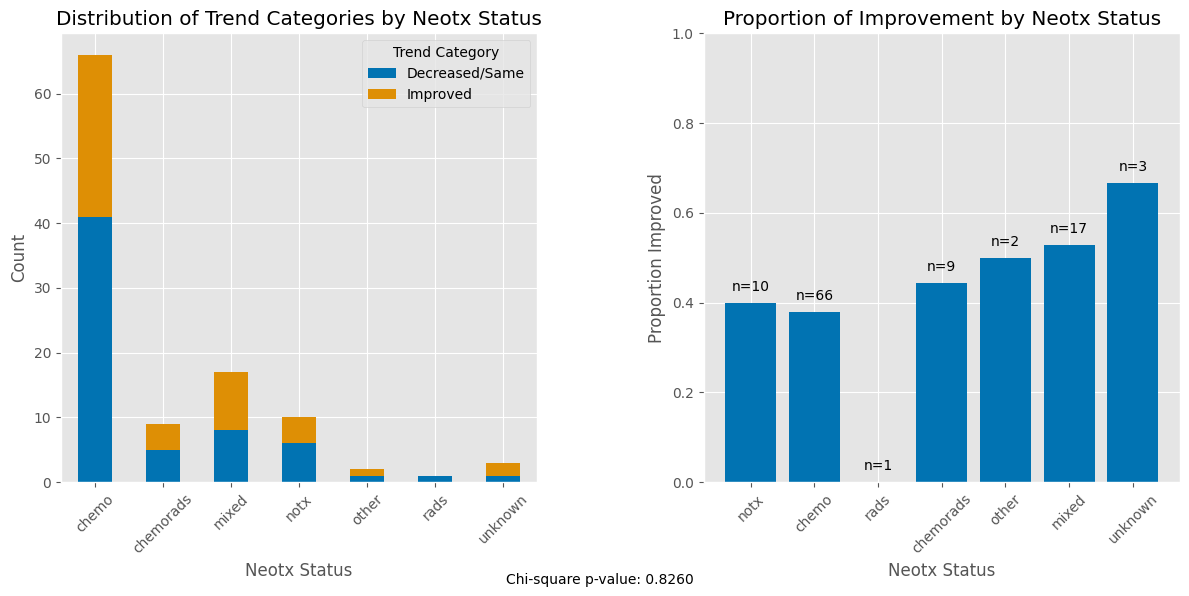

In [159]:
# Visualize with bar plot showing proportions
plt.figure(figsize=(12, 6))

# Subplot 1: Contingency table as stacked bar chart
plt.subplot(1, 2, 1)
contingency_table.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Distribution of Trend Categories by Neotx Status")
plt.xlabel("Neotx Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Trend Category")

# Subplot 2: Proportion of improvement by neotx status
plt.subplot(1, 2, 2)
bars = plt.bar(proportion_df["neotx_status"], proportion_df["proportion_improved"])
plt.title("Proportion of Improvement by Neotx Status")
plt.xlabel("Neotx Status")
plt.ylabel("Proportion Improved")
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Add count labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'n={proportion_df.iloc[i]["total_count"]}',
                ha='center', va='bottom')

plt.annotate(f"Chi-square p-value: {p_value_chi2:.4f}", xy=(0.5, 0.02), 
                xycoords='figure fraction', ha='center')

plt.tight_layout()
plt.show()


# sensitivity analysis 8) Neoadjuvant treatment

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yjkweon2/jinenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yjkweon2/jinenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warn

Sensitivity Analysis Results:
    threshold  improvement_rate    chi2_p  logistic_p  odds_ratio
0           0          0.500000  0.458033    0.347905    0.522523
1           1          0.490741  0.510767    0.289568    0.783784
2           2          0.490741  0.510767    0.289568    0.783784
3           3          0.425926  0.861835    0.427461    0.975000
4           4          0.416667  0.826013    0.427461    0.914634
5           5          0.416667  0.826013    0.427461    0.914634
6           6          0.407407  0.780894    0.427461    0.857143
7           7          0.388889  0.837448    0.517226    0.802326
8           8          0.361111  0.965252    0.219503    1.248062
9           9          0.351852  0.955206    0.219503    1.166667
10         10          0.333333  0.966005    0.219503    1.088889


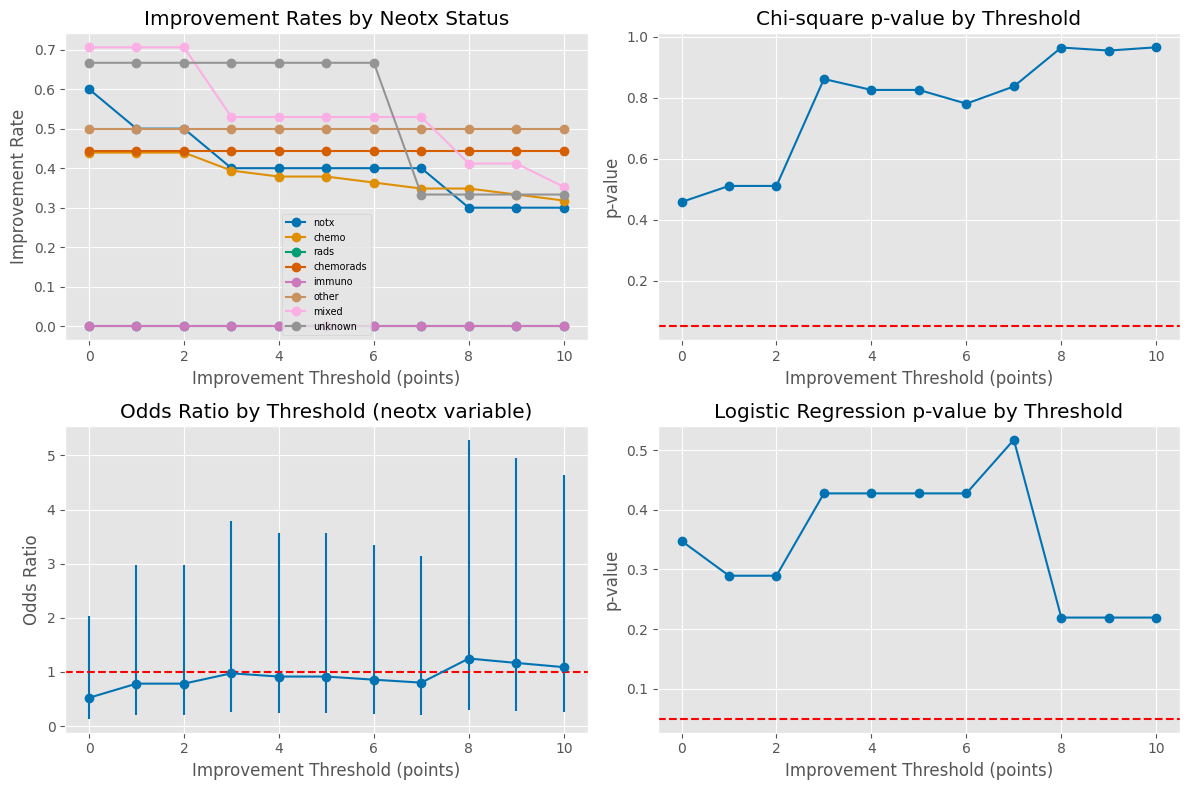


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              54                    54   50.000000   
1           1              53                    55   49.074074   
2           2              53                    55   49.074074   
3           3              46                    62   42.592593   
4           4              45                    63   41.666667   
5           5              45                    63   41.666667   
6           6              44                    64   40.740741   
7           7              42                    66   38.888889   
8           8              39                    69   36.111111   
9           9              38                    70   35.185185   
10         10              36                    72   33.333333   

    Decreased/Same %  
0          50.000000  
1          50.925926  
2          50.925926  
3          57.407407  
4          58.333333  
5          58.33

In [160]:
def analyze_improvement_threshold_neotx(data, threshold):
    """
    Analyze how the improvement threshold affects classification and neotx status relationship
    
    Parameters:
    data: DataFrame containing neotx and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Chi-square test
    try:
        contingency = pd.crosstab(df["neotx"], df["Improved"])
        chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)
    except:
        chi2, p_value_chi2 = None, None
    
    # Logistic regression with one-hot encoding
    try:
        neotx_dummies = pd.get_dummies(df["neotx"], prefix="neotx", drop_first=True).astype(int)
        X = sm.add_constant(neotx_dummies)
        y = df["Trend Category_binary"]
        
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        logistic_p = result.pvalues.min()  # Get minimum p-value from all neotx coefficients
        
        # Get odds ratios and confidence intervals
        odds_ratios = np.exp(result.params[1:])  # Exclude intercept
        conf_int = result.conf_int()
        odds_ratio_lower_ci = np.exp(conf_int.iloc[1:, 0])  # Lower CI for neotx variables
        odds_ratio_upper_ci = np.exp(conf_int.iloc[1:, 1])  # Upper CI for neotx variables
        
        # Take the first neotx variable's odds ratio as representative
        odds_ratio = odds_ratios.iloc[0] if len(odds_ratios) > 0 else None
        lower_ci = odds_ratio_lower_ci.iloc[0] if len(odds_ratio_lower_ci) > 0 else None
        upper_ci = odds_ratio_upper_ci.iloc[0] if len(odds_ratio_upper_ci) > 0 else None
        
    except:
        logistic_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2,
        "chi2_p": p_value_chi2,
        "logistic_p": logistic_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean_neotx = merged_df_neotx.dropna(subset=["neotx", "Change"]).drop_duplicates()
merged_df_clean_neotx["neotx"] = pd.to_numeric(merged_df_clean_neotx["neotx"], errors='coerce')
merged_df_clean_neotx = merged_df_clean_neotx.dropna(subset=["neotx"])

for threshold in thresholds:
    result = analyze_improvement_threshold_neotx(merged_df_clean_neotx, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))

# Plot improvement rates by neotx status
plt.subplot(2, 2, 1)
for neotx_val, label in neotx_labels.items():
    rates = []
    for threshold in thresholds:
        subset = merged_df_clean_neotx[merged_df_clean_neotx["neotx"] == neotx_val]
        if len(subset) > 0:
            improved = (subset["Change"] >= threshold).sum()
            rate = improved / len(subset)
            rates.append(rate)
        else:
            rates.append(0)
    plt.plot(thresholds, rates, 'o-', label=label)

plt.title("Improvement Rates by Neotx Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Improvement Rate")
plt.legend(fontsize='x-small')
plt.grid(True)

# Plot p-values from Chi-square test (equivalent to Mann-Whitney for categorical)
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-square p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (neotx variable)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean_neotx.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

In [161]:
# Just the confidence intervals
print("95% Confidence Intervals for Odds Ratios:")
for threshold in sensitivity_df['threshold']:
    row = sensitivity_df[sensitivity_df['threshold'] == threshold].iloc[0]
    lower = row['odds_ratio_lower_ci']
    upper = row['odds_ratio_upper_ci']
    or_val = row['odds_ratio']
    
    if pd.notna(or_val):
        print(f"Threshold {threshold}: OR = {or_val:.3f} (95% CI: {lower:.3f} - {upper:.3f})")
    else:
        print(f"Threshold {threshold}: OR = N/A")

95% Confidence Intervals for Odds Ratios:
Threshold 0: OR = 0.523 (95% CI: 0.135 - 2.026)
Threshold 1: OR = 0.784 (95% CI: 0.207 - 2.968)
Threshold 2: OR = 0.784 (95% CI: 0.207 - 2.968)
Threshold 3: OR = 0.975 (95% CI: 0.251 - 3.792)
Threshold 4: OR = 0.915 (95% CI: 0.235 - 3.561)
Threshold 5: OR = 0.915 (95% CI: 0.235 - 3.561)
Threshold 6: OR = 0.857 (95% CI: 0.220 - 3.343)
Threshold 7: OR = 0.802 (95% CI: 0.205 - 3.134)
Threshold 8: OR = 1.248 (95% CI: 0.294 - 5.290)
Threshold 9: OR = 1.167 (95% CI: 0.275 - 4.954)
Threshold 10: OR = 1.089 (95% CI: 0.256 - 4.634)


# statistically significantly associated with 9) age (age_diagnosis)

In [162]:
merged_df_age = score_comparison.merge(filtered_df[["id", "age_diagnosis"]], on="id", how="left")

# Calculate median age from all non-missing values
median_age = merged_df_age['age_diagnosis'].median()

# Find patient IDs where all age values are missing
patients_all_missing = merged_df_age.groupby('id')['age_diagnosis'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute age for those patients
mask = merged_df_age['id'].isin(patients_to_impute)
merged_df_age.loc[mask, 'age_diagnosis'] = median_age
print(f"Imputed {len(patients_to_impute)} patients with median age: {median_age:.2f}")

# Create a clean dataframe with no missing values in age
merged_df_removedNA_age = merged_df_age.dropna(subset=["age_diagnosis"])
merged_df_expanded_age = merged_df_removedNA_age.drop_duplicates()
merged_df_removedNA_age = merged_df_expanded_age.copy()
merged_df_removedNA_age

Imputed 11 patients with median age: 65.48


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,age_diagnosis
2,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,29.722718
16,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,57.597350
27,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,64.110830
31,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,50.804602
39,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,66.229970
...,...,...,...,...,...,...,...,...
1161,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,69.876863
1164,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,79.245980
1176,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,60.529648
1184,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,55.623319


In [163]:
# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_age.groupby("Trend Category")["age_diagnosis"].describe())

# Perform Mann-Whitney U test to compare Baseline scores between groups
improved_baseline = merged_df_removedNA_age[merged_df_removedNA_age["Trend Category"] == "Improved"]["age_diagnosis"]
decreased_same_baseline = merged_df_removedNA_age[merged_df_removedNA_age["Trend Category"] == "Decreased/Same"]["age_diagnosis"]

stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
print(f"\nMann-Whitney U test:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")


Baseline scores by Trend Category:
                count       mean       std        min        25%        50%  \
Trend Category                                                                
Decreased/Same   63.0  63.905656  8.262050  35.168416  59.579480  65.479727   
Improved         45.0  64.820350  9.591236  29.722718  60.113486  65.479727   

                      75%        max  
Trend Category                        
Decreased/Same  69.471766  79.527985  
Improved        68.907644  83.593663  

Mann-Whitney U test:
Statistic: 1457.0
p-value: 0.8078810216170373


In [164]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_age["Trend Category_binary"] = merged_df_removedNA_age["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Logistic regression with Baseline as predictor
X = sm.add_constant(merged_df_removedNA_age["age_diagnosis"])
y = merged_df_removedNA_age["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.677861
         Iterations 4

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  108
Model:                             Logit   Df Residuals:                      106
Method:                              MLE   Df Model:                            1
Date:                   Wed, 02 Jul 2025   Pseudo R-squ.:                0.001961
Time:                           02:57:45   Log-Likelihood:                -73.209
converged:                          True   LL-Null:                       -73.353
Covariance Type:               nonrobust   LLR p-value:                    0.5917
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.1114      1.468     -0.757  

In [165]:
# Calculate odds ratio for a 10-point increase in baseline score
baseline_coef = result.params["age_diagnosis"]
odds_ratio_10points = np.exp(baseline_coef * 10)
print(f"\nOdds Ratio for a 10-point increase in baseline score: {odds_ratio_10points:.3f}")

# Calculate confidence interval for the odds ratio
baseline_conf_int = result.conf_int().loc["age_diagnosis"]
lower_ci_10points = np.exp(baseline_conf_int[0] * 10)
upper_ci_10points = np.exp(baseline_conf_int[1] * 10)
print(f"95% CI for a 10-point increase in baseline score: ({lower_ci_10points:.3f}, {upper_ci_10points:.3f})")


Odds Ratio for a 10-point increase in baseline score: 1.128
95% CI for a 10-point increase in baseline score: (0.725, 1.756)


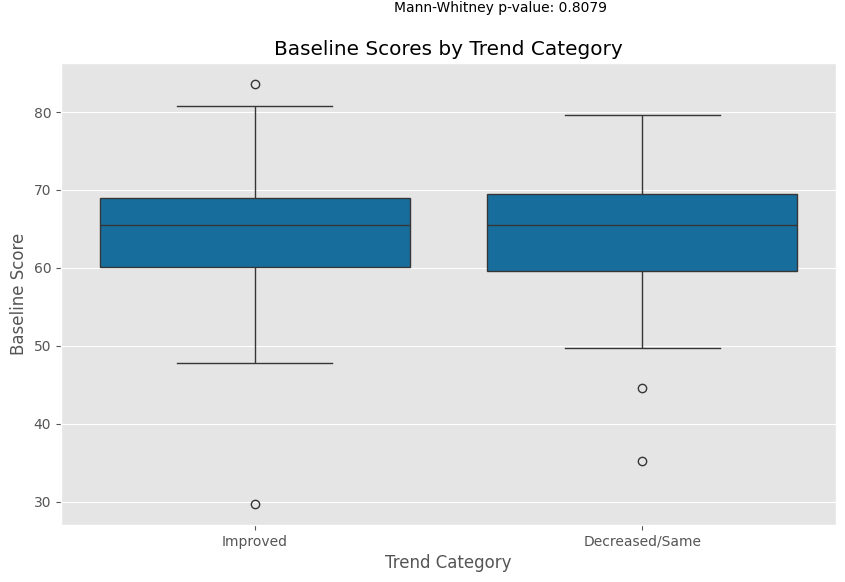

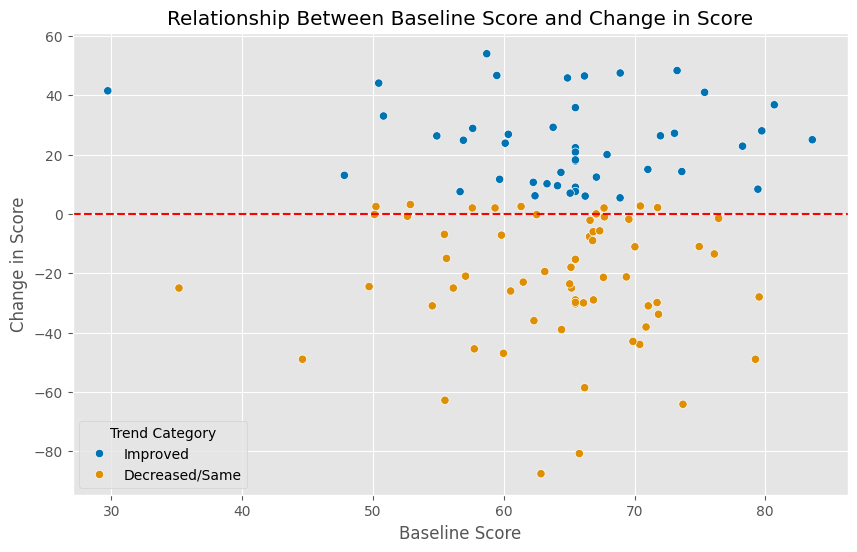

In [166]:
# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="age_diagnosis", data=merged_df_removedNA_age)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
             xycoords='figure fraction', ha='center')
plt.show()



# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="age_diagnosis", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_age)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

# sensitivity analysis 9) age (age_diagnosis)

Sensitivity Analysis Results:
    threshold  improvement_rate  mean_age_improved  mean_age_not_improved  \
0           0          0.500000          64.355855              64.217702   
1           1          0.490741          64.304635              64.269571   
2           2          0.490741          64.304635              64.269571   
3           3          0.425926          64.560300              64.083843   
4           4          0.416667          64.820350              63.905656   
5           5          0.416667          64.820350              63.905656   
6           6          0.407407          64.727709              63.983639   
7           7          0.388889          64.747566              63.993550   
8           8          0.361111          64.927546              63.924606   
9           9          0.351852          64.545776              64.146180   
10         10          0.333333          64.531915              64.164210   

    mann_whitney_p  logistic_p  odds_ratio  


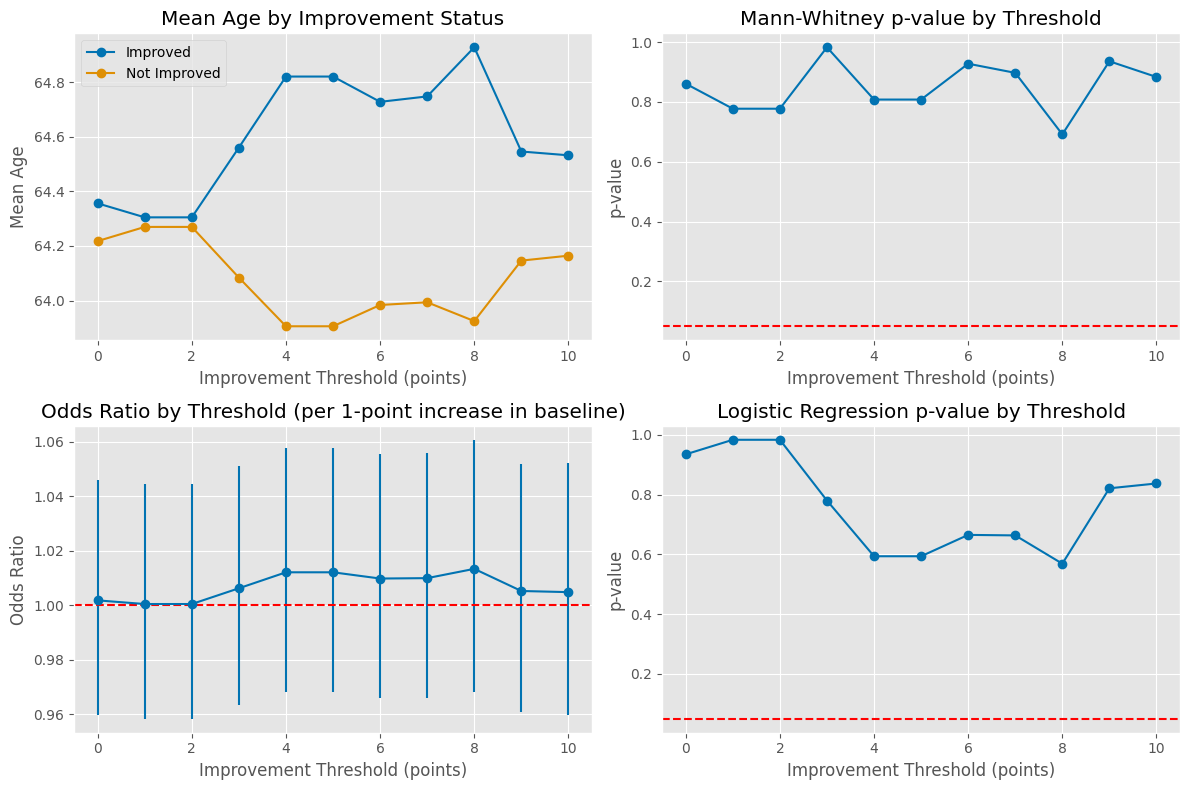


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              54                    54   50.000000   
1           1              53                    55   49.074074   
2           2              53                    55   49.074074   
3           3              46                    62   42.592593   
4           4              45                    63   41.666667   
5           5              45                    63   41.666667   
6           6              44                    64   40.740741   
7           7              42                    66   38.888889   
8           8              39                    69   36.111111   
9           9              38                    70   35.185185   
10         10              36                    72   33.333333   

    Decreased/Same %  
0          50.000000  
1          50.925926  
2          50.925926  
3          57.407407  
4          58.333333  
5          58.33

In [167]:
def analyze_improvement_threshold(data, threshold):
    """
    Analyze how the improvement threshold affects classification and baseline score relationship
    
    Parameters:
    data: DataFrame containing Baseline and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Mann-Whitney U test
    improved_baseline = df[df["Improved"]]["age_diagnosis"]
    decreased_same_baseline = df[~df["Improved"]]["age_diagnosis"]
    
    if len(improved_baseline) > 0 and len(decreased_same_baseline) > 0:
        stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
    else:
        stat, p_value = None, None
        
    # Mean age_diagnosis in each group
    mean_age_improved = improved_baseline.mean() if len(improved_baseline) > 0 else None
    mean_age_not_improved = decreased_same_baseline.mean() if len(decreased_same_baseline) > 0 else None
    
    # Logistic regression
    X = sm.add_constant(df["age_diagnosis"])
    y = df["Trend Category_binary"]
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        baseline_coef = result.params["age_diagnosis"]
        baseline_p = result.pvalues["age_diagnosis"]
        odds_ratio = np.exp(baseline_coef)
        
        # Confidence intervals
        baseline_conf_int = result.conf_int().loc["age_diagnosis"]
        lower_ci = np.exp(baseline_conf_int[0])
        upper_ci = np.exp(baseline_conf_int[1])
    except:
        baseline_coef = None
        baseline_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mean_age_improved": mean_age_improved,
        "mean_age_not_improved": mean_age_not_improved,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": baseline_coef,
        "logistic_p": baseline_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean = merged_df_age.dropna(subset=["age_diagnosis", "Change"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_improvement_threshold(merged_df_clean, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_age_improved", "mean_age_not_improved", "mann_whitney_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_age_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_age_not_improved"], 'o-', label='Not Improved')
plt.title("Mean Age by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean Age")
plt.legend()
plt.grid(True)

# Plot p-values from Mann-Whitney test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (per 1-point increase in baseline)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

In [168]:
# Just the confidence intervals
print("95% Confidence Intervals for Odds Ratios:")
for threshold in sensitivity_df['threshold']:
    row = sensitivity_df[sensitivity_df['threshold'] == threshold].iloc[0]
    lower = row['odds_ratio_lower_ci']
    upper = row['odds_ratio_upper_ci']
    or_val = row['odds_ratio']
    
    if pd.notna(or_val):
        print(f"Threshold {threshold}: OR = {or_val:.3f} (95% CI: {lower:.3f} - {upper:.3f})")
    else:
        print(f"Threshold {threshold}: OR = N/A")

95% Confidence Intervals for Odds Ratios:
Threshold 0: OR = 1.002 (95% CI: 0.960 - 1.046)
Threshold 1: OR = 1.000 (95% CI: 0.958 - 1.044)
Threshold 2: OR = 1.000 (95% CI: 0.958 - 1.044)
Threshold 3: OR = 1.006 (95% CI: 0.963 - 1.051)
Threshold 4: OR = 1.012 (95% CI: 0.968 - 1.058)
Threshold 5: OR = 1.012 (95% CI: 0.968 - 1.058)
Threshold 6: OR = 1.010 (95% CI: 0.966 - 1.056)
Threshold 7: OR = 1.010 (95% CI: 0.966 - 1.056)
Threshold 8: OR = 1.013 (95% CI: 0.968 - 1.061)
Threshold 9: OR = 1.005 (95% CI: 0.961 - 1.052)
Threshold 10: OR = 1.005 (95% CI: 0.960 - 1.052)


# statistically significantly associated with 10) sex

In [169]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [170]:
# Merge score_comparison with gender data
merged_df_gender = score_comparison.merge(filtered_df[["id", "gender"]], on="id", how="left")

print(merged_df_gender['gender'].value_counts())

# Find patient IDs where all gender values are missing
patients_all_missing = merged_df_gender.groupby('id')['gender'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute gender for those patients with 9999.0 (unknown/missing indicator)
mask = merged_df_gender['id'].isin(patients_to_impute)
merged_df_gender.loc[mask, 'gender'] = 9999.0

print(f"Imputed {len(patients_to_impute)} missing data patients with gender = 9999.0 (unknown)")

# Create a clean dataframe with no missing values in gender
merged_df_removedNA_gender = merged_df_gender.dropna(subset=["gender"])
merged_df_expanded_gender = merged_df_removedNA_gender.drop_duplicates()
merged_df_removedNA_gender = merged_df_expanded_gender.copy()


print(merged_df_removedNA_gender['gender'].value_counts())
merged_df_removedNA_gender


gender
1.0    86
2.0    25
Name: count, dtype: int64
Imputed 0 missing data patients with gender = 9999.0 (unknown)
gender
1.0    84
2.0    24
Name: count, dtype: int64


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,gender
3,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
15,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,1.0
21,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,1.0
34,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,1.0
41,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,2.0
...,...,...,...,...,...,...,...,...
1155,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,1.0
1167,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,1.0
1180,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,1.0
1188,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,1.0


In [171]:
# Create gender status labels
gender_labels = {1: "Male", 2: "Female"}
merged_df_removedNA_gender["gender_status"] = merged_df_removedNA_gender["gender"].map(gender_labels)

# Show summary statistics by improvement group and gender status
print("\nCrosstab of Gender Status and Trend Category:")
contingency_table = pd.crosstab(merged_df_removedNA_gender["gender_status"], 
                                merged_df_removedNA_gender["Trend Category"])
print(contingency_table)


Crosstab of Gender Status and Trend Category:
Trend Category  Decreased/Same  Improved
gender_status                           
Female                      17         7
Male                        46        38


In [172]:
# Chi-square test
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square test:")
print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value_chi2}")
print(f"Degrees of freedom: {dof}")


Chi-square test:
Chi-square statistic: 1.3775510204081634
p-value: 0.24051873846133554
Degrees of freedom: 1


In [173]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_gender["Trend Category_binary"] = merged_df_removedNA_gender["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Clean data for logistic regression
clean_data = merged_df_removedNA_gender.dropna(subset=["gender", "Trend Category_binary"])

# Logistic regression with one-hot encoding for categorical gender variable
gender_dummies = pd.get_dummies(clean_data["gender"], prefix="gender", drop_first=True).astype(int)
X = sm.add_constant(gender_dummies)
y = clean_data["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.669723
         Iterations 5

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  108
Model:                             Logit   Df Residuals:                      106
Method:                              MLE   Df Model:                            1
Date:                   Wed, 02 Jul 2025   Pseudo R-squ.:                 0.01394
Time:                           02:57:46   Log-Likelihood:                -72.330
converged:                          True   LL-Null:                       -73.353
Covariance Type:               nonrobust   LLR p-value:                    0.1527
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1911      0.219     -0.872      0.383

In [174]:
# Calculate proportions for plotting
proportion_data = []
for gender_val, label in gender_labels.items():
    subset = merged_df_removedNA_gender[merged_df_removedNA_gender["gender"] == gender_val]
    if len(subset) > 0:
        improved_count = len(subset[subset["Trend Category"] == "Improved"])
        total_count = len(subset)
        proportion = improved_count / total_count
        proportion_data.append({
            "gender_status": label,
            "proportion_improved": proportion,
            "total_count": total_count,
            "improved_count": improved_count
        })

proportion_df = pd.DataFrame(proportion_data)
print(f"\nProportion of improvement by gender status:")
print(proportion_df)


Proportion of improvement by gender status:
  gender_status  proportion_improved  total_count  improved_count
0          Male             0.452381           84              38
1        Female             0.291667           24               7


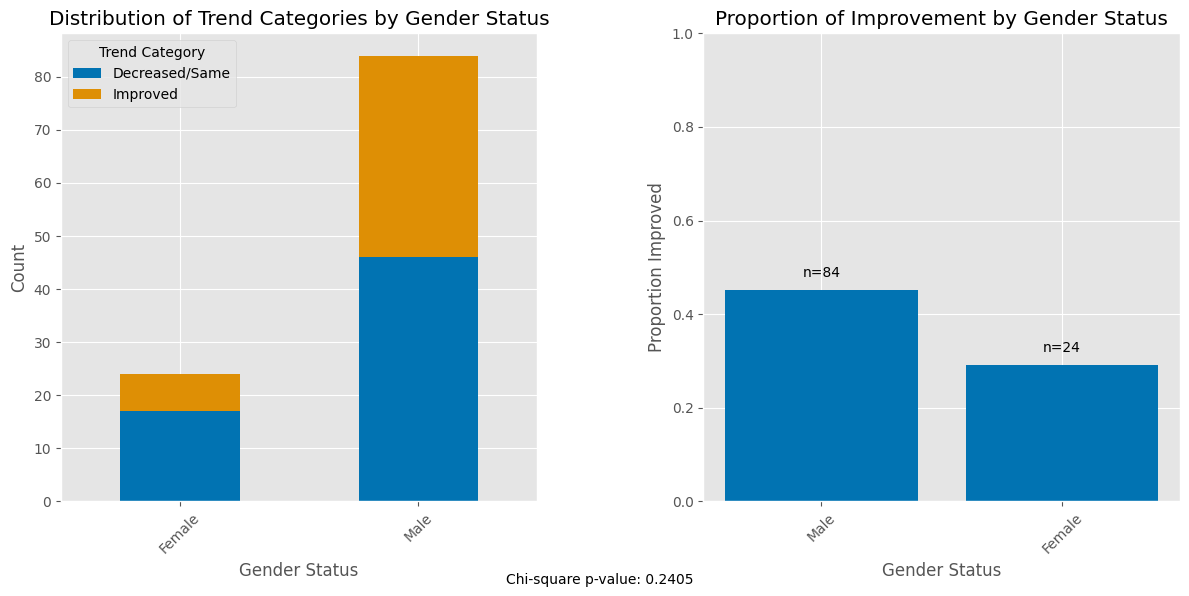

In [175]:
# Visualize with bar plot showing proportions
plt.figure(figsize=(12, 6))

# Subplot 1: Contingency table as stacked bar chart
plt.subplot(1, 2, 1)
contingency_table.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Distribution of Trend Categories by Gender Status")
plt.xlabel("Gender Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Trend Category")

# Subplot 2: Proportion of improvement by gender status
plt.subplot(1, 2, 2)
bars = plt.bar(proportion_df["gender_status"], proportion_df["proportion_improved"])
plt.title("Proportion of Improvement by Gender Status")
plt.xlabel("Gender Status")
plt.ylabel("Proportion Improved")
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Add count labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'n={proportion_df.iloc[i]["total_count"]}',
             ha='center', va='bottom')

plt.annotate(f"Chi-square p-value: {p_value_chi2:.4f}", xy=(0.5, 0.02), 
             xycoords='figure fraction', ha='center')

plt.tight_layout()
plt.show()

# sensitivity analysis 10) sex

Sensitivity Analysis Results:
    threshold  improvement_rate    chi2_p  logistic_p  odds_ratio
0           0          0.500000  0.816961    0.643736    0.806798
1           1          0.490741  0.897668    0.718921    0.846154
2           2          0.490741  0.897668    0.718921    0.846154
3           3          0.425926  0.420168    0.300895    0.605263
4           4          0.416667  0.240519    0.163549    0.498452
5           5          0.416667  0.240519    0.163549    0.498452
6           6          0.407407  0.283287    0.194911    0.523052
7           7          0.388889  0.178556    0.119178    0.444444
8           8          0.361111  0.127026    0.082746    0.386997
9           9          0.351852  0.153552    0.051350    0.406699
10         10          0.333333  0.219644    0.017698    0.449915


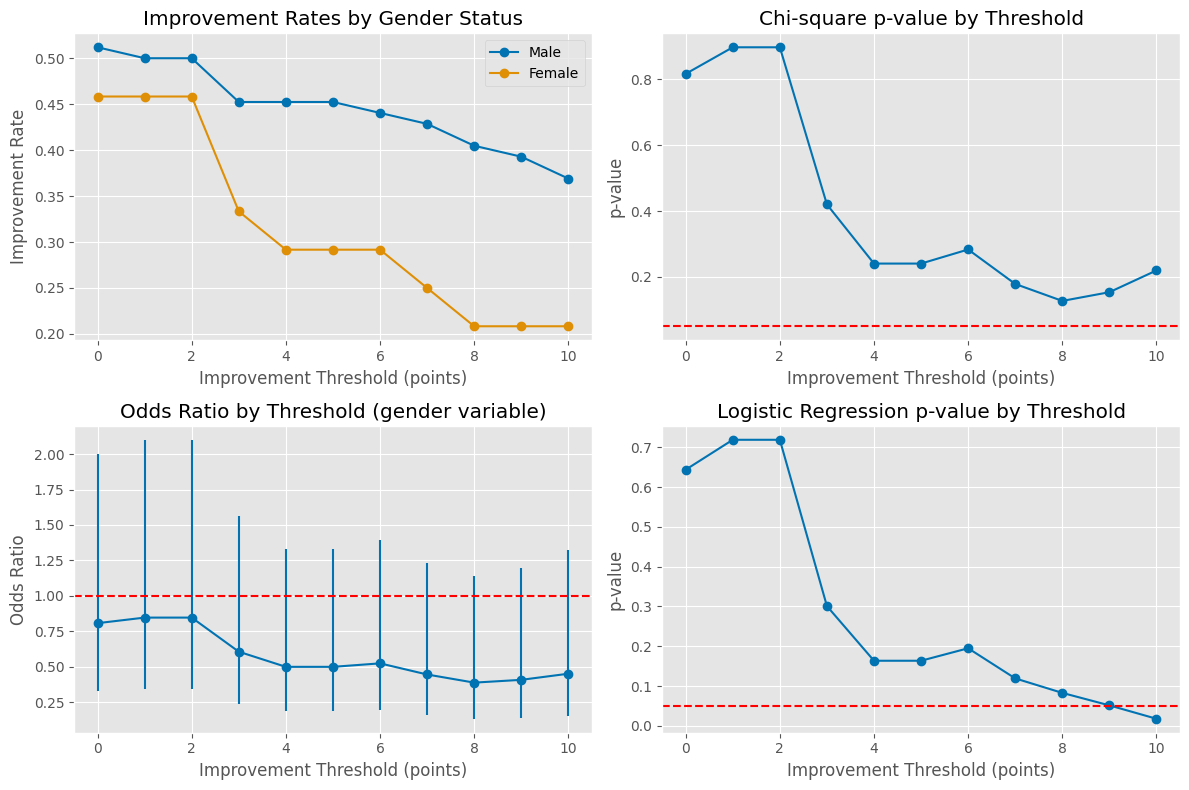


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              54                    54   50.000000   
1           1              53                    55   49.074074   
2           2              53                    55   49.074074   
3           3              46                    62   42.592593   
4           4              45                    63   41.666667   
5           5              45                    63   41.666667   
6           6              44                    64   40.740741   
7           7              42                    66   38.888889   
8           8              39                    69   36.111111   
9           9              38                    70   35.185185   
10         10              36                    72   33.333333   

    Decreased/Same %  
0          50.000000  
1          50.925926  
2          50.925926  
3          57.407407  
4          58.333333  
5          58.33

In [176]:
def analyze_improvement_threshold_gender(data, threshold):
    """
    Analyze how the improvement threshold affects classification and gender status relationship
    
    Parameters:
    data: DataFrame containing gender and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Chi-square test
    try:
        contingency = pd.crosstab(df["gender"], df["Improved"])
        chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)
    except:
        chi2, p_value_chi2 = None, None
    
    # Logistic regression with one-hot encoding
    try:
        gender_dummies = pd.get_dummies(df["gender"], prefix="gender", drop_first=True).astype(int)
        X = sm.add_constant(gender_dummies)
        y = df["Trend Category_binary"]
        
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        logistic_p = result.pvalues.min()  # Get minimum p-value from all gender coefficients
        
        # Get odds ratios and confidence intervals
        odds_ratios = np.exp(result.params[1:])  # Exclude intercept
        conf_int = result.conf_int()
        odds_ratio_lower_ci = np.exp(conf_int.iloc[1:, 0])  # Lower CI for gender variables
        odds_ratio_upper_ci = np.exp(conf_int.iloc[1:, 1])  # Upper CI for gender variables
        
        # Take the first gender variable's odds ratio as representative
        odds_ratio = odds_ratios.iloc[0] if len(odds_ratios) > 0 else None
        lower_ci = odds_ratio_lower_ci.iloc[0] if len(odds_ratio_lower_ci) > 0 else None
        upper_ci = odds_ratio_upper_ci.iloc[0] if len(odds_ratio_upper_ci) > 0 else None
        
    except:
        logistic_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2,
        "chi2_p": p_value_chi2,
        "logistic_p": logistic_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean_gender = merged_df_gender.dropna(subset=["gender", "Change"]).drop_duplicates()
merged_df_clean_gender["gender"] = pd.to_numeric(merged_df_clean_gender["gender"], errors='coerce')
merged_df_clean_gender = merged_df_clean_gender.dropna(subset=["gender"])

for threshold in thresholds:
    result = analyze_improvement_threshold_gender(merged_df_clean_gender, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))

# Plot improvement rates by gender status
plt.subplot(2, 2, 1)
for gender_val, label in gender_labels.items():
    rates = []
    for threshold in thresholds:
        subset = merged_df_clean_gender[merged_df_clean_gender["gender"] == gender_val]
        if len(subset) > 0:
            improved = (subset["Change"] >= threshold).sum()
            rate = improved / len(subset)
            rates.append(rate)
        else:
            rates.append(0)
    plt.plot(thresholds, rates, 'o-', label=label)

plt.title("Improvement Rates by Gender Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Improvement Rate")
plt.legend()
plt.grid(True)

# Plot p-values from Chi-square test (equivalent to Mann-Whitney for categorical)
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-square p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (gender variable)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean_gender.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

In [177]:
# Just the confidence intervals
print("95% Confidence Intervals for Odds Ratios:")
for threshold in sensitivity_df['threshold']:
    row = sensitivity_df[sensitivity_df['threshold'] == threshold].iloc[0]
    lower = row['odds_ratio_lower_ci']
    upper = row['odds_ratio_upper_ci']
    or_val = row['odds_ratio']
    
    if pd.notna(or_val):
        print(f"Threshold {threshold}: OR = {or_val:.3f} (95% CI: {lower:.3f} - {upper:.3f})")
    else:
        print(f"Threshold {threshold}: OR = N/A")

95% Confidence Intervals for Odds Ratios:
Threshold 0: OR = 0.807 (95% CI: 0.325 - 2.004)
Threshold 1: OR = 0.846 (95% CI: 0.341 - 2.102)
Threshold 2: OR = 0.846 (95% CI: 0.341 - 2.102)
Threshold 3: OR = 0.605 (95% CI: 0.234 - 1.567)
Threshold 4: OR = 0.498 (95% CI: 0.187 - 1.327)
Threshold 5: OR = 0.498 (95% CI: 0.187 - 1.327)
Threshold 6: OR = 0.523 (95% CI: 0.196 - 1.394)
Threshold 7: OR = 0.444 (95% CI: 0.160 - 1.233)
Threshold 8: OR = 0.387 (95% CI: 0.132 - 1.136)
Threshold 9: OR = 0.407 (95% CI: 0.138 - 1.195)
Threshold 10: OR = 0.450 (95% CI: 0.153 - 1.325)


# statistically significantly associated with 11) charlson comorbidity index (cci_total)

In [178]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [179]:
merged_df_cci = score_comparison.merge(filtered_df[["id", "cci_total"]], on="id", how="left")

# Calculate median cci from all non-missing values
median_cci = merged_df_cci['cci_total'].median()

# Find patient IDs where all cci values are missing
patients_all_missing = merged_df_cci.groupby('id')['cci_total'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute cci for those patients
mask = merged_df_cci['id'].isin(patients_to_impute)
merged_df_cci.loc[mask, 'cci_total'] = median_cci
print(f"Imputed {len(patients_to_impute)} patients with median cci: {median_cci:.2f}")

# Create a clean dataframe with no missing values in cci
merged_df_removedNA_cci = merged_df_cci.dropna(subset=["cci_total"])
merged_df_expanded_cci = merged_df_removedNA_cci.drop_duplicates()
merged_df_removedNA_cci = merged_df_expanded_cci.copy()
merged_df_removedNA_cci

Imputed 22 patients with median cci: 4.00


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,cci_total
3,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,2.0
10,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,4.0
18,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,4.0
28,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,4.0
41,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,4.0
...,...,...,...,...,...,...,...,...
1155,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,4.0
1167,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,6.0
1180,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,4.0
1188,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,4.0


In [180]:
# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_cci.groupby("Trend Category")["cci_total"].describe())


Baseline scores by Trend Category:
                count      mean       std  min  25%  50%  75%  max
Trend Category                                                    
Decreased/Same   63.0  3.730159  1.370264  0.0  3.0  4.0  4.5  6.0
Improved         45.0  4.222222  1.550497  2.0  4.0  4.0  5.0  9.0


In [181]:
# Perform Mann-Whitney U test to compare Baseline scores between groups
improved_baseline = merged_df_removedNA_cci[merged_df_removedNA_cci["Trend Category"] == "Improved"]["cci_total"]
decreased_same_baseline = merged_df_removedNA_cci[merged_df_removedNA_cci["Trend Category"] == "Decreased/Same"]["cci_total"]

stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
print(f"\nMann-Whitney U test:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")



Mann-Whitney U test:
Statistic: 1601.5
p-value: 0.23057631785605204


In [182]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_cci["Trend Category_binary"] = merged_df_removedNA_cci["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Logistic regression with Baseline as predictor
X = sm.add_constant(merged_df_removedNA_cci["cci_total"])
y = merged_df_removedNA_cci["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.665091
         Iterations 5

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  108
Model:                             Logit   Df Residuals:                      106
Method:                              MLE   Df Model:                            1
Date:                   Wed, 02 Jul 2025   Pseudo R-squ.:                 0.02076
Time:                           02:57:48   Log-Likelihood:                -71.830
converged:                          True   LL-Null:                       -73.353
Covariance Type:               nonrobust   LLR p-value:                   0.08093
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2889      0.598     -2.156      0.031


Odds Ratio for a 10-point increase in baseline score: 10.990
95% CI for a 10-point increase in baseline score: (0.696, 173.573)


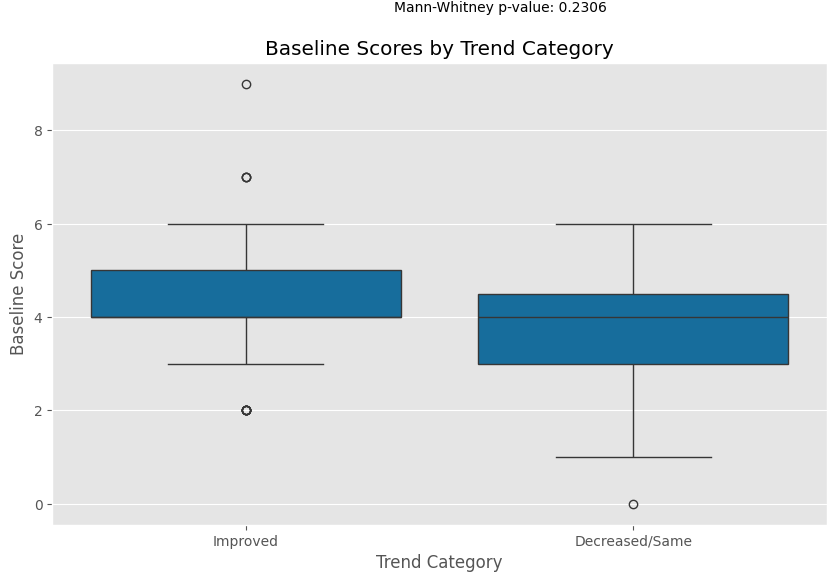

In [183]:
# Calculate odds ratio for a 10-point increase in baseline score
baseline_coef = result.params["cci_total"]
odds_ratio_10points = np.exp(baseline_coef * 10)
print(f"\nOdds Ratio for a 10-point increase in baseline score: {odds_ratio_10points:.3f}")

# Calculate confidence interval for the odds ratio
baseline_conf_int = result.conf_int().loc["cci_total"]
lower_ci_10points = np.exp(baseline_conf_int[0] * 10)
upper_ci_10points = np.exp(baseline_conf_int[1] * 10)
print(f"95% CI for a 10-point increase in baseline score: ({lower_ci_10points:.3f}, {upper_ci_10points:.3f})")

# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="cci_total", data=merged_df_removedNA_cci)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
             xycoords='figure fraction', ha='center')
plt.show()


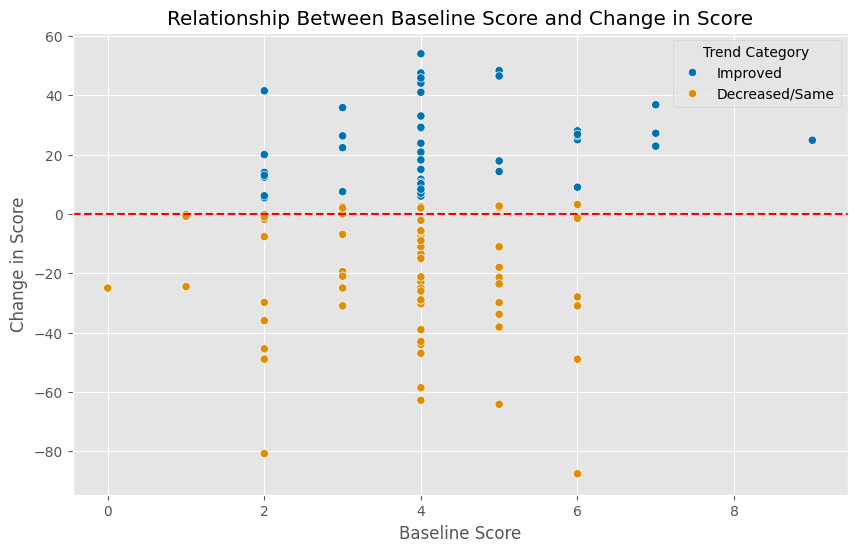

In [184]:
# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="cci_total", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_cci)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

# sensitivity analysis 11) charlson comorbidity index (cci_total)

Sensitivity Analysis Results:
    threshold  improvement_rate  mean_cci_improved  mean_cci_not_improved  \
0           0          0.500000           4.203704               3.666667   
1           1          0.490741           4.226415               3.654545   
2           2          0.490741           4.226415               3.654545   
3           3          0.425926           4.260870               3.693548   
4           4          0.416667           4.222222               3.730159   
5           5          0.416667           4.222222               3.730159   
6           6          0.407407           4.272727               3.703125   
7           7          0.388889           4.333333               3.681818   
8           8          0.361111           4.384615               3.681159   
9           9          0.351852           4.394737               3.685714   
10         10          0.333333           4.361111               3.722222   

    mann_whitney_p  logistic_p  odds_ratio  


<Figure size 1000x600 with 0 Axes>

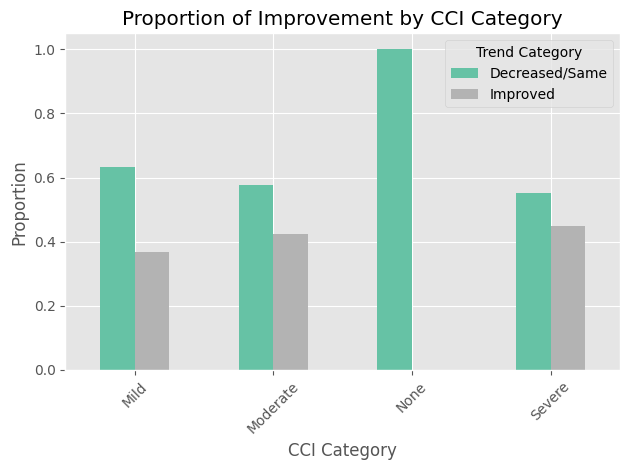

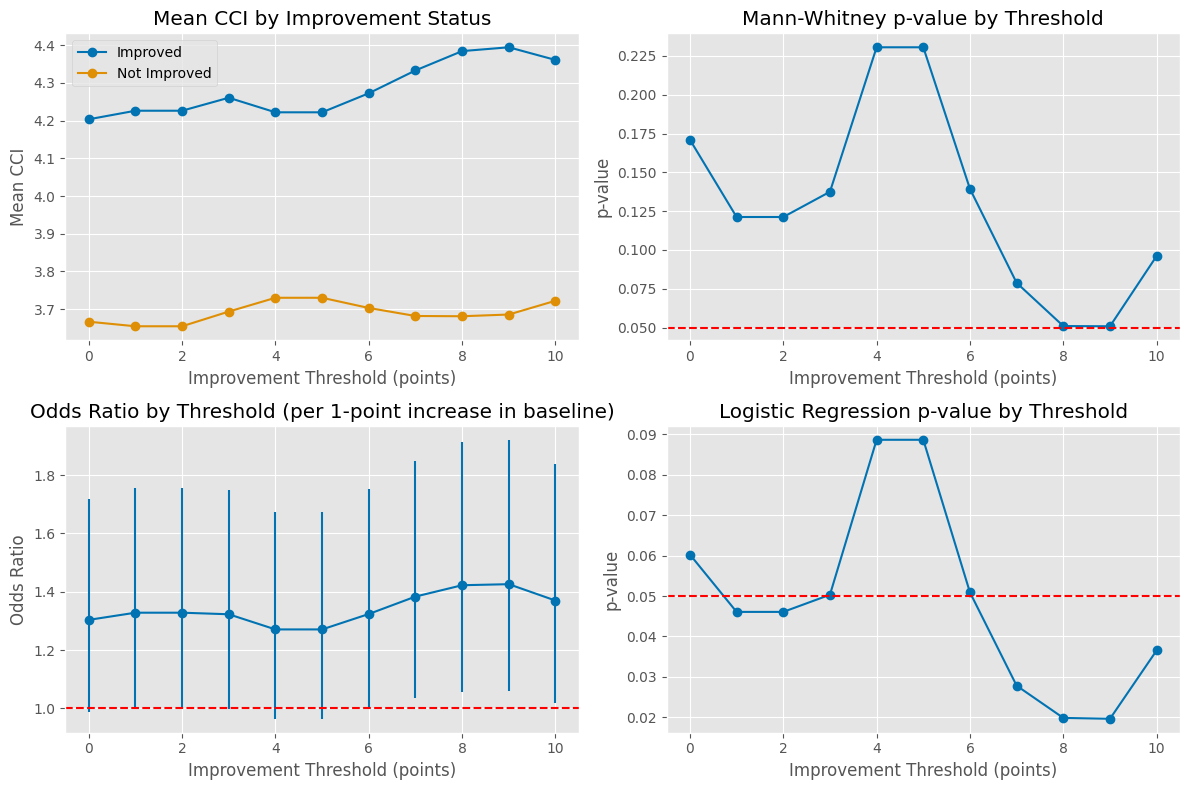


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              54                    54   50.000000   
1           1              53                    55   49.074074   
2           2              53                    55   49.074074   
3           3              46                    62   42.592593   
4           4              45                    63   41.666667   
5           5              45                    63   41.666667   
6           6              44                    64   40.740741   
7           7              42                    66   38.888889   
8           8              39                    69   36.111111   
9           9              38                    70   35.185185   
10         10              36                    72   33.333333   

    Decreased/Same %  
0          50.000000  
1          50.925926  
2          50.925926  
3          57.407407  
4          58.333333  
5          58.33

In [185]:
def analyze_improvement_threshold(data, threshold):
    """
    Analyze how the improvement threshold affects classification and baseline score relationship
    
    Parameters:
    data: DataFrame containing Baseline and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Mann-Whitney U test
    improved_baseline = df[df["Improved"]]["cci_total"]
    decreased_same_baseline = df[~df["Improved"]]["cci_total"]
    
    if len(improved_baseline) > 0 and len(decreased_same_baseline) > 0:
        stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
    else:
        stat, p_value = None, None
        
    # Mean cci_total in each group
    mean_cci_improved = improved_baseline.mean() if len(improved_baseline) > 0 else None
    mean_cci_not_improved = decreased_same_baseline.mean() if len(decreased_same_baseline) > 0 else None
    
    # Logistic regression
    X = sm.add_constant(df["cci_total"])
    y = df["Trend Category_binary"]
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        baseline_coef = result.params["cci_total"]
        baseline_p = result.pvalues["cci_total"]
        odds_ratio = np.exp(baseline_coef)
        
        # Confidence intervals
        baseline_conf_int = result.conf_int().loc["cci_total"]
        lower_ci = np.exp(baseline_conf_int[0])
        upper_ci = np.exp(baseline_conf_int[1])
    except:
        baseline_coef = None
        baseline_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mean_cci_improved": mean_cci_improved,
        "mean_cci_not_improved": mean_cci_not_improved,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": baseline_coef,
        "logistic_p": baseline_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean = merged_df_cci.dropna(subset=["cci_total", "Change"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_improvement_threshold(merged_df_clean, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_cci_improved", "mean_cci_not_improved", "mann_whitney_p", "logistic_p", "odds_ratio"]])

print("\n### Analysis with CCI categories ###")
# Define clinical CCI categories
def categorize_cci(cci):
    if cci == 0:
        return "None"
    elif cci <= 2:
        return "Mild"
    elif cci <= 4:
        return "Moderate"
    else:
        return "Severe"

# Add CCI category column
merged_df_clean["cci_category"] = merged_df_clean["cci_total"].apply(categorize_cci)

# Create contingency table
contingency_table_cci = pd.crosstab(merged_df_clean["Trend Category"],
                                    merged_df_clean["cci_category"])
print("Contingency Table:")
print(contingency_table_cci)

# Chi-square test
chi2_stat, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table_cci)
print(f"Chi-Square Test p-value: {p_value_chi2}")

# Visualize the relationship between CCI categories and Trend Category
plt.figure(figsize=(10, 6))
proportions = pd.crosstab(merged_df_clean["cci_category"],
                         merged_df_clean["Trend Category"],
                         normalize="index")
proportions.plot(kind="bar", stacked=False, colormap="Set2")
plt.title("Proportion of Improvement by CCI Category")
plt.xlabel("CCI Category")
plt.ylabel("Proportion")
plt.legend(title="Trend Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_cci_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_cci_not_improved"], 'o-', label='Not Improved')
plt.title("Mean CCI by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean CCI")
plt.legend()
plt.grid(True)

# Plot p-values from Mann-Whitney test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (per 1-point increase in baseline)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

In [186]:
# Just the confidence intervals
print("95% Confidence Intervals for Odds Ratios:")
for threshold in sensitivity_df['threshold']:
    row = sensitivity_df[sensitivity_df['threshold'] == threshold].iloc[0]
    lower = row['odds_ratio_lower_ci']
    upper = row['odds_ratio_upper_ci']
    or_val = row['odds_ratio']
    
    if pd.notna(or_val):
        print(f"Threshold {threshold}: OR = {or_val:.3f} (95% CI: {lower:.3f} - {upper:.3f})")
    else:
        print(f"Threshold {threshold}: OR = N/A")

95% Confidence Intervals for Odds Ratios:
Threshold 0: OR = 1.304 (95% CI: 0.989 - 1.719)
Threshold 1: OR = 1.328 (95% CI: 1.005 - 1.756)
Threshold 2: OR = 1.328 (95% CI: 1.005 - 1.756)
Threshold 3: OR = 1.323 (95% CI: 1.000 - 1.751)
Threshold 4: OR = 1.271 (95% CI: 0.964 - 1.675)
Threshold 5: OR = 1.271 (95% CI: 0.964 - 1.675)
Threshold 6: OR = 1.324 (95% CI: 0.999 - 1.754)
Threshold 7: OR = 1.384 (95% CI: 1.036 - 1.848)
Threshold 8: OR = 1.422 (95% CI: 1.057 - 1.913)
Threshold 9: OR = 1.426 (95% CI: 1.058 - 1.921)
Threshold 10: OR = 1.370 (95% CI: 1.020 - 1.840)


# Stepwise Multivariate logistic + Model Performance Evaluation

In [187]:
# Merge all the specific columns into merged_df_removedNA_baseline based on id
merged_df_total = merged_df_removedNA_baseline.merge(
    merged_df_removedNA_pwb[['id', 'pwb_subscale_score_baseline']], on='id', how='left'
    ).merge(
    merged_df_removedNA_swb[['id', 'swb_subscale_score_baseline']], on='id', how='left'
    ).merge(
    merged_df_removedNA_ewb[['id', 'ewb_subscale_score_baseline']], on='id', how='left'
    ).merge(
    merged_df_removedNA_fwb[['id', 'fwb_subscale_score_baseline']], on='id', how='left'
    ).merge(
    merged_df_removedNA_ecs[['id', 'ecs_subscale_score_baseline']], on='id', how='left'
    ).merge(
    merged_df_removedNA_bmi[['id', 'bmi']], on='id', how='left'
    ).merge(
    merged_df_removedNA_smoking[['id', 'smoking']], on='id', how='left'
    ).merge(
    merged_df_removedNA_alcohol[['id', 'alcohol']], on='id', how='left'
    ).merge(
    merged_df_removedNA_level[['id', 'level_tumor']], on='id', how='left'
    ).merge(
    merged_df_removedNA_tumorhistology[['id', 'path_histology']], on='id', how='left'
    ).merge(
    merged_df_removedNA_pathstage[['id', 'path_esoph_stage']], on='id', how='left'
    ).merge(
    merged_df_removedNA_procedure[['id', 'procedure123456']], on='id', how='left'
    ).merge(
    merged_df_removedNA_neotx[['id', 'neotx']], on='id', how='left'
    ).merge(
    merged_df_removedNA_age[['id', 'age_diagnosis']], on='id', how='left'
    ).merge(
    merged_df_removedNA_gender[['id', 'gender']], on='id', how='left'
    ).merge(
    merged_df_removedNA_cci[['id', 'cci_total']], on='id', how='left'
    )
merged_df_total

,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,Trend Category_binary,pwb_subscale_score_baseline,swb_subscale_score_baseline,...,smoking,alcohol,level_tumor,path_histology,path_esoph_stage,procedure123456,neotx,age_diagnosis,gender,cci_total
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1,24.5,22.0,...,1.0,1.0,4.0,1.0,9999.0,1.0,2.0,29.722718,1.0,2.0
1,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,0,7.0,23.0,...,1.0,1.0,4.0,4.0,9999.0,1.0,2.0,57.597350,1.0,4.0
2,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,1,21.0,17.5,...,3.0,0.0,4.0,4.0,3b,1.0,2.0,64.110830,1.0,4.0
3,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,1,21.0,20.0,...,0.0,0.0,6.0,4.0,3b,1.0,2.0,50.804602,1.0,4.0
4,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,1,25.0,13.0,...,9999.0,9999.0,4.0,8.0,9999.0,2.0,9999.0,66.229970,2.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,0,23.0,24.0,...,3.0,1.0,6.0,4.0,9999.0,1.0,2.0,69.876863,1.0,4.0
104,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,0,26.0,28.0,...,0.0,0.0,6.0,1.0,9999.0,1.0,2.0,79.245980,1.0,6.0
105,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,0,27.0,13.0,...,3.0,2.0,6.0,8.0,9999.0,1.0,2.0,60.529648,1.0,4.0
106,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,0,23.0,24.0,...,3.0,0.0,4.0,4.0,9999.0,1.0,2.0,55.623319,1.0,4.0


In [188]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Define the target variable
y = merged_df_total["Trend Category_binary"]

# Create dummy variables for categorical variables
smoking_dummies = pd.get_dummies(merged_df_total["smoking"], prefix="smoking", drop_first=True).astype(int)
alcohol_dummies = pd.get_dummies(merged_df_total["alcohol"], prefix="alcohol", drop_first=True).astype(int)
level_tumor_dummies = pd.get_dummies(merged_df_total["level_tumor"], prefix="level_tumor", drop_first=True).astype(int)
path_histology_dummies = pd.get_dummies(merged_df_total["path_histology"], prefix="path_histology", drop_first=True).astype(int)
path_esoph_stage_dummies = pd.get_dummies(merged_df_total["path_esoph_stage"], prefix="path_esoph_stage", drop_first=True).astype(int)
procedure123456_dummies = pd.get_dummies(merged_df_total["procedure123456"], prefix="procedure123456", drop_first=True).astype(int)
neotx_dummies = pd.get_dummies(merged_df_total["neotx"], prefix="neotx", drop_first=True).astype(int)
gender_dummies = pd.get_dummies(merged_df_total["gender"], prefix="gender", drop_first=True).astype(int)

# Define variable groups
modifiable_vars = pd.concat([
    merged_df_total["Baseline"],
    merged_df_total["pwb_subscale_score_baseline"],
    merged_df_total["swb_subscale_score_baseline"],
    merged_df_total["ewb_subscale_score_baseline"],
    merged_df_total["fwb_subscale_score_baseline"],
    merged_df_total["ecs_subscale_score_baseline"],
    merged_df_total["bmi"],
    smoking_dummies,
    alcohol_dummies
], axis=1)

tumor_chars = pd.concat([
    level_tumor_dummies,
    path_histology_dummies,
    path_esoph_stage_dummies
], axis=1)

treatment_chars = pd.concat([
    procedure123456_dummies,
    neotx_dummies
], axis=1)

demographics = pd.concat([
    merged_df_total["age_diagnosis"],
    gender_dummies,
    merged_df_total["cci_total"]
], axis=1)


In [189]:
# Function to calculate pseudo R-squared (McFadden's R-squared)
def mcfadden_r2(model_result):
    return 1 - (model_result.llf / model_result.llnull)

# Function to format results table
def format_results_table(model_result, model_name):
    # Get OR and 95% CI
    params = model_result.params
    conf_int = model_result.conf_int()
    pvalues = model_result.pvalues
    
    # Calculate OR and CI
    or_values = np.exp(params)
    or_ci_lower = np.exp(conf_int[0])
    or_ci_upper = np.exp(conf_int[1])
    
    # Create results dataframe
    results_df = pd.DataFrame({
        'Variable': params.index,
        'OR': or_values,
        'CI_Lower': or_ci_lower,
        'CI_Upper': or_ci_upper,
        'P_Value': pvalues
    })
    
    # Format the results
    results_df['OR_CI'] = results_df.apply(lambda x: f"{x['OR']:.3f} ({x['CI_Lower']:.3f}-{x['CI_Upper']:.3f})", axis=1)
    results_df['P_Value_formatted'] = results_df['P_Value'].apply(lambda x: f"{x:.3f}" if x >= 0.001 else "<0.001")
    
    print(f"\n=== {model_name} ===")
    print(results_df[['Variable', 'OR_CI', 'P_Value_formatted']].to_string(index=False))
    
    return results_df

# Function to calculate model performance metrics
def calculate_model_performance(model_result, X, y, model_name):
    # AIC
    aic = model_result.aic
    
    # Predicted probabilities
    y_pred_proba = model_result.predict(X)
    
    # AUC
    auc = roc_auc_score(y, y_pred_proba)
    
    # Pseudo R-squared
    pseudo_r2 = mcfadden_r2(model_result)
    
    return {
        'Model': model_name,
        'AIC': aic,
        'AUC': auc,
        'Pseudo_R2': pseudo_r2
    }


In [190]:
# Model 1: Modifiable variables only
print("Fitting Model 1: Modifiable variables only")
X1 = sm.add_constant(modifiable_vars)
model1 = sm.Logit(y, X1).fit()
results1 = format_results_table(model1, "Model 1: Modifiable Variables")
perf1 = calculate_model_performance(model1, X1, y, "Model 1")

Fitting Model 1: Modifiable variables only
Optimization terminated successfully.
         Current function value: 0.504367
         Iterations 7

=== Model 1: Modifiable Variables ===
                   Variable                       OR_CI P_Value_formatted
                      const 1209.333 (18.048-81034.410)            <0.001
                   Baseline        0.071 (0.000-19.867)             0.357
pwb_subscale_score_baseline     14.207 (0.051-3996.282)             0.356
swb_subscale_score_baseline     12.406 (0.044-3460.713)             0.381
ewb_subscale_score_baseline     13.671 (0.049-3844.804)             0.363
fwb_subscale_score_baseline     13.917 (0.049-3927.846)             0.360
ecs_subscale_score_baseline     12.912 (0.046-3609.041)             0.373
                        bmi         1.006 (0.926-1.093)             0.885
                smoking_1.0         0.195 (0.035-1.086)             0.062
                smoking_3.0         1.002 (0.274-3.667)             0.998
  

In [191]:
# Model 2: Model 1 + tumor characteristics
print("\nFitting Model 2: Model 1 + Tumor characteristics")
X2 = sm.add_constant(pd.concat([modifiable_vars, tumor_chars], axis=1))
model2 = sm.Logit(y, X2).fit()
results2 = format_results_table(model2, "Model 2: + Tumor Characteristics")
perf2 = calculate_model_performance(model2, X2, y, "Model 2")


Fitting Model 2: Model 1 + Tumor characteristics
         Current function value: 0.428057
         Iterations: 35


LinAlgError: Singular matrix

In [ ]:
# Model 3: Model 2 + treatment characteristics
print("\nFitting Model 3: Model 2 + Treatment characteristics")
X3 = sm.add_constant(pd.concat([modifiable_vars, tumor_chars, treatment_chars], axis=1))
model3 = sm.Logit(y, X3).fit()
results3 = format_results_table(model3, "Model 3: + Treatment Characteristics")
perf3 = calculate_model_performance(model3, X3, y, "Model 3")

In [ ]:
# Model 4: Model 3 + demographics
print("\nFitting Model 4: Model 3 + Demographics")
X4 = sm.add_constant(pd.concat([modifiable_vars, tumor_chars, treatment_chars, demographics], axis=1))
model4 = sm.Logit(y, X4).fit()
results4 = format_results_table(model4, "Model 4: + Demographics")
perf4 = calculate_model_performance(model4, X4, y, "Model 4")

In [ ]:

# Create performance comparison table
performance_df = pd.DataFrame([perf1, perf2, perf3, perf4])
print("\n=== MODEL PERFORMANCE COMPARISON (Table 4) ===")
print(performance_df.round(3).to_string(index=False))

# Print model summaries for detailed review
print("\n=== DETAILED MODEL SUMMARIES ===")
print("\nModel 1 Summary:")
print(model1.summary())

print("\nModel 2 Summary:")
print(model2.summary())

print("\nModel 3 Summary:")
print(model3.summary())

print("\nModel 4 Summary:")
print(model4.summary())

# Store results for further analysis if needed
models = {
    'Model 1': model1,
    'Model 2': model2,
    'Model 3': model3,
    'Model 4': model4
}

results_tables = {
    'Model 1': results1,
    'Model 2': results2,
    'Model 3': results3,
    'Model 4': results4
}

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Function to calculate VIF and check for multicollinearity
def check_multicollinearity(X, threshold=10):
    """
    Calculate VIF for each variable and identify multicollinear variables
    """
    print("\n=== MULTICOLLINEARITY CHECK ===")
    
    # Remove constant column for VIF calculation
    X_no_const = X.drop('const', axis=1) if 'const' in X.columns else X
    
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X_no_const.columns
    vif_data["VIF"] = [variance_inflation_factor(X_no_const.values, i) 
                       for i in range(len(X_no_const.columns))]
    
    # Sort by VIF value
    vif_data = vif_data.sort_values('VIF', ascending=False)
    
    print(f"VIF values (threshold = {threshold}):")
    print(vif_data.to_string(index=False))
    
    # Identify problematic variables
    high_vif = vif_data[vif_data['VIF'] > threshold]
    if len(high_vif) > 0:
        print(f"\nVariables with VIF > {threshold}:")
        print(high_vif['Variable'].tolist())
        return high_vif['Variable'].tolist()
    else:
        print(f"\nNo variables with VIF > {threshold}")
        return []

# Function to remove multicollinear variables iteratively
def remove_multicollinear_vars(X, threshold=10):
    """
    Remove variables with high VIF iteratively
    """
    X_clean = X.copy()
    
    while True:
        # Check for constant column
        if 'const' in X_clean.columns:
            X_for_vif = X_clean.drop('const', axis=1)
        else:
            X_for_vif = X_clean
            
        if len(X_for_vif.columns) == 0:
            break
            
        # Calculate VIF
        try:
            vif_values = [variance_inflation_factor(X_for_vif.values, i) 
                         for i in range(len(X_for_vif.columns))]
            max_vif = max(vif_values)
            max_vif_idx = vif_values.index(max_vif)
            max_vif_var = X_for_vif.columns[max_vif_idx]
            
            if max_vif > threshold:
                print(f"Removing {max_vif_var} (VIF = {max_vif:.2f})")
                X_clean = X_clean.drop(max_vif_var, axis=1)
            else:
                break
        except:
            print("Error in VIF calculation, stopping removal process")
            break
    
    return X_clean

# Function to check for perfect correlation and remove redundant variables
def remove_perfect_correlation(df, threshold=0.99):
    """
    Remove variables that are perfectly or near-perfectly correlated
    """
    corr_matrix = df.corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find variables with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    if to_drop:
        print(f"Removing highly correlated variables (correlation > {threshold}): {to_drop}")
        df_clean = df.drop(to_drop, axis=1)
        return df_clean
    else:
        return df


# Check for multicollinearity issues before fitting models
print("=== CHECKING FOR MULTICOLLINEARITY ISSUES ===")

# Check each variable group separately first
print("\n1. Checking modifiable variables:")
modifiable_vars_clean = remove_perfect_correlation(modifiable_vars)
X1_temp = sm.add_constant(modifiable_vars_clean)
high_vif_vars = check_multicollinearity(X1_temp)

print("\n2. Checking tumor characteristics:")
tumor_chars_clean = remove_perfect_correlation(tumor_chars)
if len(tumor_chars_clean.columns) > 0:
    X_tumor_temp = sm.add_constant(tumor_chars_clean)
    high_vif_tumor = check_multicollinearity(X_tumor_temp)

print("\n3. Checking treatment characteristics:")
treatment_chars_clean = remove_perfect_correlation(treatment_chars)
if len(treatment_chars_clean.columns) > 0:
    X_treatment_temp = sm.add_constant(treatment_chars_clean)
    high_vif_treatment = check_multicollinearity(X_treatment_temp)

print("\n4. Checking demographics:")
demographics_clean = remove_perfect_correlation(demographics)
if len(demographics_clean.columns) > 0:
    X_demo_temp = sm.add_constant(demographics_clean)
    high_vif_demo = check_multicollinearity(X_demo_temp)

# Model 1: Modifiable variables only
print("\n=== FITTING MODELS ===")
print("Fitting Model 1: Modifiable variables only")
X1 = sm.add_constant(modifiable_vars_clean)
X1 = remove_multicollinear_vars(X1, threshold=10)
try:
    model1 = sm.Logit(y, X1).fit()
    results1 = format_results_table(model1, "Model 1: Modifiable Variables")
    perf1 = calculate_model_performance(model1, X1, y, "Model 1")
except Exception as e:
    print(f"Error fitting Model 1: {e}")
    model1, results1, perf1 = None, None, None

# Model 2: Model 1 + tumor characteristics
print("\nFitting Model 2: Model 1 + Tumor characteristics")
X2 = sm.add_constant(pd.concat([modifiable_vars_clean, tumor_chars_clean], axis=1))
X2 = remove_multicollinear_vars(X2, threshold=10)
try:
    model2 = sm.Logit(y, X2).fit()
    results2 = format_results_table(model2, "Model 2: + Tumor Characteristics")
    perf2 = calculate_model_performance(model2, X2, y, "Model 2")
except Exception as e:
    print(f"Error fitting Model 2: {e}")
    model2, results2, perf2 = None, None, None

# Model 3: Model 2 + treatment characteristics
print("\nFitting Model 3: Model 2 + Treatment characteristics")
X3 = sm.add_constant(pd.concat([modifiable_vars_clean, tumor_chars_clean, treatment_chars_clean], axis=1))
X3 = remove_multicollinear_vars(X3, threshold=10)
try:
    model3 = sm.Logit(y, X3).fit()
    results3 = format_results_table(model3, "Model 3: + Treatment Characteristics")
    perf3 = calculate_model_performance(model3, X3, y, "Model 3")
except Exception as e:
    print(f"Error fitting Model 3: {e}")
    model3, results3, perf3 = None, None, None

# Model 4: Model 3 + demographics
print("\nFitting Model 4: Model 3 + Demographics")
X4 = sm.add_constant(pd.concat([modifiable_vars_clean, tumor_chars_clean, treatment_chars_clean, demographics_clean], axis=1))
X4 = remove_multicollinear_vars(X4, threshold=10)
print(f"Final Model 4 variables: {list(X4.columns)}")
try:
    model4 = sm.Logit(y, X4).fit(maxiter=100)  # Increase max iterations
    results4 = format_results_table(model4, "Model 4: + Demographics")
    perf4 = calculate_model_performance(model4, X4, y, "Model 4")
except Exception as e:
    print(f"Error fitting Model 4: {e}")
    model4, results4, perf4 = None, None, None

# Create performance comparison table
valid_models = []
if perf1: valid_models.append(perf1)
if perf2: valid_models.append(perf2)
if perf3: valid_models.append(perf3)
if perf4: valid_models.append(perf4)

if valid_models:
    performance_df = pd.DataFrame(valid_models)
    print("\n=== MODEL PERFORMANCE COMPARISON (Table 4) ===")
    print(performance_df.round(3).to_string(index=False))

# Print model summaries for detailed review
print("\n=== DETAILED MODEL SUMMARIES ===")
if model1:
    print("\nModel 1 Summary:")
    print(model1.summary())

if model2:
    print("\nModel 2 Summary:")
    print(model2.summary())

if model3:
    print("\nModel 3 Summary:")
    print(model3.summary())

if model4:
    print("\nModel 4 Summary:")
    print(model4.summary())

# Store results for further analysis if needed
models = {}
results_tables = {}

if model1:
    models['Model 1'] = model1
    results_tables['Model 1'] = results1
if model2:
    models['Model 2'] = model2
    results_tables['Model 2'] = results2
if model3:
    models['Model 3'] = model3
    results_tables['Model 3'] = results3
if model4:
    models['Model 4'] = model4
    results_tables['Model 4'] = results4

# Stepwise Multivariate logistic + Model Performance Evaluation (collapsed variables)

### abdomen approaches

In [201]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [202]:
# Merge score_comparison with abdomen_approach data
merged_df_abdomen = score_comparison.merge(filtered_df[["id", "abdomen_approach"]], on="id", how="left")

print(merged_df_abdomen['abdomen_approach'].value_counts())

# Find patient IDs where all abdomen_approach values are missing
patients_all_missing = merged_df_abdomen.groupby('id')['abdomen_approach'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute abdomen_approach for those patients with 9999.0 (unknown/missing indicator)
mask = merged_df_abdomen['id'].isin(patients_to_impute)
merged_df_abdomen.loc[mask, 'abdomen_approach'] = 9999.0

print(f"Imputed {len(patients_to_impute)} missing data patients with abdomen_approach = 9999.0 (unknown)")

# Create a clean dataframe with no missing values in abdomen_approach
merged_df_removedNA_abdomen = merged_df_abdomen.dropna(subset=["abdomen_approach"])
merged_df_expanded_abdomen = merged_df_removedNA_abdomen.drop_duplicates()
merged_df_removedNA_abdomen = merged_df_expanded_abdomen.copy()

print(merged_df_abdomen['abdomen_approach'].value_counts())
merged_df_removedNA_abdomen

abdomen_approach
2.0    39
1.0    28
3.0     2
Name: count, dtype: int64
Imputed 41 missing data patients with abdomen_approach = 9999.0 (unknown)
abdomen_approach
9999.0    443
2.0        39
1.0        28
3.0         2
Name: count, dtype: int64


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,abdomen_approach
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,9999.0
10,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,9999.0
19,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,1.0
36,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,1.0
38,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,9999.0
...,...,...,...,...,...,...,...,...
1162,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,2.0
1163,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,3.0
1181,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,3.0
1183,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,2.0


### chest approaches

In [203]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [204]:
# Merge score_comparison with chest_approach data
merged_df_chest = score_comparison.merge(filtered_df[["id", "chest_approach"]], on="id", how="left")

print(merged_df_chest['chest_approach'].value_counts())

# Find patient IDs where all chest_approach values are missing
patients_all_missing = merged_df_chest.groupby('id')['chest_approach'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute chest_approach for those patients with 9999.0 (unknown/missing indicator)
mask = merged_df_chest['id'].isin(patients_to_impute)
merged_df_chest.loc[mask, 'chest_approach'] = 9999.0

print(f"Imputed {len(patients_to_impute)} missing data patients with chest_approach = 9999.0 (unknown)")

# Create a clean dataframe with no missing values in chest_approach
merged_df_removedNA_chest = merged_df_chest.dropna(subset=["chest_approach"])
merged_df_expanded_chest = merged_df_removedNA_chest.drop_duplicates()
merged_df_removedNA_chest = merged_df_expanded_chest.copy()

print(merged_df_chest['chest_approach'].value_counts())
merged_df_removedNA_chest

chest_approach
1.0    59
2.0    32
4.0     8
3.0     2
Name: count, dtype: int64
Imputed 12 missing data patients with chest_approach = 9999.0 (unknown)
chest_approach
9999.0    113
1.0        59
2.0        32
4.0         8
3.0         2
Name: count, dtype: int64


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,chest_approach
1,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
10,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,9999.0
19,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,1.0
36,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,1.0
40,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,2.0
...,...,...,...,...,...,...,...,...
1162,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,2.0
1163,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,1.0
1181,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,1.0
1183,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,2.0


In [206]:
print(merged_df_removedNA_chest['id'][merged_df_removedNA_chest['id'].duplicated()].unique())
print(merged_df_removedNA_chest[merged_df_removedNA_chest['id'].isin([1049])])

[1049]
       id       baseline_type  Baseline  Postop1yr  Change  \
852  1049  preoperative_arm_1     117.4      135.6    18.2   
855  1049  preoperative_arm_1     117.4      135.6    18.2   

    fact_e_total_has_improved Trend Category  chest_approach  
852                      True       Improved             1.0  
855                      True       Improved             2.0  


In [207]:
# Find all rows with patient ID 1049
patient_rows = merged_df_removedNA_chest[merged_df_removedNA_chest['id'] == 1049]

# Get the index of the last occurrence
last_index = patient_rows.index[-1]

# Drop that row
merged_df_removedNA_chest = merged_df_removedNA_chest.drop(index=last_index)

print(merged_df_removedNA_chest[merged_df_removedNA_chest['id'] == 1049])

print(merged_df_removedNA_chest['chest_approach'].value_counts())

merged_df_removedNA_chest


       id       baseline_type  Baseline  Postop1yr  Change  \
852  1049  preoperative_arm_1     117.4      135.6    18.2   

    fact_e_total_has_improved Trend Category  chest_approach  
852                      True       Improved             1.0  
chest_approach
1.0       55
2.0       31
9999.0    12
4.0        8
3.0        2
Name: count, dtype: int64


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,chest_approach
1,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
10,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,9999.0
19,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,1.0
36,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,1.0
40,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,2.0
...,...,...,...,...,...,...,...,...
1162,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,2.0
1163,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,1.0
1181,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,1.0
1183,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,2.0


### analysis

In [227]:
# Merge all the specific columns into merged_df_removedNA_baseline based on id
merged_df_total = merged_df_removedNA_baseline.merge(
    merged_df_removedNA_pwb[['id', 'pwb_subscale_score_baseline']], on='id', how='left'
    ).merge(
    merged_df_removedNA_swb[['id', 'swb_subscale_score_baseline']], on='id', how='left'
    ).merge(
    merged_df_removedNA_ewb[['id', 'ewb_subscale_score_baseline']], on='id', how='left'
    ).merge(
    merged_df_removedNA_fwb[['id', 'fwb_subscale_score_baseline']], on='id', how='left'
    ).merge(
    merged_df_removedNA_ecs[['id', 'ecs_subscale_score_baseline']], on='id', how='left'
    ).merge(
    merged_df_removedNA_bmi[['id', 'bmi']], on='id', how='left'
    ).merge(
    merged_df_removedNA_smoking[['id', 'smoking']], on='id', how='left'
    ).merge(
    merged_df_removedNA_alcohol[['id', 'alcohol']], on='id', how='left'
    ).merge(
    merged_df_removedNA_level[['id', 'level_tumor']], on='id', how='left'
    ).merge(
    merged_df_removedNA_tumorhistology[['id', 'path_histology']], on='id', how='left'
    ).merge(
    merged_df_removedNA_pathstage[['id', 'path_esoph_stage']], on='id', how='left'
    ).merge(
    merged_df_removedNA_abdomen[['id', 'abdomen_approach']], on='id', how='left'  # New merge for abdomen approach
    ).merge(
    merged_df_removedNA_chest[['id', 'chest_approach']], on='id', how='left'      # New merge for chest approach
    ).merge(
    merged_df_removedNA_neotx[['id', 'neotx']], on='id', how='left'
    ).merge(
    merged_df_removedNA_age[['id', 'age_diagnosis']], on='id', how='left'
    ).merge(
    merged_df_removedNA_gender[['id', 'gender']], on='id', how='left'
    ).merge(
    merged_df_removedNA_cci[['id', 'cci_total']], on='id', how='left'
    )
merged_df_total

,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,Trend Category_binary,pwb_subscale_score_baseline,swb_subscale_score_baseline,...,alcohol,level_tumor,path_histology,path_esoph_stage,abdomen_approach,chest_approach,neotx,age_diagnosis,gender,cci_total
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1,24.5,22.0,...,1.0,4.0,1.0,9999.0,9999.0,1.0,2.0,29.722718,1.0,2.0
1,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,0,7.0,23.0,...,1.0,4.0,4.0,9999.0,9999.0,9999.0,2.0,57.597350,1.0,4.0
2,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,1,21.0,17.5,...,0.0,4.0,4.0,3b,1.0,1.0,2.0,64.110830,1.0,4.0
3,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,1,21.0,20.0,...,0.0,6.0,4.0,3b,1.0,1.0,2.0,50.804602,1.0,4.0
4,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,1,25.0,13.0,...,9999.0,4.0,8.0,9999.0,9999.0,2.0,9999.0,66.229970,2.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,0,23.0,24.0,...,1.0,6.0,4.0,9999.0,2.0,2.0,2.0,69.876863,1.0,4.0
104,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,0,26.0,28.0,...,0.0,6.0,1.0,9999.0,3.0,1.0,2.0,79.245980,1.0,6.0
105,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,0,27.0,13.0,...,2.0,6.0,8.0,9999.0,3.0,1.0,2.0,60.529648,1.0,4.0
106,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,0,23.0,24.0,...,0.0,4.0,4.0,9999.0,2.0,2.0,2.0,55.623319,1.0,4.0


In [228]:
# ===============================
# VARIABLE COLLAPSING SECTION
# ===============================

# 1. Collapse smoking variable
print("1. Collapsing smoking variable...")
merged_df_total['smoking_collapsed'] = merged_df_total['smoking'].copy()
merged_df_total.loc[merged_df_total['smoking'].isin([1, 2, 3]), 'smoking_collapsed'] = 1  # Ever Smoked
merged_df_total.loc[merged_df_total['smoking'] == 0, 'smoking_collapsed'] = 0  # Never Smoked
merged_df_total.loc[merged_df_total['smoking'] == 9999, 'smoking_collapsed'] = 9999  # Keep as 9999
print(f"Smoking collapsed - Value counts:\n{merged_df_total['smoking_collapsed'].value_counts()}")

# 2. Collapse alcohol variable
print("\n2. Collapsing alcohol variable...")
merged_df_total['alcohol_collapsed'] = merged_df_total['alcohol'].copy()
merged_df_total.loc[merged_df_total['alcohol'].isin([1, 2]), 'alcohol_collapsed'] = 1  # Ever Drank
merged_df_total.loc[merged_df_total['alcohol'] == 0, 'alcohol_collapsed'] = 0  # Non-Drinker
merged_df_total.loc[merged_df_total['alcohol'] == 9999, 'alcohol_collapsed'] = 9999  # Keep as 9999
print(f"Alcohol collapsed - Value counts:\n{merged_df_total['alcohol_collapsed'].value_counts()}")

# 3. Create surgery approach classification (replacing procedure123456)
print("\n3. Creating surgery approach classification...")
merged_df_total['surgery_approach'] = 9999  # Default to missing

# Define conditions for minimally invasive
minimally_invasive_abdomen = merged_df_total['abdomen_approach'] == 2  # LAP
minimally_invasive_chest = merged_df_total['chest_approach'].isin([2, 4])  # VATS or Prone

# Define conditions for open (takes priority)
open_abdomen = merged_df_total['abdomen_approach'].isin([1, 3])  # Open or LAP to Open
open_chest = merged_df_total['chest_approach'].isin([1, 3])  # Open or VATS to Open

# Define conditions for missing data
missing_abdomen = merged_df_total['abdomen_approach'].isin([4, 9999]) | merged_df_total['abdomen_approach'].isna()
missing_chest = merged_df_total['chest_approach'].isin([5, 9999]) | merged_df_total['chest_approach'].isna()

# Classify surgery approach
# Open takes priority
merged_df_total.loc[open_abdomen | open_chest, 'surgery_approach'] = 0  # Open

# Minimally invasive (only if not already classified as open)
merged_df_total.loc[(merged_df_total['surgery_approach'] != 0) & 
                   (minimally_invasive_abdomen | minimally_invasive_chest), 'surgery_approach'] = 1  # Minimally Invasive

# Missing only if both approaches are missing/NA and not already classified
merged_df_total.loc[(merged_df_total['surgery_approach'] == 9999) & 
                   missing_abdomen & missing_chest, 'surgery_approach'] = 9999  # Missing

print(f"Surgery approach - Value counts:\n{merged_df_total['surgery_approach'].value_counts()}")

# 4. Collapse path_esoph_stage variable
print("\n4. Collapsing path_esoph_stage variable...")
merged_df_total['path_esoph_stage_collapsed'] = merged_df_total['path_esoph_stage'].copy()
merged_df_total.loc[merged_df_total['path_esoph_stage'] == 0, 'path_esoph_stage_collapsed'] = 0  # Stage 0
merged_df_total.loc[merged_df_total['path_esoph_stage'].isin(['1a', '1b', '1c']), 'path_esoph_stage_collapsed'] = 1  # Stage I
merged_df_total.loc[merged_df_total['path_esoph_stage'].isin(['2a', '2b']), 'path_esoph_stage_collapsed'] = 2  # Stage II
merged_df_total.loc[merged_df_total['path_esoph_stage'].isin(['3a', '3b']), 'path_esoph_stage_collapsed'] = 3  # Stage III
merged_df_total.loc[merged_df_total['path_esoph_stage'].isin(['4a', '4b']), 'path_esoph_stage_collapsed'] = 4  # Stage IV
merged_df_total.loc[merged_df_total['path_esoph_stage'] == 5, 'path_esoph_stage_collapsed'] = 5  # pCR
merged_df_total.loc[merged_df_total['path_esoph_stage'] == 9999, 'path_esoph_stage_collapsed'] = 9999  # Keep as 9999
print(f"Path esoph stage collapsed - Value counts:\n{merged_df_total['path_esoph_stage_collapsed'].value_counts()}")

# 5. Collapse level_tumor variable
print("\n5. Collapsing level_tumor variable...")
merged_df_total['level_tumor_collapsed'] = merged_df_total['level_tumor'].copy()
merged_df_total.loc[merged_df_total['level_tumor'].isin([5, 6, 7]), 'level_tumor_collapsed'] = 1  # Cardia/GEJ
merged_df_total.loc[merged_df_total['level_tumor'] == 4, 'level_tumor_collapsed'] = 2  # Lower Esophagus
merged_df_total.loc[merged_df_total['level_tumor'].isin([1, 2, 3]), 'level_tumor_collapsed'] = 3  # Middle or Upper Esophagus
merged_df_total.loc[merged_df_total['level_tumor'] == 9999, 'level_tumor_collapsed'] = 9999  # Keep as 9999
print(f"Level tumor collapsed - Value counts:\n{merged_df_total['level_tumor_collapsed'].value_counts()}")

# 6. Collapse path_histology variable
print("\n6. Collapsing path_histology variable...")
merged_df_total['path_histology_collapsed'] = merged_df_total['path_histology'].copy()
merged_df_total.loc[merged_df_total['path_histology'] == 4, 'path_histology_collapsed'] = 1  # Adenocarcinoma
merged_df_total.loc[merged_df_total['path_histology'] == 5, 'path_histology_collapsed'] = 2  # Squamous Cell Carcinoma
# All other options except 9999 become "Other"
other_mask = (~merged_df_total['path_histology'].isin([4, 5, 9999])) & (~merged_df_total['path_histology'].isna())
merged_df_total.loc[other_mask, 'path_histology_collapsed'] = 3  # Other
merged_df_total.loc[merged_df_total['path_histology'] == 9999, 'path_histology_collapsed'] = 9999  # Keep as 9999
print(f"Path histology collapsed - Value counts:\n{merged_df_total['path_histology_collapsed'].value_counts()}")

# 7. Collapse neotx variable
print("\n7. Collapsing neotx variable...")
merged_df_total['neotx_collapsed'] = merged_df_total['neotx'].copy()
merged_df_total.loc[merged_df_total['neotx'] == 1, 'neotx_collapsed'] = 0  # None
merged_df_total.loc[merged_df_total['neotx'] == 2, 'neotx_collapsed'] = 1  # Chemotherapy
merged_df_total.loc[merged_df_total['neotx'] == 4, 'neotx_collapsed'] = 2  # Chemoradiotherapy
merged_df_total.loc[merged_df_total['neotx'].isin([3, 5, 6, 7]), 'neotx_collapsed'] = 3  # Other
merged_df_total.loc[merged_df_total['neotx'] == 9999, 'neotx_collapsed'] = 9999  # Keep as 9999
print(f"Neotx collapsed - Value counts:\n{merged_df_total['neotx_collapsed'].value_counts()}")

1. Collapsing smoking variable...
Smoking collapsed - Value counts:
smoking_collapsed
1.0       47
9999.0    32
0.0       29
Name: count, dtype: int64

2. Collapsing alcohol variable...
Alcohol collapsed - Value counts:
alcohol_collapsed
1.0       46
9999.0    35
0.0       27
Name: count, dtype: int64

3. Creating surgery approach classification...
Surgery approach - Value counts:
surgery_approach
0       61
1       40
9999     7
Name: count, dtype: int64

4. Collapsing path_esoph_stage variable...
Path esoph stage collapsed - Value counts:
path_esoph_stage_collapsed
9999.0    58
3         18
2         16
0          6
4          5
1          3
5          2
Name: count, dtype: int64

5. Collapsing level_tumor variable...
Level tumor collapsed - Value counts:
level_tumor_collapsed
1.0       50
2.0       47
3.0       10
9999.0     1
Name: count, dtype: int64

6. Collapsing path_histology variable...
Path histology collapsed - Value counts:
path_histology_collapsed
1.0       63
3.0       3

In [229]:


# ===============================
# CONTINUE WITH ANALYSIS USING COLLAPSED VARIABLES
# ===============================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Define the target variable
y = merged_df_total["Trend Category_binary"]

# Create dummy variables for categorical variables using COLLAPSED variables
smoking_dummies = pd.get_dummies(merged_df_total["smoking_collapsed"], prefix="smoking", drop_first=True).astype(int)
alcohol_dummies = pd.get_dummies(merged_df_total["alcohol_collapsed"], prefix="alcohol", drop_first=True).astype(int)
level_tumor_dummies = pd.get_dummies(merged_df_total["level_tumor_collapsed"], prefix="level_tumor", drop_first=True).astype(int)
path_histology_dummies = pd.get_dummies(merged_df_total["path_histology_collapsed"], prefix="path_histology", drop_first=True).astype(int)
path_esoph_stage_dummies = pd.get_dummies(merged_df_total["path_esoph_stage_collapsed"], prefix="path_esoph_stage", drop_first=True).astype(int)
surgery_approach_dummies = pd.get_dummies(merged_df_total["surgery_approach"], prefix="surgery_approach", drop_first=True).astype(int)  # NEW: replacing procedure123456
neotx_dummies = pd.get_dummies(merged_df_total["neotx_collapsed"], prefix="neotx", drop_first=True).astype(int)
gender_dummies = pd.get_dummies(merged_df_total["gender"], prefix="gender", drop_first=True).astype(int)

# Define variable groups using collapsed variables
modifiable_vars = pd.concat([
    merged_df_total["Baseline"],
    merged_df_total["pwb_subscale_score_baseline"],
    merged_df_total["swb_subscale_score_baseline"],
    merged_df_total["ewb_subscale_score_baseline"],
    merged_df_total["fwb_subscale_score_baseline"],
    merged_df_total["ecs_subscale_score_baseline"],
    merged_df_total["bmi"],
    smoking_dummies,
    alcohol_dummies
], axis=1)

tumor_chars = pd.concat([
    level_tumor_dummies,
    path_histology_dummies,
    path_esoph_stage_dummies
], axis=1)

treatment_chars = pd.concat([
    surgery_approach_dummies,  # NEW: using surgery approach instead of procedure123456
    neotx_dummies
], axis=1)

demographics = pd.concat([
    merged_df_total["age_diagnosis"],
    gender_dummies,
    merged_df_total["cci_total"]
], axis=1)

In [230]:

# Function to calculate pseudo R-squared (McFadden's R-squared)
def mcfadden_r2(model_result):
    return 1 - (model_result.llf / model_result.llnull)

# Function to format results table
def format_results_table(model_result, model_name):
    # Get OR and 95% CI
    params = model_result.params
    conf_int = model_result.conf_int()
    pvalues = model_result.pvalues
    
    # Calculate OR and CI
    or_values = np.exp(params)
    or_ci_lower = np.exp(conf_int[0])
    or_ci_upper = np.exp(conf_int[1])
    
    # Create results dataframe
    results_df = pd.DataFrame({
        'Variable': params.index,
        'OR': or_values,
        'CI_Lower': or_ci_lower,
        'CI_Upper': or_ci_upper,
        'P_Value': pvalues
    })
    
    # Format the results
    results_df['OR_CI'] = results_df.apply(lambda x: f"{x['OR']:.3f} ({x['CI_Lower']:.3f}-{x['CI_Upper']:.3f})", axis=1)
    results_df['P_Value_formatted'] = results_df['P_Value'].apply(lambda x: f"{x:.3f}" if x >= 0.001 else "<0.001")
    
    print(f"\n=== {model_name} ===")
    print(results_df[['Variable', 'OR_CI', 'P_Value_formatted']].to_string(index=False))
    
    return results_df

# Function to calculate model performance metrics
def calculate_model_performance(model_result, X, y, model_name):
    # AIC
    aic = model_result.aic
    
    # Predicted probabilities
    y_pred_proba = model_result.predict(X)
    
    # AUC
    auc = roc_auc_score(y, y_pred_proba)
    
    # Pseudo R-squared
    pseudo_r2 = mcfadden_r2(model_result)
    
    return {
        'Model': model_name,
        'AIC': aic,
        'AUC': auc,
        'Pseudo_R2': pseudo_r2
    }

In [231]:
# Model 1: Modifiable variables only
print("Fitting Model 1: Modifiable variables only")
X1 = sm.add_constant(modifiable_vars)
model1 = sm.Logit(y, X1).fit()
results1 = format_results_table(model1, "Model 1: Modifiable Variables")
perf1 = calculate_model_performance(model1, X1, y, "Model 1")


Fitting Model 1: Modifiable variables only
Optimization terminated successfully.
         Current function value: 0.521661
         Iterations 7

=== Model 1: Modifiable Variables ===
                   Variable                      OR_CI P_Value_formatted
                      const 618.519 (11.451-33407.546)             0.002
                   Baseline       0.075 (0.000-17.704)             0.353
pwb_subscale_score_baseline    13.263 (0.056-3132.253)             0.354
swb_subscale_score_baseline    11.908 (0.051-2792.755)             0.374
ewb_subscale_score_baseline    13.195 (0.056-3115.745)             0.355
fwb_subscale_score_baseline    13.063 (0.055-3093.567)             0.357
ecs_subscale_score_baseline    12.163 (0.052-2853.855)             0.370
                        bmi        1.014 (0.937-1.098)             0.723
                smoking_1.0        0.585 (0.181-1.892)             0.371
             smoking_9999.0       2.221 (0.096-51.411)             0.619
             

In [232]:
# Model 2: Model 1 + tumor characteristics
print("\nFitting Model 2: Model 1 + Tumor characteristics")
X2 = sm.add_constant(pd.concat([modifiable_vars, tumor_chars], axis=1))
model2 = sm.Logit(y, X2).fit()
results2 = format_results_table(model2, "Model 2: + Tumor Characteristics")
perf2 = calculate_model_performance(model2, X2, y, "Model 2")



Fitting Model 2: Model 1 + Tumor characteristics
         Current function value: 0.488380
         Iterations: 35


LinAlgError: Singular matrix

In [233]:
# Model 3: Model 2 + treatment characteristics
print("\nFitting Model 3: Model 2 + Treatment characteristics")
X3 = sm.add_constant(pd.concat([modifiable_vars, tumor_chars, treatment_chars], axis=1))
model3 = sm.Logit(y, X3).fit()
results3 = format_results_table(model3, "Model 3: + Treatment Characteristics")
perf3 = calculate_model_performance(model3, X3, y, "Model 3")



Fitting Model 3: Model 2 + Treatment characteristics
         Current function value: 0.443536
         Iterations: 35

=== Model 3: + Treatment Characteristics ===
                   Variable                                                                                                                                                                                                                                              OR_CI P_Value_formatted
                      const                                                                                                                                                                                                                                 4523.137 (nan-nan)            <0.001
                   Baseline                                                                                                                                                                                                                               0.087 

In [234]:
# Model 4: Model 3 + demographics
print("\nFitting Model 4: Model 3 + Demographics")
X4 = sm.add_constant(pd.concat([modifiable_vars, tumor_chars, treatment_chars, demographics], axis=1))
model4 = sm.Logit(y, X4).fit()
results4 = format_results_table(model4, "Model 4: + Demographics")
perf4 = calculate_model_performance(model4, X4, y, "Model 4")



Fitting Model 4: Model 3 + Demographics
         Current function value: 0.396331
         Iterations: 35

=== Model 4: + Demographics ===
                   Variable                       OR_CI P_Value_formatted
                      const 571.339 (0.162-2020232.666)             0.128
                   Baseline         0.015 (0.000-5.883)             0.168
pwb_subscale_score_baseline    63.439 (0.161-24953.305)             0.173
swb_subscale_score_baseline    56.379 (0.146-21724.170)             0.184
ewb_subscale_score_baseline    63.178 (0.160-24896.032)             0.174
fwb_subscale_score_baseline    60.896 (0.155-23947.192)             0.178
ecs_subscale_score_baseline    61.933 (0.159-24181.650)             0.175
                        bmi         1.012 (0.899-1.140)             0.838
                smoking_1.0         0.431 (0.077-2.416)             0.339
             smoking_9999.0       8.116 (0.115-575.174)             0.335
                alcohol_1.0         0.994 (0.2

In [236]:
# Create performance comparison table
performance_df = pd.DataFrame([perf1, perf3, perf4])
print("\n=== MODEL PERFORMANCE COMPARISON (Table 4) ===")
print(performance_df.round(3).to_string(index=False))

# Print model summaries for detailed review
print("\n=== DETAILED MODEL SUMMARIES ===")
print("\nModel 1 Summary:")
print(model1.summary())

# print("\nModel 2 Summary:")
# print(model2.summary())

print("\nModel 3 Summary:")
print(model3.summary())

print("\nModel 4 Summary:")
print(model4.summary())

# Store results for further analysis if needed
models = {
    'Model 1': model1,
    # 'Model 2': model2,
    'Model 3': model3,
    'Model 4': model4
}

results_tables = {
    'Model 1': results1,
    # 'Model 2': results2,
    'Model 3': results3,
    'Model 4': results4
}


=== MODEL PERFORMANCE COMPARISON (Table 4) ===
  Model     AIC   AUC  Pseudo_R2
Model 1 136.679 0.818      0.232
Model 3 153.804 0.874      0.347
Model 4 149.608 0.907      0.416

=== DETAILED MODEL SUMMARIES ===

Model 1 Summary:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  108
Model:                             Logit   Df Residuals:                       96
Method:                              MLE   Df Model:                           11
Date:                   Wed, 02 Jul 2025   Pseudo R-squ.:                  0.2319
Time:                           04:36:24   Log-Likelihood:                -56.339
converged:                          True   LL-Null:                       -73.353
Covariance Type:               nonrobust   LLR p-value:                 0.0003580
                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------

In [237]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Function to calculate VIF and check for multicollinearity
def check_multicollinearity(X, threshold=10):
    """
    Calculate VIF for each variable and identify multicollinear variables
    """
    print("\n=== MULTICOLLINEARITY CHECK ===")
    
    # Remove constant column for VIF calculation
    X_no_const = X.drop('const', axis=1) if 'const' in X.columns else X
    
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X_no_const.columns
    vif_data["VIF"] = [variance_inflation_factor(X_no_const.values, i) 
                       for i in range(len(X_no_const.columns))]
    
    # Sort by VIF value
    vif_data = vif_data.sort_values('VIF', ascending=False)
    
    print(f"VIF values (threshold = {threshold}):")
    print(vif_data.to_string(index=False))
    
    # Identify problematic variables
    high_vif = vif_data[vif_data['VIF'] > threshold]
    if len(high_vif) > 0:
        print(f"\nVariables with VIF > {threshold}:")
        print(high_vif['Variable'].tolist())
        return high_vif['Variable'].tolist()
    else:
        print(f"\nNo variables with VIF > {threshold}")
        return []

# Function to remove multicollinear variables iteratively
def remove_multicollinear_vars(X, threshold=10):
    """
    Remove variables with high VIF iteratively
    """
    X_clean = X.copy()
    
    while True:
        # Check for constant column
        if 'const' in X_clean.columns:
            X_for_vif = X_clean.drop('const', axis=1)
        else:
            X_for_vif = X_clean
            
        if len(X_for_vif.columns) == 0:
            break
            
        # Calculate VIF
        try:
            vif_values = [variance_inflation_factor(X_for_vif.values, i) 
                         for i in range(len(X_for_vif.columns))]
            max_vif = max(vif_values)
            max_vif_idx = vif_values.index(max_vif)
            max_vif_var = X_for_vif.columns[max_vif_idx]
            
            if max_vif > threshold:
                print(f"Removing {max_vif_var} (VIF = {max_vif:.2f})")
                X_clean = X_clean.drop(max_vif_var, axis=1)
            else:
                break
        except:
            print("Error in VIF calculation, stopping removal process")
            break
    
    return X_clean

# Function to check for perfect correlation and remove redundant variables
def remove_perfect_correlation(df, threshold=0.99):
    """
    Remove variables that are perfectly or near-perfectly correlated
    """
    corr_matrix = df.corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find variables with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    if to_drop:
        print(f"Removing highly correlated variables (correlation > {threshold}): {to_drop}")
        df_clean = df.drop(to_drop, axis=1)
        return df_clean
    else:
        return df

# Check for multicollinearity issues before fitting models
print("=== CHECKING FOR MULTICOLLINEARITY ISSUES ===")

# Check each variable group separately first
print("\n1. Checking modifiable variables:")
modifiable_vars_clean = remove_perfect_correlation(modifiable_vars)
X1_temp = sm.add_constant(modifiable_vars_clean)
high_vif_vars = check_multicollinearity(X1_temp)

print("\n2. Checking tumor characteristics:")
tumor_chars_clean = remove_perfect_correlation(tumor_chars)
if len(tumor_chars_clean.columns) > 0:
    X_tumor_temp = sm.add_constant(tumor_chars_clean)
    high_vif_tumor = check_multicollinearity(X_tumor_temp)

print("\n3. Checking treatment characteristics:")
treatment_chars_clean = remove_perfect_correlation(treatment_chars)
if len(treatment_chars_clean.columns) > 0:
    X_treatment_temp = sm.add_constant(treatment_chars_clean)
    high_vif_treatment = check_multicollinearity(X_treatment_temp)

print("\n4. Checking demographics:")
demographics_clean = remove_perfect_correlation(demographics)
if len(demographics_clean.columns) > 0:
    X_demo_temp = sm.add_constant(demographics_clean)
    high_vif_demo = check_multicollinearity(X_demo_temp)

# Model 1: Modifiable variables only
print("\n=== FITTING MODELS ===")
print("Fitting Model 1: Modifiable variables only")
X1 = sm.add_constant(modifiable_vars_clean)
X1 = remove_multicollinear_vars(X1, threshold=10)
try:
    model1 = sm.Logit(y, X1).fit()
    results1 = format_results_table(model1, "Model 1: Modifiable Variables")
    perf1 = calculate_model_performance(model1, X1, y, "Model 1")
except Exception as e:
    print(f"Error fitting Model 1: {e}")
    model1, results1, perf1 = None, None, None

# Model 2: Model 1 + tumor characteristics
print("\nFitting Model 2: Model 1 + Tumor characteristics")
X2 = sm.add_constant(pd.concat([modifiable_vars_clean, tumor_chars_clean], axis=1))
X2 = remove_multicollinear_vars(X2, threshold=10)
try:
    model2 = sm.Logit(y, X2).fit()
    results2 = format_results_table(model2, "Model 2: + Tumor Characteristics")
    perf2 = calculate_model_performance(model2, X2, y, "Model 2")
except Exception as e:
    print(f"Error fitting Model 2: {e}")
    model2, results2, perf2 = None, None, None

# Model 3: Model 2 + treatment characteristics
print("\nFitting Model 3: Model 2 + Treatment characteristics")
X3 = sm.add_constant(pd.concat([modifiable_vars_clean, tumor_chars_clean, treatment_chars_clean], axis=1))
X3 = remove_multicollinear_vars(X3, threshold=10)
try:
    model3 = sm.Logit(y, X3).fit()
    results3 = format_results_table(model3, "Model 3: + Treatment Characteristics")
    perf3 = calculate_model_performance(model3, X3, y, "Model 3")
except Exception as e:
    print(f"Error fitting Model 3: {e}")
    model3, results3, perf3 = None, None, None

# Model 4: Model 3 + demographics
print("\nFitting Model 4: Model 3 + Demographics")
X4 = sm.add_constant(pd.concat([modifiable_vars_clean, tumor_chars_clean, treatment_chars_clean, demographics_clean], axis=1))
X4 = remove_multicollinear_vars(X4, threshold=10)
print(f"Final Model 4 variables: {list(X4.columns)}")
try:
    model4 = sm.Logit(y, X4).fit(maxiter=100)  # Increase max iterations
    results4 = format_results_table(model4, "Model 4: + Demographics")
    perf4 = calculate_model_performance(model4, X4, y, "Model 4")
except Exception as e:
    print(f"Error fitting Model 4: {e}")
    model4, results4, perf4 = None, None, None

# Create performance comparison table
valid_models = []
if perf1: valid_models.append(perf1)
if perf2: valid_models.append(perf2)
if perf3: valid_models.append(perf3)
if perf4: valid_models.append(perf4)

if valid_models:
    performance_df = pd.DataFrame(valid_models)
    print("\n=== MODEL PERFORMANCE COMPARISON (Table 4) ===")
    print(performance_df.round(3).to_string(index=False))

# Print model summaries for detailed review
print("\n=== DETAILED MODEL SUMMARIES ===")
if model1:
    print("\nModel 1 Summary:")
    print(model1.summary())

if model2:
    print("\nModel 2 Summary:")
    print(model2.summary())

if model3:
    print("\nModel 3 Summary:")
    print(model3.summary())

if model4:
    print("\nModel 4 Summary:")
    print(model4.summary())

# Store results for further analysis if needed
models = {}
results_tables = {}

if model1:
    models['Model 1'] = model1
    results_tables['Model 1'] = results1
if model2:
    models['Model 2'] = model2
    results_tables['Model 2'] = results2
if model3:
    models['Model 3'] = model3
    results_tables['Model 3'] = results3
if model4:
    models['Model 4'] = model4
    results_tables['Model 4'] = results4


=== CHECKING FOR MULTICOLLINEARITY ISSUES ===

1. Checking modifiable variables:

=== MULTICOLLINEARITY CHECK ===
VIF values (threshold = 10):
                   Variable           VIF
                   Baseline 504088.954773
ecs_subscale_score_baseline  72645.755819
pwb_subscale_score_baseline  15986.561367
swb_subscale_score_baseline  15384.756626
fwb_subscale_score_baseline  11895.472980
ewb_subscale_score_baseline   8428.012967
                        bmi     16.959054
             alcohol_9999.0     13.353963
             smoking_9999.0     13.182482
                alcohol_1.0      2.781260
                smoking_1.0      2.567563

Variables with VIF > 10:
['Baseline', 'ecs_subscale_score_baseline', 'pwb_subscale_score_baseline', 'swb_subscale_score_baseline', 'fwb_subscale_score_baseline', 'ewb_subscale_score_baseline', 'bmi', 'alcohol_9999.0', 'smoking_9999.0']

2. Checking tumor characteristics:
Removing highly correlated variables (correlation > 0.99): ['path_histology_9999